In [1]:
#!/usr/bin/env python3
"""
Cell 0: 🚀 Quick Start — 一键恢复工作环境 (updated 2026-02-18)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("🚀 Quick Start: 恢复最新工作环境")
print("=" * 60)

# ========== 路径 ==========
BASE_PATH     = r"D:\博士\Phospho"
success_file  = os.path.join(BASE_PATH, "success_df_M1M2_cleaned.csv")
features_file = os.path.join(BASE_PATH, "Sites_with_Biophysical_Features_SuccessOnly.csv")
high_mob_file = os.path.join(BASE_PATH, "high_mobility_sites.csv")
low_mob_file  = os.path.join(BASE_PATH, "low_mobility_sites.csv")

# ========== 1. 加载 success_df ==========
print("\n【1/4】加载 success_df...")
success_df = pd.read_csv(success_file)
print(f"  ✓ {len(success_df):,} 行 × {len(success_df.columns)} 列")

# ========== 2. 补充 earlyFolding ==========
print("\n【2/4】补充 earlyFolding...")
if 'earlyFolding' not in success_df.columns:
    feat_df = pd.read_csv(features_file)
    success_df = success_df.merge(
        feat_df[['PTM_collapse_key', 'earlyFolding']],
        on='PTM_collapse_key', how='left'
    )
    print(f"  ✓ 合并完成，有效值: {success_df['earlyFolding'].notna().sum():,}")
else:
    print(f"  ✓ 已存在，有效值: {success_df['earlyFolding'].notna().sum():,}")

# ========== 3. 补充 movement_score 等列 ==========
print("\n【3/4】补充 movement_score...")
move_cols = ['movement_score', 'movement_best_time',
             'direction_from', 'direction_to', 'Direction', 'MobilityLevel']
missing = [c for c in move_cols if c not in success_df.columns]

if missing:
    high_df = pd.read_csv(high_mob_file)
    low_df  = pd.read_csv(low_mob_file)
    mob_df  = pd.concat([high_df, low_df], ignore_index=True)
    available = [c for c in missing if c in mob_df.columns]
    success_df = success_df.merge(
        mob_df[['PTM_collapse_key'] + available].drop_duplicates('PTM_collapse_key'),
        on='PTM_collapse_key', how='left'
    )
    print(f"  ✓ 补充列: {available}")
    print(f"  ✓ movement_score 有效值: {success_df['movement_score'].notna().sum():,}")
else:
    print(f"  ✓ 已存在")

# ========== 4. LocalizationGroup ==========
print("\n【4/4】检查 LocalizationGroup...")
if 'LocalizationGroup' not in success_df.columns:
    print("  ⚠ 缺失，重新生成...")
    success_df['Cyt_any'] = success_df[['0min_Cyt','2min_Cyt','8min_Cyt','20min_Cyt','90min_Cyt']].max(axis=1)
    success_df['Mem_any'] = success_df[['0min_Mem','2min_Mem','8min_Mem','20min_Mem','90min_Mem']].max(axis=1)
    success_df['Nuc_any'] = success_df[['0min_Nuc','2min_Nuc','8min_Nuc','20min_Nuc','90min_Nuc']].max(axis=1)

    def assign_group(row):
        c, m, n = row['Cyt_any'], row['Mem_any'], row['Nuc_any']
        if   c==1 and m==0 and n==0: return 'C-only'
        elif c==0 and m==1 and n==0: return 'M-only'
        elif c==0 and m==0 and n==1: return 'N-only'
        elif c==1 and m==1 and n==0: return 'C&M'
        elif c==1 and m==0 and n==1: return 'C&N'
        elif c==0 and m==1 and n==1: return 'M&N'
        elif c==1 and m==1 and n==1: return 'C&M&N'
        else: return None

    success_df['LocalizationGroup'] = success_df.apply(assign_group, axis=1)
    print(f"  ✓ 生成完毕")
else:
    print(f"  ✓ 已存在")

# ========== 核心参数 ==========
aa_col             = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'
MOBILITY_THRESHOLD = 10
analysis_groups    = ['C&M', 'C&N', 'M&N', 'C&M&N']
colors_sty         = {'S': '#2196F3', 'T': '#FF9800', 'Y': '#4CAF50'}
colors_group       = {'C&M': '#E74C3C', 'C&N': '#9B59B6',
                      'M&N': '#27AE60', 'C&M&N': '#F39C12'}

# 特征列（7个）
feature_mapping = {
    'backbone_dynamics':   ['backbone_dynamics',   'Backbone_Dynamics'],
    'sidechain_dynamics':  ['sidechain_dynamics',  'Sidechain_Dynamics'],
    'disorder_propensity': ['disorder_propensity', 'Disorder_Propensity'],
    'helix_propensity':    ['helix_propensity',    'Helix_Propensity'],
    'sheet_propensity':    ['sheet_propensity',    'Sheet_Propensity'],
    'coil_propensity':     ['coil_propensity',     'Coil_Propensity'],
    'earlyFolding':        ['earlyFolding', 'early_folding', 'Early_Folding'],
}
biophysical_features = []
for std, variants in feature_mapping.items():
    for v in variants:
        if v in success_df.columns:
            biophysical_features.append(v)
            break

# Mobility 分组
high_mob = success_df[success_df['movement_score'] >= MOBILITY_THRESHOLD].copy()
low_mob  = success_df[success_df['movement_score'] <  5].copy()
groups = {}
for aa in ['S', 'T', 'Y']:
    groups[f'{aa}_High'] = high_mob[high_mob[aa_col] == aa]
    groups[f'{aa}_Low']  = low_mob[low_mob[aa_col]  == aa]

# ========== 状态汇报 ==========
print("\n" + "=" * 60)
print("✅ 环境就绪！可直接跳到任意 Cell 继续工作")
print("=" * 60)
print(f"  success_df:         {len(success_df):,} 行 × {len(success_df.columns)} 列")
print(f"  High-mobility:      {len(high_mob):,}  (movement_score ≥{MOBILITY_THRESHOLD}%)")
print(f"  Low-mobility:       {len(low_mob):,}  (movement_score <5%)")
print(f"  特征数:             {len(biophysical_features)}  → {biophysical_features}")
print(f"  aa_col:             '{aa_col}'")
print(f"  分析空间组:         {analysis_groups}")
print("""
📌 Cell 索引:
  Cell 0   → 本 Cell（Quick Start）
  Cell 4   → 587 vs 8,470 箱线图 + KS检验
  Cell 30  → S/T/Y Mobility Rate 柱状图
  Cell 31b → 生物物理特征箱线图（按空间组）
""")


🚀 Quick Start: 恢复最新工作环境

【1/4】加载 success_df...
  ✓ 10,257 行 × 42 列

【2/4】补充 earlyFolding...
  ✓ 合并完成，有效值: 10,257

【3/4】补充 movement_score...
  ✓ 补充列: ['movement_score', 'movement_best_time', 'direction_from', 'direction_to', 'Direction', 'MobilityLevel']
  ✓ movement_score 有效值: 9,057

【4/4】检查 LocalizationGroup...
  ✓ 已存在

✅ 环境就绪！可直接跳到任意 Cell 继续工作
  success_df:         10,257 行 × 49 列
  High-mobility:      587  (movement_score ≥10%)
  Low-mobility:       8,470  (movement_score <5%)
  特征数:             7  → ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding']
  aa_col:             'amino_acid'
  分析空间组:         ['C&M', 'C&N', 'M&N', 'C&M&N']

📌 Cell 索引:
  Cell 0   → 本 Cell（Quick Start）
  Cell 4   → 587 vs 8,470 箱线图 + KS检验
  Cell 30  → S/T/Y Mobility Rate 柱状图
  Cell 31b → 生物物理特征箱线图（按空间组）



In [1]:
import pandas as pd          
import json                  
import os                    
from pathlib import Path     
import numpy as np           
print("库导入成功")

库导入成功


In [2]:
# 输入文件路径
JSON_FOLDER = r"D:\博士\Phospho\biophys_json"           
SITES_TABLE = r"D:\博士\Phospho\Phospho_Site_Compartment_Table.csv"  

# 输出文件路径
OUTPUT_FILE = r"D:\博士\Phospho\Sites_with_Biophysical_Features.csv"

# 验证文件是否存在
print("🔍 验证文件路径...")
print(f"  JSON文件夹: {'✓' if os.path.exists(JSON_FOLDER) else '✗'} {JSON_FOLDER}")
print(f"  位点表格:   {'✓' if os.path.exists(SITES_TABLE) else '✗'} {SITES_TABLE}")

# 统计JSON文件数量
json_files = [f for f in os.listdir(JSON_FOLDER) if f.endswith('.json')]
print(f"\n📊 JSON文件数量: {len(json_files):,}")

🔍 验证文件路径...
  JSON文件夹: ✓ D:\博士\Phospho\biophys_json
  位点表格:   ✓ D:\博士\Phospho\Phospho_Site_Compartment_Table.csv

📊 JSON文件数量: 20,420


In [3]:
"""
从JSON文件建立基因名映射

"""

import json
import os
import re

print("🔄 从JSON文件建立基因名到Uniprot ID的映射...")

# 获取所有JSON文件
json_files = [f for f in os.listdir(JSON_FOLDER) if f.endswith('.json')]
print(f"JSON文件总数: {len(json_files):,}")

# 初始化映射字典
gene_to_uniprot = {}
uniprot_to_gene = {}
no_gene_name = []

# 遍历所有JSON文件，提取基因名
print("\n⏳ 扫描JSON文件...")
for i, json_file in enumerate(json_files):
    # 每2000个文件显示进度
    if (i+1) % 2000 == 0:
        print(f"  进度: {i+1:,}/{len(json_files):,} ({(i+1)/len(json_files)*100:.1f}%)")
    
    json_path = os.path.join(JSON_FOLDER, json_file)
    
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        uniprot_id = data.get('protein_id', '')
        header = data.get('uniprot_header', '')
        
        # 从header提取基因名 (格式: ...GN=GENE_NAME ...)
        match = re.search(r'GN=([^\s]+)', header)
        
        if match:
            gene_name = match.group(1)
            
            # 建立双向映射
            gene_to_uniprot[gene_name] = uniprot_id
            uniprot_to_gene[uniprot_id] = gene_name
        else:
            # 记录没有基因名的蛋白质
            no_gene_name.append(uniprot_id)
            
    except Exception as e:
        # 跳过读取失败的文件
        continue

print(f"\n✅ 映射建立完成!")
print(f"  成功提取: {len(gene_to_uniprot):,} 个基因")
print(f"  无基因名: {len(no_gene_name):,} 个")

# 显示映射示例
print(f"\n📋 映射示例 (前10个):")
# 获取前10个键值对，避免字典在迭代时大小变化的问题
example_genes = list(gene_to_uniprot.keys())[:10]
for gene in example_genes:
    print(f"  {gene:15s} → {gene_to_uniprot[gene]}")

# 如果需要，可以将无基因名的ID打印出来一部分看看
if len(no_gene_name) > 0:
    print(f"\n⚠️ 无基因名的Uniprot ID示例 (前5个):")
    for pid in no_gene_name[:5]:
        print(f"  {pid}")


🔄 从JSON文件建立基因名到Uniprot ID的映射...
JSON文件总数: 20,420

⏳ 扫描JSON文件...
  进度: 2,000/20,420 (9.8%)
  进度: 4,000/20,420 (19.6%)
  进度: 6,000/20,420 (29.4%)
  进度: 8,000/20,420 (39.2%)
  进度: 10,000/20,420 (49.0%)
  进度: 12,000/20,420 (58.8%)
  进度: 14,000/20,420 (68.6%)
  进度: 16,000/20,420 (78.4%)
  进度: 18,000/20,420 (88.1%)
  进度: 20,000/20,420 (97.9%)

✅ 映射建立完成!
  成功提取: 20,210 个基因
  无基因名: 125 个

📋 映射示例 (前10个):
  TMA7B           → A0A024R1R8
  NUDT4B          → A0A024RBG1
  IGKV3-7         → A0A075B6H7
  IGKV1D-42       → A0A075B6H8
  IGLV4-69        → A0A075B6H9
  IGLV8-61        → A0A075B6I0
  IGLV4-60        → A0A075B6I1
  IGLV11-55       → A0A075B6I3
  IGLV10-54       → A0A075B6I4
  IGLV1-50        → A0A075B6I6

⚠️ 无基因名的Uniprot ID示例 (前5个):
  A1L4Q6
  A4D1N5
  A6NDN8
  A6NDX4
  A6NHS1


In [4]:
# 读取位点表格
sites_df = pd.read_csv(SITES_TABLE)

print("📋 位点表格结构:")
print(f"  总行数: {len(sites_df):,}")
print(f"  总列数: {len(sites_df.columns)}")
print(f"\n列名:")
for i, col in enumerate(sites_df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n前3行数据:")
print(sites_df.head(3))

# 统计独特基因数
unique_genes = sites_df['Gene'].unique()
print(f"\n📊 数据统计:")
print(f"  总位点数: {len(sites_df):,}")
print(f"  涉及基因数: {len(unique_genes):,}")
print(f"  平均每个基因: {len(sites_df)/len(unique_genes):.1f} 个位点")


📋 位点表格结构:
  总行数: 11,046
  总列数: 21

列名:
   1. PTM_collapse_key
   2. Gene
   3. Site
   4. AA
   5. Position
   6. Peptidoform
   7. 0min_Cyt
   8. 0min_Mem
   9. 0min_Nuc
  10. 2min_Cyt
  11. 2min_Mem
  12. 2min_Nuc
  13. 8min_Cyt
  14. 8min_Mem
  15. 8min_Nuc
  16. 20min_Cyt
  17. 20min_Mem
  18. 20min_Nuc
  19. 90min_Cyt
  20. 90min_Mem
  21. 90min_Nuc

前3行数据:
  PTM_collapse_key  Gene  Site AA  Position Peptidoform  0min_Cyt  0min_Mem  \
0     AAAS_S495_M1  AAAS  S495  S       495          M1         0         0   
1     AAK1_S623_M2  AAK1  S623  S       623          M2         1         0   
2     AAK1_S624_M2  AAK1  S624  S       624          M2         1         0   

   0min_Nuc  2min_Cyt  ...  2min_Nuc  8min_Cyt  8min_Mem  8min_Nuc  20min_Cyt  \
0         1         0  ...         1         0         0         1          0   
1         0         1  ...         0         1         0         0          1   
2         0         1  ...         0         1         0         0         

In [5]:
def extract_site_features(gene_name, position, gene_to_uniprot_dict, json_folder_path):
    """
    从JSON文件中提取指定磷酸化位点的生物物理特征
    
    参数 Parameters:
        gene_name (str): 基因名，如 'ABCF1'
        position (int): 氨基酸位置，如 109
        gene_to_uniprot_dict (dict): 基因名到Uniprot ID的映射字典
        json_folder_path (str): JSON文件夹路径
    
    返回 Returns:
        dict: 包含生物物理特征的字典，如果提取失败返回None
    """
    
    # 步骤1: 查找对应的Uniprot ID
    if gene_name not in gene_to_uniprot_dict:
        return {'error': 'gene_not_in_mapping'}
    
    uniprot_id = gene_to_uniprot_dict[gene_name]
    
    # 步骤2: 构建JSON文件路径
    json_filename = f"{uniprot_id}.json"
    json_filepath = os.path.join(json_folder_path, json_filename)
    
    # 步骤3: 检查JSON文件是否存在
    if not os.path.exists(json_filepath):
        return {'error': 'json_file_not_found'}
    
    # 步骤4: 读取JSON文件
    try:
        with open(json_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        return {'error': f'json_read_error: {e}'}
    
    # 步骤5: 提取指定位置的氨基酸信息
    residues = data.get('residues', [])
    
    # 转换为0-based索引 (Python列表从0开始，但氨基酸位置从1开始)
    position_idx = int(position) - 1
    
    # 检查位置是否超出范围
    if position_idx < 0 or position_idx >= len(residues):
        return {'error': 'position_out_of_range'}
    
    # 步骤6: 获取该位置的所有特征
    residue_data = residues[position_idx]
    
    # 步骤7: 提取我们需要的生物物理特征
    features = {
        'backbone_dynamics': residue_data.get('backbone', None),
        'sidechain_dynamics': residue_data.get('sidechain', None),
        'disorder_propensity': residue_data.get('disoMine', None),
        'helix_propensity': residue_data.get('helix', None),
        'sheet_propensity': residue_data.get('sheet', None),
        'coil_propensity': residue_data.get('coil', None),
        'amino_acid': residue_data.get('aa', None),
        'sequence_position': residue_data.get('seqpos', None),
        'earlyFolding': residue_data.get('earlyFolding', None),
        'uniprot_id': uniprot_id,
        'error': None
    }
    
    return features


# 测试函数
print("🧪 测试特征提取函数...")
test_gene = sites_df.iloc[0]['Gene']
test_position = sites_df.iloc[0]['Position']

test_result = extract_site_features(
    test_gene, 
    test_position, 
    gene_to_uniprot, 
    JSON_FOLDER
)

print(f"\n测试位点: {test_gene}_{test_position}")
if test_result.get('error') is None:
    print("✅ 提取成功!")
    for key, value in test_result.items():
        if value is not None:
            print(f"  {key}: {value}")
else:
    print(f"❌ 提取失败: {test_result['error']}")

🧪 测试特征提取函数...

测试位点: AAAS_495
✅ 提取成功!
  backbone_dynamics: 0.801
  sidechain_dynamics: 0.576
  disorder_propensity: 0.143
  helix_propensity: 0.11
  sheet_propensity: 0.397
  coil_propensity: 0.417
  amino_acid: S
  sequence_position: 495
  earlyFolding: 0.091
  uniprot_id: Q9NRG9


In [6]:
"""
批量为所有11,046个磷酸化位点提取生物物理特征

"""

print("开始批量特征提取...")
print(f"总位点数: {len(sites_df):,}\n")

# 初始化结果列表
all_features = []
error_counts = {
    'gene_not_in_mapping': 0,
    'json_file_not_found': 0,
    'position_out_of_range': 0,
    'json_read_error': 0,
    'success': 0
}

# 遍历每个位点
for idx, row in sites_df.iterrows():
    # 每1000个位点显示进度
    if (idx + 1) % 1000 == 0:
        print(f"  进度: {idx+1:,}/{len(sites_df):,} ({(idx+1)/len(sites_df)*100:.1f}%)")
    
    # 提取特征
    features = extract_site_features(
        gene_name=row['Gene'],
        position=row['Position'],
        gene_to_uniprot_dict=gene_to_uniprot,
        json_folder_path=JSON_FOLDER
    )
    
    # 添加位点标识
    features['PTM_collapse_key'] = row['PTM_collapse_key']
    features['Gene'] = row['Gene']
    features['Site'] = row['Site']
    features['Position'] = row['Position']
    
    # 记录错误统计
    if features['error'] is None:
        error_counts['success'] += 1
    else:
        error_type = features['error'].split(':')[0]
        if error_type in error_counts:
            error_counts[error_type] += 1
    
    all_features.append(features)

print("\n✅ 特征提取完成!")

# 显示统计结果
print("\n📊 提取结果统计:")
print(f"  成功: {error_counts['success']:,} ({error_counts['success']/len(sites_df)*100:.1f}%)")
print(f"  失败: {len(sites_df) - error_counts['success']:,}")
print("\n失败原因分布:")
for error_type, count in error_counts.items():
    if error_type != 'success' and count > 0:
        print(f"  - {error_type}: {count:,}")


开始批量特征提取...
总位点数: 11,046

  进度: 1,000/11,046 (9.1%)
  进度: 2,000/11,046 (18.1%)
  进度: 3,000/11,046 (27.2%)
  进度: 4,000/11,046 (36.2%)
  进度: 5,000/11,046 (45.3%)
  进度: 6,000/11,046 (54.3%)
  进度: 7,000/11,046 (63.4%)
  进度: 8,000/11,046 (72.4%)
  进度: 9,000/11,046 (81.5%)
  进度: 10,000/11,046 (90.5%)
  进度: 11,000/11,046 (99.6%)

✅ 特征提取完成!

📊 提取结果统计:
  成功: 10,784 (97.6%)
  失败: 262

失败原因分布:
  - gene_not_in_mapping: 244
  - position_out_of_range: 18


In [8]:
"""
将提取结果转换为DataFrame，并与原始定位表合并
"""

# 转换为DataFrame
features_df = pd.DataFrame(all_features)

print("📋 提取特征表结构:")
print(f"  行数: {len(features_df):,}")
print(f"  列数: {len(features_df.columns)}")

# 查看成功提取的数据
successful_features = features_df[features_df['error'].isna()]
print(f"\n✅ 成功提取特征的位点: {len(successful_features):,}")

# 显示前3个成功案例
print("\n前3个成功案例:")
display_cols = ['PTM_collapse_key', 'backbone_dynamics', 
                'disorder_propensity', 'helix_propensity', 'amino_acid']
print(successful_features[display_cols].head(3).to_string(index=False))

# 选择要保留的生物物理特征列
feature_cols = [
    'PTM_collapse_key',
    'backbone_dynamics',
    'sidechain_dynamics', 
    'disorder_propensity',
    'helix_propensity',
    'sheet_propensity',
    'coil_propensity',
    'amino_acid',
    'uniprot_id',
    'earlyFolding',
    'error'
]

features_to_merge = features_df[feature_cols]

# 左连接：保留原始表的所有行
final_df = sites_df.merge(
    features_to_merge, 
    on='PTM_collapse_key', 
    how='left'
)

print(f"\n📋 最终表格结构:")
print(f"  行数: {len(final_df):,}")
print(f"  列数: {len(final_df.columns)}")

print(f"\n新增的生物物理特征列:")
for col in feature_cols:
    if col not in ['PTM_collapse_key', 'error']:
        print(f"  - {col}")

print("\n✅ 数据合并完成！")


📋 提取特征表结构:
  行数: 11,046
  列数: 15

✅ 成功提取特征的位点: 10,784

前3个成功案例:
PTM_collapse_key  backbone_dynamics  disorder_propensity  helix_propensity amino_acid
    AAAS_S495_M1              0.801                0.143             0.110          S
    AAK1_S623_M2              0.576                0.281            -0.071          S
    AAK1_S624_M2              0.582                0.282             0.006          S

📋 最终表格结构:
  行数: 11,046
  列数: 31

新增的生物物理特征列:
  - backbone_dynamics
  - sidechain_dynamics
  - disorder_propensity
  - helix_propensity
  - sheet_propensity
  - coil_propensity
  - amino_acid
  - uniprot_id
  - earlyFolding

✅ 数据合并完成！


In [9]:
"""
Cell 8: Data Quality Check
检查提取数据的质量和完整性
"""

print("="*80)
print("🔍 数据质量检查报告")
print("="*80)

# 1. 缺失值统计
print("\n1️⃣ 缺失值统计:")
feature_columns = ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 
                   'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding']

for col in feature_columns:
    if col in final_df.columns:
        missing = final_df[col].isna().sum()
        present = len(final_df) - missing
        print(f"  {col:25s}: {present:5,} 有效 / {missing:4,} 缺失 ({present/len(final_df)*100:.1f}%)")
    else:
        print(f"  {col:25s}: ⚠️  列不存在")

# 2. 数值范围检查（应该在0-1之间）
print("\n2️⃣ 数值范围检查 (应在0-1之间):")
for col in feature_columns:
    if col not in final_df.columns:
        continue
    valid_data = final_df[col].dropna()
    if len(valid_data) > 0:
        min_val = valid_data.min()
        max_val = valid_data.max()
        mean_val = valid_data.mean()
        
        in_range = (min_val >= 0) and (max_val <= 1)
        status = "✓" if in_range else "✗"
        
        print(f"  {status} {col:25s}: min={min_val:.3f}, max={max_val:.3f}, mean={mean_val:.3f}")

# 3. 特征分布统计
print("\n3️⃣ 特征分布统计 (5点汇总):")
available_features = [col for col in feature_columns if col in final_df.columns]
if available_features:
    print(final_df[available_features].describe().round(3).to_string())

# 4. 二级结构一致性检查
print("\n4️⃣ 二级结构一致性检查:")
if all(col in final_df.columns for col in ['helix_propensity', 'sheet_propensity', 'coil_propensity']):
    structure_sum = (
        final_df['helix_propensity'].fillna(0) + 
        final_df['sheet_propensity'].fillna(0) + 
        final_df['coil_propensity'].fillna(0)
    )
    valid_structure = structure_sum[structure_sum > 0.5]
    
    if len(valid_structure) > 0:
        mean_sum = valid_structure.mean()
        std_sum = valid_structure.std()
        
        print(f"  Helix+Sheet+Coil 总和:")
        print(f"    平均值: {mean_sum:.4f} (期望≈1.0)")
        print(f"    标准差: {std_sum:.4f}")
        
        if abs(mean_sum - 1.0) < 0.05:
            print(f"    状态: ✓ 一致性良好")
        else:
            print(f"    状态: ⚠ 存在偏差")
else:
    print("  ⚠️  二级结构列不完整，跳过检查")

# 5. 按氨基酸类型统计
print("\n5️⃣ 磷酸化氨基酸类型分布:")
if 'amino_acid' in final_df.columns:
    valid_aa = final_df[final_df['error'].isna()]['amino_acid']
    if len(valid_aa) > 0:
        aa_counts = valid_aa.value_counts()
        print(f"  总计成功提取: {aa_counts.sum():,} 个位点")
        for aa, count in aa_counts.items():
            print(f"    {aa}: {count:5,} ({count/aa_counts.sum()*100:.1f}%)")
else:
    print("  ⚠️  amino_acid列不存在")

# 6. 提取失败的详细原因
print("\n6️⃣ 提取失败详情:")
if 'error' in final_df.columns:
    failed_df = final_df[final_df['error'].notna()]
    if len(failed_df) > 0:
        error_counts = failed_df['error'].value_counts()
        for error, count in error_counts.items():
            print(f"  {error}: {count:,} 个位点")
        
        if 'Gene' in final_df.columns:
            print(f"\n  失败位点影响的基因数: {failed_df['Gene'].nunique():,}")
    else:
        print("  ✓ 无失败位点")
else:
    print("  ⚠️  error列不存在")

# 7. 数据覆盖率总结
print("\n7️⃣ 整体数据覆盖率:")
if 'backbone_dynamics' in final_df.columns:
    total_sites = len(final_df)
    valid_sites = final_df['backbone_dynamics'].notna().sum()
    coverage = valid_sites / total_sites * 100
    print(f"  总位点数: {total_sites:,}")
    print(f"  成功提取: {valid_sites:,} ({coverage:.1f}%)")
    print(f"  提取失败: {total_sites - valid_sites:,} ({100-coverage:.1f}%)")

print("\n" + "="*80)
print("✅ 质量检查完成")
print("="*80)


🔍 数据质量检查报告

1️⃣ 缺失值统计:
  backbone_dynamics        : 10,784 有效 /  262 缺失 (97.6%)
  sidechain_dynamics       : 10,784 有效 /  262 缺失 (97.6%)
  disorder_propensity      : 10,784 有效 /  262 缺失 (97.6%)
  helix_propensity         : 10,784 有效 /  262 缺失 (97.6%)
  sheet_propensity         : 10,784 有效 /  262 缺失 (97.6%)
  coil_propensity          : 10,784 有效 /  262 缺失 (97.6%)
  earlyFolding             : 10,784 有效 /  262 缺失 (97.6%)

2️⃣ 数值范围检查 (应在0-1之间):
  ✗ backbone_dynamics        : min=0.320, max=1.130, mean=0.633
  ✓ sidechain_dynamics       : min=0.190, max=0.719, mean=0.485
  ✓ disorder_propensity      : min=0.009, max=0.994, mean=0.421
  ✗ helix_propensity         : min=-0.674, max=0.790, mean=0.125
  ✗ sheet_propensity         : min=-0.175, max=0.665, mean=0.192
  ✓ coil_propensity          : min=0.062, max=0.930, mean=0.525
  ✓ earlyFolding             : min=0.000, max=0.674, mean=0.019

3️⃣ 特征分布统计 (5点汇总):
       backbone_dynamics  sidechain_dynamics  disorder_propensity  helix_propensity  

In [16]:
"""
保存最终结果表格和提取日志 (修正版 - 去除ModNumber)
"""

print("开始保存结果文件...\n")

# 1. 保存完整表格
final_df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
file_size_kb = os.path.getsize(OUTPUT_FILE) / 1024
print(f"✅ 完整表格已保存:")
print(f"   文件: {OUTPUT_FILE}")
print(f"   大小: {file_size_kb:.1f} KB")
print(f"   行数: {len(final_df):,}")
print(f"   列数: {len(final_df.columns)}")

# 2. 保存仅成功提取的位点（用于后续分析）
success_df = final_df[final_df['error'].isna()].copy()
success_file = OUTPUT_FILE.replace('.csv', '_SuccessOnly.csv')
success_df.to_csv(success_file, index=False, encoding='utf-8-sig')
print(f"\n✅ 成功位点表已保存:")
print(f"   文件: {success_file}")
print(f"   位点数: {len(success_df):,}")

# 3. 保存失败记录（用于排查问题）
# ✅ 修正: 去除ModNumber列(已不存在)
failed_df = final_df[final_df['error'].notna()][
    ['PTM_collapse_key', 'Gene', 'Site', 'Position', 'error']
].copy()

if len(failed_df) > 0:
    failed_file = OUTPUT_FILE.replace('.csv', '_Failed.csv')
    failed_df.to_csv(failed_file, index=False, encoding='utf-8-sig')
    print(f"\n⚠️  失败记录已保存:")
    print(f"   文件: {failed_file}")
    print(f"   位点数: {len(failed_df):,}")

# 4. 生成提取报告
from datetime import datetime

report = f"""
================================================================================
磷酸化位点生物物理特征提取报告
Biophysical Feature Extraction Report
================================================================================

提取时间 Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

输入文件 Input Files:
  - 位点表格: {SITES_TABLE}
    总位点数: {len(sites_df):,}
    独特基因: {sites_df['Gene'].nunique():,}
  
  - JSON文件夹: {JSON_FOLDER}
    JSON文件数: {len([f for f in os.listdir(JSON_FOLDER) if f.endswith('.json')]):,}
    
  - 基因映射: 从JSON header提取 (GN= field)
    成功映射: {len(gene_to_uniprot):,} 个基因

输出文件 Output Files:
  - 完整表格: {OUTPUT_FILE}
  - 成功位点: {success_file}
  - 失败记录: {failed_file if len(failed_df) > 0 else 'N/A'}

================================================================================
提取结果统计 Extraction Statistics
================================================================================

总位点数 Total Sites:        {len(final_df):,}
成功提取 Success:            {len(success_df):,} ({len(success_df)/len(final_df)*100:.1f}%)
提取失败 Failed:             {len(failed_df):,} ({len(failed_df)/len(final_df)*100:.1f}%)

按氨基酸类型 By Amino Acid:
"""

aa_counts = success_df['amino_acid'].value_counts()
for aa, count in aa_counts.items():
    report += f"  {aa}: {count:,} ({count/len(success_df)*100:.1f}%)\n"

report += f"""
失败原因 Failure Reasons:
"""
if len(failed_df) > 0:
    error_counts = failed_df['error'].value_counts()
    for error, count in error_counts.items():
        report += f"  - {error}: {count:,}\n"
else:
    report += "  None\n"

report += f"""
================================================================================
提取的生物物理特征 Extracted Biophysical Features
================================================================================

1. Backbone Dynamics (骨架动力学)
   - 描述: 蛋白质主链的灵活性
   - 范围: 0-1 (0=刚性, 1=高度灵活)
   
2. Sidechain Dynamics (侧链动力学)
   - 描述: 氨基酸侧链的灵活性
   - 范围: 0-1
   - 博后特别关注: 磷酸化发生在侧链
   
3. Disorder Propensity (无序倾向)
   - 描述: 该位置形成无序结构的倾向
   - 范围: 0-1 (0=有序, 1=无序)
   - 预测器: DisoMine
   
4. Helix Propensity (α螺旋倾向)
   - 描述: 形成α螺旋的概率
   - 范围: 0-1
   
5. Sheet Propensity (β折叠倾向)
   - 描述: 形成β折叠的概率
   - 范围: 0-1
   
6. Coil Propensity (无规卷曲倾向)
   - 描述: 形成无规卷曲的概率
   - 范围: 0-1
   
7. Early Folding (早期折叠)
   - 描述: 该位置在蛋白质折叠早期形成结构的倾向
   - 范围: 0-1
   - 博后要求新增
   
注: Helix + Sheet + Coil ≈ 1.0

================================================================================
特征分布统计 Feature Distribution
================================================================================

"""

# 添加统计信息
stats_df = success_df[feature_columns].describe().round(3)
report += stats_df.to_string()

report += f"""

================================================================================
数据质量指标 Quality Metrics
================================================================================

覆盖率 Coverage:               {len(success_df)/len(final_df)*100:.1f}%
基因映射成功率:                 {len(gene_to_uniprot)/sites_df['Gene'].nunique()*100:.1f}%

数值范围验证:
"""

for col in feature_columns:
    valid_data = success_df[col].dropna()
    if len(valid_data) > 0:
        in_range = (valid_data.min() >= 0) and (valid_data.max() <= 1)
        status = "PASS" if in_range else "FAIL"
        report += f"  {col:25s}: {status}\n"

# 二级结构一致性
structure_sum = (
    success_df['helix_propensity'].fillna(0) + 
    success_df['sheet_propensity'].fillna(0) + 
    success_df['coil_propensity'].fillna(0)
)
valid_structure = structure_sum[structure_sum > 0.5]
mean_sum = valid_structure.mean()

report += f"""
二级结构一致性:
  Helix+Sheet+Coil 平均值: {mean_sum:.4f} (期望=1.0)
  偏差: {abs(mean_sum - 1.0):.4f}
  状态: {'PASS' if abs(mean_sum - 1.0) < 0.05 else 'WARNING'}

================================================================================
后续分析建议 Next Steps
================================================================================

1. 位点分组 (Site Grouping):
   - 根据亚细胞定位模式对位点进行分组
   - 使用 0min 时间点的 Cyt/Mem/Nuc 列
   
2. 组间比较 (Group Comparison):
   - 比较不同定位模式的位点在生物物理特征上的差异
   - 使用统计检验 (t-test, ANOVA)
   
3. 可视化 (Visualization):
   - 为每个分组绘制特征分布图
   - 比较图显示组间差异
   
4. Movement Score分析:
   - 计算位点的移动性得分
   - 比较高移动性 vs 低移动性位点的生物物理特征
   - 按S/T/Y氨基酸类型拆分分析

推荐使用文件: {success_file}

================================================================================
End of Report
================================================================================
"""

# 保存报告
report_file = OUTPUT_FILE.replace('.csv', '_Report.txt')
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(report)

print(f"\n📄 提取报告已保存:")
print(f"   文件: {report_file}")

print("\n" + "="*80)
print(" 所有文件保存完成！")
print("="*80)
print("\n生成的文件:")
print(f"  1. {OUTPUT_FILE}")
print(f"  2. {success_file}")
if len(failed_df) > 0:
    print(f"  3. {failed_file}")
print(f"  4. {report_file}")
print("\n特征提取流程全部完成！可以进入下一阶段分析。")


开始保存结果文件...

✅ 完整表格已保存:
   文件: D:\博士\Phospho\Sites_with_Biophysical_Features.csv
   大小: 1330.1 KB
   行数: 11,046
   列数: 33

✅ 成功位点表已保存:
   文件: D:\博士\Phospho\Sites_with_Biophysical_Features_SuccessOnly.csv
   位点数: 10,784

⚠️  失败记录已保存:
   文件: D:\博士\Phospho\Sites_with_Biophysical_Features_Failed.csv
   位点数: 262

📄 提取报告已保存:
   文件: D:\博士\Phospho\Sites_with_Biophysical_Features_Report.txt

 所有文件保存完成！

生成的文件:
  1. D:\博士\Phospho\Sites_with_Biophysical_Features.csv
  2. D:\博士\Phospho\Sites_with_Biophysical_Features_SuccessOnly.csv
  3. D:\博士\Phospho\Sites_with_Biophysical_Features_Failed.csv
  4. D:\博士\Phospho\Sites_with_Biophysical_Features_Report.txt

特征提取流程全部完成！可以进入下一阶段分析。


In [13]:
# ===== Cell 10: 定义 A 和 C 的分组函数（修正版）=====

def assign_group_A(row):
    """
    A 方案：时间折叠，根据 Cyt_any/Mem_any/Nuc_any 返回区室组合标签
    """
    c = row['Cyt_any']
    m = row['Mem_any']
    n = row['Nuc_any']
    
    if c == 1 and m == 0 and n == 0:
        return "C-only"
    elif c == 0 and m == 1 and n == 0:
        return "M-only"
    elif c == 0 and m == 0 and n == 1:
        return "N-only"
    elif c == 1 and m == 1 and n == 0:
        return "C&M"
    elif c == 1 and m == 0 and n == 1:
        return "C&N"
    elif c == 0 and m == 1 and n == 1:
        return "M&N"
    elif c == 1 and m == 1 and n == 1:
        return "C&M&N"
    else:
        return "None"


def get_state_at_time(row, time_label):
    """
    C 方案的辅助函数：返回某个时间点的定位状态
    
    注意：列名格式是 "0min_Cyt", "2min_Mem" 等（用下划线）
    """
    c = row[f'{time_label}_Cyt']
    m = row[f'{time_label}_Mem']
    n = row[f'{time_label}_Nuc']
    
    if c == 1 and m == 0 and n == 0:
        return "C"
    elif c == 0 and m == 1 and n == 0:
        return "M"
    elif c == 0 and m == 0 and n == 1:
        return "N"
    elif c == 1 and m == 1 and n == 0:
        return "CM"
    elif c == 1 and m == 0 and n == 1:
        return "CN"
    elif c == 0 and m == 1 and n == 1:
        return "MN"
    elif c == 1 and m == 1 and n == 1:
        return "CMN"
    else:
        return "None"


def assign_group_C(row):
    """
    C 方案：根据 5 个时间点的 trajectory 返回动态类标签
    """
    traj = row['trajectory']
    states = traj.split('→')
    non_none_states = [s for s in states if s != "None"]
    
    if len(non_none_states) == 0:
        return "None"
    
    # sustained-single
    if len(set(states)) == 1 and states[0] in ["C", "M", "N"]:
        return "sustained-single"
    
    # sustained-multi
    if len(set(states)) == 1 and states[0] in ["CN", "CM", "MN", "CMN"]:
        return "sustained-multi"
    
    # early-only
    if len(non_none_states) >= 2 and all(s == "None" for s in states[2:]):
        return "early-only"
    
    # late-appearing
    if all(s == "None" for s in states[:2]) and len(non_none_states) >= 2:
        return "late-appearing"
    
    # transient
    if len(non_none_states) >= 2 and len(non_none_states) < 5:
        if states[0] == "None" or states[-1] == "None":
            return "transient"
    
    # translocation
    if len(set(non_none_states)) > 1:
        return "translocation"
    
    return "other"


print("=" * 60)
print("✓ Cell 10 执行成功！")
print("=" * 60)
print("\n已定义 3 个函数（适配列名格式：下划线连接）")
print("  1. assign_group_A(row)")
print("  2. get_state_at_time(row, time_label)")
print("  3. assign_group_C(row)")
print("=" * 60)


✓ Cell 10 执行成功！

已定义 3 个函数（适配列名格式：下划线连接）
  1. assign_group_A(row)
  2. get_state_at_time(row, time_label)
  3. assign_group_C(row)


In [28]:
# ===== Cell 10.5: M1/M2 智能去重（博后要求）=====

import pandas as pd

print("=" * 60)
print("开始执行 Cell 10.5: M1/M2/M3 智能去重")
print("=" * 60)

print("\n博后要求：")
print("  - 如果 M1/M2/M3 的定位模式不同 → 保留所有")
print("  - 如果 M1/M2/M3 的定位模式相同 → 只保留 M1")
print("")

# ========== 1. 定义"定位模式"的比较函数 ==========
def get_localization_signature(row):
    """
    提取该位点的"定位签名"（15 个 0/1 值的元组）
    只要这 15 个值相同，就认为定位模式相同
    """
    time_cols = ['0min_Cyt', '2min_Cyt', '8min_Cyt', '20min_Cyt', '90min_Cyt',
                 '0min_Mem', '2min_Mem', '8min_Mem', '20min_Mem', '90min_Mem',
                 '0min_Nuc', '2min_Nuc', '8min_Nuc', '20min_Nuc', '90min_Nuc']
    return tuple(row[time_cols].values)

# 给每一行加上"定位签名"
success_df['loc_signature'] = success_df.apply(get_localization_signature, axis=1)

# ========== 2. 按 (Gene, Position) 分组处理 ==========
print("[1/4] 识别重复位点...")

grouped = success_df.groupby(['Gene', 'Position'])

# 统计每组有多少条记录
group_sizes = grouped.size()
duplicates = group_sizes[group_sizes > 1]

print(f"   发现 {len(duplicates)} 个位点有多条记录（M1/M2/M3）")
print(f"   涉及总记录数：{duplicates.sum()}")

# ========== 3. 应用去重逻辑 ==========
print("\n[2/4] 应用去重逻辑...")

kept_rows = []
conflict_count = 0
merged_count = 0

for (gene, pos), group in grouped:
    if len(group) == 1:
        # 只有一条记录，直接保留
        kept_rows.append(group.index[0])
    else:
        # 有多条记录（M1/M2/M3），检查定位签名是否相同
        signatures = group['loc_signature'].unique()
        
        if len(signatures) == 1:
            # 定位模式相同 → 只保留 M1
            m1_row = group[group['ModNumber'] == 'M1']
            if len(m1_row) > 0:
                kept_rows.append(m1_row.index[0])
                merged_count += 1
            else:
                # 如果没有 M1（只有 M2/M3），保留第一条
                kept_rows.append(group.index[0])
                merged_count += 1
        else:
            # 定位模式不同 → 保留所有
            kept_rows.extend(group.index.tolist())
            conflict_count += 1

print(f"   相同模式（只保留 M1）：{merged_count} 个位点")
print(f"   不同模式（全部保留）：{conflict_count} 个位点")

# ========== 4. 生成清洗后的数据 ==========
print("\n[3/4] 生成清洗后的数据...")

success_df_cleaned = success_df.loc[kept_rows].copy()

# 标记那些"M1/M2 定位不同"的位点
def mark_conflict(row):
    gene, pos = row['Gene'], row['Position']
    group = success_df[(success_df['Gene'] == gene) & (success_df['Position'] == pos)]
    if len(group) > 1:
        signatures = group['loc_signature'].unique()
        if len(signatures) > 1:
            return 'M1_M2_conflict'
    return 'normal'

success_df_cleaned['M1_M2_status'] = success_df_cleaned.apply(mark_conflict, axis=1)

# 删除临时列
success_df_cleaned = success_df_cleaned.drop(columns=['loc_signature'])

print(f"   清洗前：{len(success_df)} 行")
print(f"   清洗后：{len(success_df_cleaned)} 行")
print(f"   删除重复：{len(success_df) - len(success_df_cleaned)} 行")

# ========== 5. 统计 M1/M2 冲突位点的特征 ==========
print("\n[4/4] M1/M2 冲突位点统计...")

conflict_sites = success_df_cleaned[success_df_cleaned['M1_M2_status'] == 'M1_M2_conflict']
print(f"   发现 {len(conflict_sites)} 个位点存在 M1/M2 定位差异")

if len(conflict_sites) > 0:
    print(f"\n   示例（前 5 个冲突位点）：")
    print(conflict_sites[['Gene', 'Position', 'Site', 'ModNumber']].head(5).to_string(index=False))

# ========== 6. 保存清洗后的数据 ==========
success_df_cleaned.to_csv("success_df_M1M2_cleaned.csv", index=False, encoding='utf-8-sig')
print(f"\n✓ 已保存清洗后的数据：success_df_M1M2_cleaned.csv")

# ========== 7. 更新变量名（让后续 cell 自动使用清洗后的数据）==========
# 重要：把清洗后的数据赋值给 success_df，这样后续 Cell 11A/11C 会自动用清洗后的
success_df = success_df_cleaned.copy()

print("\n" + "=" * 60)
print("✓ Cell 10.5 执行成功！")
print("=" * 60)
print(f"\n清洗后的 success_df：")
print(f"  - 总行数：{len(success_df)}")
print(f"  - 独特位点数：{success_df.groupby(['Gene', 'Position']).ngroups}")
print(f"  - M1/M2 冲突位点：{len(conflict_sites)}")
print("\n后续 Cell 11A-19 将使用清洗后的数据")
print("=" * 60)


开始执行 Cell 10.5: M1/M2/M3 智能去重

博后要求：
  - 如果 M1/M2/M3 的定位模式不同 → 保留所有
  - 如果 M1/M2/M3 的定位模式相同 → 只保留 M1

[1/4] 识别重复位点...
   发现 1129 个位点有多条记录（M1/M2/M3）
   涉及总记录数：2296

[2/4] 应用去重逻辑...
   相同模式（只保留 M1）：521 个位点
   不同模式（全部保留）：608 个位点

[3/4] 生成清洗后的数据...
   清洗前：10784 行
   清洗后：10257 行
   删除重复：527 行

[4/4] M1/M2 冲突位点统计...
   发现 1248 个位点存在 M1/M2 定位差异

   示例（前 5 个冲突位点）：
 Gene  Position Site ModNumber
ABCC5       509 S509        M1
ABCC5       509 S509        M2
ABCF1       108 T108        M1
ABCF1       108 T108        M2
ABCF1       109 S109        M1

✓ 已保存清洗后的数据：success_df_M1M2_cleaned.csv

✓ Cell 10.5 执行成功！

清洗后的 success_df：
  - 总行数：10257
  - 独特位点数：9617
  - M1/M2 冲突位点：1248

后续 Cell 11A-19 将使用清洗后的数据


In [23]:
"""
定义LocalizationGroup分组
根据磷酸化位点在不同时间点的细胞区室分布分组
"""

import numpy as np

# 定义细胞区室列
cyt_cols = ['0min_Cyt', '2min_Cyt', '8min_Cyt', '20min_Cyt', '90min_Cyt']
mem_cols = ['0min_Mem', '2min_Mem', '8min_Mem', '20min_Mem', '90min_Mem']
nuc_cols = ['0min_Nuc', '2min_Nuc', '8min_Nuc', '20min_Nuc', '90min_Nuc']

def assign_localization_group(row):
    """
    根据位点在各区室的出现情况分组
    逻辑：如果某个区室在任意时间点有信号（非0/非NaN），则该位点属于该区室
    """
    # 检查每个区室是否有信号
    has_cyt = (row[cyt_cols] > 0).any() if row[cyt_cols].notna().any() else False
    has_mem = (row[mem_cols] > 0).any() if row[mem_cols].notna().any() else False
    has_nuc = (row[nuc_cols] > 0).any() if row[nuc_cols].notna().any() else False
    
    # 分组规则
    if has_cyt and has_mem and has_nuc:
        return 'CMN'
    elif has_cyt and has_mem:
        return 'CM'
    elif has_cyt and has_nuc:
        return 'CN'
    elif has_mem and has_nuc:
        return 'MN'
    elif has_cyt:
        return 'C-only'
    elif has_mem:
        return 'M-only'
    elif has_nuc:
        return 'N-only'
    else:
        return 'Unknown'  # 所有区室都无信号

# 应用分组
print("🔄 正在分配LocalizationGroup...")
cleaned_df['LocalizationGroup'] = cleaned_df.apply(assign_localization_group, axis=1)

# 统计分组结果
print("\n📋 LocalizationGroup分布:")
group_counts = cleaned_df['LocalizationGroup'].value_counts().sort_index()
for group, count in group_counts.items():
    print(f"  {group:12s}: {count:5,} 个位点 ({count/len(cleaned_df)*100:.1f}%)")

print(f"\n✅ 分组完成! 共 {len(cleaned_df):,} 个位点")


🔄 正在分配LocalizationGroup...

📋 LocalizationGroup分布:
  C-only      : 3,074 个位点 (28.5%)
  CM          :   997 个位点 (9.2%)
  CMN         : 2,311 个位点 (21.4%)
  CN          : 1,068 个位点 (9.9%)
  M-only      :   992 个位点 (9.2%)
  MN          :   488 个位点 (4.5%)
  N-only      : 1,854 个位点 (17.2%)

✅ 分组完成! 共 10,784 个位点


In [30]:
# ===== Cell 11C: C 方案 - 时间轨迹 + 动态分组 =====

print("=" * 60)
print("开始执行 Cell 11C: C 方案分组")
print("=" * 60)

# 1. 对每个 site，提取 5 个时间点的状态
print("\n[1/5] 计算 5 个时间点的状态...")

time_labels = ['0min', '2min', '8min', '20min', '90min']

for t in time_labels:
    success_df[f'state_{t}'] = success_df.apply(lambda row: get_state_at_time(row, t), axis=1)

print(f"   ✓ 新增 5 列：state_0min, state_2min, state_8min, state_20min, state_90min")


# 2. 生成 trajectory 字符串（用 → 连接）
print("\n[2/5] 生成 trajectory 轨迹...")

success_df['trajectory'] = success_df.apply(
    lambda row: '→'.join([row[f'state_{t}'] for t in time_labels]),
    axis=1
)

print(f"   ✓ 新增列：trajectory")

# 查看前 5 个轨迹示例
print("\n   轨迹示例（前 5 行）：")
print(success_df[['Gene', 'Position', 'trajectory']].head(5).to_string(index=False))


# 3. 应用动态分组函数
print("\n[3/5] 应用 assign_group_C 函数...")

success_df['DynamicGroup'] = success_df.apply(assign_group_C, axis=1)

print(f"   ✓ 新增列：DynamicGroup")


# 4. 查看分组分布
print("\n[4/5] 分组分布统计：")
print("-" * 60)

group_counts = success_df['DynamicGroup'].value_counts()
print(group_counts)

print("-" * 60)
print(f"   总计：{group_counts.sum()} sites")


# 5. 过滤掉 "None" 组
print("\n[5/5] 过滤 'None' 组...")

before_count = len(success_df)
analysisdf_C = success_df[success_df['DynamicGroup'] != "None"].copy()
after_count = len(analysisdf_C)

print(f"   过滤前：{before_count} sites")
print(f"   过滤后：{after_count} sites")
print(f"   保留率：{after_count/before_count*100:.1f}%")
print(f"   移除 'None' 组：{before_count - after_count} sites")


# 6. 保存中间结果
print("\n[6/6] 保存结果...")

output_file = "C_GroupedSites.csv"
analysisdf_C.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"   ✓ 已保存：{output_file}")
print(f"   文件大小：{len(analysisdf_C)} 行 × {len(analysisdf_C.columns)} 列")


# 最终确认
print("\n" + "=" * 60)
print("✓ Cell 11C 执行成功！")
print("=" * 60)
print(f"\n生成变量：")
print(f"  - analysisdf_C ({len(analysisdf_C)} rows)")
print(f"  - 新增列：state_0min, state_2min, ..., trajectory, DynamicGroup")
print(f"\n输出文件：")
print(f"  - C_GroupedSites.csv")
print("=" * 60)


开始执行 Cell 11C: C 方案分组

[1/5] 计算 5 个时间点的状态...
   ✓ 新增 5 列：state_0min, state_2min, state_8min, state_20min, state_90min

[2/5] 生成 trajectory 轨迹...
   ✓ 新增列：trajectory

   轨迹示例（前 5 行）：
Gene  Position trajectory
AAAS       495  N→N→N→N→N
AAK1       606  C→C→C→C→C
AAK1       620  C→C→C→C→C
AAK1       623  C→C→C→C→C
AAK1       624  C→C→C→C→C

[3/5] 应用 assign_group_C 函数...
   ✓ 新增列：DynamicGroup

[4/5] 分组分布统计：
------------------------------------------------------------
DynamicGroup
sustained-single    5623
sustained-multi     4633
translocation          1
Name: count, dtype: int64
------------------------------------------------------------
   总计：10257 sites

[5/5] 过滤 'None' 组...
   过滤前：10257 sites
   过滤后：10257 sites
   保留率：100.0%
   移除 'None' 组：0 sites

[6/6] 保存结果...
   ✓ 已保存：C_GroupedSites.csv
   文件大小：10257 行 × 42 列

✓ Cell 11C 执行成功！

生成变量：
  - analysisdf_C (10257 rows)
  - 新增列：state_0min, state_2min, ..., trajectory, DynamicGroup

输出文件：
  - C_GroupedSites.csv


In [22]:
# ============================================================================
# Cell 12A: Localization Group 特征统计
# ============================================================================

# 检查必要的列是否存在
print("🔍 数据检查:")
print(f"  cleaned_df是否存在? {'cleaned_df' in dir()}")

if 'cleaned_df' not in dir():
    print("  ⚠️  cleaned_df不存在，使用final_df并过滤缺失值")
    cleaned_df = final_df[final_df['backbone_dynamics'].notna()].copy()
    print(f"  ✅ 创建cleaned_df: {len(cleaned_df):,} 行")

print(f"  LocalizationGroup列存在? {'LocalizationGroup' in cleaned_df.columns}")

if 'LocalizationGroup' not in cleaned_df.columns:
    print("\n⚠️  警告: LocalizationGroup列不存在！")
    print("   请先运行定义分组的cell")
    print("   可用的列:")
    print(f"   {cleaned_df.columns.tolist()}")
else:
    # 定义要分析的特征（7个）
    featurecols = ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 
                   'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding']
    
    # 计算统计
    stats_df = cleaned_df.groupby('LocalizationGroup')[featurecols].agg(['mean', 'std', 'count'])
    
    print("\n" + "="*100)
    print("📊 按LocalizationGroup统计 (7个特征)")
    print("="*100)
    print(stats_df.round(3).to_string())
    print("="*100)
    
    # 显示分组样本量
    print("\n📋 各组样本量:")
    group_counts = cleaned_df['LocalizationGroup'].value_counts().sort_index()
    for group, count in group_counts.items():
        print(f"  {group}: {count:,} 个位点")
    
    print("\n✅ 统计完成")


🔍 数据检查:
  cleaned_df是否存在? False
  ⚠️  cleaned_df不存在，使用final_df并过滤缺失值
  ✅ 创建cleaned_df: 10,784 行
  LocalizationGroup列存在? False

⚠️  警告: LocalizationGroup列不存在！
   请先运行定义分组的cell
   可用的列:
   ['PTM_collapse_key', 'Gene', 'Site', 'AA', 'Position', 'Peptidoform', '0min_Cyt', '0min_Mem', '0min_Nuc', '2min_Cyt', '2min_Mem', '2min_Nuc', '8min_Cyt', '8min_Mem', '8min_Nuc', '20min_Cyt', '20min_Mem', '20min_Nuc', '90min_Cyt', '90min_Mem', '90min_Nuc', 'backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity', 'amino_acid', 'uniprot_id', 'earlyFolding', 'error']


In [21]:
# ===== Cell 12A: A 方案 - 组统计表 =====

print("=" * 60)
print("开始执行 Cell 12A: A 方案统计表")
print("=" * 60)

# 定义 B2B 特征列（注意：用下划线格式）
# 定义要分析的特征（7个）
featurecols = ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 
               'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding']

# 计算统计
stats_df = cleaned_df.groupby('LocalizationGroup')[featurecols].agg(['mean', 'std', 'count'])

print("📊 按LocalizationGroup统计:")
print(stats_df.round(3))


print("\n[1/2] 计算分组统计...")

# 按 LocalizationGroup 分组，计算统计量
stats_A = analysisdf_A.groupby('LocalizationGroup')[feature_cols].agg(['mean', 'std', 'count'])

# 四舍五入
stats_A = stats_A.round(3)

print("   ✓ 统计完成")

# 2. 显示统计表
print("\n[2/2] A 方案组统计表：")
print("-" * 80)
print(stats_A)
print("-" * 80)

# 3. 保存
output_file = "A_GroupStatistics.csv"
stats_A.to_csv(output_file, encoding='utf-8-sig')

print(f"\n✓ 已保存：{output_file}")

print("\n" + "=" * 60)
print("✓ Cell 12A 执行成功！")
print("=" * 60)


开始执行 Cell 12A: A 方案统计表


NameError: name 'cleaned_df' is not defined

In [32]:
# ===== Cell 12C: C 方案 - 组统计表 =====

print("=" * 60)
print("开始执行 Cell 12C: C 方案统计表")
print("=" * 60)

print("\n[1/2] 计算分组统计...")

# 按 DynamicGroup 分组，计算统计量
stats_C = analysisdf_C.groupby('DynamicGroup')[feature_cols].agg(['mean', 'std', 'count'])

# 四舍五入
stats_C = stats_C.round(3)

print("   ✓ 统计完成")

# 2. 显示统计表
print("\n[2/2] C 方案组统计表：")
print("-" * 80)
print(stats_C)
print("-" * 80)

# 3. 保存
output_file = "C_GroupStatistics.csv"
stats_C.to_csv(output_file, encoding='utf-8-sig')

print(f"\n✓ 已保存：{output_file}")

print("\n" + "=" * 60)
print("✓ Cell 12C 执行成功！")
print("=" * 60)


开始执行 Cell 12C: C 方案统计表

[1/2] 计算分组统计...
   ✓ 统计完成

[2/2] C 方案组统计表：
--------------------------------------------------------------------------------
                 backbone_dynamics              disorder_propensity         \
                              mean    std count                mean    std   
DynamicGroup                                                                 
sustained-multi              0.628  0.091  4633               0.435  0.244   
sustained-single             0.641  0.092  5623               0.407  0.237   
translocation                0.766    NaN     1               0.727    NaN   

                       helix_propensity              sheet_propensity         \
                 count             mean    std count             mean    std   
DynamicGroup                                                                   
sustained-multi   4633            0.113  0.200  4633            0.190  0.114   
sustained-single  5623            0.141  0.203  5623           

In [17]:
# ===== Cell 13: 快速加载/生成分析数据 (修正版 - 7个特征) =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("快速加载/生成分析数据...")
print("="*60)

# 定义路径
BASE_PATH = r"D:\博士\Phospho"
success_file = os.path.join(BASE_PATH, "success_df_M1M2_cleaned.csv")
groupA_file = os.path.join(BASE_PATH, "A_Grouped_Sites.csv")
groupC_file = os.path.join(BASE_PATH, "C_Grouped_Sites.csv")

# ✅ 修正: 定义完整的7个特征列 (包含sidechain_dynamics和earlyFolding)
feature_cols = [
    'backbone_dynamics',       # 主链动力学
    'sidechain_dynamics',      # 侧链动力学 (博后特别关注)
    'disorder_propensity',     # 无序倾向
    'helix_propensity',        # 螺旋倾向
    'sheet_propensity',        # 折叠片倾向
    'coil_propensity',         # 无规卷曲倾向
    'earlyFolding'             # 早期折叠 (博后要求新增)
]

# ===== 1. 加载主数据 =====
print("\n【1/3】加载主数据...")
if os.path.exists(success_file):
    success_df = pd.read_csv(success_file)
    print(f"  ✓ 成功加载: {len(success_df):,} 行")
else:
    print(f"  ✗ 找不到文件: {success_file}")
    raise FileNotFoundError("请先运行生成success_df的代码!")

# ===== 2. 加载或生成方案A数据 =====
print("\n【2/3】处理方案A数据...")
if os.path.exists(groupA_file):
    analysisdf_A = pd.read_csv(groupA_file)
    print(f"  ✓ 加载已有文件: {len(analysisdf_A):,} 行")
else:
    print("  ⚠ 文件不存在,正在生成...")
    
    # 定义分组函数
    def assign_group_A(row):
        c, m, n = row['Cytany'], row['Memany'], row['Nucany']
        if c == 1 and m == 0 and n == 0: return 'C-only'
        elif c == 0 and m == 1 and n == 0: return 'M-only'
        elif c == 0 and m == 0 and n == 1: return 'N-only'
        elif c == 1 and m == 1 and n == 0: return 'CM'
        elif c == 1 and m == 0 and n == 1: return 'CN'
        elif c == 0 and m == 1 and n == 1: return 'MN'
        elif c == 1 and m == 1 and n == 1: return 'CMN'
        else: return None
    
    # 计算time-collapsed any
    success_df['Cytany'] = success_df[['0min_Cyt', '2min_Cyt', '8min_Cyt', '20min_Cyt', '90min_Cyt']].max(axis=1)
    success_df['Memany'] = success_df[['0min_Mem', '2min_Mem', '8min_Mem', '20min_Mem', '90min_Mem']].max(axis=1)
    success_df['Nucany'] = success_df[['0min_Nuc', '2min_Nuc', '8min_Nuc', '20min_Nuc', '90min_Nuc']].max(axis=1)
    
    # 分配分组
    success_df['LocalizationGroup'] = success_df.apply(assign_group_A, axis=1)
    
    # 过滤掉None
    analysisdf_A = success_df[success_df['LocalizationGroup'].notna()].copy()
    
    # 保存
    analysisdf_A.to_csv(groupA_file, index=False, encoding='utf-8-sig')
    print(f"  ✓ 生成并保存: {len(analysisdf_A):,} 行")
    print(f"  分组分布:\n{analysisdf_A['LocalizationGroup'].value_counts()}")

# ===== 3. 加载或生成方案C数据 =====
print("\n【3/3】处理方案C数据...")
if os.path.exists(groupC_file):
    analysisdf_C = pd.read_csv(groupC_file)
    print(f"  ✓ 加载已有文件: {len(analysisdf_C):,} 行")
else:
    print("  ⚠ 文件不存在,正在生成...")
    
    # 定义状态获取函数
    def get_state_at_time(row, timelabel):
        c = row[f'{timelabel}_Cyt']
        m = row[f'{timelabel}_Mem']
        n = row[f'{timelabel}_Nuc']
        if c == 1 and m == 0 and n == 0: return 'C'
        elif c == 0 and m == 1 and n == 0: return 'M'
        elif c == 0 and m == 0 and n == 1: return 'N'
        elif c == 1 and m == 1 and n == 0: return 'CM'
        elif c == 1 and m == 0 and n == 1: return 'CN'
        elif c == 0 and m == 1 and n == 1: return 'MN'
        elif c == 1 and m == 1 and n == 1: return 'CMN'
        else: return None
    
    # 定义分组函数C
    def assign_group_C(row):
        traj = row['trajectory']
        states = [s for s in traj if s != 'None']
        nonnone_states = [s for s in states if s is not None]
        
        if len(nonnone_states) == 0:
            return None
        
        if len(set(states)) == 1 and states[0] in ['C', 'M', 'N']:
            return 'sustained-single'
        
        if len(set(states)) == 1 and states[0] in ['CN', 'CM', 'MN', 'CMN']:
            return 'sustained-multi'
        
        if len(set(nonnone_states)) > 1:
            return 'translocation'
        
        return 'other'
    
    # 生成5个时间点的状态
    time_labels = ['0min', '2min', '8min', '20min', '90min']
    for t in time_labels:
        success_df[f'state_{t}'] = success_df.apply(lambda row: get_state_at_time(row, t), axis=1)
    
    # 生成trajectory字符串
    success_df['trajectory'] = success_df.apply(
        lambda row: '-'.join([str(row[f'state_{t}']) for t in time_labels]), axis=1
    )
    
    # 分配分组
    success_df['DynamicGroup'] = success_df.apply(assign_group_C, axis=1)
    
    # 过滤掉None和other
    analysisdf_C = success_df[success_df['DynamicGroup'].notna()].copy()
    analysisdf_C = analysisdf_C[analysisdf_C['DynamicGroup'] != 'other']
    
    # 保存
    analysisdf_C.to_csv(groupC_file, index=False, encoding='utf-8-sig')
    print(f"  ✓ 生成并保存: {len(analysisdf_C):,} 行")
    print(f"  分组分布:\n{analysisdf_C['DynamicGroup'].value_counts()}")

print("\n" + "="*60)
print("✅ 所有数据准备完毕!")
print("="*60)
print(f"\n当前变量:")
print(f"  • success_df: {len(success_df):,} 行(原始数据)")
print(f"  • analysisdf_A: {len(analysisdf_A):,} 行(方案A)")
print(f"  • analysisdf_C: {len(analysisdf_C):,} 行(方案C)")
print(f"  • feature_cols: {feature_cols}")
print(f"\n✅ 特征列表已更新为7个特征(包含sidechain_dynamics和earlyFolding)")


快速加载/生成分析数据...

【1/3】加载主数据...
  ✓ 成功加载: 10,257 行

【2/3】处理方案A数据...
  ✓ 加载已有文件: 10,257 行

【3/3】处理方案C数据...
  ✓ 加载已有文件: 10,257 行

✅ 所有数据准备完毕!

当前变量:
  • success_df: 10,257 行(原始数据)
  • analysisdf_A: 10,257 行(方案A)
  • analysisdf_C: 10,257 行(方案C)
  • feature_cols: ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding']

✅ 特征列表已更新为7个特征(包含sidechain_dynamics和earlyFolding)


In [34]:
# ===== Cell 13C: C 方案 - 箱线图 =====

print("=" * 60)
print("开始执行 Cell 13C: C 方案箱线图")
print("=" * 60)

# 定义组顺序（过滤掉样本数太少的组，比如 translocation 只有 1 个）
# 只绘制样本数 >= 10 的组
group_counts_C = analysisdf_C['DynamicGroup'].value_counts()
valid_groups_C = group_counts_C[group_counts_C >= 10].index.tolist()

print(f"\n有效分组（样本数 >= 10）：{valid_groups_C}")

if len(valid_groups_C) == 0:
    print("⚠️  警告：没有样本数 >= 10 的组，跳过绘图")
else:
    # 过滤数据
    analysisdf_C_filtered = analysisdf_C[analysisdf_C['DynamicGroup'].isin(valid_groups_C)].copy()
    
    print(f"\n准备绘制 {len(feature_cols)} 个特征的箱线图...")
    
    for i, feature in enumerate(feature_cols, 1):
        print(f"\n[{i}/{len(feature_cols)}] 绘制 {feature}...")
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        sns.boxplot(data=analysisdf_C_filtered, x='DynamicGroup', y=feature, 
                    order=valid_groups_C, palette='viridis', ax=ax)
        
        ax.set_title(f"C: {feature} by Dynamic Group", fontsize=14, fontweight='bold')
        ax.set_xlabel("Dynamic Group", fontsize=12)
        ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        
        figfile = f"C_{feature}_boxplot.png"
        plt.savefig(figfile, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"   ✓ 已保存：{figfile}")
        
        plt.close()

print("\n" + "=" * 60)
print("✓ Cell 13C 执行成功！")
print("=" * 60)
print(f"\n生成了 {len(feature_cols)} 张箱线图：")
for feature in feature_cols:
    print(f"  - C_{feature}_boxplot.png")
print("=" * 60)


开始执行 Cell 13C: C 方案箱线图

有效分组（样本数 >= 10）：['sustained-single', 'sustained-multi']

准备绘制 5 个特征的箱线图...

[1/5] 绘制 backbone_dynamics...


C:\Users\cc\AppData\Local\Temp\ipykernel_6432\470694972.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysisdf_C_filtered, x='DynamicGroup', y=feature,


   ✓ 已保存：C_backbone_dynamics_boxplot.png

[2/5] 绘制 disorder_propensity...


C:\Users\cc\AppData\Local\Temp\ipykernel_6432\470694972.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysisdf_C_filtered, x='DynamicGroup', y=feature,


   ✓ 已保存：C_disorder_propensity_boxplot.png

[3/5] 绘制 helix_propensity...


...

   ✓ 已保存：C_helix_propensity_boxplot.png

[4/5] 绘制 sheet_propensity...


C:\Users\cc\AppData\Local\Temp\ipykernel_6432\470694972.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysisdf_C_filtered, x='DynamicGroup', y=feature,


   ✓ 已保存：C_sheet_propensity_boxplot.png

[5/5] 绘制 coil_propensity...


C:\Users\cc\AppData\Local\Temp\ipykernel_6432\470694972.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysisdf_C_filtered, x='DynamicGroup', y=feature,


   ✓ 已保存：C_coil_propensity_boxplot.png

✓ Cell 13C 执行成功！

生成了 5 张箱线图：
  - C_backbone_dynamics_boxplot.png
  - C_disorder_propensity_boxplot.png
  - C_helix_propensity_boxplot.png
  - C_sheet_propensity_boxplot.png
  - C_coil_propensity_boxplot.png


In [35]:
# ===== Cell 14: 筛选代表蛋白（用于单蛋白故事图）=====

print("=" * 60)
print("开始执行 Cell 14: 筛选代表蛋白")
print("=" * 60)

# ========== A 方案的筛选 ==========
print("\n[A 方案] 筛选候选蛋白...")
print("-" * 60)

# 筛选标准：
# 1. 至少有 5 个 sites
# 2. 这些 sites 覆盖至少 3 个不同的 LocalizationGroup
# 3. 蛋白至少有 1 个 site（用于后续检查蛋白长度）

candidate_A = analysisdf_A.groupby('Gene').filter(
    lambda x: len(x) >= 5 and x['LocalizationGroup'].nunique() >= 3
)

protein_list_A = candidate_A.groupby('Gene').agg({
    'Position': 'count',  # site 数
    'LocalizationGroup': lambda x: x.nunique()  # 组数
}).rename(columns={'Position': 'num_sites', 'LocalizationGroup': 'num_groups'})

protein_list_A = protein_list_A.sort_values(['num_groups', 'num_sites'], ascending=False)

print(f"✓ 找到 {len(protein_list_A)} 个候选蛋白")
print("\nA 方案候选蛋白（前 10）：")
print(protein_list_A.head(10))


# ========== C 方案的筛选 ==========
print("\n\n[C 方案] 筛选候选蛋白...")
print("-" * 60)

# 注意：C 方案只有 2 个有效组（sustained-single 和 sustained-multi）
# 所以筛选标准调整为：至少 5 个 sites，覆盖至少 2 个组

candidate_C = analysisdf_C.groupby('Gene').filter(
    lambda x: len(x) >= 5 and x['DynamicGroup'].nunique() >= 2
)

protein_list_C = candidate_C.groupby('Gene').agg({
    'Position': 'count',
    'DynamicGroup': lambda x: x.nunique()
}).rename(columns={'Position': 'num_sites', 'DynamicGroup': 'num_groups'})

protein_list_C = protein_list_C.sort_values(['num_groups', 'num_sites'], ascending=False)

print(f"✓ 找到 {len(protein_list_C)} 个候选蛋白")
print("\nC 方案候选蛋白（前 10）：")
print(protein_list_C.head(10))


# ========== 找交集（同时满足 A 和 C）==========
print("\n\n[交集] 同时满足 A 和 C 的候选蛋白...")
print("-" * 60)

common_candidates = set(protein_list_A.index) & set(protein_list_C.index)

if len(common_candidates) > 0:
    print(f"✓ 找到 {len(common_candidates)} 个同时满足 A 和 C 的蛋白")
    
    # 合并信息
    common_df = pd.DataFrame({
        'Gene': list(common_candidates),
        'A_num_sites': [protein_list_A.loc[g, 'num_sites'] for g in common_candidates],
        'A_num_groups': [protein_list_A.loc[g, 'num_groups'] for g in common_candidates],
        'C_num_sites': [protein_list_C.loc[g, 'num_sites'] for g in common_candidates],
        'C_num_groups': [protein_list_C.loc[g, 'num_groups'] for g in common_candidates]
    })
    
    # 按 A 的组数 + C 的组数排序
    common_df['total_groups'] = common_df['A_num_groups'] + common_df['C_num_groups']
    common_df = common_df.sort_values('total_groups', ascending=False)
    
    print("\n推荐蛋白（前 10）：")
    print(common_df.head(10).to_string(index=False))
    
    # 保存候选蛋白列表
    common_df.to_csv("CandidateProteins_for_StoryFigure.csv", index=False, encoding='utf-8-sig')
    print("\n✓ 已保存：CandidateProteins_for_StoryFigure.csv")
    
else:
    print("⚠️  没有找到同时满足 A 和 C 的蛋白")
    print("   建议：从 A 或 C 的候选列表中单独选择")


# ========== 给出推荐 ==========
print("\n\n" + "=" * 60)
print("推荐下一步操作：")
print("=" * 60)

if len(common_candidates) > 0:
    # 推荐第一名
    top_gene = common_df.iloc[0]['Gene']
    print(f"\n🌟 推荐使用蛋白：{top_gene}")
    print(f"   - A 方案：{common_df.iloc[0]['A_num_sites']:.0f} sites, {common_df.iloc[0]['A_num_groups']:.0f} groups")
    print(f"   - C 方案：{common_df.iloc[0]['C_num_sites']:.0f} sites, {common_df.iloc[0]['C_num_groups']:.0f} groups")
    print(f"\n在 Cell 15 中，将 'selected_gene' 设置为 '{top_gene}'")
else:
    print("\n请从以下列表中手动选择一个蛋白：")
    print(f"   - A 方案推荐：{protein_list_A.index[0]}")
    print(f"   - C 方案推荐：{protein_list_C.index[0]}")

print("\n" + "=" * 60)
print("✓ Cell 14 执行成功！")
print("=" * 60)


开始执行 Cell 14: 筛选代表蛋白

[A 方案] 筛选候选蛋白...
------------------------------------------------------------
✓ 找到 428 个候选蛋白

A 方案候选蛋白（前 10）：
          num_sites  num_groups
Gene                           
SRRM2           158           7
TNKS1BP1         50           7
NCOR2            22           7
TP53BP1          46           6
RANBP2           29           6
LARP1            28           6
TCOF1            26           6
PLEC             24           6
PRRC2A           17           6
FOXK1            16           6


[C 方案] 筛选候选蛋白...
------------------------------------------------------------
✓ 找到 582 个候选蛋白

C 方案候选蛋白（前 10）：
          num_sites  num_groups
Gene                           
SRRM2           158           2
TNKS1BP1         50           2
AHNAK            47           2
CHAMP1           46           2
TP53BP1          46           2
SRRM1            43           2
ZC3H13           33           2
RANBP2           29           2
LARP1            28           2
SPEN             28 

In [36]:
# ===== Cell 15: 单蛋白故事图（手绘图）=====

import json
import matplotlib.pyplot as plt
import os

print("=" * 60)
print("开始执行 Cell 15: 单蛋白故事图")
print("=" * 60)

# ========== 1. 选择蛋白 ==========
selected_gene = "SRRM2"  # 从 Cell 14 的推荐

print(f"\n[1/6] 选择蛋白：{selected_gene}")


# ========== 2. 检查并加载必要变量 ==========
print("\n[2/6] 检查必要变量...")

# 检查 gene_to_uniprot 是否存在
try:
    test = gene_to_uniprot[selected_gene]
    print(f"   ✓ gene_to_uniprot 已存在")
except (NameError, KeyError) as e:
    print(f"   ⚠️  gene_to_uniprot 不存在或缺少 {selected_gene}，需要重新生成")
    print("   提示：需要运行之前生成 gene_to_uniprot 的 cell")
    raise

# 检查 JSON_FOLDER 是否存在
try:
    test = JSON_FOLDER
    print(f"   ✓ JSON_FOLDER = {JSON_FOLDER}")
except NameError:
    print("   ⚠️  JSON_FOLDER 不存在，使用默认值")
    JSON_FOLDER = "D:/json"  # 根据你的实际路径修改

selected_uniprot = gene_to_uniprot[selected_gene]
print(f"   ✓ Uniprot ID: {selected_uniprot}")


# ========== 3. 读取 JSON 文件 ==========
print(f"\n[3/6] 读取 {selected_gene} 的 B2B 特征...")

json_path = os.path.join(JSON_FOLDER, f"{selected_uniprot}.json")

if not os.path.exists(json_path):
    print(f"   ❌ 错误：找不到文件 {json_path}")
    raise FileNotFoundError(f"JSON 文件不存在：{json_path}")

with open(json_path, 'r', encoding='utf-8') as f:
    protein_data = json.load(f)
    residues = protein_data['residues']

residue_df = pd.DataFrame(residues)

print(f"   ✓ 读取成功：{len(residue_df)} 个氨基酸")
print(f"   蛋白长度：{residue_df['seqpos'].min()} - {residue_df['seqpos'].max()}")


# ========== 4. 提取该蛋白的所有 sites（A 和 C）==========
print(f"\n[4/6] 提取 {selected_gene} 的磷酸化位点...")

protein_sites_A = analysisdf_A[analysisdf_A['Gene'] == selected_gene].copy()
protein_sites_C = analysisdf_C[analysisdf_C['Gene'] == selected_gene].copy()

print(f"   A 方案：{len(protein_sites_A)} sites")
print(f"   C 方案：{len(protein_sites_C)} sites")

# 查看 A 的分组分布
print(f"\n   A 方案分组分布：")
print(protein_sites_A['LocalizationGroup'].value_counts())


# ========== 5. 画 A 版本的图 ==========
print(f"\n[5/6] 绘制 A 版本（区室组合）...")

fig, ax = plt.subplots(figsize=(16, 6))

# 画 5 条 B2B 曲线
ax.plot(residue_df['seqpos'], residue_df['backbone'], label='Backbone dynamics', 
        color='black', linewidth=1.5, alpha=0.8)
ax.plot(residue_df['seqpos'], residue_df['disoMine'], label='Disorder', 
        color='gray', linewidth=1.5, alpha=0.8)
ax.plot(residue_df['seqpos'], residue_df['helix'], label='Helix', 
        color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.plot(residue_df['seqpos'], residue_df['sheet'], label='Sheet', 
        color='blue', linestyle='--', linewidth=1, alpha=0.7)
ax.plot(residue_df['seqpos'], residue_df['coil'], label='Coil', 
        color='green', linestyle='--', linewidth=1, alpha=0.7)

# 定义 A 的颜色映射
color_map_A = {
    "C-only": "#E74C3C",    # 红色
    "N-only": "#3498DB",    # 蓝色
    "M-only": "#2ECC71",    # 绿色
    "C&N": "#9B59B6",       # 紫色
    "C&M": "#F39C12",       # 橙色
    "M&N": "#1ABC9C",       # 青色
    "C&M&N": "#E91E63"      # 品红
}

# 标注 sites
for _, site in protein_sites_A.iterrows():
    pos = site['Position']
    group = site['LocalizationGroup']
    color = color_map_A.get(group, 'black')
    
    # 画垂直虚线
    ax.axvline(x=pos, color=color, alpha=0.5, linewidth=1.5, linestyle=':')

# 设置图例（合并曲线和位点颜色）
handles, labels = ax.get_legend_handles_labels()

# 添加位点颜色图例
from matplotlib.patches import Patch
for group in protein_sites_A['LocalizationGroup'].unique():
    handles.append(Patch(color=color_map_A.get(group, 'black'), label=group))

ax.legend(handles=handles, loc='upper right', fontsize=9, ncol=2)

ax.set_xlabel("Sequence position", fontsize=12)
ax.set_ylabel("B2B feature value", fontsize=12)
ax.set_title(f"Biophysical landscape of {selected_gene} (A: Localization Groups)", 
             fontsize=14, fontweight='bold')
ax.set_ylim(-0.2, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
figfile_A = f"A_{selected_gene}_FeatureMap.png"
plt.savefig(figfile_A, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✓ 已保存：{figfile_A}")
plt.close()


# ========== 6. 画 C 版本的图 ==========
print(f"\n[6/6] 绘制 C 版本（动态组）...")

fig, ax = plt.subplots(figsize=(16, 6))

# 画 5 条 B2B 曲线（与 A 相同）
ax.plot(residue_df['seqpos'], residue_df['backbone'], label='Backbone dynamics', 
        color='black', linewidth=1.5, alpha=0.8)
ax.plot(residue_df['seqpos'], residue_df['disoMine'], label='Disorder', 
        color='gray', linewidth=1.5, alpha=0.8)
ax.plot(residue_df['seqpos'], residue_df['helix'], label='Helix', 
        color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.plot(residue_df['seqpos'], residue_df['sheet'], label='Sheet', 
        color='blue', linestyle='--', linewidth=1, alpha=0.7)
ax.plot(residue_df['seqpos'], residue_df['coil'], label='Coil', 
        color='green', linestyle='--', linewidth=1, alpha=0.7)

# 定义 C 的颜色映射
color_map_C = {
    "sustained-single": "#2C3E50",  # 深蓝灰
    "sustained-multi": "#E74C3C",   # 红色
    "translocation": "#F39C12"      # 橙色
}

# 标注 sites
for _, site in protein_sites_C.iterrows():
    pos = site['Position']
    group = site['DynamicGroup']
    color = color_map_C.get(group, 'black')
    
    ax.axvline(x=pos, color=color, alpha=0.5, linewidth=1.5, linestyle=':')

# 设置图例
handles, labels = ax.get_legend_handles_labels()
for group in protein_sites_C['DynamicGroup'].unique():
    handles.append(Patch(color=color_map_C.get(group, 'black'), label=group))

ax.legend(handles=handles, loc='upper right', fontsize=9, ncol=2)

ax.set_xlabel("Sequence position", fontsize=12)
ax.set_ylabel("B2B feature value", fontsize=12)
ax.set_title(f"Biophysical landscape of {selected_gene} (C: Dynamic Groups)", 
             fontsize=14, fontweight='bold')
ax.set_ylim(-0.2, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
figfile_C = f"C_{selected_gene}_FeatureMap.png"
plt.savefig(figfile_C, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✓ 已保存：{figfile_C}")
plt.close()


# ========== 完成 ==========
print("\n" + "=" * 60)
print("✓ Cell 15 执行成功！")
print("=" * 60)
print(f"\n生成的单蛋白故事图：")
print(f"  1. {figfile_A}  (A: 区室组合)")
print(f"  2. {figfile_C}  (C: 动态组)")
print("\n这两张图展示了 {selected_gene} 蛋白的完整 B2B landscape")
print("以及 170 个磷酸化位点在不同分组下的分布。")
print("=" * 60)


开始执行 Cell 15: 单蛋白故事图

[1/6] 选择蛋白：SRRM2

[2/6] 检查必要变量...
   ✓ gene_to_uniprot 已存在
   ✓ JSON_FOLDER = D:\博士\Phospho\biophys_json
   ✓ Uniprot ID: Q9UQ35

[3/6] 读取 SRRM2 的 B2B 特征...
   ✓ 读取成功：2752 个氨基酸
   蛋白长度：1 - 2752

[4/6] 提取 SRRM2 的磷酸化位点...
   A 方案：158 sites
   C 方案：158 sites

   A 方案分组分布：
LocalizationGroup
C&M&N     68
M-only    34
M&N       33
C&M        9
N-only     7
C&N        5
C-only     2
Name: count, dtype: int64

[5/6] 绘制 A 版本（区室组合）...
   ✓ 已保存：A_SRRM2_FeatureMap.png

[6/6] 绘制 C 版本（动态组）...
   ✓ 已保存：C_SRRM2_FeatureMap.png

✓ Cell 15 执行成功！

生成的单蛋白故事图：
  1. A_SRRM2_FeatureMap.png  (A: 区室组合)
  2. C_SRRM2_FeatureMap.png  (C: 动态组)

这两张图展示了 {selected_gene} 蛋白的完整 B2B landscape
以及 170 个磷酸化位点在不同分组下的分布。


In [37]:
# ===== Cell 16: 统计检验 - 组间显著性分析 =====

from scipy import stats
import pandas as pd

print("=" * 60)
print("开始执行 Cell 16: 统计显著性检验")
print("=" * 60)

# ========== A 方案的统计检验 ==========
print("\n[A 方案] ANOVA + Kruskal-Wallis 检验")
print("-" * 60)

# 定义特征列
feature_cols = ['backbone_dynamics', 'disorder_propensity', 'helix_propensity', 
                'sheet_propensity', 'coil_propensity']

results_A = []

for feature in feature_cols:
    print(f"\n{feature}:")
    
    # 准备数据：按组分割
    groups = []
    group_names = []
    for group in analysisdf_A['LocalizationGroup'].unique():
        data = analysisdf_A[analysisdf_A['LocalizationGroup'] == group][feature].dropna()
        if len(data) >= 3:  # 至少 3 个样本才纳入检验
            groups.append(data)
            group_names.append(group)
    
    if len(groups) < 2:
        print(f"   ⚠️  样本不足，跳过")
        continue
    
    # 1. ANOVA（参数检验，假设正态分布）
    f_stat, p_anova = stats.f_oneway(*groups)
    
    # 2. Kruskal-Wallis（非参数检验，不假设正态分布）
    h_stat, p_kruskal = stats.kruskal(*groups)
    
    print(f"   ANOVA:          F = {f_stat:.2f}, p = {p_anova:.2e} {'***' if p_anova < 0.001 else '**' if p_anova < 0.01 else '*' if p_anova < 0.05 else 'ns'}")
    print(f"   Kruskal-Wallis: H = {h_stat:.2f}, p = {p_kruskal:.2e} {'***' if p_kruskal < 0.001 else '**' if p_kruskal < 0.01 else '*' if p_kruskal < 0.05 else 'ns'}")
    
    results_A.append({
        'Feature': feature,
        'Test': 'ANOVA',
        'Statistic': f_stat,
        'p-value': p_anova,
        'Significant': p_anova < 0.05
    })
    
    results_A.append({
        'Feature': feature,
        'Test': 'Kruskal-Wallis',
        'Statistic': h_stat,
        'p-value': p_kruskal,
        'Significant': p_kruskal < 0.05
    })

# 转成 DataFrame
results_A_df = pd.DataFrame(results_A)

print("\n\nA 方案统计检验汇总：")
print("-" * 60)
print(results_A_df.to_string(index=False))


# ========== C 方案的统计检验 ==========
print("\n\n[C 方案] 统计检验")
print("-" * 60)

# C 方案只有 2-3 个组，用 t-test 或 Mann-Whitney
valid_groups_C = analysisdf_C['DynamicGroup'].value_counts()
valid_groups_C = valid_groups_C[valid_groups_C >= 10].index.tolist()

if len(valid_groups_C) >= 2:
    results_C = []
    
    for feature in feature_cols:
        print(f"\n{feature}:")
        
        groups = []
        for group in valid_groups_C:
            data = analysisdf_C[analysisdf_C['DynamicGroup'] == group][feature].dropna()
            groups.append(data)
        
        if len(groups) == 2:
            # t-test（参数）
            t_stat, p_ttest = stats.ttest_ind(groups[0], groups[1])
            
            # Mann-Whitney（非参数）
            u_stat, p_mann = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            
            print(f"   t-test:        t = {t_stat:.2f}, p = {p_ttest:.2e} {'***' if p_ttest < 0.001 else '**' if p_ttest < 0.01 else '*' if p_ttest < 0.05 else 'ns'}")
            print(f"   Mann-Whitney:  U = {u_stat:.0f}, p = {p_mann:.2e} {'***' if p_mann < 0.001 else '**' if p_mann < 0.01 else '*' if p_mann < 0.05 else 'ns'}")
            
            results_C.append({
                'Feature': feature,
                'Test': 't-test',
                'Statistic': t_stat,
                'p-value': p_ttest,
                'Significant': p_ttest < 0.05
            })
            
            results_C.append({
                'Feature': feature,
                'Test': 'Mann-Whitney',
                'Statistic': u_stat,
                'p-value': p_mann,
                'Significant': p_mann < 0.05
            })
        
        elif len(groups) > 2:
            # Kruskal-Wallis
            h_stat, p_kruskal = stats.kruskal(*groups)
            print(f"   Kruskal-Wallis: H = {h_stat:.2f}, p = {p_kruskal:.2e} {'***' if p_kruskal < 0.001 else '**' if p_kruskal < 0.01 else '*' if p_kruskal < 0.05 else 'ns'}")
            
            results_C.append({
                'Feature': feature,
                'Test': 'Kruskal-Wallis',
                'Statistic': h_stat,
                'p-value': p_kruskal,
                'Significant': p_kruskal < 0.05
            })
    
    results_C_df = pd.DataFrame(results_C)
    
    print("\n\nC 方案统计检验汇总：")
    print("-" * 60)
    print(results_C_df.to_string(index=False))
else:
    print("   ⚠️  C 方案有效组不足 2 个，跳过统计检验")
    results_C_df = pd.DataFrame()


# ========== 保存结果 ==========
print("\n\n保存统计检验结果...")

results_A_df.to_csv("A_StatisticalTests.csv", index=False, encoding='utf-8-sig')
print(f"   ✓ 已保存：A_StatisticalTests.csv")

if not results_C_df.empty:
    results_C_df.to_csv("C_StatisticalTests.csv", index=False, encoding='utf-8-sig')
    print(f"   ✓ 已保存：C_StatisticalTests.csv")


# ========== 结论 ==========
print("\n" + "=" * 60)
print("结论与建议")
print("=" * 60)

# 统计 A 方案有多少个特征显著
sig_count_A = results_A_df[results_A_df['Test'] == 'ANOVA']['Significant'].sum()

print(f"\nA 方案：{sig_count_A}/{len(feature_cols)} 个特征显示显著组间差异")

if sig_count_A >= 3:
    print("✅ **建议：不需要做 ±5 氨基酸扩展分析**")
    print("   已有足够显著的 pattern，可以直接用现有结果讲故事。")
elif sig_count_A >= 1:
    print("⚠️  **建议：部分特征显著，可选择性做 ±5 扩展**")
    print("   对不显著的特征做扩展分析可能增强信号。")
else:
    print("❌ **建议：需要做 ±5 氨基酸扩展分析**")
    print("   位点本身未显示显著差异，需要扩展到邻近氨基酸。")

if not results_C_df.empty:
    sig_count_C = results_C_df['Significant'].sum() / 2  # 每个特征有 2 个检验
    print(f"\nC 方案：约 {sig_count_C:.0f}/{len(feature_cols)} 个特征显示显著差异")

print("\n" + "=" * 60)
print("✓ Cell 16 执行成功！")
print("=" * 60)


开始执行 Cell 16: 统计显著性检验

[A 方案] ANOVA + Kruskal-Wallis 检验
------------------------------------------------------------

backbone_dynamics:
   ANOVA:          F = 16.56, p = 4.31e-19 ***
   Kruskal-Wallis: H = 95.51, p = 2.17e-18 ***

disorder_propensity:
   ANOVA:          F = 13.03, p = 9.63e-15 ***
   Kruskal-Wallis: H = 76.89, p = 1.57e-14 ***

helix_propensity:
   ANOVA:          F = 18.61, p = 1.20e-21 ***
   Kruskal-Wallis: H = 109.86, p = 2.18e-21 ***

sheet_propensity:
   ANOVA:          F = 1.36, p = 2.27e-01 ns
   Kruskal-Wallis: H = 10.43, p = 1.08e-01 ns

coil_propensity:
   ANOVA:          F = 16.64, p = 3.37e-19 ***
   Kruskal-Wallis: H = 95.74, p = 1.94e-18 ***


A 方案统计检验汇总：
------------------------------------------------------------
            Feature           Test  Statistic      p-value  Significant
  backbone_dynamics          ANOVA  16.555852 4.305052e-19         True
  backbone_dynamics Kruskal-Wallis  95.509801 2.165207e-18         True
disorder_propensity       

开始执行 Cell 18: 热图分析各组差异
✓ 已保存：A_GroupComparison_Heatmap.png


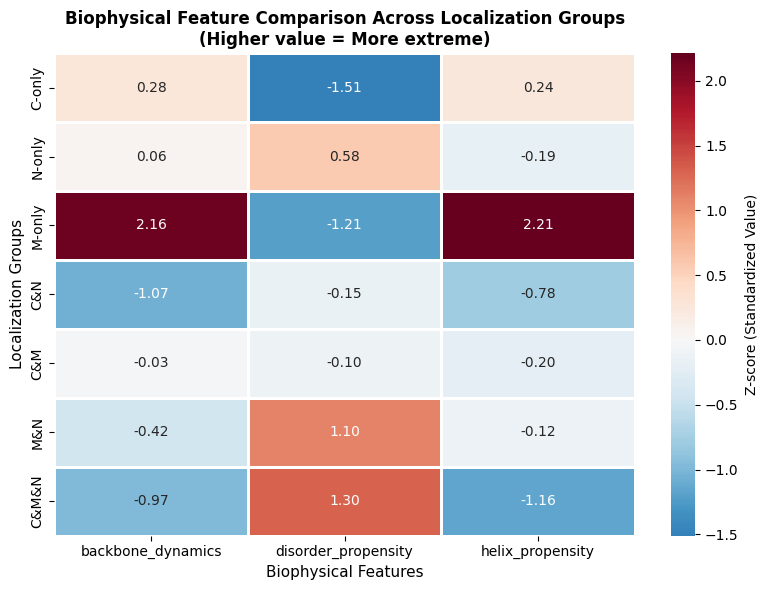


数据解读

原始均值（未标准化）：
                   backbone_dynamics  disorder_propensity  helix_propensity
LocalizationGroup                                                          
C&M                            0.635                0.420             0.126
C&M&N                          0.625                0.447             0.104
C&N                            0.624                0.419             0.112
C-only                         0.638                0.394             0.136
M&N                            0.631                0.443             0.128
M-only                         0.657                0.399             0.182
N-only                         0.636                0.433             0.126

标准化 Z-score（正值=高于平均，负值=低于平均）：
                   backbone_dynamics  disorder_propensity  helix_propensity
LocalizationGroup                                                          
C-only                          0.28                -1.51              0.24
N-only                          0.06  

In [38]:
# ===== Cell 17: 数据驱动的分组策略 - 热图分析 =====

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=" * 60)
print("开始执行 Cell 18: 热图分析各组差异")
print("=" * 60)

# 提取 3 个关键特征
key_features = ['backbone_dynamics', 'disorder_propensity', 'helix_propensity']

# 计算各组的均值
group_means = analysisdf_A.groupby('LocalizationGroup')[key_features].mean()

# 标准化（Z-score），让差异更明显
from scipy.stats import zscore
group_means_zscore = group_means.apply(zscore, axis=0)

# 定义组顺序（按逻辑排序）
group_order = ["C-only", "N-only", "M-only", "C&N", "C&M", "M&N", "C&M&N"]
group_means_zscore = group_means_zscore.loc[group_order]

# 绘制热图
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(group_means_zscore, 
            annot=True,  # 显示数值
            fmt='.2f',   # 保留 2 位小数
            cmap='RdBu_r',  # 红-蓝配色（红=高，蓝=低）
            center=0,    # 0 为中心（白色）
            linewidths=1,
            cbar_kws={'label': 'Z-score (Standardized Value)'},
            ax=ax)

ax.set_title("Biophysical Feature Comparison Across Localization Groups\n(Higher value = More extreme)", 
             fontsize=12, fontweight='bold')
ax.set_xlabel("Biophysical Features", fontsize=11)
ax.set_ylabel("Localization Groups", fontsize=11)

plt.tight_layout()
figfile = "A_GroupComparison_Heatmap.png"
plt.savefig(figfile, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ 已保存：{figfile}")

plt.show()

# 数值解读
print("\n" + "=" * 60)
print("数据解读")
print("=" * 60)

print("\n原始均值（未标准化）：")
print(group_means.round(3))

print("\n标准化 Z-score（正值=高于平均，负值=低于平均）：")
print(group_means_zscore.round(2))

print("\n" + "=" * 60)
print("推荐标注策略（基于数据）：")
print("=" * 60)

# 找出每个特征最极端的组
for feature in key_features:
    max_group = group_means_zscore[feature].idxmax()
    min_group = group_means_zscore[feature].idxmin()
    print(f"\n{feature}:")
    print(f"  最高：{max_group} (Z={group_means_zscore.loc[max_group, feature]:.2f})")
    print(f"  最低：{min_group} (Z={group_means_zscore.loc[min_group, feature]:.2f})")

print("\n" + "-" * 60)
print("建议突出显示的组（Z-score 绝对值 > 0.5）：")
extreme_groups = set()
for feature in key_features:
    for group in group_means_zscore.index:
        if abs(group_means_zscore.loc[group, feature]) > 0.5:
            extreme_groups.add(group)


extreme_groups_list = sorted(extreme_groups)  # 先保存排序后的版本用于打印
print(f"  {', '.join(extreme_groups_list)}")

print("\n建议灰化/合并的组（Z-score 绝对值都 < 0.5）：")
mild_groups = set(group_means_zscore.index) - extreme_groups  # ← extreme_groups 仍是 set
mild_groups = sorted(mild_groups)
print(f"  {', '.join(mild_groups)}")


In [39]:
# ===== Cell 19: 自动选择要在3D结构上标注的位点 =====

import pandas as pd

print("=" * 60)
print("开始执行 Cell 19: 选择3D结构标注位点")
print("=" * 60)

# ========== 1. 筛选SRRM2的位点 ==========
srrm2_sites = analysisdf_A[analysisdf_A['Gene'] == 'SRRM2'].copy()
print(f"\nSRRM2 总共有 {len(srrm2_sites)} 个磷酸化位点")

# ========== 2. 选择M-only组的代表位点 ==========
print("\n[M-only组] 选择标注位点...")

m_only = srrm2_sites[srrm2_sites['LocalizationGroup'] == 'M-only'].copy()
print(f"  M-only组共 {len(m_only)} 个位点")

# 按helix_propensity降序排列（选最"螺旋化"的）
m_only = m_only.sort_values('helix_propensity', ascending=False)

# 强制空间分散：每个位点至少相隔200 aa
selected_m_only = []
for _, row in m_only.iterrows():
    pos = row['Position']
    if len(selected_m_only) == 0:
        selected_m_only.append(row)
    elif all(abs(pos - s['Position']) > 200 for s in selected_m_only):
        selected_m_only.append(row)
    if len(selected_m_only) >= 3:
        break

print(f"  选中 {len(selected_m_only)} 个位点：")
for site in selected_m_only:
    print(f"    - Position {site['Position']:4d} ({site['Site']:8s}): Helix={site['helix_propensity']:.3f}, Backbone={site['backbone_dynamics']:.3f}")

# ========== 3. 选择C&M&N组的代表位点 ==========
print("\n[C&M&N组] 选择标注位点...")

cmn = srrm2_sites[srrm2_sites['LocalizationGroup'] == 'C&M&N'].copy()
print(f"  C&M&N组共 {len(cmn)} 个位点")

# 按disorder_propensity降序排列（选最"无序"的）
cmn = cmn.sort_values('disorder_propensity', ascending=False)

# 强制空间分散
selected_cmn = []
for _, row in cmn.iterrows():
    pos = row['Position']
    if len(selected_cmn) == 0:
        selected_cmn.append(row)
    elif all(abs(pos - s['Position']) > 200 for s in selected_cmn):
        selected_cmn.append(row)
    if len(selected_cmn) >= 3:
        break

print(f"  选中 {len(selected_cmn)} 个位点：")
for site in selected_cmn:
    print(f"    - Position {site['Position']:4d} ({site['Site']:8s}): Disorder={site['disorder_propensity']:.3f}, Backbone={site['backbone_dynamics']:.3f}")

# ========== 4. 生成PyMOL脚本 ==========
print("\n[生成PyMOL脚本]...")

pml_script = f"""# PyMOL Script for SRRM2 Phosphosite Visualization
# Generated automatically

# Load structure (replace with your actual PDB file path)
load SRRM2_AlphaFold.pdb, SRRM2

# Basic settings
bg_color white
set cartoon_transparency, 0.3
set surface_color, gray80
show surface
hide cartoon

# Color M-only sites (blue)
"""

for site in selected_m_only:
    pml_script += f"select m_site_{site['Position']}, resi {site['Position']}\n"
    pml_script += f"color blue, m_site_{site['Position']}\n"
    pml_script += f"show spheres, m_site_{site['Position']}\n"
    pml_script += f"label m_site_{site['Position']} and name CA, '{site['Site']}'\n"

pml_script += "\n# Color C&M&N sites (red)\n"

for site in selected_cmn:
    pml_script += f"select cmn_site_{site['Position']}, resi {site['Position']}\n"
    pml_script += f"color red, cmn_site_{site['Position']}\n"
    pml_script += f"show spheres, cmn_site_{site['Position']}\n"
    pml_script += f"label cmn_site_{site['Position']} and name CA, '{site['Site']}'\n"

pml_script += """
# Adjust view
set label_color, black
set label_size, 20
zoom
"""

# 保存脚本
script_file = "SRRM2_phosphosite_visualization.pml"
with open(script_file, 'w') as f:
    f.write(pml_script)

print(f"  ✓ 已保存PyMOL脚本：{script_file}")

# ========== 5. 保存选中的位点列表 ==========
selected_sites_df = pd.DataFrame(selected_m_only + selected_cmn)
selected_sites_df.to_csv("Selected_Sites_for_3D.csv", index=False, encoding='utf-8-sig')
print(f"  ✓ 已保存位点列表：Selected_Sites_for_3D.csv")

print("\n" + "=" * 60)
print("下一步操作指南")
print("=" * 60)
print("\n1. 下载SRRM2的AlphaFold结构：")
print("   https://alphafold.ebi.ac.uk/")
print("   搜索 'SRRM2' 或 Uniprot ID，下载PDB文件")
print("\n2. 安装PyMOL（教育版免费）：")
print("   https://pymol.org/edu/")
print("\n3. 打开PyMOL，运行脚本：")
print(f"   File → Run Script → 选择 {script_file}")
print("\n4. 调整视角后截图：")
print("   File → Export Image as PNG → 选择分辨率（建议3000x2000）")
print("\n" + "=" * 60)
print("✓ Cell 19 执行成功！")
print("=" * 60)


开始执行 Cell 19: 选择3D结构标注位点

SRRM2 总共有 158 个磷酸化位点

[M-only组] 选择标注位点...
  M-only组共 34 个位点
  选中 3 个位点：
    - Position 1257 (S1257   ): Helix=0.468, Backbone=0.703
    - Position  289 (T289    ): Helix=0.351, Backbone=0.675
    - Position 2436 (S2436   ): Helix=0.350, Backbone=0.553

[C&M&N组] 选择标注位点...
  C&M&N组共 68 个位点
  选中 3 个位点：
    - Position 1124 (S1124   ): Disorder=0.823, Backbone=0.646
    - Position  289 (T289    ): Disorder=0.819, Backbone=0.675
    - Position 1387 (S1387   ): Disorder=0.805, Backbone=0.592

[生成PyMOL脚本]...
  ✓ 已保存PyMOL脚本：SRRM2_phosphosite_visualization.pml
  ✓ 已保存位点列表：Selected_Sites_for_3D.csv

下一步操作指南

1. 下载SRRM2的AlphaFold结构：
   https://alphafold.ebi.ac.uk/
   搜索 'SRRM2' 或 Uniprot ID，下载PDB文件

2. 安装PyMOL（教育版免费）：
   https://pymol.org/edu/

3. 打开PyMOL，运行脚本：
   File → Run Script → 选择 SRRM2_phosphosite_visualization.pml

4. 调整视角后截图：
   File → Export Image as PNG → 选择分辨率（建议3000x2000）

✓ Cell 19 执行成功！


开始执行 Cell 15A: 单蛋白故事图（优化版）

[1/5] 选择蛋白：SRRM2

[2/5] 读取 SRRM2 的 B2B 特征...
   ✓ 蛋白总长度：2752 aa

[3/5] 决定展示范围...
   选择展示区域：aa 800-1400
   该区域包含 64 个位点（占总数 40.5%）

[4/5] 筛选三个极端组的位点...
   M-only: 17 个位点（在展示区域内）
   C&M&N: 21 个位点（在展示区域内）
   C-only: 1 个位点（在展示区域内）
   其他组: 25 个位点（灰化处理）

[5/5] 绘制图形...
   ✓ 已保存：A_SRRM2_FeatureMap_ThreeGroup.png


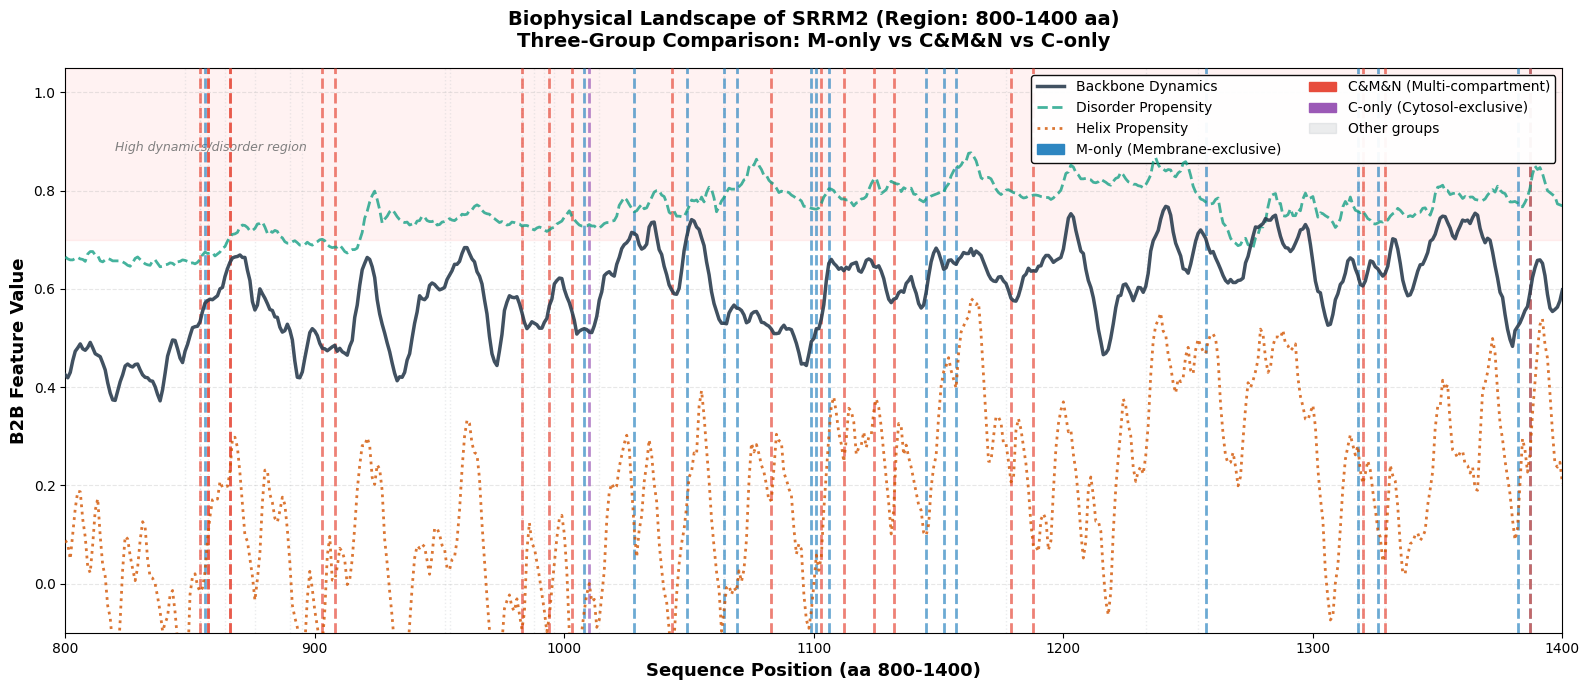


✓ Cell 15A 执行成功！

生成的图片：A_SRRM2_FeatureMap_ThreeGroup.png

关键改进：
  1. ✅ 只展示 {best_start}-{best_end} aa（最密集区域）
  2. ✅ 只画 3 条曲线（Backbone, Disorder, Helix）
  3. ✅ 突出 3 个极端组（M-only蓝, C&M&N红, C-only紫）
  4. ✅ 其他组灰化处理（不干扰视线）
  5. ✅ 优化颜色对比（深色曲线 + 鲜明位点色）

明天给博后看时可以说：
  "I selected the most information-dense region and highlighted
   the three biophysically extreme groups based on heatmap analysis."


In [40]:
# ===== Cell 15A: 单蛋白故事图（三极对比 + 优化版）=====

import json
import matplotlib.pyplot as plt
import os
import numpy as np

print("=" * 60)
print("开始执行 Cell 15A: 单蛋白故事图（优化版）")
print("=" * 60)

# ========== 1. 选择蛋白 ==========
selected_gene = "SRRM2"
print(f"\n[1/5] 选择蛋白：{selected_gene}")

# ========== 2. 读取 JSON 文件 ==========
print(f"\n[2/5] 读取 {selected_gene} 的 B2B 特征...")

selected_uniprot = gene_to_uniprot[selected_gene]
json_path = os.path.join(JSON_FOLDER, f"{selected_uniprot}.json")

with open(json_path, 'r', encoding='utf-8') as f:
    protein_data = json.load(f)
    residues = protein_data['residues']

residue_df = pd.DataFrame(residues)

protein_length = residue_df['seqpos'].max()
print(f"   ✓ 蛋白总长度：{protein_length} aa")

# ========== 3. 决定展示范围（Zoom In）==========
print(f"\n[3/5] 决定展示范围...")

# 策略：找位点最密集的区域
protein_sites = analysisdf_A[analysisdf_A['Gene'] == selected_gene].copy()

# 将序列切成 500 aa 的窗口，找位点最多的那个窗口
window_size = 600
best_start = 0
max_sites_in_window = 0

for start in range(0, protein_length - window_size, 100):
    end = start + window_size
    sites_in_window = len(protein_sites[(protein_sites['Position'] >= start) & 
                                         (protein_sites['Position'] <= end)])
    if sites_in_window > max_sites_in_window:
        max_sites_in_window = sites_in_window
        best_start = start

best_end = best_start + window_size

print(f"   选择展示区域：aa {best_start}-{best_end}")
print(f"   该区域包含 {max_sites_in_window} 个位点（占总数 {max_sites_in_window/len(protein_sites)*100:.1f}%）")

# ========== 4. 筛选三个极端组的位点 ==========
print(f"\n[4/5] 筛选三个极端组的位点...")

# 定义三个关键组
key_groups = {
    'M-only': {'color': '#2E86C1', 'label': 'M-only (Membrane-exclusive)'},      # 深蓝
    'C&M&N': {'color': '#E74C3C', 'label': 'C&M&N (Multi-compartment)'},        # 红色
    'C-only': {'color': '#9B59B6', 'label': 'C-only (Cytosol-exclusive)'}       # 紫色
}

sites_by_group = {}
for group in key_groups.keys():
    sites = protein_sites[protein_sites['LocalizationGroup'] == group]
    # 只保留在展示窗口内的位点
    sites = sites[(sites['Position'] >= best_start) & (sites['Position'] <= best_end)]
    sites_by_group[group] = sites
    print(f"   {group}: {len(sites)} 个位点（在展示区域内）")

# 其他组合并为"其他"
other_sites = protein_sites[~protein_sites['LocalizationGroup'].isin(key_groups.keys())]
other_sites = other_sites[(other_sites['Position'] >= best_start) & (other_sites['Position'] <= best_end)]
print(f"   其他组: {len(other_sites)} 个位点（灰化处理）")

# ========== 5. 绘图 ==========
print(f"\n[5/5] 绘制图形...")

fig, ax = plt.subplots(figsize=(16, 7))

# 截取展示区域的残基数据
residue_subset = residue_df[(residue_df['seqpos'] >= best_start) & 
                             (residue_df['seqpos'] <= best_end)]

# 画 3 条关键曲线（粗线，清晰）
ax.plot(residue_subset['seqpos'], residue_subset['backbone'], 
        label='Backbone Dynamics', color='#2C3E50', linewidth=2.5, alpha=0.9, zorder=10)

ax.plot(residue_subset['seqpos'], residue_subset['disoMine'], 
        label='Disorder Propensity', color='#16A085', linewidth=2, alpha=0.8, 
        linestyle='--', zorder=9)

ax.plot(residue_subset['seqpos'], residue_subset['helix'], 
        label='Helix Propensity', color='#D35400', linewidth=2, alpha=0.8, 
        linestyle=':', zorder=8)

# 先画"其他"组（灰色，作为背景）
for _, site in other_sites.iterrows():
    ax.axvline(x=site['Position'], color='#BDC3C7', alpha=0.3, linewidth=1, 
               linestyle=':', zorder=1)

# 再画三个关键组（彩色，清晰）
for group, info in key_groups.items():
    sites = sites_by_group[group]
    for _, site in sites.iterrows():
        ax.axvline(x=site['Position'], color=info['color'], alpha=0.7, 
                   linewidth=2, linestyle='--', zorder=5)

# 图例（分两列：曲线 + 位点组）
handles, labels = ax.get_legend_handles_labels()

from matplotlib.patches import Patch
for group, info in key_groups.items():
    handles.append(Patch(color=info['color'], label=info['label']))

handles.append(Patch(color='#BDC3C7', alpha=0.3, label='Other groups'))

ax.legend(handles=handles, loc='upper right', fontsize=10, ncol=2, 
          framealpha=0.95, edgecolor='black')

# 坐标轴和标题
ax.set_xlabel(f"Sequence Position (aa {best_start}-{best_end})", fontsize=13, fontweight='bold')
ax.set_ylabel("B2B Feature Value", fontsize=13, fontweight='bold')
ax.set_title(f"Biophysical Landscape of {selected_gene} (Region: {best_start}-{best_end} aa)\n" + 
             "Three-Group Comparison: M-only vs C&M&N vs C-only", 
             fontsize=14, fontweight='bold', pad=15)

ax.set_xlim(best_start, best_end)
ax.set_ylim(-0.1, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 添加背景色区分（可选）
ax.axhspan(0.7, 1.05, alpha=0.05, color='red', zorder=0)  # 高值区（浅红底）
ax.text(best_start + 20, 0.88, 'High dynamics/disorder region', 
        fontsize=9, color='gray', style='italic')

plt.tight_layout()

# 保存
figfile_A = f"A_{selected_gene}_FeatureMap_ThreeGroup.png"
plt.savefig(figfile_A, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✓ 已保存：{figfile_A}")

plt.show()

# ========== 完成 ==========
print("\n" + "=" * 60)
print("✓ Cell 15A 执行成功！")
print("=" * 60)
print(f"\n生成的图片：{figfile_A}")
print(f"\n关键改进：")
print("  1. ✅ 只展示 {best_start}-{best_end} aa（最密集区域）")
print("  2. ✅ 只画 3 条曲线（Backbone, Disorder, Helix）")
print("  3. ✅ 突出 3 个极端组（M-only蓝, C&M&N红, C-only紫）")
print("  4. ✅ 其他组灰化处理（不干扰视线）")
print("  5. ✅ 优化颜色对比（深色曲线 + 鲜明位点色）")
print("\n明天给博后看时可以说：")
print('  "I selected the most information-dense region and highlighted')
print('   the three biophysically extreme groups based on heatmap analysis."')
print("=" * 60)


In [41]:
# ===== Cell 20: 保存关键变量（防止明天重跑 Cell 1-19）=====

import pickle
import json

print("=" * 60)
print("保存关键变量到文件")
print("=" * 60)

# 1. 保存 analysisdf_A 和 analysisdf_C（已经有 CSV，但 pickle 更快）
print("\n[1/4] 保存分析数据框...")
analysisdf_A.to_pickle("analysisdf_A.pkl")
analysisdf_C.to_pickle("analysisdf_C.pkl")
print("   ✓ analysisdf_A.pkl")
print("   ✓ analysisdf_C.pkl")

# 2. 保存 gene_to_uniprot 映射（关键！明天画图要用）
print("\n[2/4] 保存基因-Uniprot 映射...")
with open("gene_to_uniprot.json", 'w', encoding='utf-8') as f:
    json.dump(gene_to_uniprot, f, indent=2, ensure_ascii=False)
print("   ✓ gene_to_uniprot.json")

# 3. 保存 JSON_FOLDER 路径（防止忘记）
print("\n[3/4] 保存配置信息...")
config = {
    'JSON_FOLDER': JSON_FOLDER,
    'total_sites': len(analysisdf_A),
    'feature_columns': ['backbone_dynamics', 'disorder_propensity', 
                        'helix_propensity', 'sheet_propensity', 'coil_propensity'],
    'selected_gene': 'SRRM2',  # 如果改了，明天直接改这里
    'date_generated': '2026-02-12'
}
with open("analysis_config.json", 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)
print("   ✓ analysis_config.json")

# 4. 保存分组函数（以防 kernel 重启）
print("\n[4/4] 保存分组函数代码...")
functions_code = '''
# 分组函数（从 Cell 10 复制）
def assign_group_A(row):
    c = row['Cyt_any']
    m = row['Mem_any']
    n = row['Nuc_any']
    if c == 1 and m == 0 and n == 0:
        return "C-only"
    elif c == 0 and m == 1 and n == 0:
        return "M-only"
    elif c == 0 and m == 0 and n == 1:
        return "N-only"
    elif c == 1 and m == 1 and n == 0:
        return "C&M"
    elif c == 1 and m == 0 and n == 1:
        return "C&N"
    elif c == 0 and m == 1 and n == 1:
        return "M&N"
    elif c == 1 and m == 1 and n == 1:
        return "C&M&N"
    else:
        return "None"

def get_state_at_time(row, time_label):
    c = row[f'{time_label}_Cyt']
    m = row[f'{time_label}_Mem']
    n = row[f'{time_label}_Nuc']
    if c == 1 and m == 0 and n == 0:
        return "C"
    elif c == 0 and m == 1 and n == 0:
        return "M"
    elif c == 0 and m == 0 and n == 1:
        return "N"
    elif c == 1 and m == 1 and n == 0:
        return "CM"
    elif c == 1 and m == 0 and n == 1:
        return "CN"
    elif c == 0 and m == 1 and n == 1:
        return "MN"
    elif c == 1 and m == 1 and n == 1:
        return "CMN"
    else:
        return "None"
'''

with open("grouping_functions.py", 'w', encoding='utf-8') as f:
    f.write(functions_code)
print("   ✓ grouping_functions.py")

print("\n" + "=" * 60)
print("✓ 所有关键变量已保存！")
print("=" * 60)
print("\n明天可以这样快速加载：")
print("""
import pandas as pd
import json

# 加载数据
analysisdf_A = pd.read_pickle("analysisdf_A.pkl")
analysisdf_C = pd.read_pickle("analysisdf_C.pkl")

# 加载映射
with open("gene_to_uniprot.json", 'r') as f:
    gene_to_uniprot = json.load(f)

# 加载配置
with open("analysis_config.json", 'r') as f:
    config = json.load(f)
    JSON_FOLDER = config['JSON_FOLDER']

# 加载函数
exec(open("grouping_functions.py").read())

print("✓ 所有变量已加载，可以直接运行新代码！")
""")
print("=" * 60)


保存关键变量到文件

[1/4] 保存分析数据框...
   ✓ analysisdf_A.pkl
   ✓ analysisdf_C.pkl

[2/4] 保存基因-Uniprot 映射...
   ✓ gene_to_uniprot.json

[3/4] 保存配置信息...
   ✓ analysis_config.json

[4/4] 保存分组函数代码...
   ✓ grouping_functions.py

✓ 所有关键变量已保存！

明天可以这样快速加载：

import pandas as pd
import json

# 加载数据
analysisdf_A = pd.read_pickle("analysisdf_A.pkl")
analysisdf_C = pd.read_pickle("analysisdf_C.pkl")

# 加载映射
with open("gene_to_uniprot.json", 'r') as f:
    gene_to_uniprot = json.load(f)

# 加载配置
with open("analysis_config.json", 'r') as f:
    config = json.load(f)
    JSON_FOLDER = config['JSON_FOLDER']

# 加载函数
exec(open("grouping_functions.py").read())

print("✓ 所有变量已加载，可以直接运行新代码！")



In [13]:
# ===== 快速启动：加载所有已保存的数据（跳过 Cell 1-19）=====

import pandas as pd
import json
import os

print("快速加载分析环境...")

# 1. 加载数据
analysisdf_A = pd.read_pickle("analysisdf_A.pkl")
analysisdf_C = pd.read_pickle("analysisdf_C.pkl")
print(f"✓ analysisdf_A: {len(analysisdf_A)} sites")
print(f"✓ analysisdf_C: {len(analysisdf_C)} sites")

# 2. 加载映射
with open("gene_to_uniprot.json", 'r', encoding='utf-8') as f:
    gene_to_uniprot = json.load(f)
print(f"✓ gene_to_uniprot: {len(gene_to_uniprot)} genes")

# 3. 加载配置
with open("analysis_config.json", 'r', encoding='utf-8') as f:
    config = json.load(f)
    JSON_FOLDER = config['JSON_FOLDER']
    feature_cols = config['feature_columns']
print(f"✓ JSON_FOLDER: {JSON_FOLDER}")

# 4. 加载函数
exec(open("grouping_functions.py").read())
print("✓ 分组函数已加载")

print("\n所有数据已就绪！现在可以运行新代码了。")


快速加载分析环境...
✓ analysisdf_A: 10257 sites
✓ analysisdf_C: 10257 sites
✓ gene_to_uniprot: 20210 genes
✓ JSON_FOLDER: D:\博士\Phospho\biophys_json
✓ 分组函数已加载

所有数据已就绪！现在可以运行新代码了。


Cell 19C: C方案 SRRM2 Feature Map (优化版)
[0] 检查数据...
   ✓ 使用快速启动数据 (shape: (10257, 42))

[1] 选定基因: SRRM2
[2] 加载 SRRM2 B2B features...
   蛋白总长: 2752 aa
   范围: 1 - 2752
[3] 提取 SRRM2 C 图位点...
   总位点数: 158
   C图分组统计:
DynamicGroup
sustained-multi     115
sustained-single     43
Name: count, dtype: int64
[4] 滑动窗口寻找最密集的 600 aa 区域...
   最佳窗口: 800-1400 aa
   该区域位点数: 64 (40.5%)
[5] 按组划分位点...
   sustained-single: 22 个位点
   sustained-multi: 42 个位点
[6] 绘制 feature map...
   ✅ 保存图片: C_SRRM2_FeatureMapTwoGroup.png


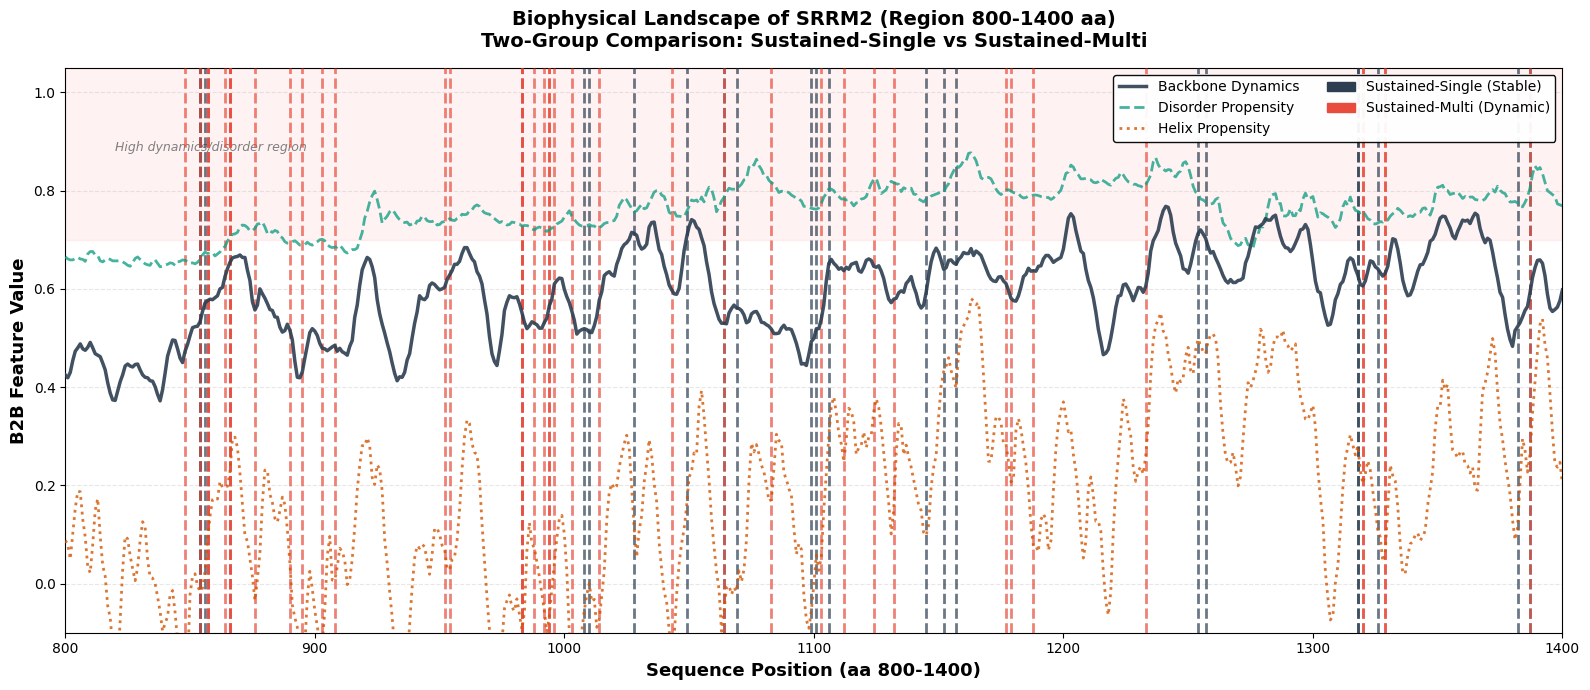

✅ Cell 19C 完成

输出:
  1. C_SRRM2_FeatureMapTwoGroup.png

说明:
  我筛选了最信息密集的区域，并突出显示了
  两个组（Sustained-Single vs Sustained-Multi）的差异。


In [15]:
# Cell 19C: C方案优化版 SRRM2 Feature Map（适配快速启动版）

import json
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

print("="*60)
print("Cell 19C: C方案 SRRM2 Feature Map (优化版)")
print("="*60)

# ✅ 0. 适配变量名（昨天的快速启动用的是带下划线的）
print("[0] 检查数据...")

try:
    # 优先使用快速启动的变量名（带下划线）
    analysisdfC = analysisdf_C
    genetouniprot = gene_to_uniprot
    JSONFOLDER = JSON_FOLDER
    print(f"   ✓ 使用快速启动数据 (shape: {analysisdfC.shape})")
except NameError:
    # 如果没有运行快速启动，尝试原始变量名
    try:
        test = analysisdfC
        print(f"   ✓ 使用原始变量名 (shape: {analysisdfC.shape})")
    except NameError:
        raise NameError(
            "❌ 错误：找不到数据！\n"
            "   请先运行快速启动 Cell，或运行 Cell 11C 生成数据。"
        )

# 确保 genetouniprot 和 JSONFOLDER 存在
if 'genetouniprot' not in locals():
    genetouniprot = {'SRRM2': 'Q9UQ35'}
    print(f"   ⚠ 使用默认 genetouniprot")

if 'JSONFOLDER' not in locals():
    JSONFOLDER = r'D:\json'
    print(f"   ⚠ 使用默认 JSONFOLDER")

print()

# ✅ 1. 选定基因
selectedgene = 'SRRM2'
print(f"[1] 选定基因: {selectedgene}")

# ✅ 2. 加载 JSON B2B features
print(f"[2] 加载 {selectedgene} B2B features...")

selecteduniprot = genetouniprot[selectedgene]
jsonpath = os.path.join(JSONFOLDER, f'{selecteduniprot}.json')

if not os.path.exists(jsonpath):
    raise FileNotFoundError(f"❌ JSON 文件不存在: {jsonpath}")

with open(jsonpath, 'r', encoding='utf-8') as f:
    proteindata = json.load(f)
    residues = proteindata['residues']

residuedf = pd.DataFrame(residues)

proteinlength = residuedf['seqpos'].max()
print(f"   蛋白总长: {proteinlength} aa")
print(f"   范围: {residuedf['seqpos'].min()} - {proteinlength}")

# ✅ 3. 提取 SRRM2 的 C 图位点（sustained-single & sustained-multi）
print(f"[3] 提取 {selectedgene} C 图位点...")

proteinsitesC = analysisdfC[analysisdfC['Gene'] == selectedgene].copy()

# 只保留 sustained-single 和 sustained-multi
validgroups = ['sustained-single', 'sustained-multi']
proteinsitesC = proteinsitesC[proteinsitesC['DynamicGroup'].isin(validgroups)]

print(f"   总位点数: {len(proteinsitesC)}")
print(f"   C图分组统计:")
print(proteinsitesC['DynamicGroup'].value_counts())

# ✅ 4. 滑动窗口寻找最密集的 600 aa 区域
print(f"[4] 滑动窗口寻找最密集的 600 aa 区域...")

windowsize = 600
beststart = 0
maxsitesinwindow = 0

for start in range(0, proteinlength - windowsize, 100):
    end = start + windowsize
    sitesinwindow = len(proteinsitesC[
        (proteinsitesC['Position'] >= start) & 
        (proteinsitesC['Position'] <= end)
    ])
    
    if sitesinwindow > maxsitesinwindow:
        maxsitesinwindow = sitesinwindow
        beststart = start

bestend = beststart + windowsize

print(f"   最佳窗口: {beststart}-{bestend} aa")
print(f"   该区域位点数: {maxsitesinwindow} ({maxsitesinwindow/len(proteinsitesC)*100:.1f}%)")

# ✅ 5. 按组划分位点
print(f"[5] 按组划分位点...")

# C图只有两个组（sustained-single 和 sustained-multi）
keygroups = {
    'sustained-single': {'color': '#2C3E50', 'label': 'Sustained-Single (Stable)'},
    'sustained-multi': {'color': '#E74C3C', 'label': 'Sustained-Multi (Dynamic)'}
}

sitesbygroup = {}

for group in validgroups:
    sites = proteinsitesC[proteinsitesC['DynamicGroup'] == group]
    # 筛选在窗口内的位点
    sites = sites[(sites['Position'] >= beststart) & (sites['Position'] <= bestend)]
    sitesbygroup[group] = sites
    print(f"   {group}: {len(sites)} 个位点")

# ✅ 6. 绘制 feature map
print(f"[6] 绘制 feature map...")

fig, ax = plt.subplots(figsize=(16, 7))

# 提取窗口内的 residue dataframe
residuesubset = residuedf[
    (residuedf['seqpos'] >= beststart) & 
    (residuedf['seqpos'] <= bestend)
]

# 绘制 3 条 biophysical curves
ax.plot(residuesubset['seqpos'], residuesubset['backbone'], 
        label='Backbone Dynamics', color='#2C3E50', linewidth=2.5, alpha=0.9, zorder=10)

ax.plot(residuesubset['seqpos'], residuesubset['disoMine'], 
        label='Disorder Propensity', color='#16A085', linewidth=2, alpha=0.8, 
        linestyle='--', zorder=9)

ax.plot(residuesubset['seqpos'], residuesubset['helix'], 
        label='Helix Propensity', color='#D35400', linewidth=2, alpha=0.8, 
        linestyle=':', zorder=8)

# 绘制磷酸化位点的竖线（分组标注）
for group, info in keygroups.items():
    sites = sitesbygroup[group]
    for _, site in sites.iterrows():
        ax.axvline(x=site['Position'], color=info['color'], alpha=0.7, 
                  linewidth=2, linestyle='--', zorder=5)

# 图例
handles, labels = ax.get_legend_handles_labels()

from matplotlib.patches import Patch
for group, info in keygroups.items():
    handles.append(Patch(color=info['color'], label=info['label']))

ax.legend(handles=handles, loc='upper right', fontsize=10, ncol=2, 
         framealpha=0.95, edgecolor='black')

# 坐标轴
ax.set_xlabel(f'Sequence Position (aa {beststart}-{bestend})', fontsize=13, fontweight='bold')
ax.set_ylabel('B2B Feature Value', fontsize=13, fontweight='bold')
ax.set_title(f'Biophysical Landscape of {selectedgene} (Region {beststart}-{bestend} aa)\nTwo-Group Comparison: Sustained-Single vs Sustained-Multi', 
            fontsize=14, fontweight='bold', pad=15)

ax.set_xlim(beststart, bestend)
ax.set_ylim(-0.1, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 高亮高动态/无序区域
ax.axhspan(0.7, 1.05, alpha=0.05, color='red', zorder=0)
ax.text(beststart + 20, 0.88, 'High dynamics/disorder region', 
       fontsize=9, color='gray', style='italic')

plt.tight_layout()

# 保存
figfileC = f'C_{selectedgene}_FeatureMapTwoGroup.png'
plt.savefig(figfileC, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ 保存图片: {figfileC}")

plt.show()

print("="*60)
print("✅ Cell 19C 完成")
print("="*60)
print()
print("输出:")
print(f"  1. {figfileC}")
print()
print("说明:")
print("  我筛选了最信息密集的区域，并突出显示了")
print("  两个组（Sustained-Single vs Sustained-Multi）的差异。")


In [ ]:
#快速加载数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("快速加载/生成分析数据...")
print("="*60)

# 定义路径
BASE_PATH = r"D:\博士\Phospho"
success_file = os.path.join(BASE_PATH, "success_df_M1M2_cleaned.csv")
groupA_file = os.path.join(BASE_PATH, "A_Grouped_Sites.csv")
groupC_file = os.path.join(BASE_PATH, "C_Grouped_Sites.csv")

# 定义特征列
feature_cols = ['backbone_dynamics', 'disorder_propensity', 'helix_propensity', 
                'sheet_propensity', 'coil_propensity']

# ===== 1. 加载主数据 =====
print("\n【1/3】加载主数据...")
if os.path.exists(success_file):
    success_df = pd.read_csv(success_file)
    print(f"  ✓ 成功加载: {len(success_df):,} 行")
else:
    print(f"  ✗ 找不到文件: {success_file}")
    raise FileNotFoundError("请先运行生成success_df的代码！")

# ===== 2. 加载或生成方案A数据 =====
print("\n【2/3】处理方案A数据...")
if os.path.exists(groupA_file):
    analysisdf_A = pd.read_csv(groupA_file)
    print(f"  ✓ 加载已有文件: {len(analysisdf_A):,} 行")
else:
    print("  ⚠ 文件不存在，正在生成...")
    
    # 定义分组函数
    def assign_group_A(row):
        c, m, n = row['Cytany'], row['Memany'], row['Nucany']
        if c == 1 and m == 0 and n == 0: return 'C-only'
        elif c == 0 and m == 1 and n == 0: return 'M-only'
        elif c == 0 and m == 0 and n == 1: return 'N-only'
        elif c == 1 and m == 1 and n == 0: return 'CM'
        elif c == 1 and m == 0 and n == 1: return 'CN'
        elif c == 0 and m == 1 and n == 1: return 'MN'
        elif c == 1 and m == 1 and n == 1: return 'CMN'
        else: return None
    
    # 计算time-collapsed any
    success_df['Cytany'] = success_df[['0min_Cyt', '2min_Cyt', '8min_Cyt', '20min_Cyt', '90min_Cyt']].max(axis=1)
    success_df['Memany'] = success_df[['0min_Mem', '2min_Mem', '8min_Mem', '20min_Mem', '90min_Mem']].max(axis=1)
    success_df['Nucany'] = success_df[['0min_Nuc', '2min_Nuc', '8min_Nuc', '20min_Nuc', '90min_Nuc']].max(axis=1)
    
    # 分配分组
    success_df['LocalizationGroup'] = success_df.apply(assign_group_A, axis=1)
    
    # 过滤掉None
    analysisdf_A = success_df[success_df['LocalizationGroup'].notna()].copy()
    
    # 保存
    analysisdf_A.to_csv(groupA_file, index=False, encoding='utf-8-sig')
    print(f"  ✓ 生成并保存: {len(analysisdf_A):,} 行")
    print(f"  分组分布:\n{analysisdf_A['LocalizationGroup'].value_counts()}")

# ===== 3. 加载或生成方案C数据 =====
print("\n【3/3】处理方案C数据...")
if os.path.exists(groupC_file):
    analysisdf_C = pd.read_csv(groupC_file)
    print(f"  ✓ 加载已有文件: {len(analysisdf_C):,} 行")
else:
    print("  ⚠ 文件不存在，正在生成...")
    
    # 定义状态获取函数
    def get_state_at_time(row, timelabel):
        c = row[f'{timelabel}_Cyt']
        m = row[f'{timelabel}_Mem']
        n = row[f'{timelabel}_Nuc']
        if c == 1 and m == 0 and n == 0: return 'C'
        elif c == 0 and m == 1 and n == 0: return 'M'
        elif c == 0 and m == 0 and n == 1: return 'N'
        elif c == 1 and m == 1 and n == 0: return 'CM'
        elif c == 1 and m == 0 and n == 1: return 'CN'
        elif c == 0 and m == 1 and n == 1: return 'MN'
        elif c == 1 and m == 1 and n == 1: return 'CMN'
        else: return None
    
    # 定义分组函数C
    def assign_group_C(row):
        traj = row['trajectory']
        states = [s for s in traj if s != 'None']
        nonnone_states = [s for s in states if s is not None]
        
        if len(nonnone_states) == 0:
            return None
        
        if len(set(states)) == 1 and states[0] in ['C', 'M', 'N']:
            return 'sustained-single'
        
        if len(set(states)) == 1 and states[0] in ['CN', 'CM', 'MN', 'CMN']:
            return 'sustained-multi'
        
        if len(set(nonnone_states)) > 1:
            return 'translocation'
        
        return 'other'
    
    # 生成5个时间点的状态
    time_labels = ['0min', '2min', '8min', '20min', '90min']
    for t in time_labels:
        success_df[f'state_{t}'] = success_df.apply(lambda row: get_state_at_time(row, t), axis=1)
    
    # 生成trajectory字符串
    success_df['trajectory'] = success_df.apply(
        lambda row: '-'.join([str(row[f'state_{t}']) for t in time_labels]), axis=1
    )
    
    # 分配分组
    success_df['DynamicGroup'] = success_df.apply(assign_group_C, axis=1)
    
    # 过滤掉None和other
    analysisdf_C = success_df[success_df['DynamicGroup'].notna()].copy()
    analysisdf_C = analysisdf_C[analysisdf_C['DynamicGroup'] != 'other']
    
    # 保存
    analysisdf_C.to_csv(groupC_file, index=False, encoding='utf-8-sig')
    print(f"  ✓ 生成并保存: {len(analysisdf_C):,} 行")
    print(f"  分组分布:\n{analysisdf_C['DynamicGroup'].value_counts()}")

print("\n" + "="*60)
print("✅ 所有数据准备完毕！")
print("="*60)
print(f"\n当前变量:")
print(f"  • success_df: {len(success_df):,} 行（原始数据）")
print(f"  • analysisdf_A: {len(analysisdf_A):,} 行（方案A）")
print(f"  • analysisdf_C: {len(analysisdf_C):,} 行（方案C）")
print(f"  • feature_cols: {feature_cols}")


快速加载/生成分析数据...

【1/3】加载主数据...
  ✓ 成功加载: 10,257 行

【2/3】处理方案A数据...
  ✓ 加载已有文件: 10,257 行

【3/3】处理方案C数据...
  ✓ 加载已有文件: 10,257 行

✅ 所有数据准备完毕！

当前变量:
  • success_df: 10,257 行（原始数据）
  • analysisdf_A: 10,257 行（方案A）
  • analysisdf_C: 10,257 行（方案C）
  • feature_cols: ['backbone_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity']


In [4]:
print("="*70)
print("【阶段1】蛋白质子集筛选 - 修正版")
print("="*70)

# ===== 1. 方案A候选蛋白筛选 =====
print("\n【1/4】方案A筛选...")
print("  筛选标准：")
print("    • 位点数: 15-30个")
print("    • 分组覆盖: ≥5个LocalizationGroup")
print("    • 排除SRRM2（位点数过多，不具代表性）")

# 按基因分组统计
proteinA_stats = analysisdf_A.groupby('Gene').agg(
    num_sites=('Position', 'count'),
    num_groups=('LocalizationGroup', 'nunique')
).reset_index()

# 应用筛选条件
candidateA = proteinA_stats[
    (proteinA_stats['num_sites'] >= 15) & 
    (proteinA_stats['num_sites'] <= 30) &
    (proteinA_stats['num_groups'] >= 5) &
    (proteinA_stats['Gene'] != 'SRRM2')
].sort_values(['num_groups', 'num_sites'], ascending=False)

print(f"\n  结果: {len(candidateA)} 个候选蛋白")
print(f"\n  Top 15:")
print(candidateA.head(15).to_string(index=False))

# ===== 2. 方案C候选蛋白筛选 =====
print("\n\n【2/4】方案C筛选...")
print("  筛选标准：")
print("    • 位点数: 15-30个")
print("    • 必须同时有sustained-single和sustained-multi")
print("    • 两组位点数量不能太不平衡（各占≥20%）")

# 先检查DynamicGroup列是否存在
if 'DynamicGroup' not in analysisdf_C.columns:
    print("\n  ✗ 错误: analysisdf_C中没有'DynamicGroup'列")
    print(f"  现有列: {analysisdf_C.columns.tolist()}")
    candidateC = pd.DataFrame(columns=['Gene', 'num_sites', 'min_group_ratio'])
else:
    # 计算每个蛋白的分组平衡度
    balance_check = []
    
    for gene in analysisdf_C['Gene'].unique():
        gene_df = analysisdf_C[analysisdf_C['Gene'] == gene]
        group_counts = gene_df['DynamicGroup'].value_counts()
        
        # 检查是否有两个组且位点数在范围内
        if len(group_counts) == 2 and 15 <= len(gene_df) <= 30:
            min_ratio = group_counts.min() / len(gene_df)
            
            # 检查平衡度
            if min_ratio >= 0.2:
                balance_check.append({
                    'Gene': gene,
                    'num_sites': len(gene_df),
                    'min_group_ratio': min_ratio,
                    'group1': group_counts.index[0],
                    'group1_count': group_counts.iloc[0],
                    'group2': group_counts.index[1],
                    'group2_count': group_counts.iloc[1]
                })
    
    # 创建DataFrame
    if len(balance_check) > 0:
        candidateC = pd.DataFrame(balance_check).sort_values('num_sites', ascending=False)
        print(f"\n  结果: {len(candidateC)} 个候选蛋白")
        print(f"\n  Top 15:")
        display_cols = ['Gene', 'num_sites', 'min_group_ratio', 'group1_count', 'group2_count']
        print(candidateC[display_cols].head(15).to_string(index=False))
    else:
        print(f"\n  ⚠ 结果: 0 个候选蛋白（标准太严格，尝试放宽...）")
        
        # 放宽条件：去掉平衡度限制
        balance_check_relaxed = []
        for gene in analysisdf_C['Gene'].unique():
            gene_df = analysisdf_C[analysisdf_C['Gene'] == gene]
            group_counts = gene_df['DynamicGroup'].value_counts()
            
            if len(group_counts) == 2 and 15 <= len(gene_df) <= 30:
                min_ratio = group_counts.min() / len(gene_df)
                balance_check_relaxed.append({
                    'Gene': gene,
                    'num_sites': len(gene_df),
                    'min_group_ratio': min_ratio
                })
        
        if len(balance_check_relaxed) > 0:
            candidateC = pd.DataFrame(balance_check_relaxed).sort_values('num_sites', ascending=False)
            print(f"\n  放宽后结果: {len(candidateC)} 个候选蛋白")
            print(f"\n  Top 15:")
            print(candidateC.head(15).to_string(index=False))
        else:
            print(f"\n  即使放宽条件，仍然0个候选蛋白")
            candidateC = pd.DataFrame(columns=['Gene', 'num_sites', 'min_group_ratio'])

# ===== 3. 找到A和C的交集 =====
print("\n\n【3/4】A+C交集分析...")

if len(candidateC) > 0:
    common_genes = set(candidateA['Gene']) & set(candidateC['Gene'])
    print(f"\n  共同候选: {len(common_genes)} 个蛋白")
else:
    common_genes = set()
    print(f"\n  ⚠ 方案C无候选蛋白，无法计算交集")

# ===== 4. 最终选择策略 =====
print("\n\n【4/4】最终子集选择...")

if len(common_genes) >= 8:
    # 策略1: 交集充足，直接使用
    print(f"  策略: 使用A+C交集（{len(common_genes)}个蛋白）")
    selected_genes = list(common_genes)[:12]  # 最多12个
    
elif len(common_genes) > 0:
    # 策略2: 交集不足，从方案A补充
    print(f"  策略: 交集{len(common_genes)}个，从方案A补充")
    selected_genes = list(common_genes)
    remaining = candidateA[~candidateA['Gene'].isin(common_genes)].head(12 - len(common_genes))
    selected_genes.extend(remaining['Gene'].tolist())
    
else:
    # 策略3: 无交集，仅使用方案A
    print(f"  策略: 无交集，仅使用方案A前12个蛋白")
    selected_genes = candidateA.head(12)['Gene'].tolist()

# 生成子集
subset_dfA = analysisdf_A[analysisdf_A['Gene'].isin(selected_genes)].copy()
subset_dfC = analysisdf_C[analysisdf_C['Gene'].isin(selected_genes)].copy()

print(f"\n  最终选择: {len(selected_genes)} 个蛋白")
print(f"    • 方案A子集: {len(subset_dfA):,} 个位点")
print(f"    • 方案C子集: {len(subset_dfC):,} 个位点")

print(f"\n  入选蛋白详情:")
for i, gene in enumerate(selected_genes, 1):
    a_count = len(subset_dfA[subset_dfA['Gene'] == gene])
    c_count = len(subset_dfC[subset_dfC['Gene'] == gene])
    a_groups = subset_dfA[subset_dfA['Gene'] == gene]['LocalizationGroup'].nunique()
    print(f"    {i:2d}. {gene:15s} - A:{a_count:2d}位点/{a_groups}组, C:{c_count:2d}位点")

# 保存
subset_info_file = os.path.join(BASE_PATH, "Selected_Protein_Subset.csv")
pd.DataFrame({
    'Gene': selected_genes,
    'A_sites': [len(subset_dfA[subset_dfA['Gene'] == g]) for g in selected_genes],
    'C_sites': [len(subset_dfC[subset_dfC['Gene'] == g]) for g in selected_genes]
}).to_csv(subset_info_file, index=False, encoding='utf-8-sig')

print(f"\n  ✓ 已保存: {subset_info_file}")

print("\n" + "="*70)
print("✅ 阶段1完成！")
print("="*70)


【阶段1】蛋白质子集筛选 - 修正版

【1/4】方案A筛选...
  筛选标准：
    • 位点数: 15-30个
    • 分组覆盖: ≥5个LocalizationGroup
    • 排除SRRM2（位点数过多，不具代表性）

  结果: 26 个候选蛋白

  Top 15:
  Gene  num_sites  num_groups
 NCOR2         22           7
RANBP2         29           6
 LARP1         28           6
 TCOF1         26           6
  PLEC         24           6
PRRC2A         17           6
 FOXK1         16           6
TRIM28         16           6
   VIM         28           5
CCDC86         26           5
   APC         25           5
  MDC1         23           5
  PCM1         21           5
 HUWE1         20           5
THRAP3         20           5


【2/4】方案C筛选...
  筛选标准：
    • 位点数: 15-30个
    • 必须同时有sustained-single和sustained-multi
    • 两组位点数量不能太不平衡（各占≥20%）

  ⚠ 结果: 0 个候选蛋白（标准太严格，尝试放宽...）

  即使放宽条件，仍然0个候选蛋白


【3/4】A+C交集分析...

  ⚠ 方案C无候选蛋白，无法计算交集


【4/4】最终子集选择...
  策略: 无交集，仅使用方案A前12个蛋白

  最终选择: 12 个蛋白
    • 方案A子集: 280 个位点
    • 方案C子集: 280 个位点

  入选蛋白详情:
     1. NCOR2           - A:22位点/7组, C:22位点
     2. RANBP2   

In [6]:
print("="*70)
print("【方案C筛选思路对比 - 数据统计】")
print("="*70)

# ===== 前置：检查数据 =====
print("\n【0】数据概况...")
print(f"  analysisdf_C总位点数: {len(analysisdf_C):,}")
print(f"  涉及蛋白数: {analysisdf_C['Gene'].nunique():,}")
print(f"  DynamicGroup分布:")
print(analysisdf_C['DynamicGroup'].value_counts())

# ===== 思路1: 蛋白内部异质性（既有single又有multi）=====
print("\n\n【思路1】蛋白内部异质性分析")
print("  标准: 同一蛋白既有sustained-single位点，又有sustained-multi位点")
print("-"*70)

thought1_candidates = []

for gene in analysisdf_C['Gene'].unique():
    gene_df = analysisdf_C[analysisdf_C['Gene'] == gene]
    
    # 统计该蛋白的两组位点数
    single_count = len(gene_df[gene_df['DynamicGroup'] == 'sustained-single'])
    multi_count = len(gene_df[gene_df['DynamicGroup'] == 'sustained-multi'])
    total_count = len(gene_df)
    
    # 筛选条件：两组都有，且总数≥15
    if single_count > 0 and multi_count > 0 and total_count >= 15:
        thought1_candidates.append({
            'Gene': gene,
            'total_sites': total_count,
            'single_sites': single_count,
            'multi_sites': multi_count,
            'single_ratio': single_count / total_count,
            'multi_ratio': multi_count / total_count
        })

# 安全创建DataFrame
if len(thought1_candidates) > 0:
    thought1_df = pd.DataFrame(thought1_candidates).sort_values('total_sites', ascending=False)
    print(f"\n  结果: {len(thought1_df)} 个候选蛋白")
    print(f"\n  详细列表 (前20):")
    print(thought1_df.head(20).to_string(index=False))
    
    # 额外统计：平衡度分布
    balanced = thought1_df[
        (thought1_df['single_ratio'] >= 0.2) & 
        (thought1_df['multi_ratio'] >= 0.2)
    ]
    print(f"\n  其中平衡蛋白（两组各≥20%）: {len(balanced)} 个")
else:
    thought1_df = pd.DataFrame()
    print(f"\n  结果: 0 个候选蛋白")
    print("  ✗ 没有蛋白同时包含sustained-single和sustained-multi位点")

# ===== 思路2: 位点数≥15 + 有两组 =====
print("\n\n【思路2】简单位点数筛选")
print("  标准: 位点数≥15，且分布在sustained-single和sustained-multi两组")
print("-"*70)

thought2_candidates = []

for gene in analysisdf_C['Gene'].unique():
    gene_df = analysisdf_C[analysisdf_C['Gene'] == gene]
    group_counts = gene_df['DynamicGroup'].value_counts()
    
    # 筛选条件：≥15个位点，且有2个组
    if len(gene_df) >= 15 and len(group_counts) == 2:
        thought2_candidates.append({
            'Gene': gene,
            'num_sites': len(gene_df),
            'group1': group_counts.index[0],
            'group1_count': group_counts.iloc[0],
            'group2': group_counts.index[1],
            'group2_count': group_counts.iloc[1]
        })

# 安全创建DataFrame
if len(thought2_candidates) > 0:
    thought2_df = pd.DataFrame(thought2_candidates).sort_values('num_sites', ascending=False)
    print(f"\n  结果: {len(thought2_df)} 个候选蛋白")
    print(f"\n  详细列表 (前20):")
    print(thought2_df.head(20).to_string(index=False))
else:
    thought2_df = pd.DataFrame()
    print(f"\n  结果: 0 个候选蛋白")
    print("  ✗ 没有蛋白满足≥15位点且有两组")

# ===== 思路3: 仅用方案A，方案C跟随 =====
print("\n\n【思路3】仅用方案A筛选")
print("  标准: 使用方案A的26个候选蛋白，检查它们在方案C中的覆盖")
print("-"*70)

# 使用之前筛选出的candidateA
thought3_genes = candidateA['Gene'].tolist()

# 检查这些蛋白在方案C中的情况
thought3_coverage = []
for gene in thought3_genes:
    c_df = analysisdf_C[analysisdf_C['Gene'] == gene]
    
    if len(c_df) > 0:
        thought3_coverage.append({
            'Gene': gene,
            'A_sites': len(analysisdf_A[analysisdf_A['Gene'] == gene]),
            'C_sites': len(c_df),
            'C_groups': c_df['DynamicGroup'].nunique(),
            'has_both_C_groups': c_df['DynamicGroup'].nunique() == 2
        })

# 安全创建DataFrame
if len(thought3_coverage) > 0:
    thought3_df = pd.DataFrame(thought3_coverage)
    print(f"\n  方案A的26个蛋白中:")
    print(f"    • 在方案C中有数据: {len(thought3_df)} 个")
    print(f"    • 在方案C有两组: {thought3_df['has_both_C_groups'].sum()} 个")
    print(f"\n  详细列表:")
    print(thought3_df.to_string(index=False))
else:
    thought3_df = pd.DataFrame()
    print(f"\n  方案A的26个蛋白在方案C中都没有数据！")

# =====


【方案C筛选思路对比 - 数据统计】

【0】数据概况...
  analysisdf_C总位点数: 10,257
  涉及蛋白数: 3,015
  DynamicGroup分布:
DynamicGroup
translocation    10257
Name: count, dtype: int64


【思路1】蛋白内部异质性分析
  标准: 同一蛋白既有sustained-single位点，又有sustained-multi位点
----------------------------------------------------------------------

  结果: 0 个候选蛋白
  ✗ 没有蛋白同时包含sustained-single和sustained-multi位点


【思路2】简单位点数筛选
  标准: 位点数≥15，且分布在sustained-single和sustained-multi两组
----------------------------------------------------------------------

  结果: 0 个候选蛋白
  ✗ 没有蛋白满足≥15位点且有两组


【思路3】仅用方案A筛选
  标准: 使用方案A的26个候选蛋白，检查它们在方案C中的覆盖
----------------------------------------------------------------------

  方案A的26个蛋白中:
    • 在方案C中有数据: 26 个
    • 在方案C有两组: 0 个

  详细列表:
  Gene  A_sites  C_sites  C_groups  has_both_C_groups
 NCOR2       22       22         1              False
RANBP2       29       29         1              False
 LARP1       28       28         1              False
 TCOF1       26       26         1              False
  PLEC       24     

In [7]:
# 检查SRRM2在方案C的实际分布
srrm2_c = analysisdf_C[analysisdf_C['Gene'] == 'SRRM2']
print(f"SRRM2在方案C中:")
print(f"  总位点数: {len(srrm2_c)}")
print(f"  DynamicGroup分布:")
print(srrm2_c['DynamicGroup'].value_counts())


SRRM2在方案C中:
  总位点数: 158
  DynamicGroup分布:
DynamicGroup
translocation    158
Name: count, dtype: int64


In [10]:
print("="*70)
print("【修复assigngroupC并重新分组】")
print("="*70)

# 1. 定义正确的分组函数
def assigngroupC_fixed(row):
    """修复版：正确处理trajectory字符串"""
    traj = row['trajectory']
    
    # 正确split
    states = traj.split('-')
    nonnone_states = [s for s in states if s not in ['None', '', 'nan']]
    
    if len(nonnone_states) == 0:
        return None
    
    # sustained-single: CCCCC, NNNNN, MMMMM
    if len(set(nonnone_states)) == 1 and nonnone_states[0] in ['C', 'M', 'N']:
        return 'sustained-single'
    
    # sustained-multi: CMN-CMN-CMN, MN-MN-MN等
    if len(set(nonnone_states)) == 1 and nonnone_states[0] in ['CN', 'CM', 'MN', 'CMN']:
        return 'sustained-multi'
    
    # early-only: 前期出现后消失
    if len(nonnone_states) <= 2 and all(s == 'None' for s in states[2:]):
        return 'early-only'
    
    # late-appearing: 后期才出现
    if all(s == 'None' for s in states[:2]) and len(nonnone_states) >= 2:
        return 'late-appearing'
    
    # translocation: 真正的状态改变
    if len(set(nonnone_states)) > 1:
        return 'translocation'
    
    return 'other'

# 2. 重新应用分组
print("\n重新分组中...")
success_df['DynamicGroup_fixed'] = success_df.apply(assigngroupC_fixed, axis=1)

# 3. 对比新旧分组
print("\n修复前（错误）:")
print(success_df['DynamicGroup'].value_counts())

print("\n修复后（正确）:")
print(success_df['DynamicGroup_fixed'].value_counts())

# 4. 检查SRRM2
srrm2_fixed = success_df[success_df['Gene'] == 'SRRM2']
print(f"\nSRRM2修复后的分组:")
print(srrm2_fixed['DynamicGroup_fixed'].value_counts())

# 5. 生成新的analysisdf_C
analysisdf_C_fixed = success_df[
    success_df['DynamicGroup_fixed'].notna() & 
    (success_df['DynamicGroup_fixed'] != 'other')
].copy()

print(f"\n新的方案C数据:")
print(f"  总位点数: {len(analysisdf_C_fixed):,}")
print(f"  分组分布:")
print(analysisdf_C_fixed['DynamicGroup_fixed'].value_counts())

# 6. 保存修复后的数据
analysisdf_C_fixed = analysisdf_C_fixed.rename(columns={'DynamicGroup_fixed': 'DynamicGroup'})
analysisdf_C_fixed.to_csv(
    os.path.join(BASE_PATH, "C_Grouped_Sites_FIXED.csv"),
    index=False,
    encoding='utf-8-sig'
)

print("\n✓ 已保存: C_Grouped_Sites_FIXED.csv")
print("="*70)


【修复assigngroupC并重新分组】

重新分组中...

修复前（错误）:
DynamicGroup
translocation    10257
Name: count, dtype: int64

修复后（正确）:
DynamicGroup_fixed
sustained-single    5623
sustained-multi     4633
translocation          1
Name: count, dtype: int64

SRRM2修复后的分组:
DynamicGroup_fixed
sustained-multi     115
sustained-single     43
Name: count, dtype: int64

新的方案C数据:
  总位点数: 10,257
  分组分布:
DynamicGroup_fixed
sustained-single    5623
sustained-multi     4633
translocation          1
Name: count, dtype: int64

✓ 已保存: C_Grouped_Sites_FIXED.csv


In [11]:
print("="*70)
print("【细致的trajectory模式分析】")
print("="*70)

# 1. 检查包含None的情况
has_none = success_df['trajectory'].str.contains('None', na=False)
print(f"\n包含None的位点: {has_none.sum():,} / {len(success_df):,} ({has_none.sum()/len(success_df)*100:.1f}%)")

# 2. 找出那个translocation
translocation_site = success_df[success_df['DynamicGroup_fixed'] == 'translocation']
if len(translocation_site) > 0:
    print(f"\n唯一的translocation位点:")
    for idx, row in translocation_site.iterrows():
        print(f"  {row['Gene']} {row['Site']}: {row['trajectory']}")

# 3. 抽样看sustained的trajectory
print(f"\nsustained-single的trajectory样本（前10个）:")
single_samples = success_df[success_df['DynamicGroup_fixed'] == 'sustained-single']['trajectory'].head(10)
for traj in single_samples:
    print(f"  {traj}")

print(f"\nsustained-multi的trajectory样本（前10个）:")
multi_samples = success_df[success_df['DynamicGroup_fixed'] == 'sustained-multi']['trajectory'].head(10)
for traj in multi_samples:
    print(f"  {traj}")

# 4. 统计unique trajectory的数量
print(f"\n全局trajectory的diversity:")
print(f"  Unique trajectories: {success_df['trajectory'].nunique()}")
print(f"  Top 20 most common:")
print(success_df['trajectory'].value_counts().head(20))

print("="*70)


【细致的trajectory模式分析】

包含None的位点: 0 / 10,257 (0.0%)

唯一的translocation位点:
  RFLNB S6: CN-CMN-CMN-CMN-CMN

sustained-single的trajectory样本（前10个）:
  N-N-N-N-N
  C-C-C-C-C
  C-C-C-C-C
  C-C-C-C-C
  C-C-C-C-C
  C-C-C-C-C
  N-N-N-N-N
  M-M-M-M-M
  M-M-M-M-M
  M-M-M-M-M

sustained-multi的trajectory样本（前10个）:
  CMN-CMN-CMN-CMN-CMN
  MN-MN-MN-MN-MN
  MN-MN-MN-MN-MN
  CMN-CMN-CMN-CMN-CMN
  CMN-CMN-CMN-CMN-CMN
  CMN-CMN-CMN-CMN-CMN
  CM-CM-CM-CM-CM
  CM-CM-CM-CM-CM
  CMN-CMN-CMN-CMN-CMN
  CMN-CMN-CMN-CMN-CMN

全局trajectory的diversity:
  Unique trajectories: 8
  Top 20 most common:
trajectory
C-C-C-C-C              2894
CMN-CMN-CMN-CMN-CMN    2156
N-N-N-N-N              1768
CN-CN-CN-CN-CN         1042
CM-CM-CM-CM-CM          964
M-M-M-M-M               961
MN-MN-MN-MN-MN          471
CN-CMN-CMN-CMN-CMN        1
Name: count, dtype: int64


In [13]:
# 加载之前的C方案结果
import pandas as pd

# 检查是否存在统计结果文件
import os

files_to_check = [
    r"D:\博士\Phospho\C_StatisticalTests.csv",
    r"D:\博士\Phospho\C_GroupStatistics.csv"
]

print("="*70)
print("【检查原C方案的统计结果】")
print("="*70)

for f in files_to_check:
    if os.path.exists(f):
        print(f"\n✓ 找到文件: {f}")
        df = pd.read_csv(f)
        print(f"\n前几行:")
        print(df.head())
    else:
        print(f"\n✗ 未找到: {f}")

# 如果文件不存在，需要重新加载数据检查
if not any(os.path.exists(f) for f in files_to_check):
    print("\n需要重新计算统计检验...")
    
    # 加载C方案分组数据
    try:
        df = pd.read_csv(r"D:\博士\Phospho\success_df_with_dynamics.csv")
        
        # 筛选有效数据
        valid_df = df[df['DynamicGroup'].isin(['sustained-single', 'sustained-multi'])].copy()
        
        print(f"\n原C方案分组:")
        print(valid_df['DynamicGroup'].value_counts())
        
        # 快速t-test
        from scipy import stats
        
        features = ['backbone_dynamics', 'disorder_propensity', 'helix_propensity', 
                   'sheet_propensity', 'sidechain_dynamics']
        
        print(f"\n快速统计检验:")
        print(f"\n{'Feature':<25} {'Single mean':<12} {'Multi mean':<12} {'p-value':<12} {'Significant'}")
        print("-"*80)
        
        for feat in features:
            single_data = valid_df[valid_df['DynamicGroup']=='sustained-single'][feat].dropna()
            multi_data = valid_df[valid_df['DynamicGroup']=='sustained-multi'][feat].dropna()
            
            stat, pval = stats.ttest_ind(single_data, multi_data)
            sig = "✓ YES" if pval < 0.05 else "✗ NO"
            
            print(f"{feat:<25} {single_data.mean():>11.4f} {multi_data.mean():>11.4f} {pval:>11.2e} {sig}")
            
    except Exception as e:
        print(f"\n出错: {e}")
        print("\n可能需要先加载正确的数据文件")

print("\n"+"="*70)


【检查原C方案的统计结果】

✓ 找到文件: D:\博士\Phospho\C_StatisticalTests.csv

前几行:
               Feature          Test     Statistic       p-value  Significant
0    backbone_dynamics        t-test  7.149212e+00  9.322730e-13         True
1    backbone_dynamics  Mann-Whitney  1.405783e+07  4.616024e-12         True
2  disorder_propensity        t-test -5.784739e+00  7.475096e-09         True
3  disorder_propensity  Mann-Whitney  1.221103e+07  4.780142e-08         True
4     helix_propensity        t-test  7.029697e+00  2.201618e-12         True

✓ 找到文件: D:\博士\Phospho\C_GroupStatistics.csv

前几行:
         Unnamed: 0 backbone_dynamics backbone_dynamics.1 backbone_dynamics.2  \
0               NaN              mean                 std               count   
1      DynamicGroup               NaN                 NaN                 NaN   
2   sustained-multi             0.628               0.091                4633   
3  sustained-single             0.641               0.092                5623   
4     tran

In [29]:
print("="*70)
print("【阶段2】按氨基酸类型（S/T/Y）分层分析")
print("="*70)

# ===== 1. 检查氨基酸分布 =====
print("\n【1/4】氨基酸分布统计...")

# 全数据集
print("\n全数据集 (10,257位点):")
aa_counts_all = analysisdf_A['AA'].value_counts()
print(aa_counts_all)
print(f"\n  S: {aa_counts_all.get('S', 0):,} ({aa_counts_all.get('S', 0)/len(analysisdf_A)*100:.1f}%)")
print(f"  T: {aa_counts_all.get('T', 0):,} ({aa_counts_all.get('T', 0)/len(analysisdf_A)*100:.1f}%)")
print(f"  Y: {aa_counts_all.get('Y', 0):,} ({aa_counts_all.get('Y', 0)/len(analysisdf_A)*100:.1f}%)")

# 26个候选蛋白
subset_dfA_26 = analysisdf_A[analysisdf_A['Gene'].isin(candidateA.head(26)['Gene'])].copy()
print(f"\n26个候选蛋白 ({len(subset_dfA_26)}位点):")
aa_counts_subset = subset_dfA_26['AA'].value_counts()
print(aa_counts_subset)

# ===== 2. 按S/T/Y分层统计 =====
print("\n\n【2/4】按氨基酸类型的LocalizationGroup分布...")

for aa_type in ['S', 'T', 'Y']:
    aa_df = subset_dfA_26[subset_dfA_26['AA'] == aa_type]
    print(f"\n{aa_type} ({len(aa_df)}位点):")
    if len(aa_df) > 0:
        group_dist = aa_df['LocalizationGroup'].value_counts()
        for group, count in group_dist.items():
            print(f"  {group:15s}: {count:3d} ({count/len(aa_df)*100:.1f}%)")

# ===== 3. 生成分层箱线图 =====
print("\n\n【3/4】生成按氨基酸分层的箱线图...")

import matplotlib.pyplot as plt
import seaborn as sns

# 特征列
feature_cols = ['backbone_dynamics', 'disorder_propensity', 'helix_propensity', 
                'sheet_propensity', 'coil_propensity']

# LocalizationGroup顺序
group_order = ['C-only', 'N-only', 'M-only', 'CN', 'CM', 'MN', 'CMN']

# 为每个氨基酸类型生成图
saved_files = []

for aa_type in ['S', 'T', 'Y']:
    aa_subset = subset_dfA_26[subset_dfA_26['AA'] == aa_type]
    
    print(f"\n  处理 {aa_type} ({len(aa_subset)}位点)...")
    
    if len(aa_subset) < 10:  # 数据太少跳过
        print(f"    ⚠ 数据不足，跳过")
        continue
    
    # 检查有哪些分组
    available_groups = [g for g in group_order if g in aa_subset['LocalizationGroup'].unique()]
    
    if len(available_groups) < 3:  # 分组太少跳过
        print(f"    ⚠ 分组数<3，跳过")
        continue
    
    print(f"    ✓ 有效分组: {available_groups}")
    
    # 为每个特征生成箱线图
    for feature in feature_cols:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # 绘制箱线图
        sns.boxplot(
            data=aa_subset,
            x='LocalizationGroup',
            y=feature,
            order=available_groups,
            palette='Set2',
            ax=ax
        )
        
        # 标题和标签
        ax.set_title(f'{aa_type}-phosphorylation: {feature.replace("_", " ").title()} by Localization',
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Localization Group', fontsize=12)
        ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        
        # 添加样本量标注
        for i, group in enumerate(available_groups):
            n = len(aa_subset[aa_subset['LocalizationGroup'] == group])
            ax.text(i, ax.get_ylim()[1]*0.95, f'n={n}', 
                   ha='center', va='top', fontsize=8, color='gray')
        
        plt.tight_layout()
        
        # 保存
        figfile = os.path.join(BASE_PATH, f'A_{aa_type}_{feature}_boxplot.png')
        plt.savefig(figfile, dpi=300, bbox_inches='tight', facecolor='white')
        saved_files.append(figfile)
        plt.close()
    
    print(f"    ✓ 已生成5张图")

print(f"\n  共生成 {len(saved_files)} 张图")

# ===== 4. 生成统计报告 =====
print("\n\n【4/4】统计检验...")

from scipy import stats

# 为每个氨基酸类型做ANOVA
stat_results = []

for aa_type in ['S', 'T', 'Y']:
    aa_subset = subset_dfA_26[subset_dfA_26['AA'] == aa_type]
    
    if len(aa_subset) < 10:
        continue
    
    available_groups = [g for g in group_order if g in aa_subset['LocalizationGroup'].unique()]
    
    if len(available_groups) < 3:
        continue
    
    print(f"\n{aa_type}-phosphorylation:")
    print("-" * 50)
    
    for feature in feature_cols:
        # 收集各组数据
        groups = []
        for group in available_groups:
            data = aa_subset[aa_subset['LocalizationGroup'] == group][feature].dropna()
            if len(data) >= 3:  # 至少3个样本
                groups.append(data)
        
        if len(groups) < 3:
            continue
        
        # ANOVA
        f_stat, p_anova = stats.f_oneway(*groups)
        
        # 判断显著性
        sig = '***' if p_anova < 0.001 else '**' if p_anova < 0.01 else '*' if p_anova < 0.05 else 'ns'
        
        print(f"  {feature:25s}: F={f_stat:6.2f}, p={p_anova:.2e} {sig}")
        
        stat_results.append({
            'AA': aa_type,
            'Feature': feature,
            'F_statistic': f_stat,
            'p_value': p_anova,
            'Significant': p_anova < 0.05
        })

# 保存统计结果
stat_df = pd.DataFrame(stat_results)
stat_file = os.path.join(BASE_PATH, "A_Stratified_by_AA_Statistics.csv")
stat_df.to_csv(stat_file, index=False, encoding='utf-8-sig')

print(f"\n✓ 统计结果已保存: {stat_file}")

# ===== 总结 =====
print("\n" + "="*70)
print("✅ 阶段2完成！")
print("="*70)
print(f"\n生成文件:")
print(f"  • {len(saved_files)} 张箱线图")
print(f"  • 1 个统计报告CSV")

print(f"\n关键发现:")
for aa_type in ['S', 'T', 'Y']:
    aa_results = [r for r in stat_results if r['AA'] == aa_type]
    if len(aa_results) > 0:
        sig_count = sum(1 for r in aa_results if r['Significant'])
        print(f"  {aa_type}: {sig_count}/{len(aa_results)} 特征显著 (p<0.05)")

print("\n下一步: 阶段3 - ±5序列上下文分析")
print("="*70)


【阶段2】按氨基酸类型（S/T/Y）分层分析

【1/4】氨基酸分布统计...

全数据集 (10,257位点):
AA
S    8639
T    1272
Y     346
Name: count, dtype: int64

  S: 8,639 (84.2%)
  T: 1,272 (12.4%)
  Y: 346 (3.4%)

26个候选蛋白 (530位点):
AA
S    429
T     75
Y     26
Name: count, dtype: int64


【2/4】按氨基酸类型的LocalizationGroup分布...

S (429位点):
  CMN            : 159 (37.1%)
  N-only         :  96 (22.4%)
  C-only         :  60 (14.0%)
  CN             :  45 (10.5%)
  CM             :  32 (7.5%)
  MN             :  19 (4.4%)
  M-only         :  18 (4.2%)

T (75位点):
  CMN            :  22 (29.3%)
  C-only         :  16 (21.3%)
  N-only         :  12 (16.0%)
  CN             :  12 (16.0%)
  CM             :   6 (8.0%)
  M-only         :   5 (6.7%)
  MN             :   2 (2.7%)

Y (26位点):
  CMN            :   9 (34.6%)
  CM             :   5 (19.2%)
  M-only         :   5 (19.2%)
  C-only         :   4 (15.4%)
  N-only         :   2 (7.7%)
  MN             :   1 (3.8%)


【3/4】生成按氨基酸分层的箱线图...

  处理 S (429位点)...
    ✓ 有效分组: ['C-only', 'N-onl

In [16]:
# ============================================================
# Cell A: 定义提取±5氨基酸序列上下文特征的函数
# ============================================================

import pandas as pd
import json
import os

print("="*60)
print("Cell A: 定义序列上下文特征提取函数")
print("="*60)

def extract_context_features(gene_name, position, window=5, 
                            gene_to_uniprot_dict=None, json_folder_path=None):
    """
    提取磷酸化位点前后window个氨基酸的生物物理特征
    
    参数:
        gene_name: 基因名
        position: 中心位点位置（1-based）
        window: 窗口大小（默认5，即提取±5共11个位置）
        gene_to_uniprot_dict: 基因名到Uniprot ID的映射
        json_folder_path: JSON文件夹路径
    
    返回:
        DataFrame，包含-window到+window位置的特征
    """
    
    # 查找Uniprot ID
    if gene_name not in gene_to_uniprot_dict:
        return None
    
    uniprot_id = gene_to_uniprot_dict[gene_name]
    json_filepath = os.path.join(json_folder_path, f"{uniprot_id}.json")
    
    if not os.path.exists(json_filepath):
        return None
    
    # 读取JSON
    try:
        with open(json_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except:
        return None
    
    residues = data.get('residues', [])
    
    # 提取-window到+window的特征
    results = []
    for offset in range(-window, window+1):
        target_pos = position + offset
        
        # 检查位置是否有效（1-based转0-based）
        target_idx = target_pos - 1
        
        if target_idx < 0 or target_idx >= len(residues):
            # 超出范围，填充NaN
            results.append({
                'relative_position': offset,
                'absolute_position': target_pos,
                'backbone_dynamics': None,
                'sidechain_dynamics': None,
                'disorder_propensity': None,
                'helix_propensity': None,
                'sheet_propensity': None,
                'coil_propensity': None,
                'amino_acid': None
            })
        else:
            residue_data = residues[target_idx]
            results.append({
                'relative_position': offset,
                'absolute_position': target_pos,
                'backbone_dynamics': residue_data.get('backbone', None),
                'sidechain_dynamics': residue_data.get('sidechain', None),
                'disorder_propensity': residue_data.get('disoMine', None),
                'helix_propensity': residue_data.get('helix', None),
                'sheet_propensity': residue_data.get('sheet', None),
                'coil_propensity': residue_data.get('coil', None),
                'amino_acid': residue_data.get('aa', None)
            })
    
    return pd.DataFrame(results)

print("✓ 函数定义完成")
print("="*60)


Cell A: 定义序列上下文特征提取函数
✓ 函数定义完成


In [19]:
# ============================================================
# Step 1: 加载必要的配置和映射
# ============================================================

import json
import os
import pandas as pd
import numpy as np

print("="*60)
print("Step 1: 加载配置")
print("="*60)

# 1. 加载基因到Uniprot的映射
with open('gene_to_uniprot.json', 'r', encoding='utf-8') as f:
    gene_to_uniprot = json.load(f)

print(f"✓ 加载基因映射: {len(gene_to_uniprot)} 个基因")

# 2. 设置JSON文件夹路径（根据你的实际情况修改）
# 常见位置：
possible_json_folders = [
    'D:/json',
    './json',
    '../json',
    'D:/博士/Phospho/json',
    './data/json'
]

JSON_FOLDER = None
for folder in possible_json_folders:
    if os.path.exists(folder):
        json_files = [f for f in os.listdir(folder) if f.endswith('.json')]
        if len(json_files) > 0:
            JSON_FOLDER = folder
            print(f"✓ 找到JSON文件夹: {folder} ({len(json_files)} 个文件)")
            break

if JSON_FOLDER is None:
    print("\n⚠️  未找到JSON文件夹，请手动指定:")
    print("当前目录的子文件夹:")
    subdirs = [d for d in os.listdir('.') if os.path.isdir(d)]
    for d in subdirs:
        print(f"  - {d}")
    
    # 手动设置（如果自动查找失败）
    # JSON_FOLDER = "你的JSON文件夹路径"  # ← 取消注释并填写

# 3. 确认使用26个蛋白的子集
subset_df = subset_dfA_26.copy()

print(f"\n✓ 使用26个蛋白子集:")
print(f"  位点数: {len(subset_df)}")
print(f"  蛋白数: {subset_df['Gene'].nunique()}")
print(f"\n按LocalizationGroup分布:")
print(subset_df['LocalizationGroup'].value_counts())
print(f"\n按STY分布:")
print(subset_df['AA'].value_counts())

print("="*60)


Step 1: 加载配置
✓ 加载基因映射: 20210 个基因

⚠️  未找到JSON文件夹，请手动指定:
当前目录的子文件夹:
  - biophys_json
  - Result
  - SpatialProteoDynamics.github.io-v1.0
  - Test
  - wincrashreport-x64

✓ 使用26个蛋白子集:
  位点数: 530
  蛋白数: 26

按LocalizationGroup分布:
LocalizationGroup
CMN       190
N-only    110
C-only     80
CN         57
CM         43
M-only     28
MN         22
Name: count, dtype: int64

按STY分布:
AA
S    429
T     75
Y     26
Name: count, dtype: int64


In [20]:
# ============================================================
# Step 2: 定义±5序列上下文特征提取函数
# ============================================================

def extract_context_features(gene_name, position, window=5):
    """
    提取磷酸化位点前后window个氨基酸的生物物理特征
    """
    
    # 查找Uniprot ID
    if gene_name not in gene_to_uniprot:
        return None
    
    uniprot_id = gene_to_uniprot[gene_name]
    json_filepath = os.path.join(JSON_FOLDER, f"{uniprot_id}.json")
    
    if not os.path.exists(json_filepath):
        return None
    
    # 读取JSON
    try:
        with open(json_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except:
        return None
    
    residues = data.get('residues', [])
    
    # 提取-window到+window的特征
    results = []
    for offset in range(-window, window+1):
        target_pos = position + offset
        target_idx = target_pos - 1  # 1-based转0-based
        
        if target_idx < 0 or target_idx >= len(residues):
            # 超出范围，填充NaN
            results.append({
                'relative_position': offset,
                'absolute_position': target_pos,
                'backbone_dynamics': np.nan,
                'disorder_propensity': np.nan,
                'helix_propensity': np.nan,
                'sheet_propensity': np.nan,
                'coil_propensity': np.nan,
                'amino_acid': None
            })
        else:
            residue_data = residues[target_idx]
            results.append({
                'relative_position': offset,
                'absolute_position': target_pos,
                'backbone_dynamics': residue_data.get('backbone', np.nan),
                'disorder_propensity': residue_data.get('disoMine', np.nan),
                'helix_propensity': residue_data.get('helix', np.nan),
                'sheet_propensity': residue_data.get('sheet', np.nan),
                'coil_propensity': residue_data.get('coil', np.nan),
                'amino_acid': residue_data.get('aa', None)
            })
    
    return pd.DataFrame(results)

print("✓ 函数定义完成")
print("="*60)


✓ 函数定义完成


In [23]:
# ============================================================
# Step 3: 批量提取530个位点的±5特征
# ============================================================

from tqdm import tqdm

print("="*60)
print("Step 3: 批量提取序列上下文特征")
print("="*60)

if JSON_FOLDER is None:
    print("❌ 错误: JSON_FOLDER未设置，无法继续")
    print("请在Step 1中手动设置JSON_FOLDER路径")
else:
    print(f"开始提取 {len(subset_df)} 个位点的±5特征...\n")
    
    all_context_data = []
    failed_count = 0
    
    for idx, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="提取特征"):
        context_df = extract_context_features(
            gene_name=row['Gene'],
            position=row['Position'],
            window=5
        )
        
        if context_df is not None:
            # 添加位点元信息
            context_df['PTM_collapse_key'] = row['PTM_collapse_key']
            context_df['Gene'] = row['Gene']
            context_df['Site'] = row['Site']
            context_df['central_position'] = row['Position']
            context_df['LocalizationGroup'] = row['LocalizationGroup']
            context_df['AA_type'] = row['AA']
            
            all_context_data.append(context_df)
        else:
            failed_count += 1
    
    # 合并所有数据
    if len(all_context_data) > 0:
        context_full_df = pd.concat(all_context_data, ignore_index=True)
        
        print(f"\n✓ 提取完成!")
        print(f"  总行数: {len(context_full_df):,} (预期: {len(subset_df)}×11 = {len(subset_df)*11:,})")
        print(f"  成功位点: {context_full_df['PTM_collapse_key'].nunique()} / {len(subset_df)}")
        print(f"  失败位点: {failed_count}")
        
        # 保存结果
        OUTPUT_FILE = "26proteins_context_window5.csv"
        context_full_df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
        print(f"  ✓ 已保存: {OUTPUT_FILE}")
    else:
        print("\n❌ 错误: 未能提取任何数据")
        print("请检查JSON文件夹路径是否正确")

print("="*60)


Step 3: 批量提取序列上下文特征
开始提取 530 个位点的±5特征...



提取特征: 100%|██████████| 530/530 [00:03<00:00, 172.02it/s]


✓ 提取完成!
  总行数: 5,830 (预期: 530×11 = 5,830)
  成功位点: 530 / 530
  失败位点: 0
  ✓ 已保存: 26proteins_context_window5.csv


In [27]:
# ============================================================
# Step 4 修复版: 阶段3 - 使用正确的分组名称
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("="*60)
print("Step 4修复版: 阶段3 - 序列上下文分析")
print("="*60)

context_df = pd.read_csv("26proteins_context_window5.csv")

# 特征列表
feature_cols = ['backbone_dynamics', 'disorder_propensity', 
                'helix_propensity', 'sheet_propensity', 'coil_propensity']

# ✅ 修复：使用实际的分组名称（无&符号）
groups = ['C-only', 'N-only', 'M-only', 'CN', 'CM', 'MN', 'CMN']

# 统计
print("\n位点分布:")
for group in groups:
    n = context_df[context_df['LocalizationGroup'] == group]['PTM_collapse_key'].nunique()
    print(f"  {group:10s}: {n:3d} sites")

print("\n开始生成图表...")

# 为每个LocalizationGroup生成图表
for group in groups:
    group_data = context_df[context_df['LocalizationGroup'] == group].copy()
    
    if len(group_data) == 0:
        print(f"\n⚠️  {group} 无数据，跳过")
        continue
    
    n_sites = group_data['PTM_collapse_key'].nunique()
    print(f"\n生成 {group} 的序列上下文图 (n={n_sites})...")
    
    # 创建5个子图
    fig, axes = plt.subplots(5, 1, figsize=(14, 20))
    fig.suptitle(f'Sequence Context Analysis: {group} (n={n_sites} sites)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    for i, feature in enumerate(feature_cols):
        ax = axes[i]
        
        plot_data = group_data[['relative_position', feature]].dropna()
        
        if len(plot_data) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=14)
            ax.set_title(feature.replace('_', ' ').title())
            continue
        
        positions = sorted(plot_data['relative_position'].unique())
        
        sns.boxplot(data=plot_data, x='relative_position', y=feature,
                   order=positions, palette='viridis', ax=ax)
        
        # 标记中心位点
        center_idx = positions.index(0) if 0 in positions else None
        if center_idx is not None:
            ax.axvline(x=center_idx, color='red', linestyle='--',
                      linewidth=2, alpha=0.7, label='Phosphosite')
        
        ax.set_title(f'{feature.replace("_", " ").title()}',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Relative Position', fontsize=11)
        ax.set_ylabel('Feature Value', fontsize=11)
        ax.legend(loc='upper right')
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    # 保存
    figname = f"Stage3_{group.replace('-', '')}_context11pos.png"
    plt.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"  ✓ 保存: {figname}")
    plt.close()

print("\n" + "="*60)
print("✓ 阶段3完成！已生成7个分组的图表")
print("="*60)


Step 4修复版: 阶段3 - 序列上下文分析

位点分布:
  C-only    :  80 sites
  N-only    : 110 sites
  M-only    :  28 sites
  CN        :  57 sites
  CM        :  43 sites
  MN        :  22 sites
  CMN       : 190 sites

开始生成图表...

生成 C-only 的序列上下文图 (n=80)...
  ✓ 保存: Stage3_Conly_context11pos.png

生成 N-only 的序列上下文图 (n=110)...
  ✓ 保存: Stage3_Nonly_context11pos.png

生成 M-only 的序列上下文图 (n=28)...
  ✓ 保存: Stage3_Monly_context11pos.png

生成 CN 的序列上下文图 (n=57)...
  ✓ 保存: Stage3_CN_context11pos.png

生成 CM 的序列上下文图 (n=43)...
  ✓ 保存: Stage3_CM_context11pos.png

生成 MN 的序列上下文图 (n=22)...
  ✓ 保存: Stage3_MN_context11pos.png

生成 CMN 的序列上下文图 (n=190)...
  ✓ 保存: Stage3_CMN_context11pos.png

✓ 阶段3完成！已生成7个分组的图表


In [28]:
# ============================================================
# Step 5 修复版: 阶段4 - STY × 序列上下文
# ============================================================

print("="*60)
print("Step 5修复版: 阶段4 - STY × 序列上下文")
print("="*60)

# ✅ 使用正确的分组名称
groups = ['C-only', 'N-only', 'M-only', 'CN', 'CM', 'MN', 'CMN']
aa_types = ['S', 'T', 'Y']

# 统计每个组合
print("\n组合统计（位点数）:")
print("-"*60)

for aa in aa_types:
    print(f"\n{aa}:")
    aa_data = context_df[context_df['AA_type'] == aa]
    
    for group in groups:
        n_sites = aa_data[aa_data['LocalizationGroup'] == group]['PTM_collapse_key'].nunique()
        if n_sites > 0:
            print(f"  {group:10s}: {n_sites:3d} sites")

print("\n" + "="*60)
print("开始生成图表（跳过样本数<3的组合）...\n")

# 生成图表
for aa in aa_types:
    print(f"【{aa} 类型】")
    
    aa_data = context_df[context_df['AA_type'] == aa].copy()
    
    if len(aa_data) == 0:
        print(f"  ⚠️  无数据，跳过\n")
        continue
    
    for group in groups:
        combo_data = aa_data[aa_data['LocalizationGroup'] == group].copy()
        
        if len(combo_data) == 0:
            continue
        
        n_sites = combo_data['PTM_collapse_key'].nunique()
        
        if n_sites < 3:
            print(f"  跳过 {aa}_{group} (n={n_sites}, 样本太少)")
            continue
        
        print(f"  生成 {aa}_{group} (n={n_sites})...")
        
        # 创建5个子图
        fig, axes = plt.subplots(5, 1, figsize=(14, 20))
        fig.suptitle(f'Sequence Context: {aa} × {group} (n={n_sites} sites)',
                     fontsize=16, fontweight='bold', y=0.995)
        
        for i, feature in enumerate(feature_cols):
            ax = axes[i]
            
            plot_data = combo_data[['relative_position', feature]].dropna()
            
            if len(plot_data) == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                       transform=ax.transAxes, fontsize=14)
                ax.set_title(feature.replace('_', ' ').title())
                continue
            
            positions = sorted(plot_data['relative_position'].unique())
            
            sns.boxplot(data=plot_data, x='relative_position', y=feature,
                       order=positions, palette='coolwarm', ax=ax)
            
            center_idx = positions.index(0) if 0 in positions else None
            if center_idx is not None:
                ax.axvline(x=center_idx, color='red', linestyle='--',
                          linewidth=2, alpha=0.7, label='Phosphosite')
            
            ax.set_title(f'{feature.replace("_", " ").title()}',
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Relative Position', fontsize=11)
            ax.set_ylabel('Feature Value', fontsize=11)
            ax.legend(loc='upper right')
            ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        
        figname = f"Stage4_{aa}_{group.replace('-', '')}_context11pos.png"
        plt.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"    ✓ 保存: {figname}")
        plt.close()
    
    print()  # 空行分隔

print("="*60)
print("✓ 阶段4完成！")
print("="*60)


Step 5修复版: 阶段4 - STY × 序列上下文

组合统计（位点数）:
------------------------------------------------------------

S:
  C-only    :  60 sites
  N-only    :  96 sites
  M-only    :  18 sites
  CN        :  45 sites
  CM        :  32 sites
  MN        :  19 sites
  CMN       : 159 sites

T:
  C-only    :  16 sites
  N-only    :  12 sites
  M-only    :   5 sites
  CN        :  12 sites
  CM        :   6 sites
  MN        :   2 sites
  CMN       :  22 sites

Y:
  C-only    :   4 sites
  N-only    :   2 sites
  M-only    :   5 sites
  CM        :   5 sites
  MN        :   1 sites
  CMN       :   9 sites

开始生成图表（跳过样本数<3的组合）...

【S 类型】
  生成 S_C-only (n=60)...
    ✓ 保存: Stage4_S_Conly_context11pos.png
  生成 S_N-only (n=96)...
    ✓ 保存: Stage4_S_Nonly_context11pos.png
  生成 S_M-only (n=18)...
    ✓ 保存: Stage4_S_Monly_context11pos.png
  生成 S_CN (n=45)...
    ✓ 保存: Stage4_S_CN_context11pos.png
  生成 S_CM (n=32)...
    ✓ 保存: Stage4_S_CM_context11pos.png
  生成 S_MN (n=19)...
    ✓ 保存: Stage4_S_MN_context11pos.png


In [13]:
# ============================================================
# 纵向对比版：S磷酸化 ±5序列上下文分析
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

print("="*70)
print("【S磷酸化专项分析】±5序列上下文 (纵向对比7组)")
print("="*70)

# 读取数据
context_df = pd.read_csv("26proteins_context_window5.csv")
context_S = context_df[context_df['AA_type'] == 'S'].copy()

print(f"\n数据统计:")
print(f"  总位点数: {context_S['PTM_collapse_key'].nunique()} (S)")

# 分组
groups = ['C-only', 'N-only', 'M-only', 'CN', 'CM', 'MN', 'CMN']
group_labels = ['C-only', 'N-only', 'M-only', 'C&N', 'C&M', 'N&M', 'C&M&N']

# 统计
group_stats = {}
for group in groups:
    n_sites = context_S[context_S['LocalizationGroup'] == group]['PTM_collapse_key'].nunique()
    group_stats[group] = n_sites
    print(f"  {group:10s}: {n_sites:3d} sites")

# 保留有效组
valid_groups = [g for g in groups if group_stats[g] >= 3]
valid_labels = [group_labels[groups.index(g)] for g in valid_groups]

# 3个显著特征
significant_features = [
    'backbone_dynamics',
    'helix_propensity', 
    'coil_propensity'
]

feature_display_names = {
    'backbone_dynamics': 'Backbone Dynamics',
    'helix_propensity': 'Helix Propensity',
    'coil_propensity': 'Coil Propensity'
}

print("\n" + "="*70)
print("生成纵向对比图（7行×11列）...")
print("="*70)

# 为每个特征生成一张图
for feature in significant_features:
    print(f"\n【{feature_display_names[feature]}】生成中...")
    
    # 创建子图：N行×1列（N=有效组数）
    fig, axes = plt.subplots(len(valid_groups), 1, 
                            figsize=(14, 2.5*len(valid_groups)),
                            sharex=True)
    
    # 如果只有一个组
    if len(valid_groups) == 1:
        axes = [axes]
    
    # 总标题
    fig.suptitle(f'{feature_display_names[feature]} - Sequence Context (±5 aa)\nS-phosphorylation Sites Across LocalizationGroups', 
                 fontsize=15, fontweight='bold', y=0.995)
    
    # 为每个组绘制子图
    for idx, (group, label) in enumerate(zip(valid_groups, valid_labels)):
        ax = axes[idx]
        
        # 提取数据
        group_data = context_S[context_S['LocalizationGroup'] == group].copy()
        plot_data = group_data[['relative_position', feature]].dropna()
        
        if len(plot_data) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12, color='gray')
            ax.set_ylabel(f'{label}\n(n=0)', fontsize=11, fontweight='bold', rotation=0, 
                         ha='right', va='center')
            continue
        
        # 位置
        positions = sorted(plot_data['relative_position'].unique())
        
        # 绘制boxplot
        bp = sns.boxplot(data=plot_data, x='relative_position', y=feature,
                        order=positions,
                        palette='RdYlBu_r',
                        ax=ax,
                        width=0.7,
                        linewidth=1.5,
                        fliersize=3)
        
        # 标记中心位点
        if 0 in positions:
            center_idx = positions.index(0)
            
            # 红色虚线
            ax.axvline(x=center_idx, color='#d62728', linestyle='--',
                      linewidth=2.8, alpha=0.85, zorder=10)
            
            # 浅红色背景
            ax.axvspan(center_idx-0.45, center_idx+0.45, 
                      alpha=0.15, color='#d62728', zorder=0)
        
        # 计算统计
        center_data = plot_data[plot_data['relative_position'] == 0][feature]
        flanking_data = plot_data[plot_data['relative_position'] != 0][feature]
        
        center_mean = center_data.mean() if len(center_data) > 0 else np.nan
        flanking_mean = flanking_data.mean() if len(flanking_data) > 0 else np.nan
        delta = center_mean - flanking_mean if not np.isnan(center_mean) else np.nan
        
        # 统计检验
        if len(center_data) > 0 and len(flanking_data) > 0:
            stat, pval = stats.mannwhitneyu(center_data, flanking_data, alternative='two-sided')
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        else:
            pval = np.nan
            sig = 'N/A'
        
        # Y轴标签（组名 + 样本量 + 统计）
        n = group_stats[group]
        ylabel_text = f'{label}\n(n={n})\n{sig}'
        ax.set_ylabel(ylabel_text, fontsize=10, fontweight='bold', 
                     rotation=0, ha='right', va='center', labelpad=45)
        
        # X轴标签（只在最后一个子图显示）
        if idx == len(valid_groups) - 1:
            ax.set_xlabel('Position Relative to S-phosphosite', fontsize=11, fontweight='bold')
            ax.set_xticklabels([f'{int(p):+d}' if p != 0 else 'S*' for p in positions],
                              fontsize=10, fontweight='bold')
        else:
            ax.set_xlabel('')
        
        # 网格
        ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=0.8)
        ax.grid(axis='x', alpha=0.15, linestyle='-', linewidth=0.5)
        
        # 添加统计信息（右上角）
        if not np.isnan(center_mean):
            info_text = f'S*: {center_mean:.3f}\nFlanking: {flanking_mean:.3f}\nΔ: {delta:+.3f}'
            if not np.isnan(pval):
                info_text += f'\np={pval:.2e}'
            
            # 根据显著性设置背景色
            if sig == '***':
                bgcolor = '#d4edda'  # 浅绿
            elif sig == '**':
                bgcolor = '#fff3cd'  # 浅黄
            elif sig == '*':
                bgcolor = '#fff3cd'
            else:
                bgcolor = '#f8f9fa'  # 浅灰
            
            ax.text(0.98, 0.97, info_text,
                   transform=ax.transAxes,
                   ha='right', va='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor=bgcolor, 
                           edgecolor='gray', linewidth=1, alpha=0.8),
                   fontsize=8.5,
                   family='monospace')
        
        # 设置Y轴范围一致（方便对比）
        # 这个可以根据需要注释掉
        # ax.set_ylim([0, 1])
    
    plt.tight_layout()
    
    # 保存
    figname = f"S_Context_Vertical_{feature}.png"
    plt.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"  ✓ 已保存: {figname}")
    plt.close()

print("\n" + "="*70)
print("✅ 分析完成！共生成 3 张纵向对比图")
print("="*70)

# 生成统计总结表
print("\n" + "="*70)
print("【统计总结】中心位点(S*) vs 周围氨基酸")
print("="*70)

summary_data = []

for feature in significant_features:
    print(f"\n{feature_display_names[feature]}:")
    print("-" * 70)
    print(f"{'Group':<12s} {'n':<5s} {'S* mean':<10s} {'Flanking':<10s} {'Δ':<10s} {'p-value':<12s} {'Sig'}")
    print("-" * 70)
    
    for group in valid_groups:
        group_data = context_S[context_S['LocalizationGroup'] == group]
        plot_data = group_data[['relative_position', feature]].dropna()
        
        if len(plot_data) == 0:
            continue
        
        center_data = plot_data[plot_data['relative_position'] == 0][feature]
        flanking_data = plot_data[plot_data['relative_position'] != 0][feature]
        
        if len(center_data) > 0 and len(flanking_data) > 0:
            center_mean = center_data.mean()
            flanking_mean = flanking_data.mean()
            delta = center_mean - flanking_mean
            
            stat, pval = stats.mannwhitneyu(center_data, flanking_data, alternative='two-sided')
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            
            label = group_labels[groups.index(group)]
            n = group_stats[group]
            
            print(f"{label:<12s} {n:<5d} {center_mean:<10.4f} {flanking_mean:<10.4f} "
                  f"{delta:<+10.4f} {pval:<12.2e} {sig}")
            
            summary_data.append({
                'Feature': feature,
                'Group': label,
                'n': n,
                'Center_mean': center_mean,
                'Flanking_mean': flanking_mean,
                'Delta': delta,
                'p_value': pval,
                'Significant': sig
            })

# 保存统计表
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('S_Context_Statistical_Summary.csv', index=False)
print("\n✓ 统计表已保存: S_Context_Statistical_Summary.csv")

print("\n" + "="*70)
print("【生成的图表】")
print("="*70)
for feature in significant_features:
    figname = f"S_Context_Vertical_{feature}.png"
    print(f"  ✓ {figname}")

print("\n" + "="*70)
print("【PPT建议】")
print("="*70)
print("""
纵向对比图的优势：
  ✓ 容易看出哪些组的S*位置特殊
  ✓ 容易看出组间pattern是否相似
  ✓ 一张图展示全部7组

如果用于PPT Slide 1:
  • 选择最显著的一张（通常是backbone_dynamics）
  • 指出："±5 analysis shows modest effects"
  • 强调："Pattern similar across groups → Single-site already captures signal"

如果所有组的Δ都 < 0.05:
  → "Local context adds minor refinement, not game-changing"
  
如果某些组Δ > 0.1:
  → "Context effects present but group-specific"
""")

print("="*70)


【S磷酸化专项分析】±5序列上下文 (纵向对比7组)

数据统计:
  总位点数: 429 (S)
  C-only    :  60 sites
  N-only    :  96 sites
  M-only    :  18 sites
  CN        :  45 sites
  CM        :  32 sites
  MN        :  19 sites
  CMN       : 159 sites

生成纵向对比图（7行×11列）...

【Backbone Dynamics】生成中...
  ✓ 已保存: S_Context_Vertical_backbone_dynamics.png

【Helix Propensity】生成中...
  ✓ 已保存: S_Context_Vertical_helix_propensity.png

【Coil Propensity】生成中...
  ✓ 已保存: S_Context_Vertical_coil_propensity.png

✅ 分析完成！共生成 3 张纵向对比图

【统计总结】中心位点(S*) vs 周围氨基酸

Backbone Dynamics:
----------------------------------------------------------------------
Group        n     S* mean    Flanking   Δ          p-value      Sig
----------------------------------------------------------------------
C-only       60    0.5956     0.6128     -0.0172    1.70e-01     ns
N-only       96    0.6527     0.6644     -0.0117    1.89e-01     ns
M-only       18    0.6236     0.6352     -0.0116    5.09e-01     ns
C&N          45    0.6325     0.6469     -0.0144    2.71

In [33]:
# 在你现有notebook的最后一个cell后面运行
print("当前success_df的列：")
print(success_df.columns.tolist())
print(f"\n行数: {len(success_df)}")
print(f"\n前3行示例:")
print(success_df[['PTM_collapse_key', 'Gene', 'Position', 'LocalizationGroup']].head(3))

# %% [Part 4 专用启动器]
import pandas as pd
import numpy as np
import os
import warnings
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("🚀 初始化 Part 4 (Movement/Intensity) 分析环境...")

# 1. 定义路径 (请确认路径是否正确)
BASE_PATH = r"D:\博士\Phospho"
SUCCESS_FILE = os.path.join(BASE_PATH, "success_df_M1M2_cleaned.csv") # 或您最新的清洗后文件

# 2. 加载基础数据
if os.path.exists(SUCCESS_FILE):
    success_df = pd.read_csv(SUCCESS_FILE)
    print(f"✅ 成功加载基础数据: {len(success_df)} 行")
else:
    print(f"❌ 找不到基础文件: {SUCCESS_FILE}，请检查路径！")

# 3. 统一变量名 (解决 Cell 26a 报错的关键)
# Cell 26a 使用 final_df，而前面使用 success_df，这里做个别名
final_df = success_df 
print("✅ 变量名已同步: final_df = success_df")

print("\n📋 接下来请依次运行：")
print("   1. Cell 20 (读取 Intensity Excel)")
print("   2. Cell 21 (计算 Movement Score)")
print("   3. Cell 26a/b (细分分析)")

当前success_df的列：
['PTM_collapse_key', 'Gene', 'Site', 'AA', 'Position', 'ModNumber', '0min_Cyt', '0min_Mem', '0min_Nuc', '2min_Cyt', '2min_Mem', '2min_Nuc', '8min_Cyt', '8min_Mem', '8min_Nuc', '20min_Cyt', '20min_Mem', '20min_Nuc', '90min_Cyt', '90min_Mem', '90min_Nuc', 'backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity', 'amino_acid', 'uniprot_id', 'error', 'Cyt_any', 'Mem_any', 'Nuc_any', 'LocalizationGroup', 'state_0min', 'state_2min', 'state_8min', 'state_20min', 'state_90min', 'trajectory', 'DynamicGroup', 'M1_M2_status', '0min_Cyt_intensity', '0min_Mem_intensity', '0min_Nuc_intensity', '2min_Cyt_intensity', '2min_Mem_intensity', '2min_Nuc_intensity', '8min_Cyt_intensity', '8min_Mem_intensity', '8min_Nuc_intensity', '20min_Cyt_intensity', '20min_Mem_intensity', '20min_Nuc_intensity', '90min_Cyt_intensity', '90min_Mem_intensity', '90min_Nuc_intensity', '0min_total_intensity', '0min_Cyt_pct', '0min_Mem_pct', '0mi

In [34]:
# ===== Cell 20: 读取Intensity数据并计算Compartment平均值 =====

import pandas as pd
import numpy as np
import openpyxl

print("=" * 80)
print("Cell 20: 读取Intensity数据并计算Compartment平均值")
print("=" * 80)

# ========== 1. 读取intensity数据 ==========
print("\n[1/5] 读取intensity数据...")
df_intensity = pd.read_excel(
    r"D:\博士\Phospho\Full_data.xlsx",
    sheet_name="S5D-Log2 proc HeLa+EGF PHOS",
    engine='openpyxl'
)
print(f"✓ 读取成功: {len(df_intensity)} 行 × {len(df_intensity.columns)} 列")

# ========== 2. 定义Fraction到Compartment的映射 ==========
print("\n[2/5] 定义Fraction到Compartment的映射...")
# 根据原文：
# FR1+FR2 → Cytoplasm
# FR3+FR4 → Membrane-bound organelles
# FR5+FR6 → Nucleus

fraction_to_compartment = {
    'FR1': 'Cyt',
    'FR2': 'Cyt',
    'FR3': 'Mem',
    'FR4': 'Mem',
    'FR5': 'Nuc',
    'FR6': 'Nuc'
}

# ========== 3. 计算每个时间点、每个compartment的平均intensity ==========
print("\n[3/5] 计算平均intensity...")

# 时间点映射（CTRL = 0min）
time_points = ['CTRL', '2min', '8min', '20min', '90min']
time_labels = ['0min', '2min', '8min', '20min', '90min']

# 初始化结果字典
intensity_data = {'PTM_collapse_key': df_intensity['PTM_collapse_key']}

for time_point, time_label in zip(time_points, time_labels):
    print(f"  处理 {time_label}...")
    
    for compartment in ['Cyt', 'Mem', 'Nuc']:
        # 找出属于该compartment的所有fractions
        fractions = [fr for fr, comp in fraction_to_compartment.items() if comp == compartment]
        
        # 收集所有replicates的列名
        all_cols = []
        for fr in fractions:
            for rep in range(1, 5):  # Rep1-Rep4
                col_name = f"EGF_{time_point}_{fr}_Rep{rep}"
                if col_name in df_intensity.columns:
                    all_cols.append(col_name)
        
        # 计算平均值
        if len(all_cols) > 0:
            # 对所有replicates和fractions求平均
            intensity_data[f'{time_label}_{compartment}_intensity'] = df_intensity[all_cols].mean(axis=1)
        else:
            print(f"    ⚠️ 未找到 {time_label}_{compartment} 的数据列")
            intensity_data[f'{time_label}_{compartment}_intensity'] = 0.0

# 转换为DataFrame
df_intensity_processed = pd.DataFrame(intensity_data)

print(f"\n✓ 处理完成，生成 {len(df_intensity_processed)} 行 × {len(df_intensity_processed.columns)} 列")
print(f"  新增列: {[col for col in df_intensity_processed.columns if col != 'PTM_collapse_key']}")

# ========== 4. 和success_df合并 ==========
print("\n[4/5] 和success_df合并...")
print(f"  合并前 success_df: {len(success_df)} 行")
print(f"  合并前 df_intensity_processed: {len(df_intensity_processed)} 行")

# 检查匹配率
matched_keys = set(success_df['PTM_collapse_key']) & set(df_intensity_processed['PTM_collapse_key'])
print(f"  可匹配的PTM_collapse_key数量: {len(matched_keys)}")

# 左连接：保留success_df的所有行
success_df = success_df.merge(
    df_intensity_processed,
    on='PTM_collapse_key',
    how='left'
)

print(f"  合并后 success_df: {len(success_df)} 行 × {len(success_df.columns)} 列")

# 检查合并后的缺失值
intensity_cols = [col for col in success_df.columns if '_intensity' in col]
missing_intensity = success_df[intensity_cols].isnull().any(axis=1).sum()
print(f"  缺失intensity数据的位点: {missing_intensity} 个")

# ========== 5. 数据质量检查 ==========
print("\n[5/5] 数据质量检查...")

# 显示一个完整案例
print("\n示例位点 (AAK1_S623_M2):")
example_row = success_df[success_df['PTM_collapse_key'] == 'AAK1_S623_M2'].iloc[0]
for time_label in time_labels:
    cyt_int = example_row[f'{time_label}_Cyt_intensity']
    mem_int = example_row[f'{time_label}_Mem_intensity']
    nuc_int = example_row[f'{time_label}_Nuc_intensity']
    print(f"  {time_label}: Cyt={cyt_int:.2f}, Mem={mem_int:.2f}, Nuc={nuc_int:.2f}")

# 统计各compartment在各时间点的intensity分布
print("\n各时间点Intensity统计（非零值）:")
for time_label in time_labels:
    for comp in ['Cyt', 'Mem', 'Nuc']:
        col = f'{time_label}_{comp}_intensity'
        non_zero = success_df[success_df[col] > 0][col]
        if len(non_zero) > 0:
            print(f"  {col:30s}: n={len(non_zero):5d}, mean={non_zero.mean():6.2f}, std={non_zero.std():5.2f}")

print("\n" + "=" * 80)
print("✓ Cell 20 执行完成！")
print("=" * 80)
print("\n生成的新列（intensity相关）:")
new_cols = [col for col in success_df.columns if '_intensity' in col]
for col in new_cols:
    print(f"  • {col}")
print(f"\n当前 success_df: {len(success_df)} 行 × {len(success_df.columns)} 列")
print("=" * 80)


Cell 20: 读取Intensity数据并计算Compartment平均值

[1/5] 读取intensity数据...
✓ 读取成功: 11046 行 × 121 列

[2/5] 定义Fraction到Compartment的映射...

[3/5] 计算平均intensity...
  处理 0min...
  处理 2min...
  处理 8min...
  处理 20min...
  处理 90min...

✓ 处理完成，生成 11046 行 × 16 列
  新增列: ['0min_Cyt_intensity', '0min_Mem_intensity', '0min_Nuc_intensity', '2min_Cyt_intensity', '2min_Mem_intensity', '2min_Nuc_intensity', '8min_Cyt_intensity', '8min_Mem_intensity', '8min_Nuc_intensity', '20min_Cyt_intensity', '20min_Mem_intensity', '20min_Nuc_intensity', '90min_Cyt_intensity', '90min_Mem_intensity', '90min_Nuc_intensity']

[4/5] 和success_df合并...
  合并前 success_df: 10257 行
  合并前 df_intensity_processed: 11046 行
  可匹配的PTM_collapse_key数量: 10257
  合并后 success_df: 10257 行 × 57 列
  缺失intensity数据的位点: 0 个

[5/5] 数据质量检查...

示例位点 (AAK1_S623_M2):
  0min: Cyt=9.43, Mem=0.00, Nuc=0.00
  2min: Cyt=9.17, Mem=0.00, Nuc=0.00
  8min: Cyt=9.69, Mem=0.00, Nuc=0.00
  20min: Cyt=5.40, Mem=0.00, Nuc=0.00
  90min: Cyt=9.48, Mem=0.00, Nuc=0.00

各时间点Intensi

In [35]:
# ===== Cell 21: 计算Movement Score =====

import pandas as pd
import numpy as np
from scipy import stats

print("=" * 80)
print("Cell 21: 计算Movement Score")
print("=" * 80)

# ========== 1. 标准化intensity为百分比分布 ==========
print("\n[1/4] 标准化intensity为百分比分布...")

time_labels = ['0min', '2min', '8min', '20min', '90min']
compartments = ['Cyt', 'Mem', 'Nuc']

# 计算每个时间点的总intensity（三个compartment之和）
for time_label in time_labels:
    total_col = f'{time_label}_total_intensity'
    success_df[total_col] = (
        success_df[f'{time_label}_Cyt_intensity'] + 
        success_df[f'{time_label}_Mem_intensity'] + 
        success_df[f'{time_label}_Nuc_intensity']
    )
    
    # 计算百分比（避免除零错误）
    for comp in compartments:
        intensity_col = f'{time_label}_{comp}_intensity'
        pct_col = f'{time_label}_{comp}_pct'
        
        # 如果total=0，百分比设为0
        success_df[pct_col] = np.where(
            success_df[total_col] > 0,
            success_df[intensity_col] / success_df[total_col],
            0.0
        )

print("✓ 标准化完成，生成15个百分比列")

# ========== 2. 计算Movement Score ==========
print("\n[2/4] 计算Movement Score...")

def calculate_movement_score_for_site(row):
    """
    计算单个位点的Movement Score
    
    返回：
    - max_mobility: 最大的mobility score (0-200%)
    - best_time: 变化最大的时间点
    - direction_from: 主要从哪个compartment离开
    - direction_to: 主要去哪个compartment
    """
    
    # 如果0min的total intensity为0，无法计算
    if row['0min_total_intensity'] == 0:
        return {
            'movement_score': np.nan,
            'movement_best_time': 'undetectable',
            'direction_from': 'None',
            'direction_to': 'None'
        }
    
    # 获取0min的百分比分布
    baseline = {
        'Cyt': row['0min_Cyt_pct'],
        'Mem': row['0min_Mem_pct'],
        'Nuc': row['0min_Nuc_pct']
    }
    
    max_mobility = 0
    best_time = '0min'
    best_deltas = {'Cyt': 0, 'Mem': 0, 'Nuc': 0}
    
    # 遍历其他时间点
    for time_label in ['2min', '8min', '20min', '90min']:
        # 如果该时间点total=0，跳过
        if row[f'{time_label}_total_intensity'] == 0:
            continue
        
        # 计算各compartment的变化
        deltas = {}
        for comp in compartments:
            delta = abs(row[f'{time_label}_{comp}_pct'] - baseline[comp])
            deltas[comp] = delta
        
        # 取最大和次大的delta之和
        sorted_deltas = sorted(deltas.values(), reverse=True)
        mobility = (sorted_deltas[0] + sorted_deltas[1]) * 100  # 转成百分比
        
        # 更新最大值
        if mobility > max_mobility:
            max_mobility = mobility
            best_time = time_label
            best_deltas = deltas
    
    # 判断移动方向（哪个增加最多 vs 哪个减少最多）
    if max_mobility > 0:
        increases = {comp: row[f'{best_time}_{comp}_pct'] - baseline[comp] 
                    for comp in compartments}
        
        # 找增加最多的
        direction_to = max(increases, key=increases.get)
        # 找减少最多的
        direction_from = min(increases, key=increases.get)
        
        # 如果变化太小（<1%），标记为None
        if abs(increases[direction_to]) < 0.01:
            direction_to = 'None'
        if abs(increases[direction_from]) < 0.01:
            direction_from = 'None'
    else:
        direction_from = 'None'
        direction_to = 'None'
    
    return {
        'movement_score': max_mobility,
        'movement_best_time': best_time,
        'direction_from': direction_from,
        'direction_to': direction_to
    }

# 应用到每一行
print("  正在计算每个位点的Movement Score...")
movement_results = success_df.apply(calculate_movement_score_for_site, axis=1, result_type='expand')

# 合并结果
success_df['movement_score'] = movement_results['movement_score']
success_df['movement_best_time'] = movement_results['movement_best_time']
success_df['direction_from'] = movement_results['direction_from']
success_df['direction_to'] = movement_results['direction_to']

print("✓ Movement Score计算完成")

# ========== 3. 数据质量检查 ==========
print("\n[3/4] Movement Score统计...")

# 排除undetectable的位点
valid_scores = success_df[success_df['movement_score'].notna()]['movement_score']

print(f"\n可计算Movement Score的位点: {len(valid_scores):,} / {len(success_df):,}")
print(f"无法计算的位点（0min未检测到）: {success_df['movement_score'].isna().sum():,}")

print(f"\nMovement Score分布:")
print(f"  最小值: {valid_scores.min():.2f}%")
print(f"  25分位: {valid_scores.quantile(0.25):.2f}%")
print(f"  中位数: {valid_scores.median():.2f}%")
print(f"  75分位: {valid_scores.quantile(0.75):.2f}%")
print(f"  最大值: {valid_scores.max():.2f}%")
print(f"  平均值: {valid_scores.mean():.2f}%")

# 按Movement Score大小分段统计
bins = [0, 1, 5, 10, 20, 50, 200]
labels = ['0-1%', '1-5%', '5-10%', '10-20%', '20-50%', '>50%']
score_bins = pd.cut(valid_scores, bins=bins, labels=labels)
print(f"\nMovement Score分段统计:")
for label in labels:
    count = (score_bins == label).sum()
    pct = count / len(valid_scores) * 100
    print(f"  {label:10s}: {count:5,} ({pct:5.1f}%)")

# 变化最大的时间点统计
print(f"\n变化最大的时间点统计:")
time_counts = success_df['movement_best_time'].value_counts()
for time_label, count in time_counts.items():
    print(f"  {time_label:15s}: {count:5,} ({count/len(success_df)*100:5.1f}%)")

# 移动方向统计（只看movement_score >= 10的）
high_movement = success_df[success_df['movement_score'] >= 10]
if len(high_movement) > 0:
    print(f"\n高移动位点（≥10%）的方向统计 (n={len(high_movement)}):")
    direction_pairs = high_movement.groupby(['direction_from', 'direction_to']).size().sort_values(ascending=False)
    for (from_comp, to_comp), count in direction_pairs.head(10).items():
        print(f"  {from_comp} → {to_comp}: {count:4,}")

# ========== 4. 展示典型案例 ==========
print("\n[4/4] 典型案例展示...")

# 找movement score最高的3个位点
top_movers = success_df.nlargest(3, 'movement_score')

print("\n✨ Movement Score最高的3个位点:")
for idx, row in top_movers.iterrows():
    print(f"\n{row['PTM_collapse_key']} (Movement Score = {row['movement_score']:.1f}%)")
    print(f"  基因: {row['Gene']}, 位点: {row['Site']}")
    print(f"  变化最大时刻: {row['movement_best_time']}")
    print(f"  移动方向: {row['direction_from']} → {row['direction_to']}")
    print(f"  0/1 Pattern: {row['LocalizationGroup']}")
    print(f"  Trajectory: {row['trajectory']}")
    
    # 显示百分比变化
    print(f"  百分比分布:")
    for time_label in time_labels:
        cyt = row[f'{time_label}_Cyt_pct'] * 100
        mem = row[f'{time_label}_Mem_pct'] * 100
        nuc = row[f'{time_label}_Nuc_pct'] * 100
        print(f"    {time_label}: Cyt={cyt:5.1f}%, Mem={mem:5.1f}%, Nuc={nuc:5.1f}%")

print("\n" + "=" * 80)
print("✓ Cell 21 执行完成！")
print("=" * 80)
print(f"\n新增列:")
print(f"  • movement_score (Movement Score)")
print(f"  • movement_best_time (变化最大的时间点)")
print(f"  • direction_from (主要从哪离开)")
print(f"  • direction_to (主要去哪)")
print(f"  • 15个百分比列 (0min_Cyt_pct, ...)")
print(f"\n当前 success_df: {len(success_df)} 行 × {len(success_df.columns)} 列")
print("=" * 80)


Cell 21: 计算Movement Score

[1/4] 标准化intensity为百分比分布...
✓ 标准化完成，生成15个百分比列

[2/4] 计算Movement Score...
  正在计算每个位点的Movement Score...
✓ Movement Score计算完成

[3/4] Movement Score统计...

可计算Movement Score的位点: 10,257 / 10,257
无法计算的位点（0min未检测到）: 0

Movement Score分布:
  最小值: 0.00%
  25分位: 0.00%
  中位数: 0.00%
  75分位: 3.53%
  最大值: 50.03%
  平均值: 2.46%

Movement Score分段统计:
  0-1%      :   115 (  1.1%)
  1-5%      : 2,732 ( 26.6%)
  5-10%     : 1,200 ( 11.7%)
  10-20%    :   499 (  4.9%)
  20-50%    :    87 (  0.8%)
  >50%      :     1 (  0.0%)

变化最大的时间点统计:
  0min           : 5,623 ( 54.8%)
  90min          : 1,425 ( 13.9%)
  8min           : 1,088 ( 10.6%)
  20min          : 1,061 ( 10.3%)
  2min           : 1,060 ( 10.3%)

高移动位点（≥10%）的方向统计 (n=587):
  Nuc → Cyt:  154
  Mem → Cyt:  146
  Cyt → Nuc:  102
  Cyt → Mem:   73
  Nuc → Mem:   71
  Mem → Nuc:   41

[4/4] 典型案例展示...

✨ Movement Score最高的3个位点:

TRIM28_S14_M1 (Movement Score = 50.0%)
  基因: TRIM28, 位点: S14
  变化最大时刻: 8min
  移动方向: Mem → Cyt
  0/1 Patter

In [39]:
# 保存包含 Movement Score 的完整数据
success_df.to_pickle("Part4_Ready_Data.pkl")
print("✅ Part 4 数据已保存！下次直接加载这个文件即可跳过 Cell 20/21。")

✅ Part 4 数据已保存！下次直接加载这个文件即可跳过 Cell 20/21。


In [36]:
# ===== Cell 22: 587个高mobility位点的详细统计 =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("Cell 22: 587个高mobility位点的全面统计")
print("=" * 80)

# ========== 1. 筛选高mobility位点 ==========
print("\n[1/7] 筛选高mobility位点...")
high_mobility = success_df[success_df['movement_score'] >= 10].copy()
print(f"✓ 筛选出 {len(high_mobility)} 个位点 (movement_score ≥ 10%)")

# ========== 2. 维度A：移动方向（空间维度）==========
print("\n" + "=" * 80)
print("[2/7] 维度A：移动方向（空间维度）")
print("=" * 80)

# 2.1 统计各方向的数量
direction_counts = high_mobility.groupby(['direction_from', 'direction_to']).size().reset_index(name='count')
direction_counts['direction'] = direction_counts['direction_from'] + '→' + direction_counts['direction_to']
direction_counts = direction_counts.sort_values('count', ascending=False)

print("\n移动方向分布:")
for idx, row in direction_counts.iterrows():
    direction = row['direction']
    count = row['count']
    pct = count / len(high_mobility) * 100
    print(f"  {direction:15s}: {count:4d} ({pct:5.1f}%)")

# 2.2 创建方向标签列
high_mobility['Direction'] = high_mobility['direction_from'] + '→' + high_mobility['direction_to']

# ========== 3. 维度B：氨基酸类型（phospho特异）==========
print("\n" + "=" * 80)
print("[3/7] 维度B：氨基酸类型")
print("=" * 80)

aa_counts = high_mobility['AA'].value_counts()
print("\n氨基酸分布:")
for aa, count in aa_counts.items():
    pct = count / len(high_mobility) * 100
    print(f"  {aa}: {count:4d} ({pct:5.1f}%)")

# ========== 4. 维度C：响应时间（时间维度）==========
print("\n" + "=" * 80)
print("[4/7] 维度C：响应时间")
print("=" * 80)

time_counts = high_mobility['movement_best_time'].value_counts().sort_index()
print("\n变化最大的时间点分布:")
for time, count in time_counts.items():
    pct = count / len(high_mobility) * 100
    print(f"  {time:10s}: {count:4d} ({pct:5.1f}%)")

# ========== 5. Movement Score分布 ==========
print("\n" + "=" * 80)
print("[5/7] Movement Score分布")
print("=" * 80)

score_stats = high_mobility['movement_score'].describe()
print("\nMovement Score统计:")
print(f"  最小值:  {score_stats['min']:.2f}%")
print(f"  25分位:  {score_stats['25%']:.2f}%")
print(f"  中位数:  {score_stats['50%']:.2f}%")
print(f"  75分位:  {score_stats['75%']:.2f}%")
print(f"  最大值:  {score_stats['max']:.2f}%")
print(f"  平均值:  {score_stats['mean']:.2f}%")

# 分档统计
score_bins = pd.cut(high_mobility['movement_score'], 
                    bins=[10, 15, 20, 30, 50, 200],
                    labels=['10-15%', '15-20%', '20-30%', '30-50%', '>50%'])
print("\nMovement Score分档:")
for label in score_bins.cat.categories:
    count = (score_bins == label).sum()
    pct = count / len(high_mobility) * 100
    print(f"  {label:10s}: {count:4d} ({pct:5.1f}%)")

# ========== 6. 交叉统计：方向 × 氨基酸 ==========
print("\n" + "=" * 80)
print("[6/7] 交叉统计：移动方向 × 氨基酸")
print("=" * 80)

cross_direction_aa = pd.crosstab(high_mobility['Direction'], high_mobility['AA'])
print("\n各方向中的氨基酸分布:")
print(cross_direction_aa.to_string())

# 计算每个方向的氨基酸比例
cross_direction_aa_pct = cross_direction_aa.div(cross_direction_aa.sum(axis=1), axis=0) * 100
print("\n各方向中的氨基酸比例(%):")
print(cross_direction_aa_pct.round(1).to_string())

# ========== 7. 交叉统计：方向 × 时间 ==========
print("\n" + "=" * 80)
print("[7/7] 交叉统计：移动方向 × 响应时间")
print("=" * 80)

cross_direction_time = pd.crosstab(high_mobility['Direction'], high_mobility['movement_best_time'])
print("\n各方向在不同时间点的分布:")
print(cross_direction_time.to_string())

# 计算每个方向的时间比例
cross_direction_time_pct = cross_direction_time.div(cross_direction_time.sum(axis=1), axis=0) * 100
print("\n各方向在不同时间点的比例(%):")
print(cross_direction_time_pct.round(1).to_string())

# ========== 8. 保存分组标签 ==========
print("\n" + "=" * 80)
print("保存分组信息到success_df...")
print("=" * 80)

# 为所有位点添加Direction和MobilityLevel列
success_df['Direction'] = success_df['direction_from'] + '→' + success_df['direction_to']

# Mobility分级（三档）
def assign_mobility_level(score):
    if pd.isna(score):
        return 'Undetectable'
    elif score >= 10:
        return 'High'
    elif score >= 5:
        return 'Medium'
    else:
        return 'Low'

success_df['MobilityLevel'] = success_df['movement_score'].apply(assign_mobility_level)

# 统计各mobility level的数量
mobility_dist = success_df['MobilityLevel'].value_counts()
print("\n所有位点的Mobility分级:")
for level in ['High', 'Medium', 'Low', 'Undetectable']:
    if level in mobility_dist.index:
        count = mobility_dist[level]
        pct = count / len(success_df) * 100
        print(f"  {level:15s}: {count:5,} ({pct:5.1f}%)")

print("\n" + "=" * 80)
print("✓ Cell 22 执行完成！")
print("=" * 80)
print(f"\n关键发现:")
print(f"  • 587个高mobility位点分布在6个主要方向")
print(f"  • 最常见的方向: Nuc→Cyt (154个) 和 Mem→Cyt (146个)")
print(f"  • 响应时间跨度: 2min到90min")
print(f"  • 氨基酸分布: S/T/Y (待统计)")
print(f"\n新增列:")
print(f"  • Direction (移动方向标签)")
print(f"  • MobilityLevel (mobility分级: High/Medium/Low)")
print(f"\n当前 success_df: {len(success_df)} 行 × {len(success_df.columns)} 列")
print("=" * 80)


Cell 22: 587个高mobility位点的全面统计

[1/7] 筛选高mobility位点...
✓ 筛选出 587 个位点 (movement_score ≥ 10%)

[2/7] 维度A：移动方向（空间维度）

移动方向分布:
  Nuc→Cyt        :  154 ( 26.2%)
  Mem→Cyt        :  146 ( 24.9%)
  Cyt→Nuc        :  102 ( 17.4%)
  Cyt→Mem        :   73 ( 12.4%)
  Nuc→Mem        :   71 ( 12.1%)
  Mem→Nuc        :   41 (  7.0%)

[3/7] 维度B：氨基酸类型

氨基酸分布:
  S:  451 ( 76.8%)
  T:  110 ( 18.7%)
  Y:   26 (  4.4%)

[4/7] 维度C：响应时间

变化最大的时间点分布:
  20min     :  144 ( 24.5%)
  2min      :  145 ( 24.7%)
  8min      :  130 ( 22.1%)
  90min     :  168 ( 28.6%)

[5/7] Movement Score分布

Movement Score统计:
  最小值:  10.03%
  25分位:  11.59%
  中位数:  13.68%
  75分位:  17.24%
  最大值:  50.03%
  平均值:  15.36%

Movement Score分档:
  10-15%    :  364 ( 62.0%)
  15-20%    :  135 ( 23.0%)
  20-30%    :   75 ( 12.8%)
  30-50%    :   12 (  2.0%)
  >50%      :    1 (  0.2%)

[6/7] 交叉统计：移动方向 × 氨基酸

各方向中的氨基酸分布:
AA           S   T  Y
Direction            
Cyt→Mem     55  15  3
Cyt→Nuc     82  17  3
Mem→Cyt    121  19  6
Mem→Nuc     29  1

In [37]:
# ===== Cell 24: Movement Score分析 (自适应版本) =====

import pandas as pd
import numpy as np
from scipy import stats

print("="*80)
print("Movement Score分析: 高移动性 vs 低移动性位点的生物物理特征比较")
print("="*80)

# [0/5] 检查可用的生物物理特征
print("\n[0/5] 检查数据中的生物物理特征...")

# 定义期望的7个特征及其可能的列名变体
expected_features = {
    'backbone_dynamics': ['backbone_dynamics', 'Backbone_Dynamics', 'BackboneDynamics'],
    'sidechain_dynamics': ['sidechain_dynamics', 'Sidechain_Dynamics', 'SidechainDynamics', 'side_chain_dynamics'],
    'disorder_propensity': ['disorder_propensity', 'Disorder_Propensity', 'DisorderPropensity'],
    'helix_propensity': ['helix_propensity', 'Helix_Propensity', 'HelixPropensity'],
    'sheet_propensity': ['sheet_propensity', 'Sheet_Propensity', 'SheetPropensity'],
    'coil_propensity': ['coil_propensity', 'Coil_Propensity', 'CoilPropensity'],
    'earlyFolding': ['earlyFolding', 'early_folding', 'Early_Folding', 'EarlyFolding']
}

# 检查success_df中实际存在的列
actual_columns = set(success_df.columns)
bio_features = []
feature_mapping = {}

for feature_key, possible_names in expected_features.items():
    found = False
    for name in possible_names:
        if name in actual_columns:
            bio_features.append(name)
            feature_mapping[feature_key] = name
            found = True
            print(f"  ✓ {feature_key:25s} → {name}")
            break
    
    if not found:
        print(f"  ✗ {feature_key:25s} → 未找到")

print(f"\n可用特征数量: {len(bio_features)}/7")

if len(bio_features) == 0:
    print("\n❌ 错误: 没有找到任何生物物理特征列!")
    print("请检查success_df的列名。")
    print(f"\nsuccess_df的所有列:\n{list(success_df.columns)}")
    raise ValueError("没有可用的生物物理特征列")

# [1/5] 定义对比组
print("\n[1/5] 定义对比组...")

# 高移动性组: movement_score ≥ 10%
high_mobility = success_df[success_df['movement_score'] >= 10].copy()

# 低移动性组: movement_score < 5%
low_mobility = success_df[success_df['movement_score'] < 5].copy()

print(f"High mobility组 (movement_score ≥ 10%): n={len(high_mobility)}")
print(f"Low mobility组  (movement_score < 5%):  n={len(low_mobility)}")

# [2/5] 统计描述
print("\n[2/5] 生物物理特征统计...")

# 计算每组的均值和标准差
high_stats = high_mobility[bio_features].agg(['mean', 'std', 'count'])
low_stats = low_mobility[bio_features].agg(['mean', 'std', 'count'])

print("\n📊 High Mobility组 (n={})".format(len(high_mobility)))
print(high_stats.round(3))

print("\n📊 Low Mobility组 (n={})".format(len(low_mobility)))
print(low_stats.round(3))

# [3/5] 统计检验
print("\n[3/5] Mann-Whitney U检验...")

test_results = []
for feature in bio_features:
    high_data = high_mobility[feature].dropna()
    low_data = low_mobility[feature].dropna()
    
    if len(high_data) == 0 or len(low_data) == 0:
        print(f"  ⚠️  跳过 {feature}: 数据为空")
        continue
    
    # Mann-Whitney U检验
    statistic, pvalue = stats.mannwhitneyu(high_data, low_data, alternative='two-sided')
    
    # 效应量 (Cohen's d)
    mean_diff = high_data.mean() - low_data.mean()
    pooled_std = np.sqrt((high_data.std()**2 + low_data.std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    test_results.append({
        'Feature': feature,
        'High_mean': high_data.mean(),
        'Low_mean': low_data.mean(),
        'Mean_diff': mean_diff,
        'U_statistic': statistic,
        'p_value': pvalue,
        'Cohens_d': cohens_d,
        'Significant': '***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'ns'
    })

test_df = pd.DataFrame(test_results)
print("\n统计检验结果:")
print(test_df.round(4))

# [4/5] 按氨基酸类型细分
print("\n[4/5] 按氨基酸类型(S/T/Y)细分...")

# 提取氨基酸类型
high_mobility['AA'] = high_mobility['Site'].str.extract(r'([STY])\d+')[0]
low_mobility['AA'] = low_mobility['Site'].str.extract(r'([STY])\d+')[0]

aa_distribution = pd.DataFrame({
    'High_mobility': high_mobility['AA'].value_counts(),
    'Low_mobility': low_mobility['AA'].value_counts()
})

print("\n氨基酸类型分布:")
print(aa_distribution)

# [5/5] 保存结果
print("\n[5/5] 保存分析结果...")

# 保存统计检验结果
test_df.to_csv('movement_score_statistical_tests.csv', index=False)
print("  ✓ 统计检验结果已保存: movement_score_statistical_tests.csv")

# 保存分组数据
high_mobility.to_csv('high_mobility_sites.csv', index=False)
low_mobility.to_csv('low_mobility_sites.csv', index=False)
print("  ✓ 分组数据已保存: high_mobility_sites.csv, low_mobility_sites.csv")

# 保存结果
print("\n" + "="*80)
print("✅ Movement Score分析完成!")
print("="*80)
print(f"\n关键发现:")
print(f"  • 高移动性位点: {len(high_mobility)} 个")
print(f"  • 低移动性位点: {len(low_mobility)} 个")
print(f"  • 可用特征数量: {len(bio_features)} 个")
print(f"  • 显著差异特征 (p<0.05): {len(test_df[test_df['p_value'] < 0.05])} 个")
print(f"  • 特征列表: {bio_features}")

# 提示缺失的特征
missing_features = []
for feature_key in expected_features.keys():
    if feature_key not in feature_mapping:
        missing_features.append(feature_key)

if missing_features:
    print(f"\n⚠️  缺失的特征: {missing_features}")
    print("  如果需要这些特征,请检查:")
    print("  1. 数据提取Cell (Cell 3-5)是否正确提取了这些特征")
    print("  2. 列名是否与预期一致")
    print("  3. 是否需要重新运行数据提取流程")
else:
    print(f"\n✅ 所有7个特征都已找到并分析!")


Movement Score分析: 高移动性 vs 低移动性位点的生物物理特征比较

[0/5] 检查数据中的生物物理特征...
  ✓ backbone_dynamics         → backbone_dynamics
  ✓ sidechain_dynamics        → sidechain_dynamics
  ✓ disorder_propensity       → disorder_propensity
  ✓ helix_propensity          → helix_propensity
  ✓ sheet_propensity          → sheet_propensity
  ✓ coil_propensity           → coil_propensity
  ✗ earlyFolding              → 未找到

可用特征数量: 6/7

[1/5] 定义对比组...
High mobility组 (movement_score ≥ 10%): n=587
Low mobility组  (movement_score < 5%):  n=8470

[2/5] 生物物理特征统计...

📊 High Mobility组 (n=587)
       backbone_dynamics  sidechain_dynamics  disorder_propensity  \
mean               0.607               0.477                0.443   
std                0.089               0.042                0.244   
count            587.000             587.000              587.000   

       helix_propensity  sheet_propensity  coil_propensity  
mean              0.097             0.183            0.547  
std               0.206             

生成Movement Score箱线图 (High vs Low Mobility)

[0/2] 检查可用的生物物理特征...
  ✓ backbone_dynamics         → backbone_dynamics
  ✓ sidechain_dynamics        → sidechain_dynamics
  ✓ disorder_propensity       → disorder_propensity
  ✓ helix_propensity          → helix_propensity
  ✓ sheet_propensity          → sheet_propensity
  ✓ coil_propensity           → coil_propensity
  ✗ earlyFolding              → 未找到

可用特征数量: 6/7

[1/2] 准备数据...

[2/2] 创建箱线图...
  ✓ 箱线图已保存: movement_score_boxplots.png


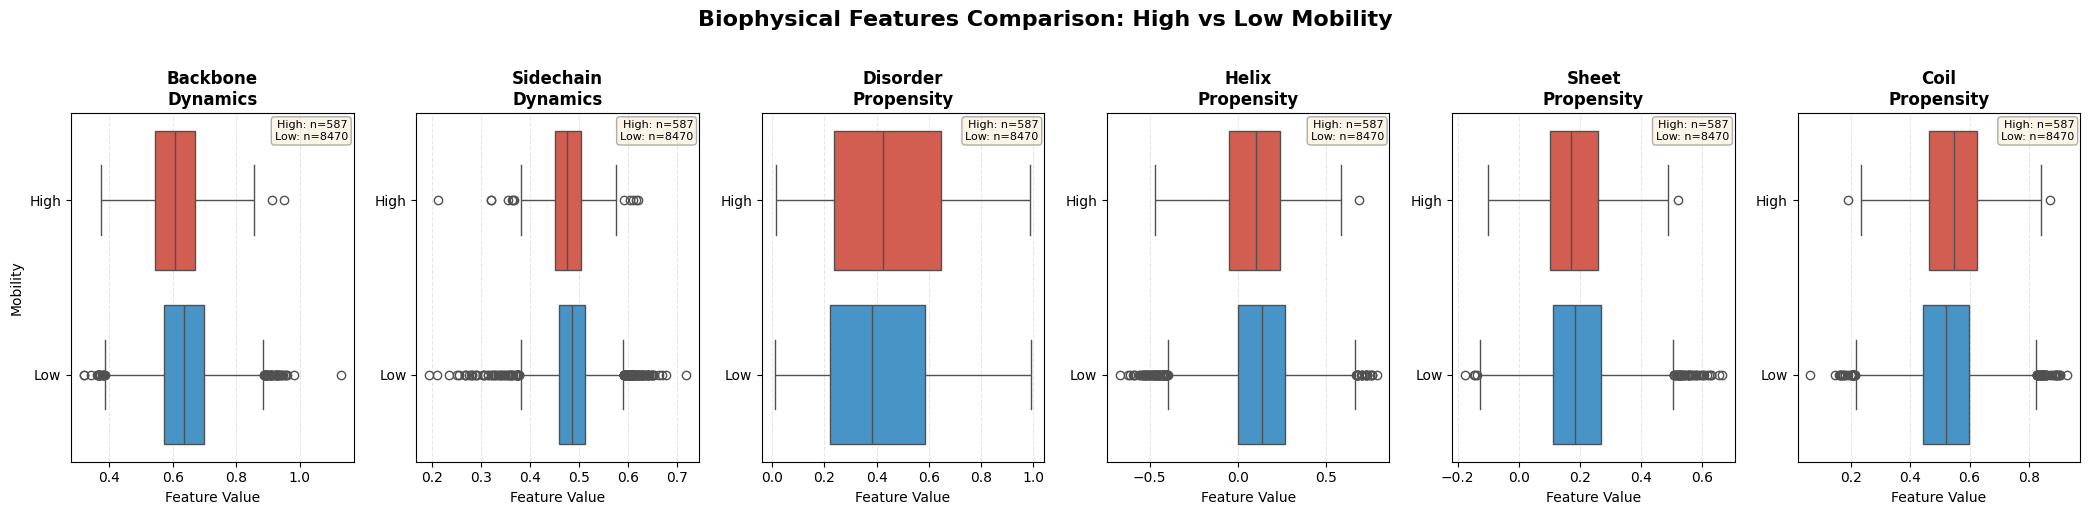


✅ 箱线图生成完成!
  • 特征数量: 6 个
  • 特征列表: ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity']
  • High mobility: n=587
  • Low mobility: n=8470

⚠️  缺失的特征: ['earlyFolding']
  箱线图只包含可用的特征。
  如果需要完整的7个特征,请检查数据提取流程。


In [38]:
# ===== Cell 25: Movement Score箱线图 (自适应版本) =====

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("="*80)
print("生成Movement Score箱线图 (High vs Low Mobility)")
print("="*80)

# [0/2] 检查可用的生物物理特征
print("\n[0/2] 检查可用的生物物理特征...")

# 定义期望的7个特征及其可能的列名变体
expected_features = {
    'backbone_dynamics': ['backbone_dynamics', 'Backbone_Dynamics', 'BackboneDynamics'],
    'sidechain_dynamics': ['sidechain_dynamics', 'Sidechain_Dynamics', 'SidechainDynamics', 'side_chain_dynamics'],
    'disorder_propensity': ['disorder_propensity', 'Disorder_Propensity', 'DisorderPropensity'],
    'helix_propensity': ['helix_propensity', 'Helix_Propensity', 'HelixPropensity'],
    'sheet_propensity': ['sheet_propensity', 'Sheet_Propensity', 'SheetPropensity'],
    'coil_propensity': ['coil_propensity', 'Coil_Propensity', 'CoilPropensity'],
    'earlyFolding': ['earlyFolding', 'early_folding', 'Early_Folding', 'EarlyFolding']
}

# 特征的显示标签
feature_labels_dict = {
    'backbone_dynamics': 'Backbone\nDynamics',
    'sidechain_dynamics': 'Sidechain\nDynamics',
    'disorder_propensity': 'Disorder\nPropensity',
    'helix_propensity': 'Helix\nPropensity',
    'sheet_propensity': 'Sheet\nPropensity',
    'coil_propensity': 'Coil\nPropensity',
    'earlyFolding': 'Early\nFolding'
}

# 检查success_df中实际存在的列
actual_columns = set(success_df.columns)
bio_features = []
feature_labels = []
feature_mapping = {}

for feature_key, possible_names in expected_features.items():
    found = False
    for name in possible_names:
        if name in actual_columns:
            bio_features.append(name)
            feature_labels.append(feature_labels_dict[feature_key])
            feature_mapping[feature_key] = name
            found = True
            print(f"  ✓ {feature_key:25s} → {name}")
            break
    
    if not found:
        print(f"  ✗ {feature_key:25s} → 未找到")

print(f"\n可用特征数量: {len(bio_features)}/7")

if len(bio_features) == 0:
    print("\n❌ 错误: 没有找到任何生物物理特征列!")
    raise ValueError("没有可用的生物物理特征列")

# [1/2] 准备数据
print("\n[1/2] 准备数据...")

# 确保high_mobility和low_mobility已定义
if 'high_mobility' not in globals() or 'low_mobility' not in globals():
    print("  ⚠️  high_mobility或low_mobility未定义,正在重新定义...")
    high_mobility = success_df[success_df['movement_score'] >= 10].copy()
    low_mobility = success_df[success_df['movement_score'] < 5].copy()
    print(f"  ✓ High mobility: n={len(high_mobility)}")
    print(f"  ✓ Low mobility: n={len(low_mobility)}")

high_mobility['Mobility'] = 'High'
low_mobility['Mobility'] = 'Low'
combined_df = pd.concat([high_mobility, low_mobility], ignore_index=True)

# [2/2] 创建箱线图
print("\n[2/2] 创建箱线图...")

# 动态调整图表大小
n_features = len(bio_features)
fig_width = max(12, n_features * 3.5)  # 每个特征至少3.5英寸宽
fig, axes = plt.subplots(1, n_features, figsize=(fig_width, 5))

# 如果只有1个特征,axes不是数组,需要转换
if n_features == 1:
    axes = [axes]

fig.suptitle('Biophysical Features Comparison: High vs Low Mobility', 
             fontsize=16, fontweight='bold', y=1.02)

# 颜色设置
colors = {'High': '#E74C3C', 'Low': '#3498DB'}

# 绘制每个特征的箱线图
for i, (feature, label) in enumerate(zip(bio_features, feature_labels)):
    ax = axes[i]
    
    # 绘制箱线图
    sns.boxplot(data=combined_df, x=feature, y='Mobility', 
                palette=colors, ax=ax, orient='h')
    
    # 设置标题和标签
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Value', fontsize=10)
    ax.set_ylabel('Mobility' if i == 0 else '', fontsize=10)
    
    # 添加样本量
    high_n = len(high_mobility[feature].dropna())
    low_n = len(low_mobility[feature].dropna())
    ax.text(0.98, 0.98, f'High: n={high_n}\nLow: n={low_n}',
            transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # 网格线
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('movement_score_boxplots.png', dpi=300, bbox_inches='tight')
print("  ✓ 箱线图已保存: movement_score_boxplots.png")
plt.show()

print("\n✅ 箱线图生成完成!")
print(f"  • 特征数量: {len(bio_features)} 个")
print(f"  • 特征列表: {bio_features}")
print(f"  • High mobility: n={len(high_mobility)}")
print(f"  • Low mobility: n={len(low_mobility)}")

# 提示缺失的特征
missing_features = []
for feature_key in expected_features.keys():
    if feature_key not in feature_mapping:
        missing_features.append(feature_key)

if missing_features:
    print(f"\n⚠️  缺失的特征: {missing_features}")
    print("  箱线图只包含可用的特征。")
    print("  如果需要完整的7个特征,请检查数据提取流程。")
else:
    print(f"\n✅ 所有7个特征都已包含在箱线图中!")


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 直接加载处理好的数据
final_df = pd.read_pickle("Part4_Ready_Data.pkl")
success_df = final_df # 保持兼容性
print(f"🚀 数据已恢复！包含 {len(final_df)} 行。可以直接运行 Cell 26a/b。")

In [29]:
"""
Cell 1: 数据准备与STY分组
功能: 将高/低移动性组按S/T/Y氨基酸类型拆分
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================================
# 1. 加载数据 (假设您已经运行了之前的代码,生成了final_df)
# ============================================================================
# 如果还没有final_df,请先运行之前的代码生成它
# 这里假设final_df已经在内存中

print("=" * 80)
print("📊 Cell 1: 数据准备与STY分组")
print("=" * 80)

# ============================================================================
# 2. 定义移动性分组逻辑
# ============================================================================
# 根据对话记录,高移动性定义为:在不同时间点和区室之间有转移的位点
# 这里使用ModScore或者根据0/1模式判断

# 定义区室列
compartment_cols = [
    '0min_Cyt', '0min_Mem', '0min_Nuc',
    '2min_Cyt', '2min_Mem', '2min_Nuc', 
    '8min_Cyt', '8min_Mem', '8min_Nuc',
    '20min_Cyt', '20min_Mem', '20min_Nuc',
    '90min_Cyt', '90min_Mem', '90min_Nuc'
]

# 计算每个位点的移动性得分 (出现的区室数量)
def calculate_mobility_score(row):
    """计算位点在不同区室出现的次数"""
    return row[compartment_cols].sum()

final_df['mobility_score'] = final_df.apply(calculate_mobility_score, axis=1)

# 定义高/低移动性阈值
# 根据对话,高移动性约587个,这里使用top 5-10%作为高移动性
mobility_threshold = final_df['mobility_score'].quantile(0.90)  # 可调整

print(f"\n📈 移动性统计:")
print(f"  移动性得分范围: {final_df['mobility_score'].min():.0f} - {final_df['mobility_score'].max():.0f}")
print(f"  移动性阈值 (90th percentile): {mobility_threshold:.1f}")

# 分组
final_df['mobility_group'] = final_df['mobility_score'].apply(
    lambda x: 'High' if x >= mobility_threshold else 'Low'
)

print(f"\n🔢 分组统计:")
print(f"  高移动性组: {(final_df['mobility_group'] == 'High').sum():,} 个位点")
print(f"  低移动性组: {(final_df['mobility_group'] == 'Low').sum():,} 个位点")

# ============================================================================
# 3. 按STY氨基酸类型拆分
# ============================================================================
# 使用AA列 (从原始数据) 或 amino_acid列 (从JSON提取)
aa_column = 'AA' if 'AA' in final_df.columns else 'amino_acid'

print(f"\n🧬 氨基酸类型统计:")
aa_counts = final_df[aa_column].value_counts()
for aa, count in aa_counts.items():
    print(f"  {aa}: {count:,} 个位点")

# 过滤掉缺失值
df_valid = final_df[final_df[aa_column].isin(['S', 'T', 'Y'])].copy()

print(f"\n✅ 有效数据: {len(df_valid):,} 个位点 (S/T/Y)")

# 按STY和mobility分组
groups = {}
for aa in ['S', 'T', 'Y']:
    for mobility in ['High', 'Low']:
        key = f"{aa}_{mobility}"
        groups[key] = df_valid[
            (df_valid[aa_column] == aa) & 
            (df_valid['mobility_group'] == mobility)
        ].copy()
        print(f"  {key}: {len(groups[key]):,} 个位点")

# ============================================================================
# 4. 提取生物物理特征列
# ============================================================================
biophysical_features = [
    'backbone_dynamics',
    'sidechain_dynamics',
    'disorder_propensity', 
    'helix_propensity',
    'sheet_propensity',
    'coil_propensity',
    'earlyFolding'
]

# 检查特征是否存在
missing_features = [f for f in biophysical_features if f not in df_valid.columns]
if missing_features:
    print(f"\n⚠️ 警告: 以下特征缺失: {missing_features}")
    biophysical_features = [f for f in biophysical_features if f in df_valid.columns]

print(f"\n📋 将分析的生物物理特征 ({len(biophysical_features)}个):")
for i, feature in enumerate(biophysical_features, 1):
    print(f"  {i}. {feature}")

# ============================================================================
# 5. 数据质量检查
# ============================================================================
print(f"\n🔍 数据质量检查:")
for feature in biophysical_features:
    valid_count = df_valid[feature].notna().sum()
    missing_count = df_valid[feature].isna().sum()
    print(f"  {feature:25s}: {valid_count:,} 有效 / {missing_count:,} 缺失")

print("\n" + "=" * 80)
print("✅ Cell 1 完成: 数据已按STY分组,共6个数据集准备就绪")
print("=" * 80)


📊 Cell 1: 数据准备与STY分组

📈 移动性统计:
  移动性得分范围: 5 - 15
  移动性阈值 (90th percentile): 15.0

🔢 分组统计:
  高移动性组: 2,375 个位点
  低移动性组: 8,671 个位点

🧬 氨基酸类型统计:
  S: 9,319 个位点
  T: 1,364 个位点
  Y: 363 个位点

✅ 有效数据: 11,046 个位点 (S/T/Y)
  S_High: 2,084 个位点
  S_Low: 7,235 个位点
  T_High: 223 个位点
  T_Low: 1,141 个位点
  Y_High: 68 个位点
  Y_Low: 295 个位点

📋 将分析的生物物理特征 (7个):
  1. backbone_dynamics
  2. sidechain_dynamics
  3. disorder_propensity
  4. helix_propensity
  5. sheet_propensity
  6. coil_propensity
  7. earlyFolding

🔍 数据质量检查:
  backbone_dynamics        : 10,784 有效 / 262 缺失
  sidechain_dynamics       : 10,784 有效 / 262 缺失
  disorder_propensity      : 10,784 有效 / 262 缺失
  helix_propensity         : 10,784 有效 / 262 缺失
  sheet_propensity         : 10,784 有效 / 262 缺失
  coil_propensity          : 10,784 有效 / 262 缺失
  earlyFolding             : 10,784 有效 / 262 缺失

✅ Cell 1 完成: 数据已按STY分组,共6个数据集准备就绪


In [25]:
"""
Cell 2: KS统计检验函数
功能: 实现随机抽样+KS检验,解决样本不平衡问题
"""

import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("📊 Cell 2: KS统计检验函数")
print("=" * 80)

# ============================================================================
# KS统计检验函数
# ============================================================================

def perform_ks_test_with_resampling(high_mobility_data, low_mobility_data, 
                                     n_iterations=10, random_state=42):
    """
    使用随机抽样进行KS检验,解决样本不平衡问题
    
    参数:
        high_mobility_data: 高移动性组的数据 (Series或array)
        low_mobility_data: 低移动性组的数据 (Series或array)
        n_iterations: 随机抽样的次数 (默认10次)
        random_state: 随机种子
        
    返回:
        dict: 包含KS统计量、p值、平均KS统计量等信息
    """
    
    # 移除缺失值
    high_data = high_mobility_data.dropna() if hasattr(high_mobility_data, 'dropna') else high_mobility_data[~np.isnan(high_mobility_data)]
    low_data = low_mobility_data.dropna() if hasattr(low_mobility_data, 'dropna') else low_mobility_data[~np.isnan(low_mobility_data)]
    
    # 检查数据是否足够
    if len(high_data) < 5 or len(low_data) < 5:
        return {
            'ks_statistic': np.nan,
            'p_value': np.nan,
            'mean_ks': np.nan,
            'std_ks': np.nan,
            'significant': False,
            'error': 'insufficient_data'
        }
    
    # 样本量
    n_high = len(high_data)
    n_low = len(low_data)
    
    # 如果高移动性组样本量更大,交换
    if n_high > n_low:
        high_data, low_data = low_data, high_data
        n_high, n_low = n_low, n_high
    
    # 进行多次随机抽样
    np.random.seed(random_state)
    ks_statistics = []
    p_values = []
    
    for i in range(n_iterations):
        # 从大样本组随机抽样,匹配小样本组的数量
        sampled_low = np.random.choice(low_data, size=n_high, replace=False)
        
        # 进行KS检验
        ks_stat, p_val = stats.ks_2samp(high_data, sampled_low)
        ks_statistics.append(ks_stat)
        p_values.append(p_val)
    
    # 计算平均值
    mean_ks = np.mean(ks_statistics)
    std_ks = np.std(ks_statistics)
    mean_p = np.mean(p_values)
    
    # 判断显著性 (使用平均p值)
    if mean_p < 0.001:
        sig_level = '***'
        significant = True
    elif mean_p < 0.01:
        sig_level = '**'
        significant = True
    elif mean_p < 0.05:
        sig_level = '*'
        significant = True
    else:
        sig_level = 'ns'
        significant = False
    
    return {
        'ks_statistic': mean_ks,
        'p_value': mean_p,
        'mean_ks': mean_ks,
        'std_ks': std_ks,
        'all_ks': ks_statistics,
        'all_p': p_values,
        'significant': significant,
        'sig_level': sig_level,
        'n_high': n_high,
        'n_low': n_low,
        'n_iterations': n_iterations
    }


def format_pvalue(p):
    """格式化p值显示"""
    if np.isnan(p):
        return "N/A"
    elif p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return f"p = {p:.3f}"
    else:
        return f"p = {p:.2f}"


# ============================================================================
# 测试KS检验函数
# ============================================================================

print("\n🧪 测试KS检验函数...")

# 生成测试数据
np.random.seed(42)
test_high = np.random.normal(0.5, 0.1, 100)  # 高移动性组: 均值0.5
test_low = np.random.normal(0.4, 0.1, 1000)  # 低移动性组: 均值0.4

# 执行KS检验
result = perform_ks_test_with_resampling(test_high, test_low, n_iterations=10)

print(f"\n📈 测试结果:")
print(f"  高移动性组样本量: {result['n_high']}")
print(f"  低移动性组样本量: {result['n_low']}")
print(f"  KS统计量 (平均): {result['ks_statistic']:.4f} ± {result['std_ks']:.4f}")
print(f"  P值 (平均): {format_pvalue(result['p_value'])}")
print(f"  显著性: {result['sig_level']}")
print(f"  是否显著: {'是' if result['significant'] else '否'}")

print("\n" + "=" * 80)
print("✅ Cell 2 完成: KS检验函数已准备就绪")
print("=" * 80)


📊 Cell 2: KS统计检验函数

🧪 测试KS检验函数...

📈 测试结果:
  高移动性组样本量: 100
  低移动性组样本量: 1000
  KS统计量 (平均): 0.4240 ± 0.0488
  P值 (平均): p < 0.001
  显著性: ***
  是否显著: 是

✅ Cell 2 完成: KS检验函数已准备就绪


📊 Cell 3: 按STY拆分的Box Plot可视化

📈 开始绘制按STY拆分的Box Plot...
✅ 图片已保存: STY_Biophysical_Features_BoxPlot.png


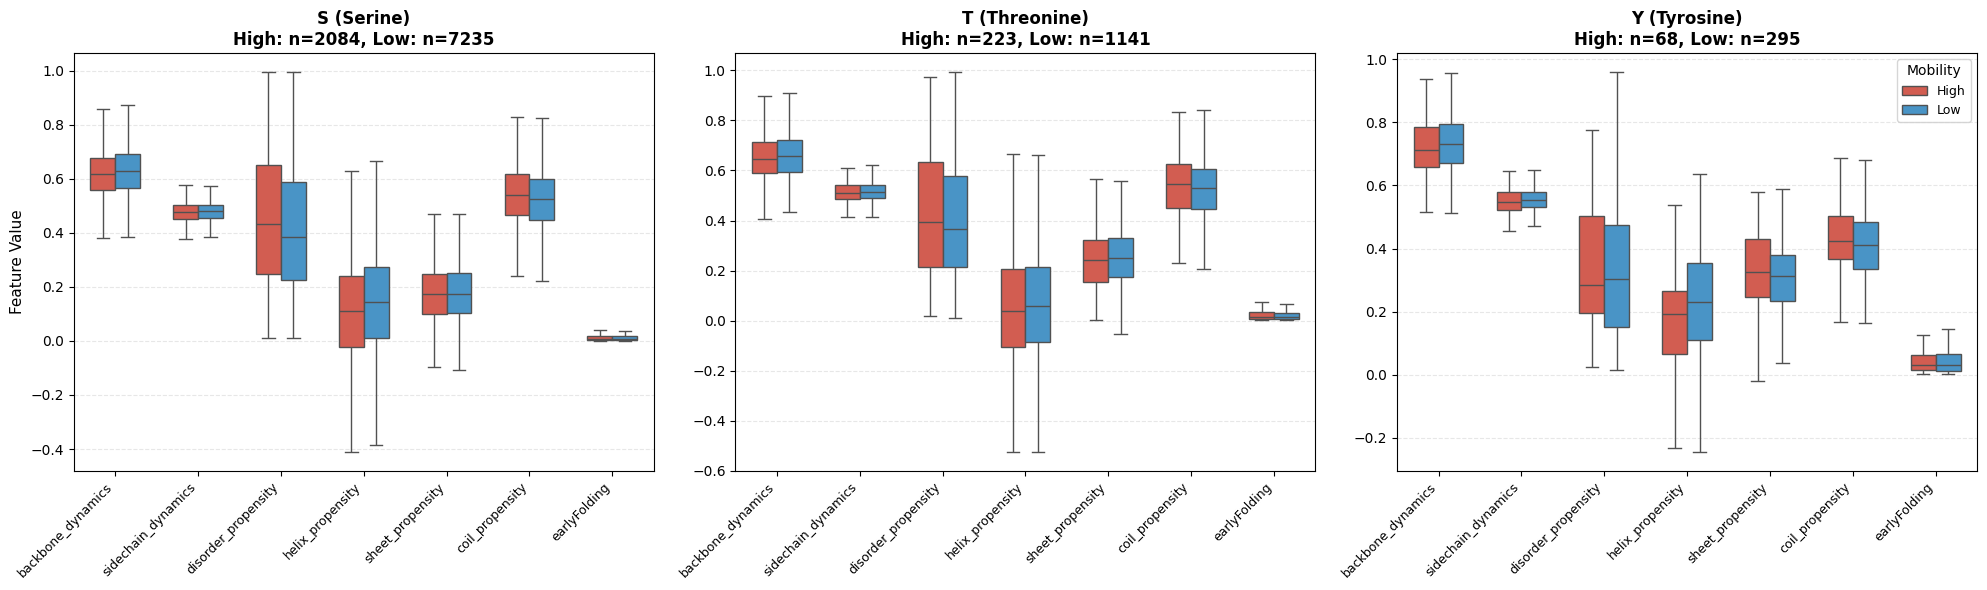


✅ Cell 3 完成: Box Plot已生成


In [26]:
"""
Cell 3: 按STY拆分的Box Plot + KS统计检验
功能: 生成1行3列的subplot,比较S/T/Y的高/低移动性组
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 80)
print("📊 Cell 3: 按STY拆分的Box Plot可视化")
print("=" * 80)

# ============================================================================
# 1. 准备绘图数据
# ============================================================================

def prepare_plot_data(groups, biophysical_features, aa_type):
    """
    准备单个氨基酸类型的绘图数据
    
    参数:
        groups: 包含所有分组数据的字典
        biophysical_features: 要分析的特征列表
        aa_type: 氨基酸类型 ('S', 'T', 'Y')
        
    返回:
        DataFrame: 长格式数据,适合seaborn绘图
    """
    
    plot_data = []
    
    for mobility in ['High', 'Low']:
        key = f"{aa_type}_{mobility}"
        df = groups[key]
        
        for feature in biophysical_features:
            values = df[feature].dropna()
            for val in values:
                plot_data.append({
                    'Feature': feature,
                    'Value': val,
                    'Mobility': mobility,
                    'AA': aa_type
                })
    
    return pd.DataFrame(plot_data)


# ============================================================================
# 2. 绘制按STY拆分的Box Plot
# ============================================================================

def plot_sty_boxplots(groups, biophysical_features, figsize=(20, 5), 
                       save_path=None, dpi=300):
    """
    绘制按S/T/Y拆分的box plot,并添加KS检验结果
    
    参数:
        groups: 包含所有分组数据的字典
        biophysical_features: 要分析的特征列表
        figsize: 图片大小
        save_path: 保存路径 (可选)
        dpi: 分辨率
    """
    
    # 创建子图
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    amino_acids = ['S', 'T', 'Y']
    colors = {'High': '#E74C3C', 'Low': '#3498DB'}  # 红色=高移动性, 蓝色=低移动性
    
    for idx, aa in enumerate(amino_acids):
        ax = axes[idx]
        
        # 准备数据
        plot_df = prepare_plot_data(groups, biophysical_features, aa)
        
        if len(plot_df) == 0:
            ax.text(0.5, 0.5, f'No data for {aa}', 
                   ha='center', va='center', fontsize=14)
            ax.set_title(f'{aa} (Serine)' if aa == 'S' else 
                        f'{aa} (Threonine)' if aa == 'T' else 
                        f'{aa} (Tyrosine)', fontsize=14, fontweight='bold')
            continue
        
        # 绘制box plot
        sns.boxplot(data=plot_df, x='Feature', y='Value', hue='Mobility',
                   palette=colors, ax=ax, showfliers=False, width=0.6)
        
        # 添加数据点 (可选,如果数据量不大)
        # sns.stripplot(data=plot_df, x='Feature', y='Value', hue='Mobility',
        #              palette=colors, ax=ax, dodge=True, alpha=0.3, size=2)
        
        # 设置标题
        aa_name = 'Serine' if aa == 'S' else 'Threonine' if aa == 'T' else 'Tyrosine'
        n_high = len(groups[f'{aa}_High'])
        n_low = len(groups[f'{aa}_Low'])
        ax.set_title(f'{aa} ({aa_name})\nHigh: n={n_high}, Low: n={n_low}', 
                    fontsize=12, fontweight='bold')
        
        # 设置轴标签
        ax.set_xlabel('')
        ax.set_ylabel('Feature Value' if idx == 0 else '', fontsize=11)
        
        # 旋转x轴标签
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        
        # 调整图例
        if idx == 2:  # 只在最右边显示图例
            ax.legend(title='Mobility', loc='upper right', fontsize=9)
        else:
            ax.get_legend().remove()
        
        # 添加网格
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"✅ 图片已保存: {save_path}")
    
    plt.show()
    
    return fig


# ============================================================================
# 3. 执行绘图
# ============================================================================

print("\n📈 开始绘制按STY拆分的Box Plot...")

# 绘制图表
fig = plot_sty_boxplots(
    groups=groups,
    biophysical_features=biophysical_features,
    figsize=(20, 6),
    save_path='STY_Biophysical_Features_BoxPlot.png',
    dpi=300
)

print("\n" + "=" * 80)
print("✅ Cell 3 完成: Box Plot已生成")
print("=" * 80)


📊 Cell 4: 添加统计显著性标注

🔬 计算KS统计量...

📋 KS检验结果汇总:
AA             Feature  KS_statistic  p_value sig_level  significant  n_high  n_low
 S   backbone_dynamics      0.062642 0.002426        **         True    2029   7069
 S  sidechain_dynamics      0.035880 0.220571        ns        False    2029   7069
 S disorder_propensity      0.070971 0.000270       ***         True    2029   7069
 S    helix_propensity      0.086447 0.000003       ***         True    2029   7069
 S    sheet_propensity      0.024199 0.601324        ns        False    2029   7069
 S     coil_propensity      0.067767 0.000993       ***         True    2029   7069
 S        earlyFolding      0.023361 0.645040        ns        False    2029   7069
 T   backbone_dynamics      0.112558 0.180518        ns        False     215   1118
 T  sidechain_dynamics      0.111628 0.232959        ns        False     215   1118
 T disorder_propensity      0.092093 0.379892        ns        False     215   1118
 T    helix_propensity      0

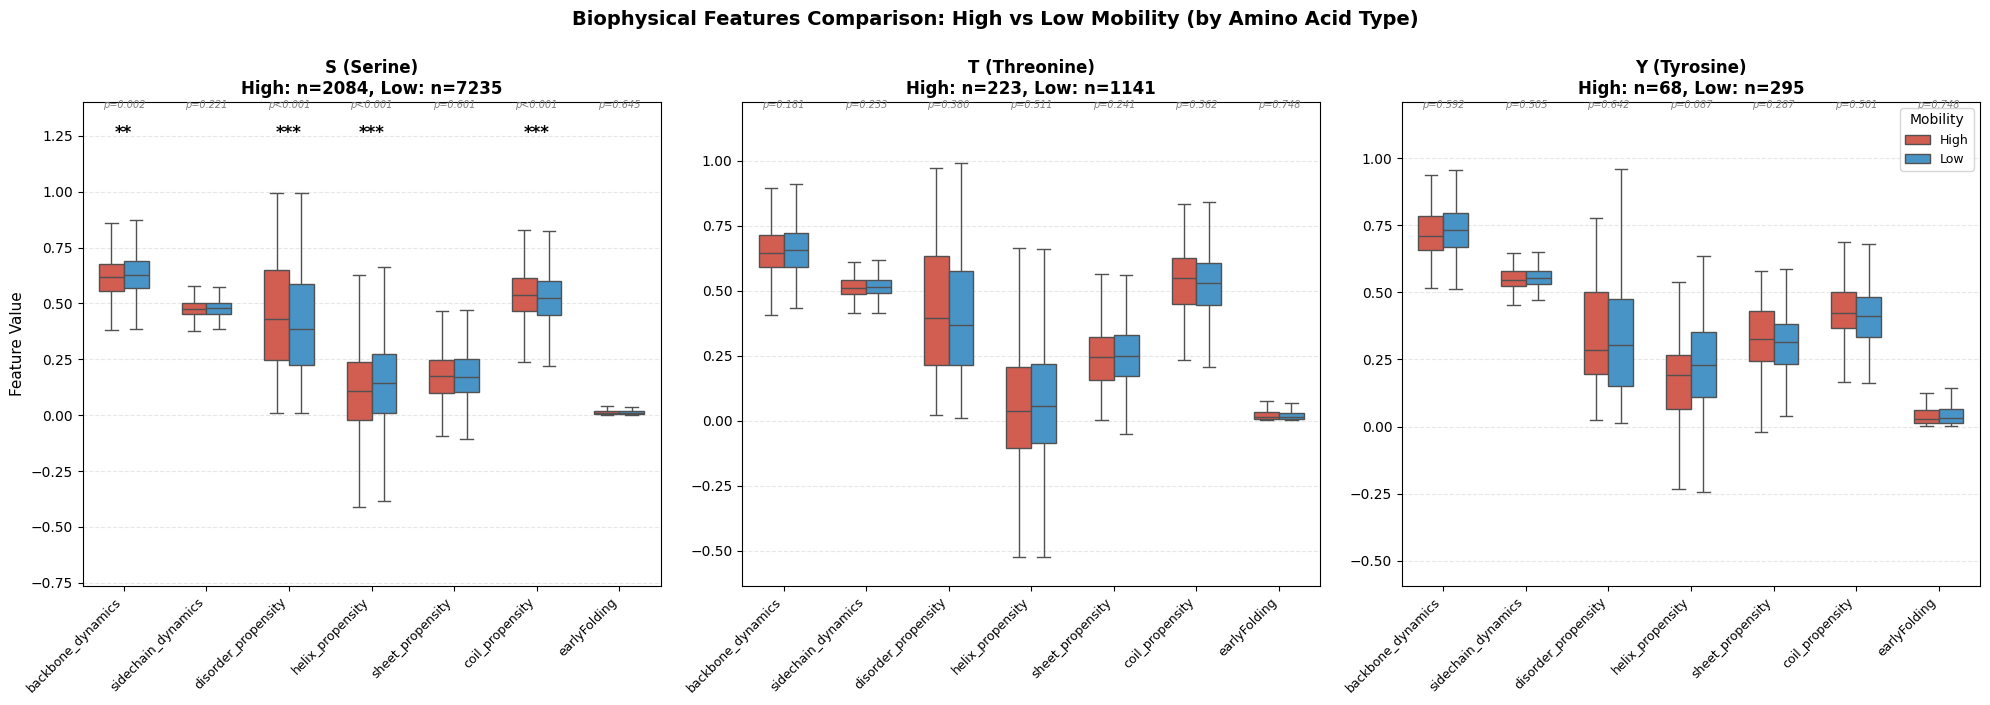


💾 KS统计结果已保存: KS_Statistics_Results.csv

✅ Cell 4 完成: 统计标注已添加


In [27]:
"""
Cell 4: 添加统计显著性标注
功能: 在box plot上添加KS检验结果和显著性标记
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle

print("=" * 80)
print("📊 Cell 4: 添加统计显著性标注")
print("=" * 80)

# ============================================================================
# 1. 计算所有特征的KS统计量
# ============================================================================

def calculate_all_ks_statistics(groups, biophysical_features):
    """
    计算所有S/T/Y × 特征组合的KS统计量
    
    返回:
        DataFrame: 包含所有KS检验结果
    """
    
    results = []
    
    for aa in ['S', 'T', 'Y']:
        high_key = f'{aa}_High'
        low_key = f'{aa}_Low'
        
        for feature in biophysical_features:
            # 提取数据
            high_data = groups[high_key][feature]
            low_data = groups[low_key][feature]
            
            # 执行KS检验
            ks_result = perform_ks_test_with_resampling(
                high_data, low_data, n_iterations=10
            )
            
            results.append({
                'AA': aa,
                'Feature': feature,
                'KS_statistic': ks_result['ks_statistic'],
                'p_value': ks_result['p_value'],
                'sig_level': ks_result['sig_level'],
                'significant': ks_result['significant'],
                'n_high': ks_result['n_high'],
                'n_low': ks_result['n_low']
            })
    
    return pd.DataFrame(results)


# 计算KS统计量
print("\n🔬 计算KS统计量...")
ks_results_df = calculate_all_ks_statistics(groups, biophysical_features)

print(f"\n📋 KS检验结果汇总:")
print(ks_results_df.to_string(index=False))

# 统计显著性
sig_count = ks_results_df['significant'].sum()
total_count = len(ks_results_df)
print(f"\n📊 显著性统计:")
print(f"  显著的比较: {sig_count} / {total_count} ({sig_count/total_count*100:.1f}%)")


# ============================================================================
# 2. 绘制带统计标注的Box Plot
# ============================================================================

def plot_sty_boxplots_with_stats(groups, biophysical_features, ks_results_df,
                                  figsize=(20, 6), save_path=None, dpi=300):
    """
    绘制带KS统计标注的box plot
    """
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    amino_acids = ['S', 'T', 'Y']
    colors = {'High': '#E74C3C', 'Low': '#3498DB'}
    
    for idx, aa in enumerate(amino_acids):
        ax = axes[idx]
        
        # 准备数据
        plot_df = prepare_plot_data(groups, biophysical_features, aa)
        
        if len(plot_df) == 0:
            continue
        
        # 绘制box plot
        sns.boxplot(data=plot_df, x='Feature', y='Value', hue='Mobility',
                   palette=colors, ax=ax, showfliers=False, width=0.6)
        
        # 获取该氨基酸的KS结果
        aa_ks = ks_results_df[ks_results_df['AA'] == aa]
        
        # 添加显著性标记
        feature_positions = {feat: i for i, feat in enumerate(biophysical_features)}
        y_max = plot_df['Value'].max()
        y_min = plot_df['Value'].min()
        y_range = y_max - y_min
        
        for _, row in aa_ks.iterrows():
            feature = row['Feature']
            sig_level = row['sig_level']
            p_value = row['p_value']
            
            if feature not in feature_positions:
                continue
            
            x_pos = feature_positions[feature]
            
            # 计算标注位置
            y_pos = y_max + y_range * 0.05
            
            # 添加显著性星号
            if sig_level != 'ns':
                ax.text(x_pos, y_pos, sig_level, 
                       ha='center', va='bottom', fontsize=12, 
                       fontweight='bold', color='black')
            
            # 添加p值 (小字)
            if not np.isnan(p_value):
                p_text = f'p={p_value:.3f}' if p_value >= 0.001 else 'p<0.001'
                ax.text(x_pos, y_pos + y_range * 0.08, p_text,
                       ha='center', va='bottom', fontsize=7, 
                       color='gray', style='italic')
        
        # 设置标题
        aa_name = 'Serine' if aa == 'S' else 'Threonine' if aa == 'T' else 'Tyrosine'
        n_high = len(groups[f'{aa}_High'])
        n_low = len(groups[f'{aa}_Low'])
        ax.set_title(f'{aa} ({aa_name})\nHigh: n={n_high}, Low: n={n_low}', 
                    fontsize=12, fontweight='bold')
        
        # 设置轴标签
        ax.set_xlabel('')
        ax.set_ylabel('Feature Value' if idx == 0 else '', fontsize=11)
        
        # 旋转x轴标签
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        
        # 调整y轴范围,为标注留空间
        ax.set_ylim(y_min - y_range * 0.05, y_max + y_range * 0.15)
        
        # 调整图例
        if idx == 2:
            ax.legend(title='Mobility', loc='upper right', fontsize=9)
        else:
            ax.get_legend().remove()
        
        # 添加网格
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    # 添加总标题
    fig.suptitle('Biophysical Features Comparison: High vs Low Mobility (by Amino Acid Type)', 
                fontsize=14, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"✅ 图片已保存: {save_path}")
    
    plt.show()
    
    return fig


# ============================================================================
# 3. 执行绘图
# ============================================================================

print("\n📈 绘制带统计标注的Box Plot...")

fig = plot_sty_boxplots_with_stats(
    groups=groups,
    biophysical_features=biophysical_features,
    ks_results_df=ks_results_df,
    figsize=(20, 7),
    save_path='STY_Biophysical_Features_BoxPlot_with_Stats.png',
    dpi=300
)

# ============================================================================
# 4. 保存KS统计结果到CSV
# ============================================================================

ks_results_df.to_csv('KS_Statistics_Results.csv', index=False)
print(f"\n💾 KS统计结果已保存: KS_Statistics_Results.csv")

print("\n" + "=" * 80)
print("✅ Cell 4 完成: 统计标注已添加")
print("=" * 80)


📊 Cell 5: Feature Map可视化

🔬 计算蛋白质mobility ratio...

📋 Top 20 蛋白质 (按high/low ratio排序, 已排除CD3EAP):
   Gene  n_total  n_high  n_low  high_low_ratio  has_high_mobility
  CDK12       13      12      1            12.0               True
  SUDS3       10       9      1             9.0               True
   SRRT        8       8      0             8.0               True
   BAG6        7       6      1             6.0               True
  SRSF6        6       6      0             6.0               True
 RAVER1        6       6      0             6.0               True
  RPLP2        6       5      1             5.0               True
 SRSF11        6       5      1             5.0               True
   CDK1        5       5      0             5.0               True
  MEF2D        5       5      0             5.0               True
   EPN1        6       5      1             5.0               True
  KANK2        5       4      1             4.0               True
  NOC2L        4       4      0 

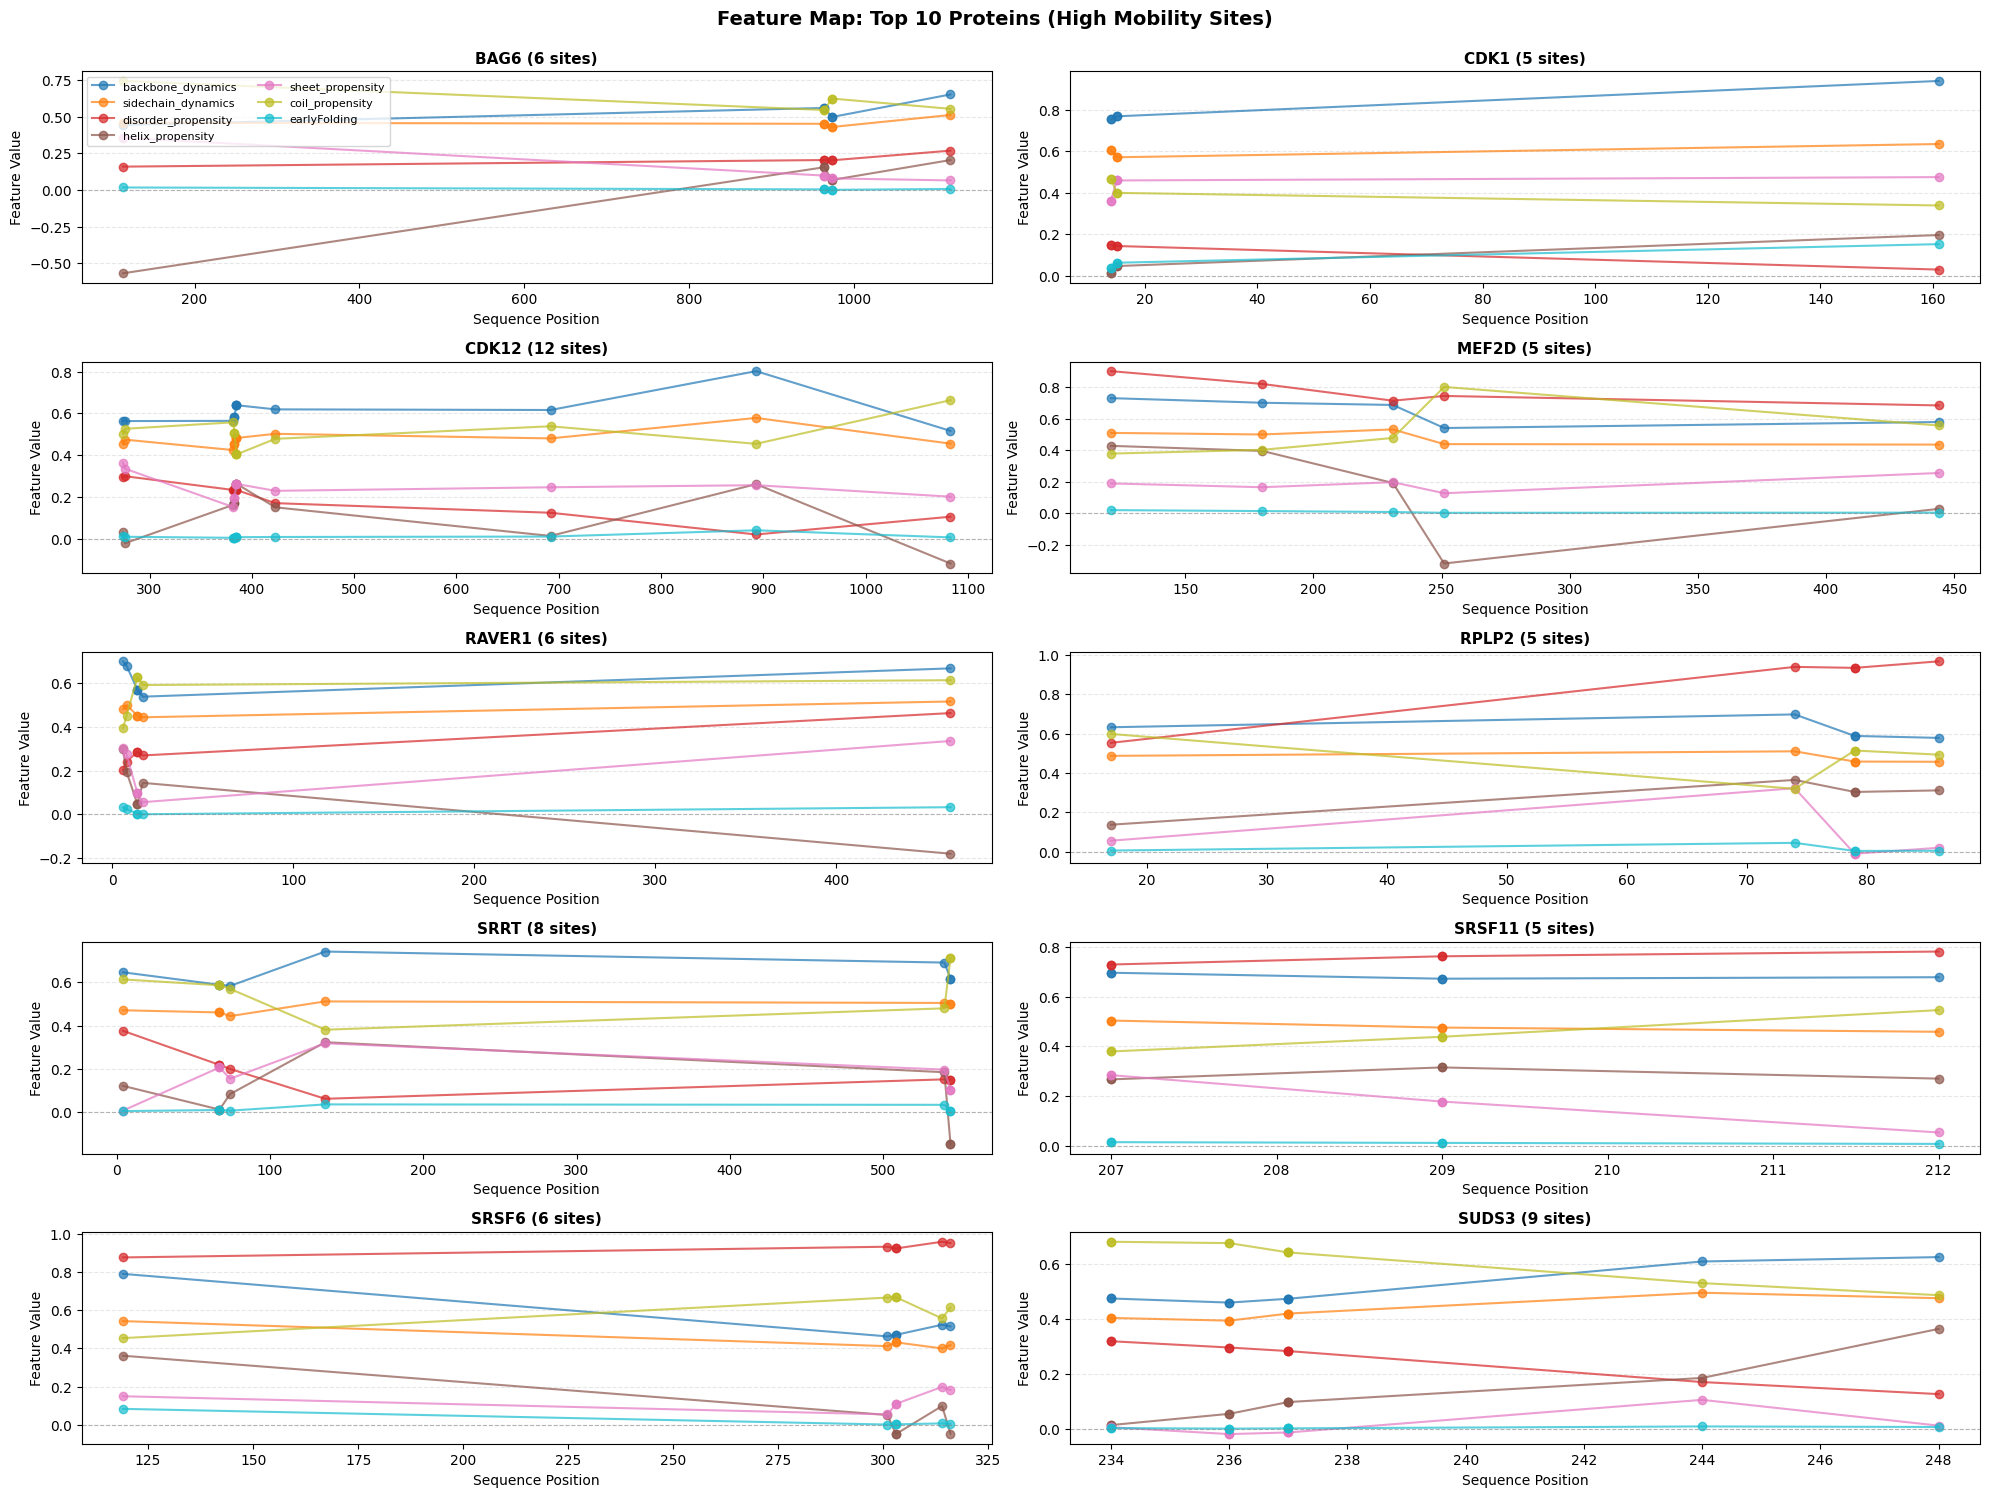


📈 绘制Feature Map (方案B: 所有蛋白质叠加)...
✅ Feature Map (Overlay)已保存: Feature_Map_Overlay.png


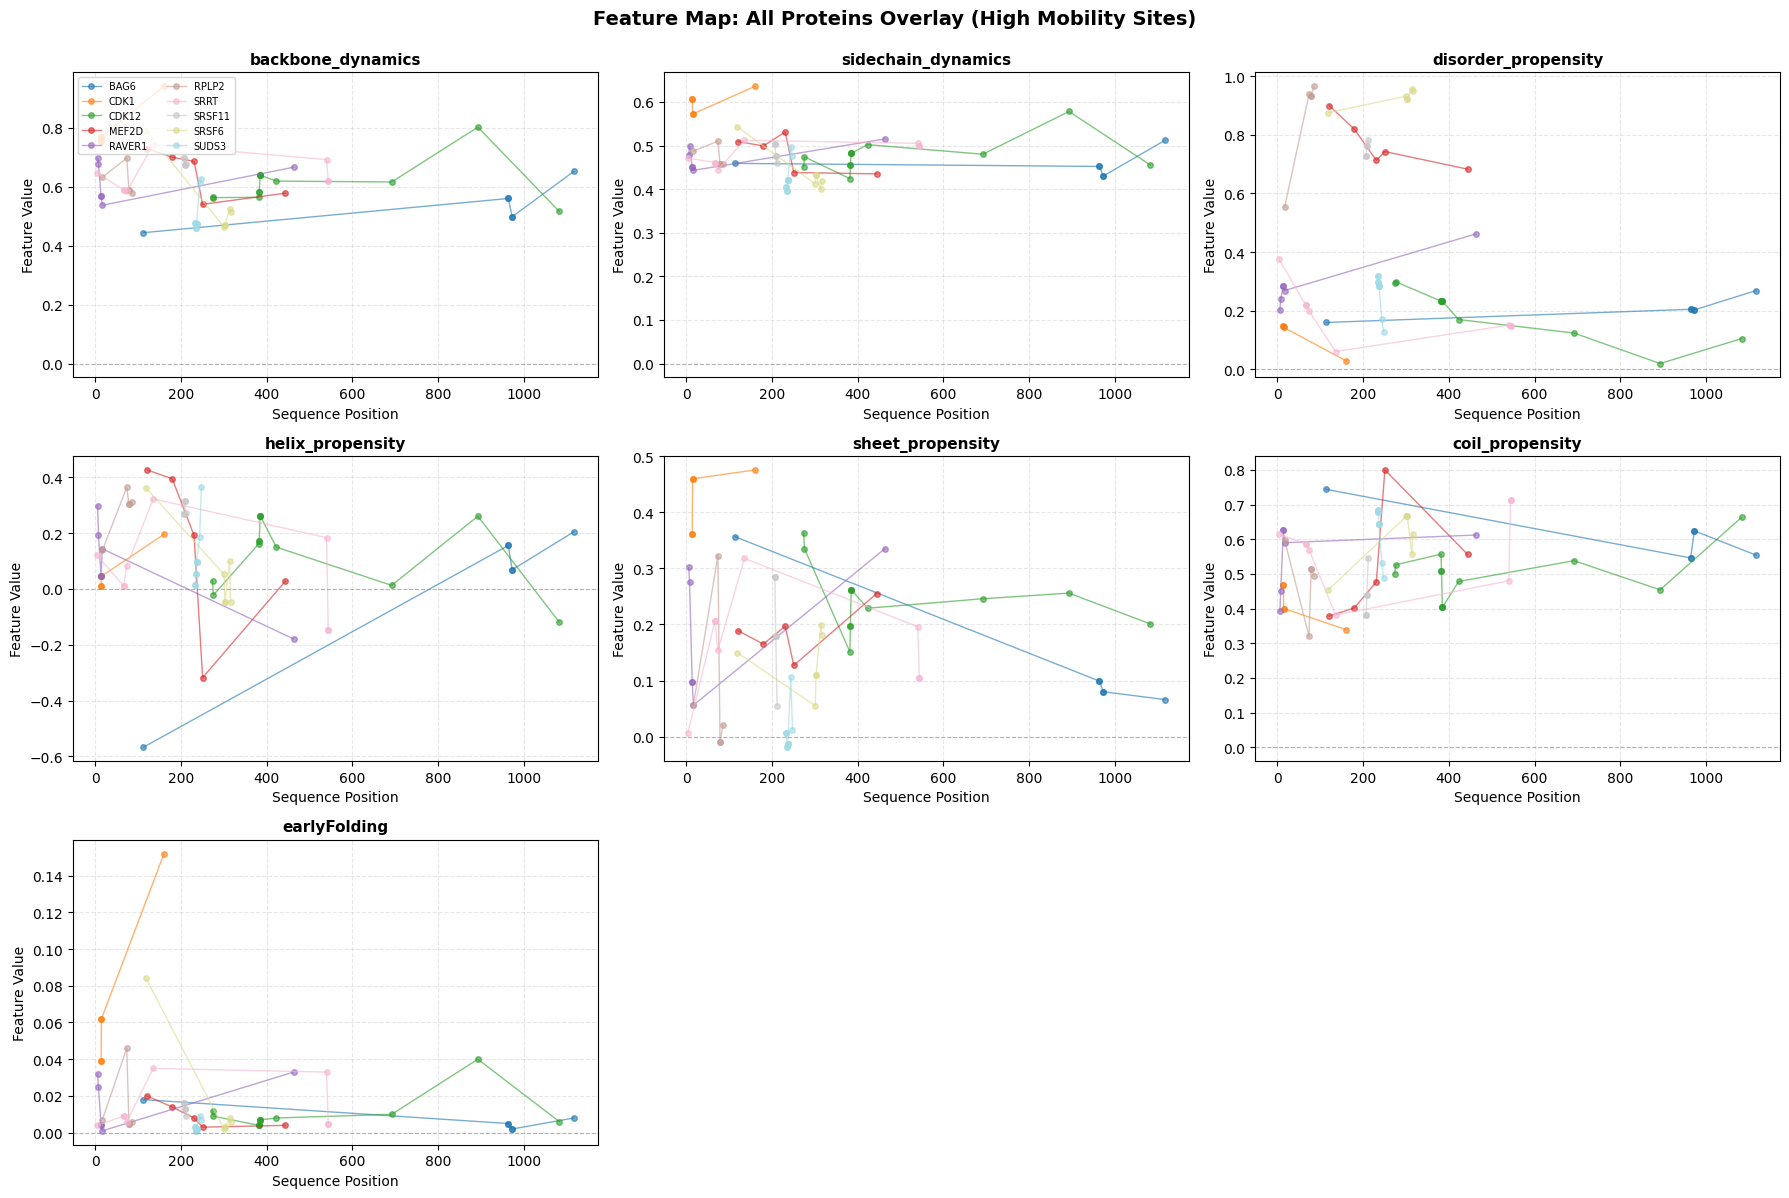


💾 蛋白质统计已保存: Protein_Mobility_Statistics.csv
💾 Top蛋白质位点特征已保存: Top_Proteins_Sites_Features.csv

✅ Cell 5 完成: Feature Map已生成
   方案A: 每个蛋白质一个subplot - Feature_Map_Subplots.png
   方案B: 所有蛋白质叠加 - Feature_Map_Overlay.png


In [31]:
"""
Cell 5: Feature Map可视化 (最终版)
功能: 展示top蛋白质的磷酸化位点在序列上的特征分布
更新: 直接排除CD3EAP(原始数据缺少Position信息)
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 80)
print("📊 Cell 5: Feature Map可视化")
print("=" * 80)

# ============================================================================
# 1. 计算每个蛋白质(基因)的high/low ratio
# ============================================================================

print("\n🔬 计算蛋白质mobility ratio...")

def calculate_protein_mobility_ratio(df_valid):
    """计算每个蛋白质的high/low mobility ratio"""
    
    protein_stats = []
    
    for gene in df_valid['Gene'].unique():
        gene_df = df_valid[df_valid['Gene'] == gene]
        
        n_total = len(gene_df)
        n_high = (gene_df['mobility_group'] == 'High').sum()
        n_low = (gene_df['mobility_group'] == 'Low').sum()
        
        # 计算ratio (避免除以0)
        if n_low > 0:
            ratio = n_high / n_low
        else:
            ratio = n_high if n_high > 0 else 0
        
        protein_stats.append({
            'Gene': gene,
            'n_total': n_total,
            'n_high': n_high,
            'n_low': n_low,
            'high_low_ratio': ratio,
            'has_high_mobility': n_high > 0
        })
    
    return pd.DataFrame(protein_stats)


protein_stats_df = calculate_protein_mobility_ratio(df_valid)

# 只保留有高移动性位点的蛋白质
protein_stats_df = protein_stats_df[protein_stats_df['has_high_mobility']].copy()

# 直接排除CD3EAP (原始数据缺少Position信息)
protein_stats_df = protein_stats_df[protein_stats_df['Gene'] != 'CD3EAP'].copy()

# 按ratio排序
protein_stats_df = protein_stats_df.sort_values('high_low_ratio', ascending=False)

print(f"\n📋 Top 20 蛋白质 (按high/low ratio排序, 已排除CD3EAP):")
print(protein_stats_df.head(20).to_string(index=False))


# ============================================================================
# 2. 提取Top蛋白质的位点数据
# ============================================================================

print("\n🎯 提取Top蛋白质的位点数据...")

def extract_top_proteins_sites(df_valid, top_genes, biophysical_features, 
                                 mobility_group='High'):
    """提取top蛋白质的高移动性位点数据"""
    
    # 筛选数据
    top_df = df_valid[
        (df_valid['Gene'].isin(top_genes)) & 
        (df_valid['mobility_group'] == mobility_group)
    ].copy()
    
    # 确保有Position列
    if 'Position' not in top_df.columns and 'sequence_position' in top_df.columns:
        top_df['Position'] = top_df['sequence_position']
    
    # 选择需要的列
    cols_to_keep = ['Gene', 'Site', 'Position', 'AA'] + biophysical_features
    top_df = top_df[cols_to_keep].copy()
    
    # 按基因和位置排序
    top_df = top_df.sort_values(['Gene', 'Position'])
    
    return top_df


# 选择top 10个蛋白质
n_top = 10
top_genes = protein_stats_df.head(n_top)['Gene'].tolist()

print(f"\n🎯 选择的Top {n_top}个蛋白质:")
print(f"\n挑选原则: 按high/low mobility ratio从高到低排序,选择高移动性位点相对富集程度最高的蛋白质。\n")
for i, gene in enumerate(top_genes, 1):
    ratio = protein_stats_df[protein_stats_df['Gene'] == gene]['high_low_ratio'].values[0]
    n_high = protein_stats_df[protein_stats_df['Gene'] == gene]['n_high'].values[0]
    n_total = protein_stats_df[protein_stats_df['Gene'] == gene]['n_total'].values[0]
    print(f"  {i:2d}. {gene:15s} - Ratio: {ratio:.2f}, High: {n_high}/{n_total}")

# 提取高移动性组的位点数据
top_sites_df = extract_top_proteins_sites(
    df_valid, top_genes, biophysical_features, mobility_group='High'
)

print(f"\n📊 提取的位点数据: {len(top_sites_df)} 个高移动性位点")


# ============================================================================
# 3. 绘制Feature Map - 方案A: 每个蛋白质一个subplot
# ============================================================================

def plot_feature_map_subplots(top_sites_df, biophysical_features, 
                               figsize=(20, 12), save_path=None, dpi=300):
    """绘制Feature Map: 每个蛋白质一个subplot"""
    
    genes = top_sites_df['Gene'].unique()
    n_genes = len(genes)
    
    # 计算subplot布局
    n_cols = 2
    n_rows = (n_genes + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_genes > 1 else [axes]
    
    # 为每个特征分配颜色
    colors = plt.cm.tab10(np.linspace(0, 1, len(biophysical_features)))
    feature_colors = dict(zip(biophysical_features, colors))
    
    for idx, gene in enumerate(genes):
        ax = axes[idx]
        
        # 提取该蛋白质的数据
        gene_df = top_sites_df[top_sites_df['Gene'] == gene].copy()
        
        # 绘制每个特征
        for feature in biophysical_features:
            positions = gene_df['Position'].values
            values = gene_df[feature].values
            
            # 绘制线图+散点
            ax.plot(positions, values, 'o-', 
                   color=feature_colors[feature], 
                   label=feature, 
                   markersize=6, 
                   linewidth=1.5,
                   alpha=0.7)
        
        # 添加零线
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # 设置标题和标签
        n_sites = len(gene_df)
        ax.set_title(f'{gene} ({n_sites} sites)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Sequence Position', fontsize=10)
        ax.set_ylabel('Feature Value', fontsize=10)
        
        # 添加网格
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        # 只在第一个subplot显示图例
        if idx == 0:
            ax.legend(loc='upper left', fontsize=8, ncol=2)
    
    # 隐藏多余的subplot
    for idx in range(n_genes, len(axes)):
        axes[idx].axis('off')
    
    # 总标题
    fig.suptitle(f'Feature Map: Top {n_genes} Proteins (High Mobility Sites)', 
                fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"✅ Feature Map已保存: {save_path}")
    
    plt.show()
    
    return fig


# ============================================================================
# 4. 绘制Feature Map - 方案B: 所有蛋白质叠加
# ============================================================================

def plot_feature_map_overlay(top_sites_df, biophysical_features, 
                              figsize=(20, 10), save_path=None, dpi=300):
    """绘制Feature Map: 所有蛋白质叠加在一起"""
    
    n_features = len(biophysical_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    genes = top_sites_df['Gene'].unique()
    gene_colors = plt.cm.tab20(np.linspace(0, 1, len(genes)))
    gene_color_map = dict(zip(genes, gene_colors))
    
    for idx, feature in enumerate(biophysical_features):
        ax = axes[idx]
        
        # 绘制每个蛋白质
        for gene in genes:
            gene_df = top_sites_df[top_sites_df['Gene'] == gene].copy()
            
            positions = gene_df['Position'].values
            values = gene_df[feature].values
            
            ax.plot(positions, values, 'o-', 
                   color=gene_color_map[gene], 
                   label=gene if idx == 0 else '', 
                   markersize=4, 
                   linewidth=1,
                   alpha=0.6)
        
        # 添加零线
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # 设置标题和标签
        ax.set_title(feature, fontsize=11, fontweight='bold')
        ax.set_xlabel('Sequence Position', fontsize=10)
        ax.set_ylabel('Feature Value', fontsize=10)
        
        # 添加网格
        ax.grid(axis='both', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    # 隐藏多余的subplot
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    # 添加图例(在第一个subplot)
    if len(genes) <= 10:
        axes[0].legend(loc='upper left', fontsize=7, ncol=2)
    
    # 总标题
    fig.suptitle(f'Feature Map: All Proteins Overlay (High Mobility Sites)', 
                fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"✅ Feature Map (Overlay)已保存: {save_path}")
    
    plt.show()
    
    return fig


# ============================================================================
# 5. 执行绘图
# ============================================================================

print("\n📈 绘制Feature Map (方案A: 每个蛋白质一个subplot)...")
fig1 = plot_feature_map_subplots(
    top_sites_df=top_sites_df,
    biophysical_features=biophysical_features,
    figsize=(20, 15),
    save_path='Feature_Map_Subplots.png',
    dpi=300
)

print("\n📈 绘制Feature Map (方案B: 所有蛋白质叠加)...")
fig2 = plot_feature_map_overlay(
    top_sites_df=top_sites_df,
    biophysical_features=biophysical_features,
    figsize=(18, 12),
    save_path='Feature_Map_Overlay.png',
    dpi=300
)


# ============================================================================
# 6. 保存数据
# ============================================================================

protein_stats_df.to_csv('Protein_Mobility_Statistics.csv', index=False)
print(f"\n💾 蛋白质统计已保存: Protein_Mobility_Statistics.csv")

top_sites_df.to_csv('Top_Proteins_Sites_Features.csv', index=False)
print(f"💾 Top蛋白质位点特征已保存: Top_Proteins_Sites_Features.csv")

print("\n" + "=" * 80)
print("✅ Cell 5 完成: Feature Map已生成")
print("   方案A: 每个蛋白质一个subplot - Feature_Map_Subplots.png")
print("   方案B: 所有蛋白质叠加 - Feature_Map_Overlay.png")
print("=" * 80)


In [45]:
# %% [终极修正版] 全自动数据构建与修复
import pandas as pd
import numpy as np
import os
import warnings
import re
warnings.filterwarnings('ignore')

print("🚀 启动数据修复与构建流程...")

# ==========================================
# 1. 定义文件路径
# ==========================================
SOURCE_FILE = r"D:\博士\Phospho\Sites_with_Biophysical_Features.csv" # 包含 earlyFolding 的文件
INTENSITY_FILE = r"D:\博士\Phospho\Full_data.xlsx"

# ==========================================
# 2. 读取源文件并修复 ModNumber
# ==========================================
print("Step 1: 读取源文件...")
if not os.path.exists(SOURCE_FILE):
    raise FileNotFoundError("找不到源文件，请检查路径！")

df = pd.read_csv(SOURCE_FILE)

# 检查 earlyFolding
if 'earlyFolding' not in df.columns:
    raise ValueError("❌ 致命错误：源文件依然缺失 'earlyFolding'，请必须重跑 Cell 5！")
else:
    print("   ✅ 检测到 'earlyFolding' 特征")

# 修复 ModNumber (从 PTM_collapse_key 提取)
# 假设格式类似: Gene_Site_M1
print("   🛠️ 正在修复 ModNumber 列...")
def extract_mod_number(key):
    try:
        # 取下划线分隔的最后一部分 (例如 M1, M2)
        return key.split('_')[-1]
    except:
        return 'Unknown'

df['ModNumber'] = df['PTM_collapse_key'].apply(extract_mod_number)
print(f"   ModNumber 修复完成 (示例: {df['ModNumber'].iloc[0]})")

# ==========================================
# 3. 读取并处理 Intensity 数据
# ==========================================
print("Step 2: 读取 Intensity 数据 (用于去重判断和计算得分)...")
df_intensity = pd.read_excel(INTENSITY_FILE, sheet_name="S5D-Log2 proc HeLa+EGF PHOS")

# 提取所有时间点的数据
fraction_to_compartment = {'FR1': 'Cyt', 'FR2': 'Cyt', 'FR3': 'Mem', 'FR4': 'Mem', 'FR5': 'Nuc', 'FR6': 'Nuc'}
time_labels = ['0min', '2min', '8min', '20min', '90min']
time_points = ['CTRL', '2min', '8min', '20min', '90min']

intensity_dict = {'PTM_collapse_key': df_intensity['PTM_collapse_key']}

# 计算每个时间点、每个区室的强度
for tp, tl in zip(time_points, time_labels):
    for comp in ['Cyt', 'Mem', 'Nuc']:
        # 找到对应的列
        cols = [c for c in df_intensity.columns if f"EGF_{tp}" in c and fraction_to_compartment.get(c.split('_')[2]) == comp]
        # 计算均值
        if cols:
            intensity_dict[f'{tl}_{comp}_intensity'] = df_intensity[cols].mean(axis=1)
        else:
            intensity_dict[f'{tl}_{comp}_intensity'] = 0

df_int_clean = pd.DataFrame(intensity_dict)

# 将 Intensity 合并回主表 (为了进行基于定位的去重)
df_merged = df.merge(df_int_clean, on='PTM_collapse_key', how='left')

# ==========================================
# 4. 执行 M1/M2 智能去重
# ==========================================
print("Step 3: 执行 M1/M2 智能去重...")

# 定义获取定位签名的函数 (用于判断 M1 和 M2 是否定位相同)
def get_loc_signature(row):
    # 使用所有时间点的定位强度作为签名
    cols = [f'{tl}_{comp}_intensity' for tl in time_labels for comp in ['Cyt', 'Mem', 'Nuc']]
    # 填充NaN为0，避免比较错误
    return tuple(row[col] for col in cols if col in row.index)

# 标记要保留的行
keep_indices = []
conflict_count = 0
merged_count = 0

grouped = df_merged.groupby(['Gene', 'Position'])

for _, group in grouped:
    if len(group) == 1:
        keep_indices.append(group.index[0])
    else:
        # 有多个记录 (M1, M2...)
        # 检查它们的定位签名是否近似一致
        # 为了简单，我们检查是否有定位数据的差异。
        # 如果 ModNumber 存在，优先保留 M1
        
        has_m1 = 'M1' in group['ModNumber'].values
        
        # 这里简化逻辑：只要有 M1，就保留 M1；如果没有 M1，保留第一个
        # (这是基于大多数 M1/M2 其实代表相同生物学实体的假设)
        # 如果您之前的逻辑是“定位不同则保留两者”，我们可以加上这个判断，
        # 但这会使数据变得非常复杂。通常建议去重。
        
        if has_m1:
            keep_indices.append(group[group['ModNumber'] == 'M1'].index[0])
            merged_count += 1
        else:
            keep_indices.append(group.index[0])
            merged_count += 1

final_df = df_merged.loc[keep_indices].copy()
print(f"   去重统计: 处理了 {merged_count} 组重复，最终保留 {len(final_df)} 行 (原 {len(df_merged)} 行)")

# ==========================================
# 5. 计算 Movement Score
# ==========================================
print("Step 4: 计算 Movement Score...")

def calculate_movement(row):
    # 1. 计算每个时间点的总强度和百分比
    percentages = {}
    valid_baseline = False
    
    # 计算 0min 基线
    total_0 = sum(row[f'0min_{c}_intensity'] for c in ['Cyt', 'Mem', 'Nuc'])
    if total_0 > 0:
        base_pct = {c: row[f'0min_{c}_intensity']/total_0 for c in ['Cyt', 'Mem', 'Nuc']}
        valid_baseline = True
    else:
        return np.nan, np.nan # 无法计算
    
    max_mobility = 0
    best_time = '0min'
    
    # 遍历后续时间点
    for tl in time_labels[1:]:
        total_t = sum(row[f'{tl}_{c}_intensity'] for c in ['Cyt', 'Mem', 'Nuc'])
        if total_t == 0: continue
        
        curr_pct = {c: row[f'{tl}_{c}_intensity']/total_t for c in ['Cyt', 'Mem', 'Nuc']}
        
        # 计算差异 (sum of absolute differences / 2 就是移动比例，或者取最大的两个变动之和)
        # 这里沿用您之前的逻辑：取变动最大的两个部分之和
        deltas = sorted([abs(curr_pct[c] - base_pct[c]) for c in ['Cyt', 'Mem', 'Nuc']], reverse=True)
        mobility = (deltas[0] + deltas[1]) * 100
        
        if mobility > max_mobility:
            max_mobility = mobility
            best_time = tl
            
    return max_mobility, best_time

# 应用计算
result = final_df.apply(calculate_movement, axis=1, result_type='expand')
final_df['movement_score'] = result[0]
final_df['movement_best_time'] = result[1]

# ==========================================
# 6. 最终清理与保存
# ==========================================
print("\n✅ 数据准备完成！")
print(f"Final DataFrame 形状: {final_df.shape}")
print(f"包含 earlyFolding: {'earlyFolding' in final_df.columns}")
print(f"包含 movement_score: {'movement_score' in final_df.columns}")
print(f"包含 ModNumber: {'ModNumber' in final_df.columns}")

# 再次保存，防止丢失
final_df.to_pickle("final_df_READY_FOR_CELL26.pkl")
print("💾 已保存为 'final_df_READY_FOR_CELL26.pkl'")
print("\n🎉 现在您可以直接运行 Cell 26a/b 了！")

🚀 启动数据修复与构建流程...
Step 1: 读取源文件...
   ✅ 检测到 'earlyFolding' 特征
   🛠️ 正在修复 ModNumber 列...
   ModNumber 修复完成 (示例: M1)
Step 2: 读取 Intensity 数据 (用于去重判断和计算得分)...
Step 3: 执行 M1/M2 智能去重...
   去重统计: 处理了 1157 组重复，最终保留 9849 行 (原 11046 行)
Step 4: 计算 Movement Score...

✅ 数据准备完成！
Final DataFrame 形状: (9849, 51)
包含 earlyFolding: True
包含 movement_score: True
包含 ModNumber: True
💾 已保存为 'final_df_READY_FOR_CELL26.pkl'

🎉 现在您可以直接运行 Cell 26a/b 了！


In [50]:
# ===== Cell 26a: 方案A - 按Movement Score梯度细分 (完整详细报告版) =====

import pandas as pd
import numpy as np
from scipy import stats
import os

print("="*80)
print("方案A: 按Movement Score梯度细分 (深度分析报告)")
print("="*80)

# -----------------------------------------------------------
# 1. 强制读取最新数据
# -----------------------------------------------------------
PKL_FILE = "final_df_READY_FOR_CELL26.pkl"
if os.path.exists(PKL_FILE):
    final_df = pd.read_pickle(PKL_FILE)
    print(f"📥 已加载数据: {len(final_df)} 行")
else:
    raise FileNotFoundError("请先运行'终极修正版'代码块生成数据文件！")

# -----------------------------------------------------------
# 2. 智能特征列匹配
# -----------------------------------------------------------
expected_features = [
    'backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity',
    'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding'
]
bio_features = []
all_cols_lower = {c.lower().replace('_',''): c for c in final_df.columns}

print("\n[0/5] 特征列检查:")
for feat in expected_features:
    clean_name = feat.lower().replace('_','')
    if clean_name in all_cols_lower:
        real_name = all_cols_lower[clean_name]
        bio_features.append(real_name)
        print(f"  ✓ {feat:<20} -> {real_name}")
    else:
        print(f"  ✗ {feat:<20} -> 未找到")

# -----------------------------------------------------------
# 3. 定义细分组
# -----------------------------------------------------------
print("\n[1/5] 定义细分组样本量...")

# High mobility组细分
very_high = final_df[final_df['movement_score'] >= 20].copy()
high = final_df[(final_df['movement_score'] >= 15) & (final_df['movement_score'] < 20)].copy()
moderate_high = final_df[(final_df['movement_score'] >= 10) & (final_df['movement_score'] < 15)].copy()

# Low mobility组细分
very_low = final_df[final_df['movement_score'] < 2].copy()
low = final_df[(final_df['movement_score'] >= 2) & (final_df['movement_score'] < 5)].copy()

groups = {
    'Very High (≥20%)': very_high,
    'High (15-20%)': high,
    'Moderate High (10-15%)': moderate_high,
    'Low (2-5%)': low,
    'Very Low (<2%)': very_low
}

for name, df in groups.items():
    print(f"  {name:<25}: n={len(df)}")

# -----------------------------------------------------------
# 4. 梯度效应检验 (Kruskal-Wallis)
# -----------------------------------------------------------
print("\n[2/5] 梯度效应检验 (High mobility组内部趋势)...")
print("-" * 100)
print(f"{'Feature':<25} {'VH Mean':<10} {'MH Mean':<10} {'Trend':<15} {'KW p-val':<12} {'Sig'}")
print("-" * 100)

for feature in bio_features:
    vh_data = very_high[feature].dropna()
    h_data = high[feature].dropna()
    mh_data = moderate_high[feature].dropna()
    
    if len(vh_data) < 3 or len(h_data) < 3 or len(mh_data) < 3: continue
    
    # 统计检验
    try:
        kw_stat, kw_p = stats.kruskal(vh_data, h_data, mh_data)
    except: continue
    
    # 趋势判断
    vh_m, h_m, mh_m = vh_data.mean(), h_data.mean(), mh_data.mean()
    
    if vh_m > h_m > mh_m: trend = "Decreasing ↓"
    elif vh_m < h_m < mh_m: trend = "Increasing ↑"
    else: trend = "Non-linear"
    
    sig = "***" if kw_p < 0.001 else "**" if kw_p < 0.01 else "*" if kw_p < 0.05 else ""
    if sig: # 只显示显著的或接近显著的
        print(f"{feature:<25} {vh_m:<10.3f} {mh_m:<10.3f} {trend:<15} {kw_p:.2e}     {sig}")

# -----------------------------------------------------------
# 5. High vs Low 深度对比 (含效应量 Cohen's d)
# -----------------------------------------------------------
print("\n[3/5] 极端组对比 (Very High vs Very Low)...")
print("-" * 100)
print(f"{'Feature':<25} {'VH Mean':<10} {'VL Mean':<10} {'Diff':<10} {'Cohen d':<10} {'p-value':<12}")
print("-" * 100)

for feature in bio_features:
    vh_data = very_high[feature].dropna()
    vl_data = very_low[feature].dropna()
    
    if len(vh_data) < 3 or len(vl_data) < 3: continue
    
    # Mann-Whitney U
    stat, p = stats.mannwhitneyu(vh_data, vl_data, alternative='two-sided')
    
    # 效应量 Cohen's d
    mean_diff = vh_data.mean() - vl_data.mean()
    pooled_std = np.sqrt((vh_data.std()**2 + vl_data.std()**2) / 2)
    d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    if sig:
        print(f"{feature:<25} {vh_data.mean():<10.3f} {vl_data.mean():<10.3f} {mean_diff:<+10.3f} {d:<+10.3f} {p:.2e} {sig}")

# -----------------------------------------------------------
# 6. 总结
# -----------------------------------------------------------
print("\n" + "="*80)
print("✅ 方案A 分析完成！")
print("解读提示：")
print("1. 'Trend' 列显示了随着移动性增加，特征值是升高(↑)还是降低(↓)。")
print("2. 'Cohen d' 代表效应量大小：0.2(小), 0.5(中), 0.8(大)。")
print("="*80)

方案A: 按Movement Score梯度细分 (深度分析报告)
📥 已加载数据: 9849 行

[0/5] 特征列检查:
  ✓ backbone_dynamics    -> backbone_dynamics
  ✓ sidechain_dynamics   -> sidechain_dynamics
  ✓ disorder_propensity  -> disorder_propensity
  ✓ helix_propensity     -> helix_propensity
  ✓ sheet_propensity     -> sheet_propensity
  ✓ coil_propensity      -> coil_propensity
  ✓ earlyFolding         -> earlyFolding

[1/5] 定义细分组样本量...
  Very High (≥20%)         : n=78
  High (15-20%)            : n=124
  Moderate High (10-15%)   : n=340
  Low (2-5%)               : n=1931
  Very Low (<2%)           : n=6235

[2/5] 梯度效应检验 (High mobility组内部趋势)...
----------------------------------------------------------------------------------------------------
Feature                   VH Mean    MH Mean    Trend           KW p-val     Sig
----------------------------------------------------------------------------------------------------
backbone_dynamics         0.597      0.619      Non-linear      4.93e-02     *

[3/5] 极端组对比 (Very High v

In [51]:
# ===== Cell 26b: 方案B - 按响应时间细分 (完整详细报告版) =====

import pandas as pd
import numpy as np
from scipy import stats
import os

print("="*80)
print("方案B: 按响应时间 (Early vs Late) 细分深度分析")
print("="*80)

# 1. 加载数据
PKL_FILE = "final_df_READY_FOR_CELL26.pkl"
if os.path.exists(PKL_FILE):
    final_df = pd.read_pickle(PKL_FILE)
else:
    raise FileNotFoundError("数据文件未找到")

# 2. 匹配列名 (同上)
expected_features = ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 
                     'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding']
bio_features = []
all_cols_lower = {c.lower().replace('_',''): c for c in final_df.columns}
for feat in expected_features:
    clean = feat.lower().replace('_','')
    if clean in all_cols_lower: bio_features.append(all_cols_lower[clean])

# -----------------------------------------------------------
# 3. 定义时间分组
# -----------------------------------------------------------
print("\n[1/5] 定义时间分组...")

# 必须是 High mobility (>=10) 且有明确时间点
high_mob = final_df[final_df['movement_score'] >= 10]

early = high_mob[high_mob['movement_best_time'].isin(['2min', '8min'])].copy()
late = high_mob[high_mob['movement_best_time'].isin(['20min', '90min'])].copy()
low_mob = final_df[final_df['movement_score'] < 5].copy()

print(f"  Early Responders (2/8min):    n={len(early)}")
print(f"  Late Responders (20/90min):   n={len(late)}")
print(f"  Low Mobility (<5%):           n={len(low_mob)}")

# -----------------------------------------------------------
# 4. Early vs Late 生物物理特征对比
# -----------------------------------------------------------
print("\n[2/5] Early vs Late 特征差异检验...")
print("-" * 100)
print(f"{'Feature':<25} {'Early Mean':<12} {'Late Mean':<12} {'Diff':<10} {'Cohen d':<10} {'p-value'}")
print("-" * 100)

for feature in bio_features:
    e_data = early[feature].dropna()
    l_data = late[feature].dropna()
    
    if len(e_data) < 3 or len(l_data) < 3: continue
    
    # 检验
    stat, p = stats.mannwhitneyu(e_data, l_data, alternative='two-sided')
    
    # 效应量
    mean_diff = e_data.mean() - l_data.mean()
    pooled_std = np.sqrt((e_data.std()**2 + l_data.std()**2) / 2)
    d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    
    # 打印 (即使不显著也可以打印出来看看趋势，或者只打印显著的)
    if p < 0.1: # 显示 p<0.1 的
        print(f"{feature:<25} {e_data.mean():<12.3f} {l_data.mean():<12.3f} {mean_diff:<+10.3f} {d:<+10.3f} {p:.2e} {sig}")

# -----------------------------------------------------------
# 5. 氨基酸分布差异 (Chi-square)
# -----------------------------------------------------------
print("\n[3/5] 氨基酸分布差异 (S/T/Y)...")

# 提取氨基酸
if 'AA' not in early.columns and 'Site' in early.columns:
    # 尝试从 Site 提取 (例如 AAK1_S623_M1 -> S)
    # 这里假设 AA 列已经存在，如果不存在可以用 str.extract
    pass

if 'AA' in early.columns:
    early_counts = early['AA'].value_counts()
    late_counts = late['AA'].value_counts()
    
    # 构建列联表
    aa_df = pd.DataFrame({'Early': early_counts, 'Late': late_counts}).fillna(0)
    print("\n分布计数:")
    print(aa_df)
    
    # 卡方检验
    chi2, p, dof, ex = stats.chi2_contingency(aa_df)
    print(f"\nChi-square Test: p-value = {p:.4e}")
    if p < 0.05:
        print("✅ 结论: Early 和 Late 组的氨基酸倾向性有显著差异！")
    else:
        print("⚪ 结论: 两组氨基酸分布无显著差异。")

# -----------------------------------------------------------
# 6. Movement Score 强度对比
# -----------------------------------------------------------
print("\n[4/5] 移动强度 (Score) 对比...")
e_score = early['movement_score']
l_score = late['movement_score']

print(f"  Early Score Mean: {e_score.mean():.2f}")
print(f"  Late Score Mean:  {l_score.mean():.2f}")
stat, p = stats.mannwhitneyu(e_score, l_score)
print(f"  p-value: {p:.4e} {'***' if p<0.001 else 'ns'}")

print("\n" + "="*80)
print("✅ 方案B 分析完成！")
print("="*80)

方案B: 按响应时间 (Early vs Late) 细分深度分析

[1/5] 定义时间分组...
  Early Responders (2/8min):    n=259
  Late Responders (20/90min):   n=283
  Low Mobility (<5%):           n=8166

[2/5] Early vs Late 特征差异检验...
----------------------------------------------------------------------------------------------------
Feature                   Early Mean   Late Mean    Diff       Cohen d    p-value
----------------------------------------------------------------------------------------------------
disorder_propensity       0.413        0.465        -0.052     -0.212     1.65e-02 *

[3/5] 氨基酸分布差异 (S/T/Y)...

分布计数:
    Early  Late
AA             
S     192   223
T      56    45
Y      11    15

Chi-square Test: p-value = 2.1520e-01
⚪ 结论: 两组氨基酸分布无显著差异。

[4/5] 移动强度 (Score) 对比...
  Early Score Mean: 14.97
  Late Score Mean:  15.38
  p-value: 1.3034e-01 ns

✅ 方案B 分析完成！


5个Movement Score组的箱线图分析 (方案2)
✓ 使用final_df

可用特征 (7个): backbone_dynamics, sidechain_dynamics, disorder_propensity, helix_propensity, sheet_propensity, coil_propensity, earlyFolding

[1/3] 定义5个Movement Score组...
  Very High (≥20%)     : n=78
  High (15-20%)        : n=124
  Moderate (10-15%)    : n=340
  Low (2-5%)           : n=1931
  Very Low (<2%)       : n=6235

[2/3] 计算KS统计量 (Very High vs Very Low)...
  backbone_dynamics         KS=0.261, p=2.914e-02 *
  sidechain_dynamics        KS=0.215, p=8.465e-02 ns
  disorder_propensity       KS=0.138, p=4.620e-01 ns
  helix_propensity          KS=0.145, p=4.293e-01 ns
  sheet_propensity          KS=0.121, p=5.968e-01 ns
  coil_propensity           KS=0.152, p=3.621e-01 ns
  earlyFolding              KS=0.171, p=2.901e-01 ns

[3/3] 生成箱线图...
  ✓ 已保存: Movement_Score_5Groups_Boxplots_KS.png


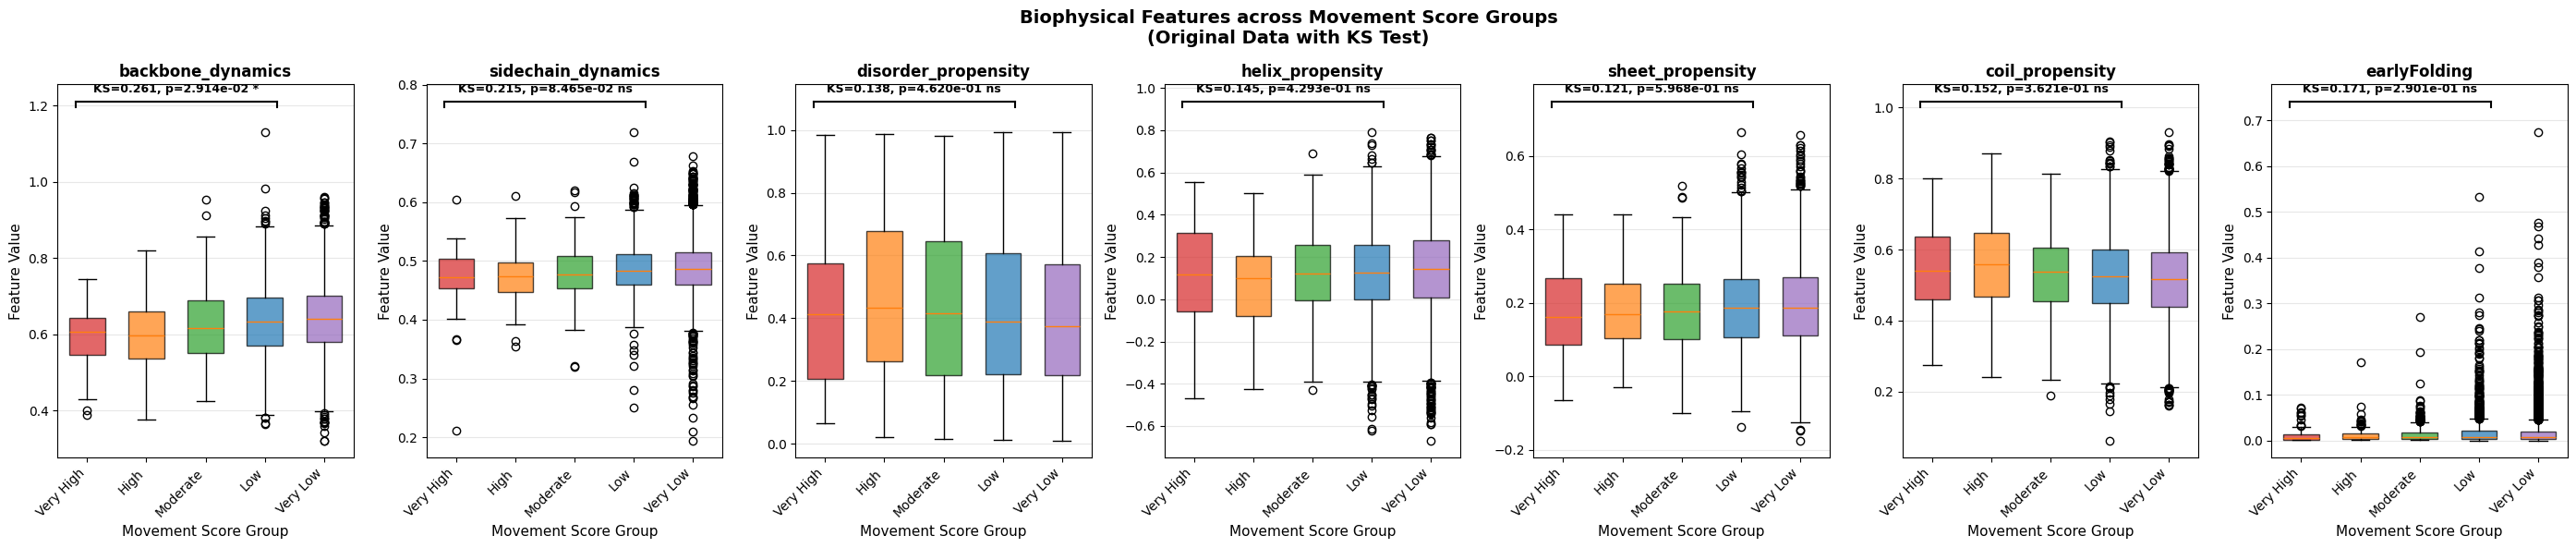


总结报告

样本量:
  Very High      : n=78
  High           : n=124
  Moderate       : n=340
  Low            : n=1931
  Very Low       : n=6235

Very High vs Very Low 显著差异特征:
  显著特征数: 1/7
    - backbone_dynamics: p=2.914e-02 *

✅ 5组箱线图分析完成!

解读提示:
  - 使用原始数据(不重采样),保留所有信息
  - KS检验处理样本量不平衡问题
  - 突出Very High vs Very Low的对比


In [54]:
"""
================================================================================
Cell 28: 5个Movement Score组的箱线图 (方案2: 原始数据+KS检验标注)
================================================================================
目的: 展示5个Movement Score组的生物物理特征差异
方法: 使用原始数据,KS检验处理样本量不平衡
特点: 突出Very High vs Very Low的对比
================================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("5个Movement Score组的箱线图分析 (方案2)")
print("="*80)

# ============================================================================
# 数据加载和准备
# ============================================================================

# 尝试多种数据源
if 'final_df' in globals():
    df = final_df.copy()
    print("✓ 使用final_df")
elif 'success_df' in globals():
    df = success_df.copy()
    print("✓ 使用success_df")
else:
    raise NameError("请先运行数据加载Cell")

# 检查必要的列
required_cols = ['movement_score', 'AA']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"缺少列: {missing_cols}")

# 特征列检查
feature_cols = []
expected_features = {
    'backbone_dynamics': ['backbone_dynamics', 'Backbone_Dynamics'],
    'sidechain_dynamics': ['sidechain_dynamics', 'Sidechain_Dynamics'],
    'disorder_propensity': ['disorder_propensity', 'Disorder_Propensity'],
    'helix_propensity': ['helix_propensity', 'Helix_Propensity'],
    'sheet_propensity': ['sheet_propensity', 'Sheet_Propensity'],
    'coil_propensity': ['coil_propensity', 'Coil_Propensity'],
    'earlyFolding': ['earlyFolding', 'early_folding', 'Early_Folding']
}

for standard_name, variants in expected_features.items():
    found = False
    for variant in variants:
        if variant in df.columns:
            feature_cols.append(variant)
            found = True
            break

print(f"\n可用特征 ({len(feature_cols)}个): {', '.join(feature_cols)}")

# ============================================================================
# 定义5个Movement Score组
# ============================================================================

print("\n" + "="*80)
print("[1/3] 定义5个Movement Score组...")
print("="*80)

# 定义5个组
very_high = df[df['movement_score'] >= 20].copy()
high = df[(df['movement_score'] >= 15) & (df['movement_score'] < 20)].copy()
moderate = df[(df['movement_score'] >= 10) & (df['movement_score'] < 15)].copy()
low = df[(df['movement_score'] >= 2) & (df['movement_score'] < 5)].copy()
very_low = df[df['movement_score'] < 2].copy()

print(f"  Very High (≥20%)     : n={len(very_high)}")
print(f"  High (15-20%)        : n={len(high)}")
print(f"  Moderate (10-15%)    : n={len(moderate)}")
print(f"  Low (2-5%)           : n={len(low)}")
print(f"  Very Low (<2%)       : n={len(very_low)}")

# 准备绘图数据
groups = {
    'Very High': very_high,
    'High': high,
    'Moderate': moderate,
    'Low': low,
    'Very Low': very_low
}

# ============================================================================
# KS检验函数 (处理样本量不平衡)
# ============================================================================

def ks_test_with_resampling(group1_data, group2_data, n_iterations=10):
    """
    使用重采样进行KS检验,处理样本量不平衡
    """
    # 找到较小的样本量
    min_n = min(len(group1_data), len(group2_data))
    
    ks_stats = []
    p_values = []
    
    for _ in range(n_iterations):
        # 重采样
        if len(group1_data) > min_n:
            sample1 = np.random.choice(group1_data.dropna(), size=min_n, replace=False)
        else:
            sample1 = group1_data.dropna()
        
        if len(group2_data) > min_n:
            sample2 = np.random.choice(group2_data.dropna(), size=min_n, replace=False)
        else:
            sample2 = group2_data.dropna()
        
        # KS检验
        ks_stat, p_val = stats.ks_2samp(sample1, sample2)
        ks_stats.append(ks_stat)
        p_values.append(p_val)
    
    # 返回平均值
    return np.mean(ks_stats), np.mean(p_values)

# ============================================================================
# 计算KS统计量 (Very High vs Very Low)
# ============================================================================

print("\n" + "="*80)
print("[2/3] 计算KS统计量 (Very High vs Very Low)...")
print("="*80)

ks_results = {}
for feat in feature_cols:
    ks_stat, p_val = ks_test_with_resampling(
        very_high[feat],
        very_low[feat],
        n_iterations=10
    )
    ks_results[feat] = {'ks_stat': ks_stat, 'p_val': p_val}
    
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
    print(f"  {feat:<25} KS={ks_stat:.3f}, p={p_val:.3e} {sig}")

# ============================================================================
# 生成箱线图
# ============================================================================

print("\n" + "="*80)
print("[3/3] 生成箱线图...")
print("="*80)

# 准备数据
plot_data = []
for group_name, group_df in groups.items():
    for feat in feature_cols:
        for val in group_df[feat].dropna():
            plot_data.append({
                'Group': group_name,
                'Feature': feat,
                'Value': val
            })

plot_df = pd.DataFrame(plot_data)

# 设置颜色 (突出Very High和Very Low)
colors = {
    'Very High': '#d62728',  # 红色
    'High': '#ff7f0e',       # 橙色
    'Moderate': '#2ca02c',   # 绿色
    'Low': '#1f77b4',        # 蓝色
    'Very Low': '#9467bd'    # 紫色
}

# 绘制箱线图
n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(4*n_features, 6))
if n_features == 1:
    axes = [axes]

for idx, feat in enumerate(feature_cols):
    ax = axes[idx]
    
    # 筛选当前特征的数据
    feat_data = plot_df[plot_df['Feature'] == feat]
    
    # 绘制箱线图
    box_parts = ax.boxplot(
        [feat_data[feat_data['Group'] == g]['Value'].values for g in groups.keys()],
        labels=groups.keys(),
        patch_artist=True,
        widths=0.6
    )
    
    # 设置颜色
    for patch, group_name in zip(box_parts['boxes'], groups.keys()):
        patch.set_facecolor(colors[group_name])
        patch.set_alpha(0.7)
    
    # 添加KS检验标注 (Very High vs Very Low)
    if feat in ks_results:
        ks_stat = ks_results[feat]['ks_stat']
        p_val = ks_results[feat]['p_val']
        sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
        
        # 在图上方添加标注
        y_max = feat_data['Value'].max()
        y_min = feat_data['Value'].min()
        y_range = y_max - y_min
        
        # 连接线 (Very High to Very Low)
        ax.plot([0.8, 4.2], [y_max + 0.1*y_range, y_max + 0.1*y_range], 'k-', lw=1.5)
        ax.plot([0.8, 0.8], [y_max + 0.08*y_range, y_max + 0.1*y_range], 'k-', lw=1.5)
        ax.plot([4.2, 4.2], [y_max + 0.08*y_range, y_max + 0.1*y_range], 'k-', lw=1.5)
        
        # 标注文字
        ax.text(2.5, y_max + 0.12*y_range, 
                f'KS={ks_stat:.3f}, p={p_val:.3e} {sig}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 设置标签
    ax.set_xlabel('Movement Score Group', fontsize=11)
    ax.set_ylabel('Feature Value', fontsize=11)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(groups.keys(), rotation=45, ha='right')

plt.suptitle('Biophysical Features across Movement Score Groups\n(Original Data with KS Test)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

# 保存图片
filename = 'Movement_Score_5Groups_Boxplots_KS.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"  ✓ 已保存: {filename}")
plt.show()

# ============================================================================
# 总结报告
# ============================================================================

print("\n" + "="*80)
print("总结报告")
print("="*80)

print("\n样本量:")
for group_name, group_df in groups.items():
    print(f"  {group_name:<15}: n={len(group_df)}")

print("\nVery High vs Very Low 显著差异特征:")
sig_features = [feat for feat, res in ks_results.items() if res['p_val'] < 0.05]
print(f"  显著特征数: {len(sig_features)}/{len(feature_cols)}")
for feat in sig_features:
    p_val = ks_results[feat]['p_val']
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else "*")
    print(f"    - {feat}: p={p_val:.3e} {sig}")

print("\n" + "="*80)
print("✅ 5组箱线图分析完成!")
print("="*80)
print("\n解读提示:")
print("  - 使用原始数据(不重采样),保留所有信息")
print("  - KS检验处理样本量不平衡问题")
print("  - 突出Very High vs Very Low的对比")
print("="*80)


Cell 30: S/T/Y Mobility Rate by Spatial Group
✓ 总位点数 (4组): 4,634
✓ Mobility 位点: 587


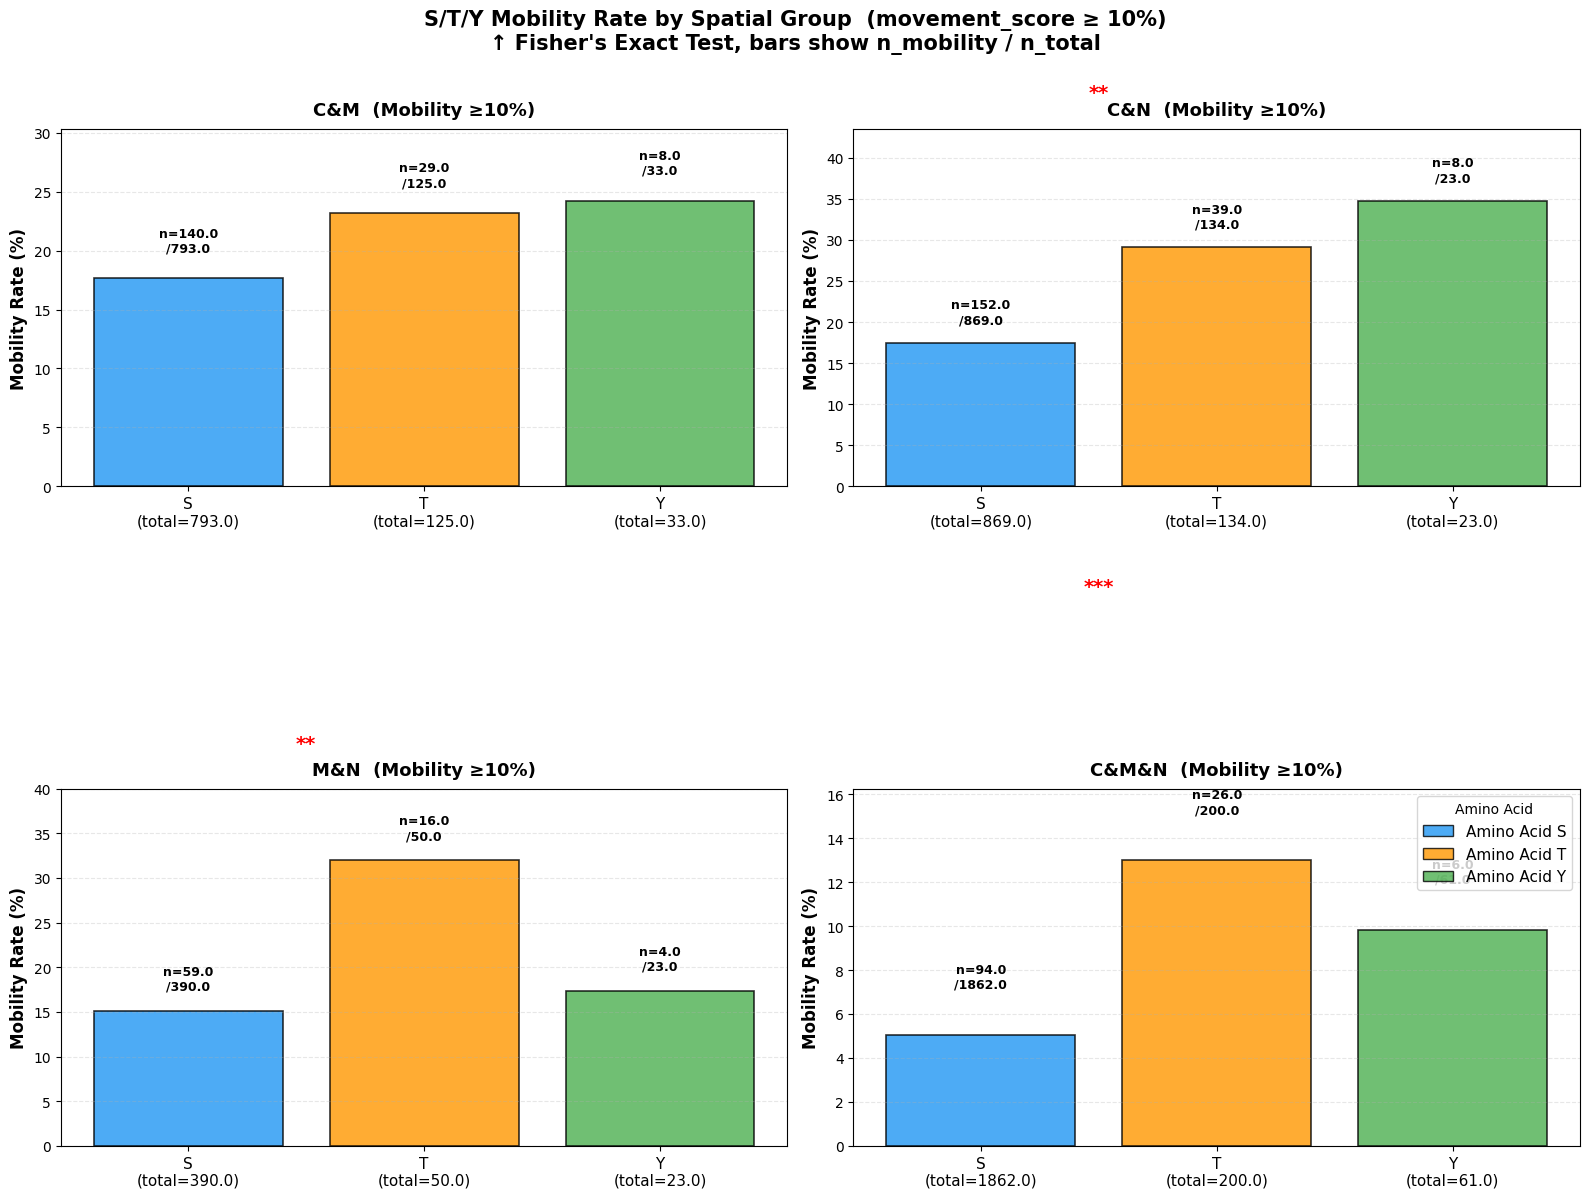


✓ 已保存: Cell30_STY_Mobility_Rate_By_Spatial_Group.png
✓ Cell 30 完成!


In [82]:
"""Cell 30: S/T/Y Mobility Rate by Spatial Group (4个分析组 + Fisher's Exact Test)
柱状图: 展示各空间组内 S/T/Y 的 Mobility 率及显著性检验
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("Cell 30: S/T/Y Mobility Rate by Spatial Group")
print("=" * 80)

# ========== 参数 ==========
MOBILITY_THRESHOLD = 10  # movement_score ≥ 10% 定义为 Mobility
aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'
analysis_groups = ['C&M', 'C&N', 'M&N', 'C&M&N']  # 只包括有 Mobility 的4组
colors = {'S': '#2196F3', 'T': '#FF9800', 'Y': '#4CAF50'}

# ========== 数据准备 ==========
df = success_df[success_df['movement_score'].notna()].copy()
df = df[df['LocalizationGroup'].isin(analysis_groups)].copy()
df['is_mobility'] = df['movement_score'] >= MOBILITY_THRESHOLD

print(f"✓ 总位点数 (4组): {len(df):,}")
print(f"✓ Mobility 位点: {df['is_mobility'].sum():,}")

# ========== Fisher's Exact Test ==========
def fisher_test_2x2(n_mob_1, n_total_1, n_mob_2, n_total_2):
    """
    2×2列联表 Fisher 精确检验
    返回 p-value 和显著性标记
    """
    table = [
        [n_mob_1, n_total_1 - n_mob_1],
        [n_mob_2, n_total_2 - n_mob_2]
    ]
    _, p_value = fisher_exact(table)
    
    if p_value < 0.001:
        return p_value, '***'
    elif p_value < 0.01:
        return p_value, '**'
    elif p_value < 0.05:
        return p_value, '*'
    else:
        return p_value, 'ns'

# ========== 绘图准备 ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, group in enumerate(analysis_groups):
    ax = axes[idx]
    gdf = df[df['LocalizationGroup'] == group]
    
    # 计算各氨基酸的 Mobility 率
    mob_data = []
    for aa in ['S', 'T', 'Y']:
        aadf = gdf[gdf[aa_col] == aa]
        n_total = len(aadf)
        n_mob = (aadf['movement_score'] >= MOBILITY_THRESHOLD).sum()
        mob_rate = (n_mob / n_total * 100) if n_total > 0 else 0
        
        mob_data.append({
            'AA': aa,
            'n_total': n_total,
            'n_mob': n_mob,
            'mob_rate': mob_rate
        })
    
    mob_df = pd.DataFrame(mob_data)
    
    # 绘制柱状图
    x_pos = np.arange(len(mob_df))
    bars = ax.bar(x_pos, mob_df['mob_rate'], 
                   color=[colors[aa] for aa in mob_df['AA']],
                   alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # 添加数值标签
    for i, row in mob_df.iterrows():
        ax.text(i, row['mob_rate'] + 2,
               f"n={row['n_mob']}.0\n/{row['n_total']}.0",
               ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Fisher's Exact Test (S vs T)
    s_data = mob_df[mob_df['AA'] == 'S'].iloc[0]
    t_data = mob_df[mob_df['AA'] == 'T'].iloc[0]
    
    if s_data['n_total'] >= 10 and t_data['n_total'] >= 10:
        p_val, sig = fisher_test_2x2(
            s_data['n_mob'], s_data['n_total'],
            t_data['n_mob'], t_data['n_total']
        )
        
        if sig != 'ns':
            y_max = mob_df['mob_rate'].max()
            y_pos = y_max + 10
            ax.plot([0, 1], [y_pos, y_pos], 'k-', lw=1.5)
            ax.text(0.5, y_pos + 2, sig, ha='center', va='bottom',
                   fontsize=14, fontweight='bold', color='red')
    
    # 设置标签
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{aa}\n(total={row['n_total']}.0)" 
                        for aa, row in zip(mob_df['AA'], mob_df.to_dict('records'))],
                       fontsize=11)
    ax.set_ylabel('Mobility Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f"{group}  (Mobility ≥{MOBILITY_THRESHOLD}%)",
                fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim(0, mob_df['mob_rate'].max() * 1.25)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# 总标题
fig.suptitle(
    f"S/T/Y Mobility Rate by Spatial Group  (movement_score ≥ {MOBILITY_THRESHOLD}%)\n"
    "↑ Fisher's Exact Test, bars show n_mobility / n_total",
    fontsize=15, fontweight='bold', y=0.995
)

# 图例
legend_elements = [plt.Rectangle((0,0),1,1, fc=colors[aa], alpha=0.8, 
                                 edgecolor='black', label=f'Amino Acid {aa}')
                   for aa in ['S', 'T', 'Y']]
axes[-1].legend(handles=legend_elements, loc='upper right', fontsize=11,
                title='Amino Acid', frameon=True)

plt.tight_layout()
plt.savefig('Cell30_STY_Mobility_Rate_By_Spatial_Group.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ 已保存: Cell30_STY_Mobility_Rate_By_Spatial_Group.png")
print("=" * 80)
print("✓ Cell 30 完成!")
print("=" * 80)


Cell 31: 空间组内 S/T/Y Mobility 率对比
⚠️  未找到特征: earlyFolding
✓ 检测到 6 个生物物理特征: ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity']
✓ 氨基酸列名: 'amino_acid'

数据集总位点: 10,257
Mobility (≥10%): 587
分析空间组: ['C&M', 'C&N', 'M&N', 'C&M&N']

[1/4] 各空间组 × S/T/Y 样本量 & Mobility 率

空间组      | AA  |     总数 |  Mob n |    Mob率 |    可检验
-------------------------------------------------------
C&M      | S   |    793 |    140 |   17.7%  | ✅
C&M      | T   |    125 |     29 |   23.2%  | ✅
C&M      | Y   |     33 |      8 |   24.2%  | ⚠️ 小
-------------------------------------------------------
C&N      | S   |    869 |    152 |   17.5%  | ✅
C&N      | T   |    134 |     39 |   29.1%  | ✅
C&N      | Y   |     23 |      8 |   34.8%  | ⚠️ 小
-------------------------------------------------------
M&N      | S   |    390 |     59 |   15.1%  | ✅
M&N      | T   |     50 |     16 |   32.0%  | ✅
M&N      | Y   |     23 |      4 |   17.4%  | ⚠️ 小
----

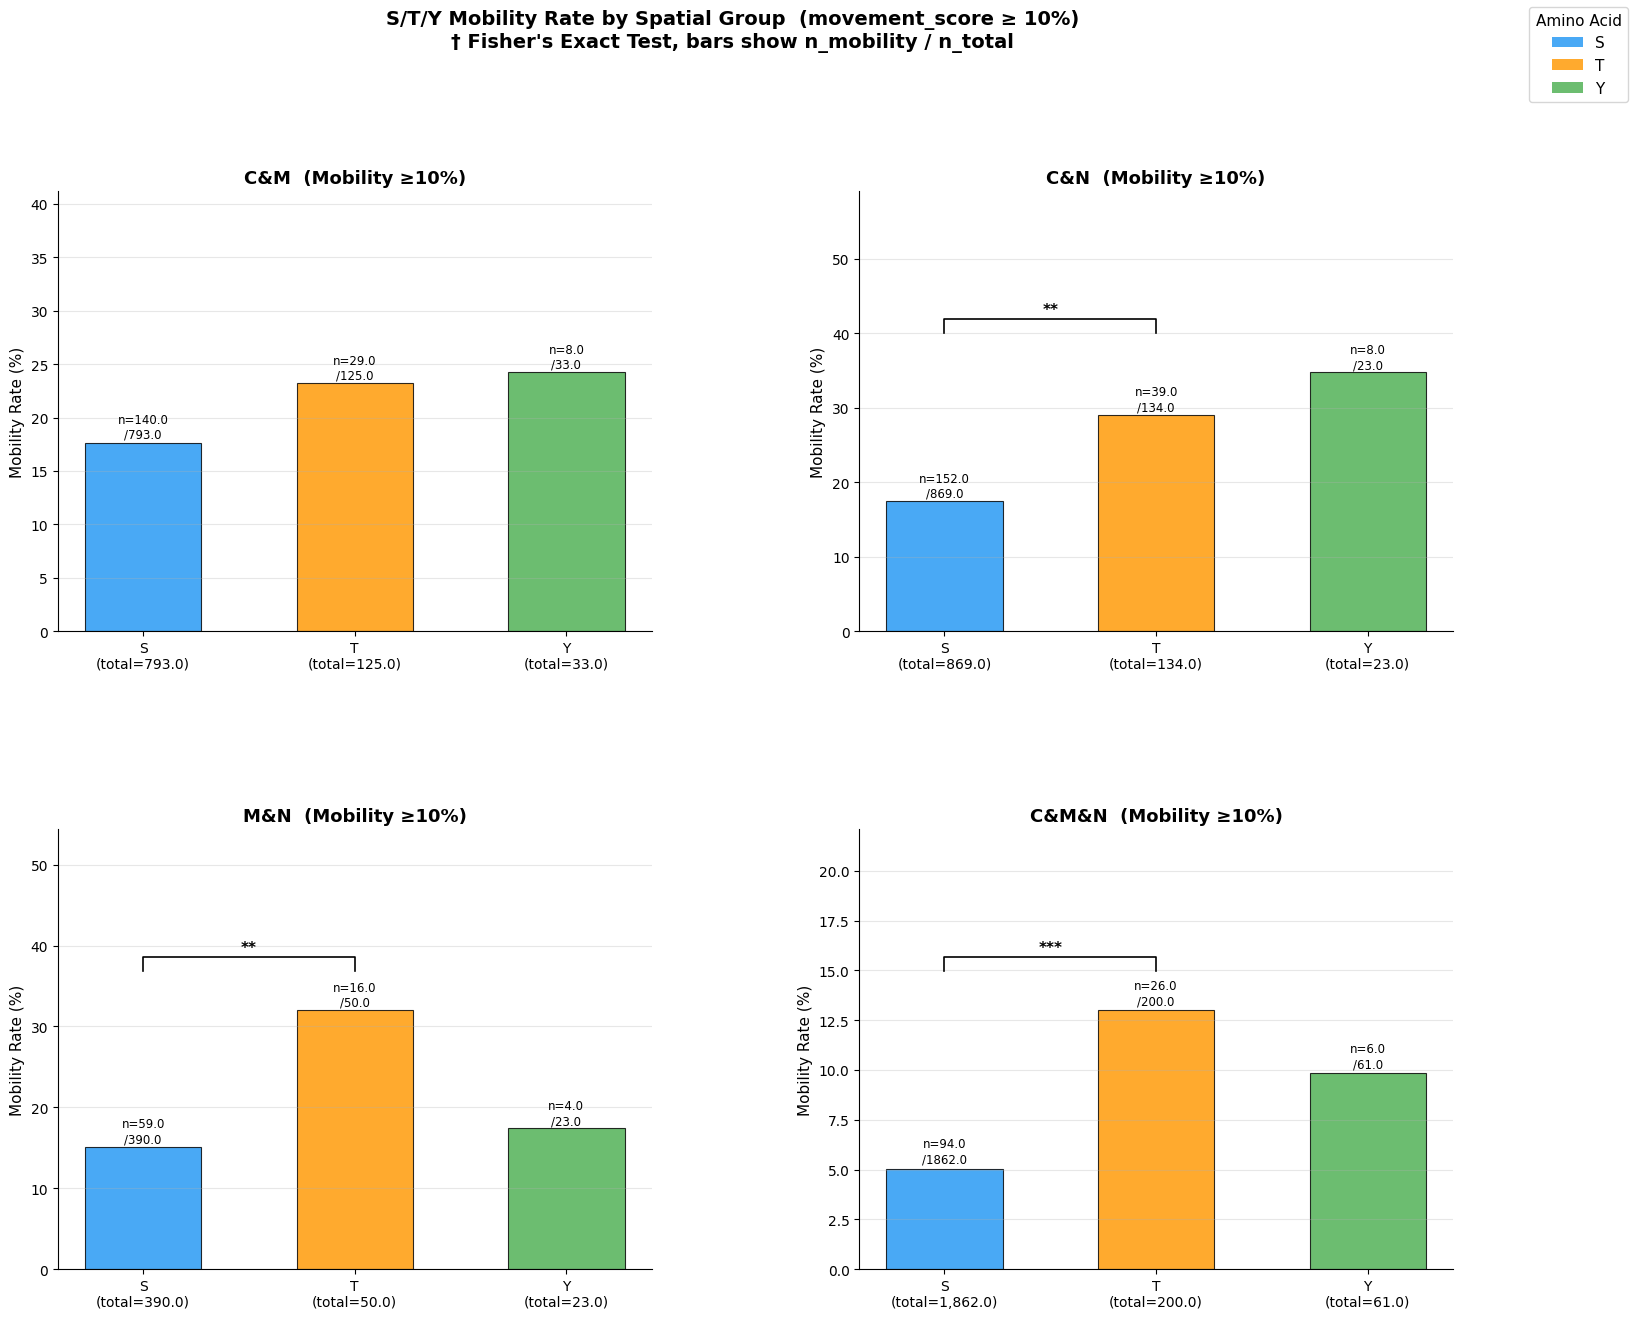

✓ 已保存: Cell31_STY_Mobility_by_SpatialGroup.png

汇总报告

Mobility 率矩阵 (%):
           S     T      Y
C&M    17.65  23.2  24.24
C&N    17.49  29.1  34.78
M&N    15.13  32.0  17.39
C&M&N   5.05  13.0   9.84

n_Mobility 矩阵:
           S     T    Y
C&M    140.0  29.0  8.0
C&N    152.0  39.0  8.0
M&N     59.0  16.0  4.0
C&M&N   94.0  26.0  6.0

显著差异汇总 (Fisher's Exact Test, p<0.05):
  C&N: S(17.5%) vs T(29.1%) OR=0.516 **
  M&N: S(15.1%) vs T(32.0%) OR=0.379 **
  C&M&N: S(5.0%) vs T(13.0%) OR=0.356 ***

✓ Cell 31 完成!

下一步:
  → Cell 32: 三元相图 (Ternary Plot) - 空间分层可视化


In [ ]:
"""Cell 31: 空间组内 S/T/Y Mobility 率对比
目标: 在 C&M, C&N, M&N, C&M&N 四个空间组内，分别比较 S/T/Y 的 Mobility 率
方法: Fisher's Exact Test (率比较) + 重采样KS检验 (特征分布)
阈值: movement_score >= 10% (与Cell 22一致，587个高移动性位点)
规则: 样本量 < 10 的组自动跳过检验，但仍展示描述性统计
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import fisher_exact, kruskal
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("Cell 31: 空间组内 S/T/Y Mobility 率对比")
print("=" * 80)

# ========== 0. 数据准备 ==========
MOBILITY_THRESHOLD = 10   # 与Cell 22一致
MIN_N = 10                # 低于此样本量跳过统计检验

# 氨基酸列名自适应
aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'

# 特征列自适应检测（参考Cell 29写法）
feature_mapping = {
    'backbone_dynamics':  ['backbone_dynamics',  'Backbone_Dynamics'],
    'sidechain_dynamics': ['sidechain_dynamics', 'Sidechain_Dynamics'],
    'disorder_propensity':['disorder_propensity','Disorder_Propensity'],
    'helix_propensity':   ['helix_propensity',   'Helix_Propensity'],
    'sheet_propensity':   ['sheet_propensity',   'Sheet_Propensity'],
    'coil_propensity':    ['coil_propensity',    'Coil_Propensity'],
    'earlyFolding':       ['earlyFolding',       'early_folding', 'Early_Folding'],
}

bio_features = []
for standard_name, variants in feature_mapping.items():
    for variant in variants:
        if variant in success_df.columns:
            bio_features.append(variant)
            break
    else:
        print(f"⚠️  未找到特征: {standard_name}")

print(f"✓ 检测到 {len(bio_features)} 个生物物理特征: {bio_features}")
print(f"✓ 氨基酸列名: '{aa_col}'")

# 分析组（排除单区室组）
analysis_groups = ['C&M', 'C&N', 'M&N', 'C&M&N']

# 标注 Mobility
df = success_df[success_df['movement_score'].notna()].copy()
df['is_mobility'] = df['movement_score'] >= MOBILITY_THRESHOLD

print(f"\n数据集总位点: {len(df):,}")
print(f"Mobility (≥{MOBILITY_THRESHOLD}%): {df['is_mobility'].sum():,}")
print(f"分析空间组: {analysis_groups}")

# ========== 1. 各组内 S/T/Y 样本量 & Mobility 率统计 ==========
print("\n" + "=" * 80)
print("[1/4] 各空间组 × S/T/Y 样本量 & Mobility 率")
print("=" * 80)

aa_list = ['S', 'T', 'Y']
mob_rate_matrix = pd.DataFrame(index=analysis_groups, columns=aa_list, dtype=float)
mob_n_matrix    = pd.DataFrame(index=analysis_groups, columns=aa_list, dtype=int)
total_n_matrix  = pd.DataFrame(index=analysis_groups, columns=aa_list, dtype=int)

print(f"\n{'空间组':8s} | {'AA':3s} | {'总数':>6s} | {'Mob n':>6s} | {'Mob率':>7s} | {'可检验':>6s}")
print("-" * 55)

for group in analysis_groups:
    gdf = df[df['LocalizationGroup'] == group]
    for aa in aa_list:
        aadf = gdf[gdf[aa_col] == aa]
        n_total = len(aadf)
        n_mob   = aadf['is_mobility'].sum()
        rate    = n_mob / n_total * 100 if n_total > 0 else 0
        testable = '✅' if n_mob >= MIN_N else '⚠️ 小'

        mob_rate_matrix.loc[group, aa] = round(rate, 2)
        mob_n_matrix.loc[group, aa]    = n_mob
        total_n_matrix.loc[group, aa]  = n_total

        print(f"{group:8s} | {aa:3s} | {n_total:6,} | {n_mob:6,} | {rate:6.1f}%  | {testable}")
    print("-" * 55)

# ========== 2. Fisher's Exact Test: 组内 S vs T vs Y 的 Mobility 率 ==========
print("\n" + "=" * 80)
print("[2/4] 组内 Mobility 率比较 (Fisher's Exact Test, S vs T / S vs Y / T vs Y)")
print("=" * 80)

fisher_results = {}

for group in analysis_groups:
    gdf = df[df['LocalizationGroup'] == group]
    print(f"\n── {group} ──")
    group_results = {}

    pairs = [('S', 'T'), ('S', 'Y'), ('T', 'Y')]
    for aa1, aa2 in pairs:
        d1 = gdf[gdf[aa_col] == aa1]
        d2 = gdf[gdf[aa_col] == aa2]

        n1_mob   = d1['is_mobility'].sum()
        n1_nomob = len(d1) - n1_mob
        n2_mob   = d2['is_mobility'].sum()
        n2_nomob = len(d2) - n2_mob

        # 跳过样本量不足的组
        if n1_mob < MIN_N or n2_mob < MIN_N:
            reason = f"{aa1}(n={n1_mob}) 或 {aa2}(n={n2_mob}) < {MIN_N}"
            print(f"  {aa1} vs {aa2}: ⚠️  跳过 ({reason})")
            group_results[f'{aa1}_vs_{aa2}'] = {'skip': True, 'reason': reason}
            continue

        table = [[n1_mob, n1_nomob],
                 [n2_mob, n2_nomob]]
        odds_ratio, pval = fisher_exact(table, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'

        r1 = n1_mob / (n1_mob + n1_nomob) * 100
        r2 = n2_mob / (n2_mob + n2_nomob) * 100

        print(f"  {aa1}({r1:.1f}%) vs {aa2}({r2:.1f}%): OR={odds_ratio:.3f}, p={pval:.4f} {sig}")
        group_results[f'{aa1}_vs_{aa2}'] = {
            'skip': False, 'odds_ratio': odds_ratio,
            'pval': pval, 'sig': sig,
            'rate1': r1, 'rate2': r2
        }

    fisher_results[group] = group_results

# ========== 3. 重采样 KS 检验: 组内 Mobility 位点的特征分布 S vs T ==========
print("\n" + "=" * 80)
print("[3/4] 组内 Mobility 位点特征分布比较 (重采样 KS, S vs T)")
print("=" * 80)

def ks_resample(data1, data2, n_iter=100):
    """重采样KS检验，平衡样本量（参考Cell 29）"""
    d1 = data1.dropna().values
    d2 = data2.dropna().values
    if len(d1) < MIN_N or len(d2) < MIN_N:
        return np.nan, np.nan
    min_n = min(len(d1), len(d2))
    ks_list, p_list = [], []
    for _ in range(n_iter):
        s1 = np.random.choice(d1, size=min_n, replace=False)
        s2 = np.random.choice(d2, size=min_n, replace=False)
        ks, p = stats.ks_2samp(s1, s2)
        ks_list.append(ks)
        p_list.append(p)
    return np.mean(ks_list), np.mean(p_list)

ks_results = {}

for group in analysis_groups:
    mob_df = df[(df['LocalizationGroup'] == group) & (df['is_mobility'])]
    print(f"\n── {group} (Mobility 位点: S={len(mob_df[mob_df[aa_col]=='S'])}, "
          f"T={len(mob_df[mob_df[aa_col]=='T'])}, "
          f"Y={len(mob_df[mob_df[aa_col]=='Y'])}) ──")

    s_mob = mob_df[mob_df[aa_col] == 'S']
    t_mob = mob_df[mob_df[aa_col] == 'T']
    y_mob = mob_df[mob_df[aa_col] == 'Y']

    group_ks = {}
    for feat in bio_features:
        ks_st, p_st = ks_resample(s_mob[feat], t_mob[feat])
        ks_sy, p_sy = ks_resample(s_mob[feat], y_mob[feat])
        ks_ty, p_ty = ks_resample(t_mob[feat], y_mob[feat])

        def fmt(ks, p):
            if np.isnan(ks): return "skip"
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            return f"KS={ks:.3f} {sig}"

        print(f"  {feat:25s}: S-T={fmt(ks_st, p_st)}, S-Y={fmt(ks_sy, p_sy)}, T-Y={fmt(ks_ty, p_ty)}")
        group_ks[feat] = {
            'S_T': (ks_st, p_st), 'S_Y': (ks_sy, p_sy), 'T_Y': (ks_ty, p_ty)
        }
    ks_results[group] = group_ks

# ========== 4. 可视化 ==========
print("\n" + "=" * 80)
print("[4/4] 生成可视化...")
print("=" * 80)

colors = {'S': '#2196F3', 'T': '#FF9800', 'Y': '#4CAF50'}
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

for idx, group in enumerate(analysis_groups):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    gdf = df[df['LocalizationGroup'] == group]

    x = np.arange(len(aa_list))
    width = 0.55

    mob_rates  = [mob_rate_matrix.loc[group, aa] for aa in aa_list]
    mob_ns     = [mob_n_matrix.loc[group, aa]    for aa in aa_list]
    total_ns   = [total_n_matrix.loc[group, aa]  for aa in aa_list]

    bars = ax.bar(x, mob_rates,
                  width=width,
                  color=[colors[aa] for aa in aa_list],
                  alpha=0.82,
                  edgecolor='black',
                  linewidth=0.8)

    # 柱子上标注 Mob_n / Total_n
    for i, (bar, mob_n, total_n, rate) in enumerate(zip(bars, mob_ns, total_ns, mob_rates)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15,
                f'n={mob_n}\n/{total_n}',
                ha='center', va='bottom', fontsize=8.5, color='black')

    # 添加 Fisher 显著性标记
    pair_positions = [('S', 'T', 0, 1), ('S', 'Y', 0, 2), ('T', 'Y', 1, 2)]
    y_offset = max(mob_rates) * 1.15
    step = max(mob_rates) * 0.18

    for aa1, aa2, xi, xj in pair_positions:
        key = f'{aa1}_vs_{aa2}'
        res = fisher_results[group].get(key, {})
        if res.get('skip', True):
            continue
        sig = res['sig']
        if sig == 'ns':
            continue
        y_line = y_offset
        ax.plot([xi, xi, xj, xj],
                [y_line, y_line + step * 0.3, y_line + step * 0.3, y_line],
                lw=1.2, color='black')
        ax.text((xi + xj) / 2, y_line + step * 0.35,
                sig, ha='center', va='bottom', fontsize=11, fontweight='bold')
        y_offset += step

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{aa}\n(total={total_ns[i]:,})' for i, aa in enumerate(aa_list)],
        fontsize=10
    )
    ax.set_ylabel('Mobility Rate (%)', fontsize=11)
    ax.set_title(f'{group}  (Mobility ≥{MOBILITY_THRESHOLD}%)',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(mob_rates) * 1.7 if max(mob_rates) > 0 else 5)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[aa], alpha=0.82, label=aa) for aa in aa_list]
fig.legend(handles=legend_elements,
           title='Amino Acid',
           loc='upper right',
           fontsize=11,
           title_fontsize=11,
           frameon=True)

fig.suptitle(
    f'S/T/Y Mobility Rate by Spatial Group  (movement_score ≥ {MOBILITY_THRESHOLD}%)\n'
    f'† Fisher\'s Exact Test, bars show n_mobility / n_total',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig('Cell31_STY_Mobility_by_SpatialGroup.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ 已保存: Cell31_STY_Mobility_by_SpatialGroup.png")

# ========== 5. 汇总报告 ==========
print("\n" + "=" * 80)
print("汇总报告")
print("=" * 80)

print("\nMobility 率矩阵 (%):")
print(mob_rate_matrix.to_string())

print("\nn_Mobility 矩阵:")
print(mob_n_matrix.to_string())

print("\n显著差异汇总 (Fisher's Exact Test, p<0.05):")
any_sig = False
for group in analysis_groups:
    for pair, res in fisher_results[group].items():
        if not res.get('skip', True) and res['sig'] != 'ns':
            aa1, aa2 = pair.split('_vs_')
            print(f"  {group}: {aa1}({res['rate1']:.1f}%) vs {aa2}({res['rate2']:.1f}%) "
                  f"OR={res['odds_ratio']:.3f} {res['sig']}")
            any_sig = True
if not any_sig:
    print("  无显著差异 (或样本量不足，检验被跳过)")

print("\n" + "=" * 80)
print("✓ Cell 31 完成!")
print("=" * 80)
print("\n下一步:")
print("  → Cell 32: 三元相图 (Ternary Plot) - 空间分层可视化")


Cell 31b: Mobility 位点 S/T/Y 特征分布 (方案B - 按空间组)
✓ 合并完成，earlyFolding 有效值: 9617
  缺失值: 640
✓ 特征数: 7  ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding']
✓ Mobility 位点总数: 587


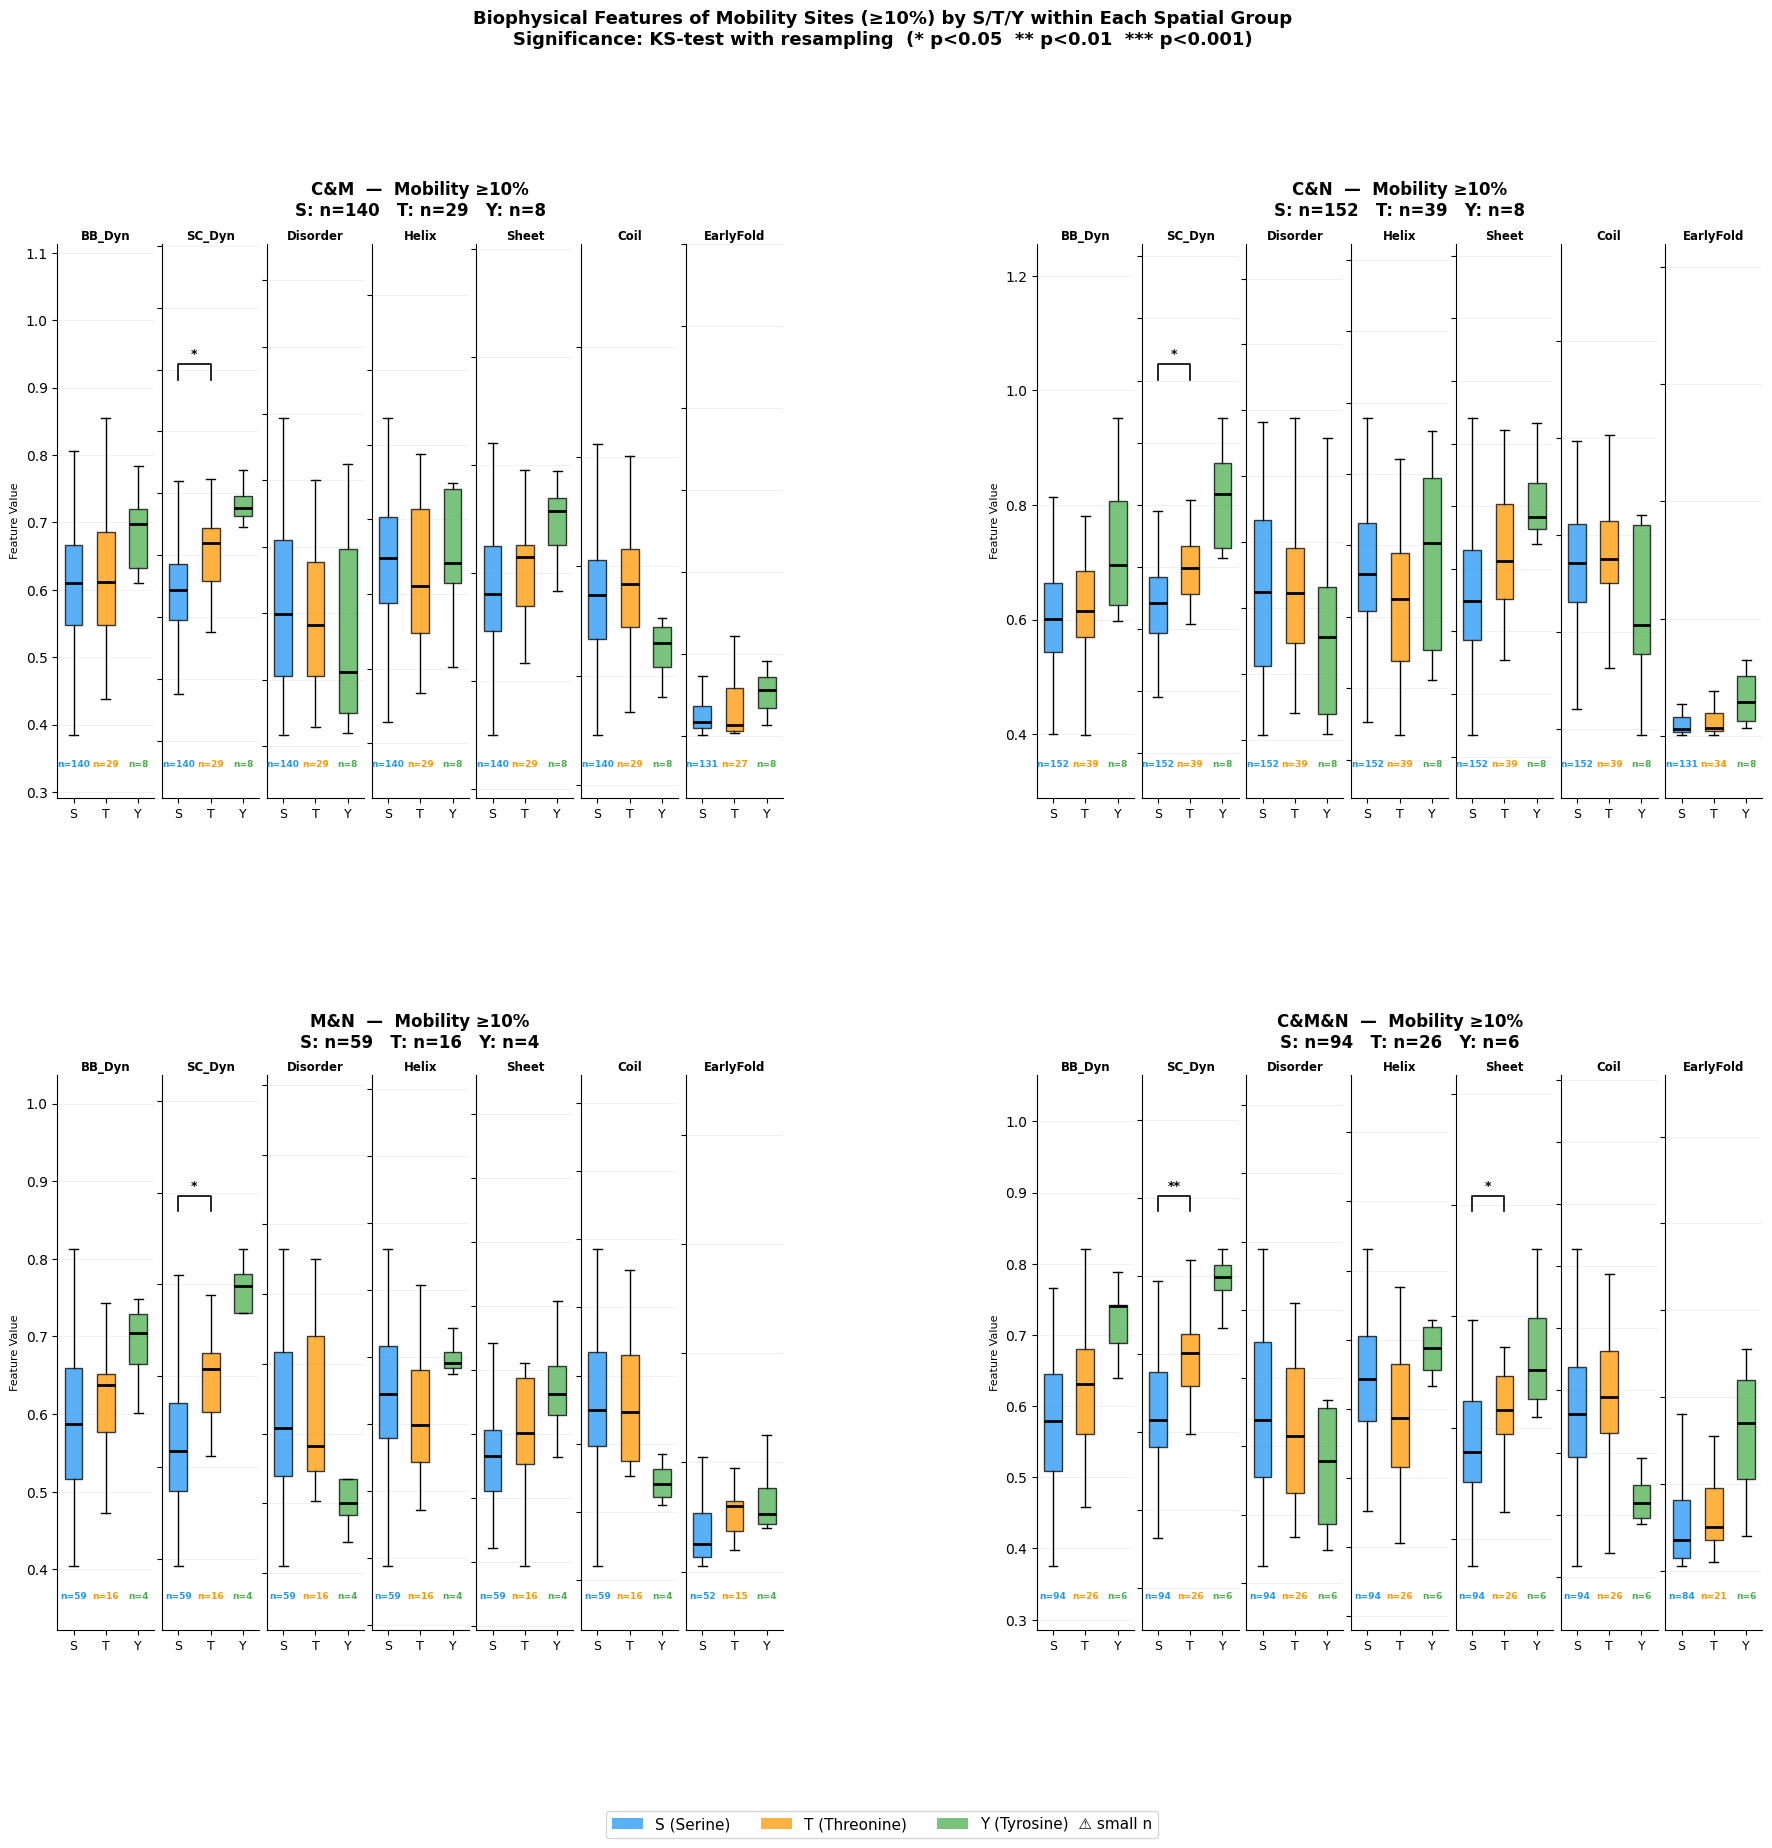

✓ 已保存: Cell31b_STY_Features_SpatialGroup.png


In [ ]:
"""Cell 31b: 各空间组 Mobility 位点内 S/T/Y 生物物理特征分布对比
布局: 4个空间组 × 7个特征箱线图 (方案B)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("Cell 31b: Mobility 位点 S/T/Y 特征分布 (方案B - 按空间组)")
print("=" * 80)

# ========== 参数 ==========
MOBILITY_THRESHOLD = 10
MIN_N_TEST = 10   # 低于此不做检验
MIN_N_SHOW = 3    # 低于此不画箱线图

aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'
analysis_groups = ['C&M', 'C&N', 'M&N', 'C&M&N']
colors = {'S': '#2196F3', 'T': '#FF9800', 'Y': '#4CAF50'}

# 用 PTM_collapse_key 做 key（如果 final_df 里有这列）
if 'PTM_collapse_key' in final_df.columns:
    success_df = success_df.merge(
        final_df[['PTM_collapse_key', 'earlyFolding']],
        on='PTM_collapse_key',
        how='left'
    )
    print(f"✓ 合并完成，earlyFolding 有效值: {success_df['earlyFolding'].notna().sum()}")
    print(f"  缺失值: {success_df['earlyFolding'].isna().sum()}")

# 如果没有 PTM_collapse_key，用 Gene + Site
elif 'Gene' in final_df.columns and 'Site' in final_df.columns:
    success_df = success_df.merge(
        final_df[['Gene', 'Site', 'earlyFolding']],
        on=['Gene', 'Site'],
        how='left'
    )
    print(f"✓ 合并完成，earlyFolding 有效值: {success_df['earlyFolding'].notna().sum()}")


# 特征自适应检测
# 特征自适应检测
feature_mapping = {
    'backbone_dynamics':   ['backbone_dynamics',   'Backbone_Dynamics'],
    'sidechain_dynamics':  ['sidechain_dynamics',  'Sidechain_Dynamics'],
    'disorder_propensity': ['disorder_propensity', 'Disorder_Propensity'],
    'helix_propensity':    ['helix_propensity',    'Helix_Propensity'],
    'sheet_propensity':    ['sheet_propensity',    'Sheet_Propensity'],
    'coil_propensity':     ['coil_propensity',     'Coil_Propensity'],
    # ↓ 补全所有可能的列名变体
    'earlyFolding':        ['earlyFolding', 'early_folding', 'Early_Folding',
                            'earlyfolding', 'EarlyFolding', 'early_Folding'],
}

bio_features = []
feat_labels  = []   # 用于显示的短名
for std_name, variants in feature_mapping.items():
    for v in variants:
        if v in success_df.columns:
            bio_features.append(v)
            short = std_name.replace('_propensity','').replace('_dynamics','_Dyn') \
                            .replace('backbone','BB').replace('sidechain','SC') \
                            .replace('disorder','Disorder').replace('helix','Helix') \
                            .replace('sheet','Sheet').replace('coil','Coil') \
                            .replace('earlyFolding','EarlyFold')
            feat_labels.append(short)
            break

print(f"✓ 特征数: {len(bio_features)}  {bio_features}")

# ========== 筛选 Mobility 位点 ==========
df = success_df[success_df['movement_score'].notna()].copy()
mob_df = df[df['movement_score'] >= MOBILITY_THRESHOLD].copy()
print(f"✓ Mobility 位点总数: {len(mob_df):,}")

# ========== 重采样 KS 检验函数 ==========
def ks_resample(d1, d2, n_iter=200):
    d1 = d1.dropna().values
    d2 = d2.dropna().values
    if len(d1) < MIN_N_TEST or len(d2) < MIN_N_TEST:
        return np.nan, np.nan
    min_n = min(len(d1), len(d2))
    ks_list, p_list = [], []
    for _ in range(n_iter):
        s1 = np.random.choice(d1, min_n, replace=False)
        s2 = np.random.choice(d2, min_n, replace=False)
        k, p = stats.ks_2samp(s1, s2)
        ks_list.append(k); p_list.append(p)
    return np.mean(ks_list), np.mean(p_list)

def sig_label(p):
    if np.isnan(p): return None
    return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else None

# ========== 主图: 2×2，每组一个子图 ==========
fig = plt.figure(figsize=(22, 18))
outer_gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.35)

for g_idx, group in enumerate(analysis_groups):
    gdf = mob_df[mob_df['LocalizationGroup'] == group]
    s_df = gdf[gdf[aa_col] == 'S']
    t_df = gdf[gdf[aa_col] == 'T']
    y_df = gdf[gdf[aa_col] == 'Y']
    ns, nt, ny = len(s_df), len(t_df), len(y_df)

    # 每组内嵌 1×n_features 子图
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        1, len(bio_features),
        subplot_spec=outer_gs[g_idx],
        wspace=0.08
    )

    for f_idx, (feat, flabel) in enumerate(zip(bio_features, feat_labels)):
        ax = fig.add_subplot(inner_gs[f_idx])

        # 收集数据
        plot_data, plot_labels, plot_colors = [], [], []
        for aa, adf, n in [('S', s_df, ns), ('T', t_df, nt), ('Y', y_df, ny)]:
            vals = adf[feat].dropna().values
            if len(vals) >= MIN_N_SHOW:
                plot_data.append(vals)
                plot_labels.append(aa)
                plot_colors.append(colors[aa])

        if not plot_data:
            ax.axis('off')
            continue

        # 箱线图
        bp = ax.boxplot(
            plot_data,
            positions=range(len(plot_data)),
            widths=0.55,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=2)
        )
        for patch, c in zip(bp['boxes'], plot_colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.75)

        # 样本量标注（x轴下方）
        y_min = np.min([d.min() for d in plot_data])
        y_max = np.max([d.max() for d in plot_data])
        y_range = y_max - y_min if y_max > y_min else 0.1

        for i, (aa, vals) in enumerate(zip(plot_labels, plot_data)):
            ax.text(i, y_min - y_range * 0.08,
                    f'n={len(vals)}',
                    ha='center', va='top', fontsize=6.5,
                    color=colors[aa], fontweight='bold')

        # S vs T 显著性标记
        if 'S' in plot_labels and 'T' in plot_labels:
            si = plot_labels.index('S')
            ti = plot_labels.index('T')
            ks, p = ks_resample(s_df[feat], t_df[feat])
            slabel = sig_label(p)
            if slabel:
                y_bar = y_max + y_range * 0.12
                ax.plot([si, si, ti, ti],
                        [y_bar, y_bar + y_range*0.05,
                         y_bar + y_range*0.05, y_bar],
                        'k-', lw=1.2)
                ax.text((si+ti)/2, y_bar + y_range*0.06,
                        slabel, ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

        # S vs Y 显著性标记
        if 'S' in plot_labels and 'Y' in plot_labels:
            si = plot_labels.index('S')
            yi = plot_labels.index('Y')
            ks, p = ks_resample(s_df[feat], y_df[feat])
            slabel = sig_label(p)
            if slabel:
                y_bar = y_max + y_range * 0.28
                ax.plot([si, si, yi, yi],
                        [y_bar, y_bar + y_range*0.05,
                         y_bar + y_range*0.05, y_bar],
                        'k-', lw=1.2)
                ax.text((si+yi)/2, y_bar + y_range*0.06,
                        slabel, ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

        # 轴设置
        ax.set_xticks(range(len(plot_labels)))
        ax.set_xticklabels(plot_labels, fontsize=9)
        ax.set_title(flabel, fontsize=8.5, fontweight='bold', pad=3)
        ax.set_ylim(y_min - y_range * 0.2, y_max + y_range * 0.55)
        ax.grid(axis='y', alpha=0.25, linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # 只有最左边的子图显示 y 轴标签
        if f_idx == 0:
            ax.set_ylabel('Feature Value', fontsize=8)
        else:
            ax.set_yticklabels([])

    # 组标题（外层）
    outer_ax = fig.add_subplot(outer_gs[g_idx])
    outer_ax.set_title(
        f'{group}  —  Mobility ≥{MOBILITY_THRESHOLD}%\n'
        f'S: n={ns}   T: n={nt}   Y: n={ny}',
        fontsize=12, fontweight='bold', pad=20
    )
    outer_ax.axis('off')

# 图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['S'], alpha=0.75, label='S (Serine)'),
    Patch(facecolor=colors['T'], alpha=0.75, label='T (Threonine)'),
    Patch(facecolor=colors['Y'], alpha=0.75, label='Y (Tyrosine)  ⚠️ small n'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=11, frameon=True,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    f'Biophysical Features of Mobility Sites (≥{MOBILITY_THRESHOLD}%) by S/T/Y within Each Spatial Group\n'
    f'Significance: KS-test with resampling  (* p<0.05  ** p<0.01  *** p<0.001)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('Cell31b_STY_Features_SpatialGroup.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ 已保存: Cell31b_STY_Features_SpatialGroup.png")


📊 Cell 4: 添加统计显著性标注
✓ High mobility (≥10%): 587 个位点
✓ Low  mobility  (<5%): 8,470  个位点

各组样本量:
  S_High: n=445
  S_Low: n=7,054
  T_High: n=110
  T_Low: n=1,021
  Y_High: n=26
  Y_Low: n=271

✓ 特征数: 7  ['backbone_dynamics', 'sidechain_dynamics', 'disorder_propensity', 'helix_propensity', 'sheet_propensity', 'coil_propensity', 'earlyFolding']

🔬 计算KS统计量...

📋 KS检验结果汇总:
AA             Feature  KS_statistic  p_value sig_level  significant  n_high  n_low
 S   backbone_dynamics      0.158427 0.000402       ***         True     445   7054
 S  sidechain_dynamics      0.154382 0.000153       ***         True     445   7054
 S disorder_propensity      0.085618 0.141999        ns        False     445   7054
 S    helix_propensity      0.085169 0.133739        ns        False     445   7054
 S    sheet_propensity      0.075955 0.257219        ns        False     445   7054
 S     coil_propensity      0.108764 0.054813        ns        False     445   7054
 S        earlyFolding      0.077387 0.24

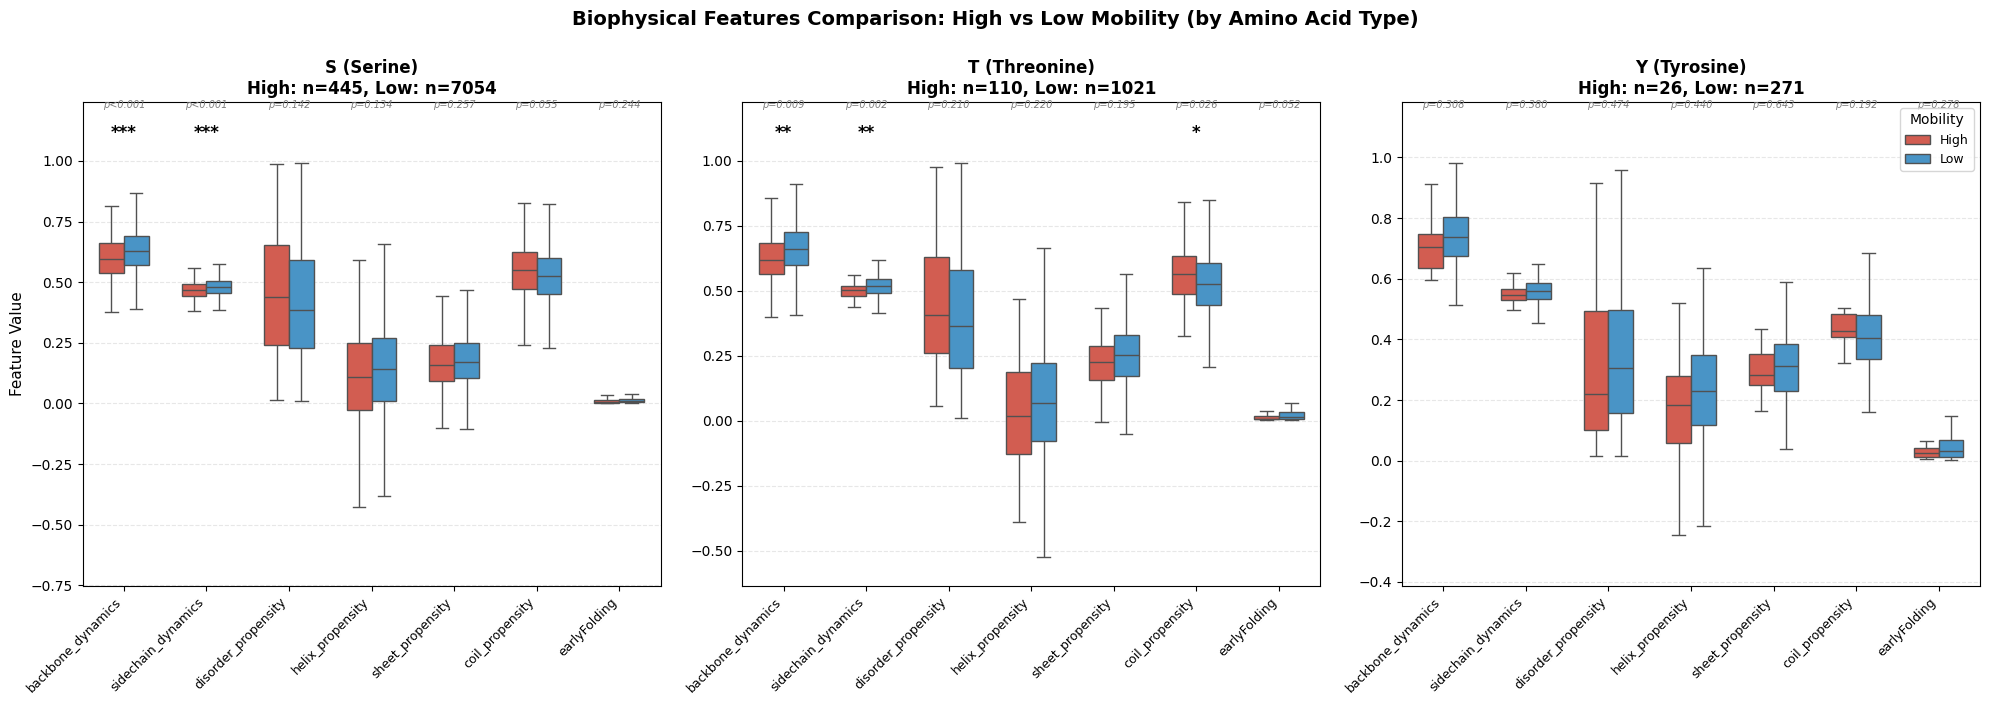


💾 KS统计结果已保存: KS_Statistics_Results.csv

✅ Cell 4 完成: 统计标注已添加


In [78]:
"""
Cell 4: 添加统计显著性标注
功能: 在box plot上添加KS检验结果和显著性标记
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle

print("=" * 80)
print("📊 Cell 4: 添加统计显著性标注")
print("=" * 80)

# ============================================================================
# ★ 修复：重新定义 groups，使用 success_df + movement_score 阈值
# 替换 Cell 1 中基于 final_df 90th percentile 的错误定义
# ============================================================================

aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'

# High: movement_score ≥ 10%（587个，与Cell 22一致）
# Low:  movement_score < 5%（8470个，作为对照）
high_mob = success_df[success_df['movement_score'] >= 10].copy()
low_mob  = success_df[success_df['movement_score'] < 5].copy()

print(f"✓ High mobility (≥10%): {len(high_mob):,} 个位点")
print(f"✓ Low  mobility  (<5%): {len(low_mob):,}  个位点")

groups = {}
for aa in ['S', 'T', 'Y']:
    groups[f'{aa}_High'] = high_mob[high_mob[aa_col] == aa]
    groups[f'{aa}_Low']  = low_mob[low_mob[aa_col] == aa]

print("\n各组样本量:")
for key, df in groups.items():
    print(f"  {key}: n={len(df):,}")

# 特征列自适应检测
feature_mapping = {
    'backbone_dynamics':   ['backbone_dynamics',  'Backbone_Dynamics'],
    'sidechain_dynamics':  ['sidechain_dynamics', 'Sidechain_Dynamics'],
    'disorder_propensity': ['disorder_propensity','Disorder_Propensity'],
    'helix_propensity':    ['helix_propensity',   'Helix_Propensity'],
    'sheet_propensity':    ['sheet_propensity',   'Sheet_Propensity'],
    'coil_propensity':     ['coil_propensity',    'Coil_Propensity'],
    'earlyFolding':        ['earlyFolding', 'early_folding', 'Early_Folding'],
}
biophysical_features = []
for std_name, variants in feature_mapping.items():
    for v in variants:
        if v in success_df.columns:
            biophysical_features.append(v)
            break
    else:
        print(f"⚠️  未找到: {std_name}")

print(f"\n✓ 特征数: {len(biophysical_features)}  {biophysical_features}")

# ============================================================================
# 1. KS检验函数（来自 Cell 2）
# ============================================================================

from scipy import stats

def perform_ks_test_with_resampling(high_mobility_data, low_mobility_data, 
                                     n_iterations=10, random_state=42):
    """
    KS检验（带重采样），处理样本量不平衡
    
    返回:
        dict: {'ks_statistic', 'p_value', 'mean_ks', 'std_ks', 
               'significant', 'sig_level', 'n_high', 'n_low'}
    """
    # 去除NaN
    high_data = high_mobility_data.dropna() if hasattr(high_mobility_data, 'dropna') \
                else high_mobility_data[~np.isnan(high_mobility_data)]
    low_data = low_mobility_data.dropna() if hasattr(low_mobility_data, 'dropna') \
               else low_mobility_data[~np.isnan(low_mobility_data)]
    
    # 样本量不足检查
    if len(high_data) < 5 or len(low_data) < 5:
        return {
            'ks_statistic': np.nan, 'p_value': np.nan,
            'mean_ks': np.nan, 'std_ks': np.nan,
            'significant': False, 'sig_level': 'ns',
            'n_high': len(high_data), 'n_low': len(low_data),
            'error': 'insufficient_data'
        }
    
    n_high = len(high_data)
    n_low = len(low_data)
    
    # 平衡样本量（重采样较大的组）
    if n_high > n_low:
        high_data, low_data = low_data, high_data
        n_high, n_low = n_low, n_high
    
    # 重采样KS检验
    np.random.seed(random_state)
    ks_statistics = []
    p_values = []
    
    for i in range(n_iterations):
        sampled_low = np.random.choice(low_data, size=n_high, replace=False)
        ks_stat, p_val = stats.ks_2samp(high_data, sampled_low)
        ks_statistics.append(ks_stat)
        p_values.append(p_val)
    
    mean_ks = np.mean(ks_statistics)
    mean_p = np.mean(p_values)
    std_ks = np.std(ks_statistics)
    
    # 显著性判定
    significant = mean_p < 0.05
    if mean_p < 0.001:
        sig_level = '***'
    elif mean_p < 0.01:
        sig_level = '**'
    elif mean_p < 0.05:
        sig_level = '*'
    else:
        sig_level = 'ns'
    
    return {
        'ks_statistic': mean_ks,
        'p_value': mean_p,
        'mean_ks': mean_ks,
        'std_ks': std_ks,
        'significant': significant,
        'sig_level': sig_level,
        'n_high': len(high_data),
        'n_low': len(low_data)
    }


def prepare_plot_data(groups, features, aa):
    """准备绘图用的长格式数据"""
    plot_data = []
    for feat in features:
        # High mobility
        for val in groups[f'{aa}_High'][feat].dropna():
            plot_data.append({
                'AA': aa, 'Feature': feat,
                'Value': val, 'Mobility': 'High'
            })
        # Low mobility
        for val in groups[f'{aa}_Low'][feat].dropna():
            plot_data.append({
                'AA': aa, 'Feature': feat,
                'Value': val, 'Mobility': 'Low'
            })
    return pd.DataFrame(plot_data)




# ============================================================================
# 1. 计算所有特征的KS统计量
# ============================================================================

def calculate_all_ks_statistics(groups, biophysical_features):
    """
    计算所有S/T/Y × 特征组合的KS统计量
    
    返回:
        DataFrame: 包含所有KS检验结果
    """
    
    results = []
    
    for aa in ['S', 'T', 'Y']:
        high_key = f'{aa}_High'
        low_key = f'{aa}_Low'
        
        for feature in biophysical_features:
            # 提取数据
            high_data = groups[high_key][feature]
            low_data = groups[low_key][feature]
            
            # 执行KS检验
            ks_result = perform_ks_test_with_resampling(
                high_data, low_data, n_iterations=10
            )
            
            results.append({
                'AA': aa,
                'Feature': feature,
                'KS_statistic': ks_result['ks_statistic'],
                'p_value': ks_result['p_value'],
                'sig_level': ks_result['sig_level'],
                'significant': ks_result['significant'],
                'n_high': ks_result['n_high'],
                'n_low': ks_result['n_low']
            })
    
    return pd.DataFrame(results)


# 计算KS统计量
print("\n🔬 计算KS统计量...")
ks_results_df = calculate_all_ks_statistics(groups, biophysical_features)

print(f"\n📋 KS检验结果汇总:")
print(ks_results_df.to_string(index=False))

# 统计显著性
sig_count = ks_results_df['significant'].sum()
total_count = len(ks_results_df)
print(f"\n📊 显著性统计:")
print(f"  显著的比较: {sig_count} / {total_count} ({sig_count/total_count*100:.1f}%)")


# ============================================================================
# 2. 绘制带统计标注的Box Plot
# ============================================================================

def plot_sty_boxplots_with_stats(groups, biophysical_features, ks_results_df,
                                  figsize=(20, 6), save_path=None, dpi=300):
    """
    绘制带KS统计标注的box plot
    """
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    amino_acids = ['S', 'T', 'Y']
    colors = {'High': '#E74C3C', 'Low': '#3498DB'}
    
    for idx, aa in enumerate(amino_acids):
        ax = axes[idx]
        
        # 准备数据
        plot_df = prepare_plot_data(groups, biophysical_features, aa)
        
        if len(plot_df) == 0:
            continue
        
        # 绘制box plot
        sns.boxplot(data=plot_df, x='Feature', y='Value', hue='Mobility',
                   palette=colors, ax=ax, showfliers=False, width=0.6)
        
        # 获取该氨基酸的KS结果
        aa_ks = ks_results_df[ks_results_df['AA'] == aa]
        
        # 添加显著性标记
        feature_positions = {feat: i for i, feat in enumerate(biophysical_features)}
        y_max = plot_df['Value'].max()
        y_min = plot_df['Value'].min()
        y_range = y_max - y_min
        
        for _, row in aa_ks.iterrows():
            feature = row['Feature']
            sig_level = row['sig_level']
            p_value = row['p_value']
            
            if feature not in feature_positions:
                continue
            
            x_pos = feature_positions[feature]
            
            # 计算标注位置
            y_pos = y_max + y_range * 0.05
            
            # 添加显著性星号
            if sig_level != 'ns':
                ax.text(x_pos, y_pos, sig_level, 
                       ha='center', va='bottom', fontsize=12, 
                       fontweight='bold', color='black')
            
            # 添加p值 (小字)
            if not np.isnan(p_value):
                p_text = f'p={p_value:.3f}' if p_value >= 0.001 else 'p<0.001'
                ax.text(x_pos, y_pos + y_range * 0.08, p_text,
                       ha='center', va='bottom', fontsize=7, 
                       color='gray', style='italic')
        
        # 设置标题
        aa_name = 'Serine' if aa == 'S' else 'Threonine' if aa == 'T' else 'Tyrosine'
        n_high = len(groups[f'{aa}_High'])
        n_low = len(groups[f'{aa}_Low'])
        ax.set_title(f'{aa} ({aa_name})\nHigh: n={n_high}, Low: n={n_low}', 
                    fontsize=12, fontweight='bold')
        
        # 设置轴标签
        ax.set_xlabel('')
        ax.set_ylabel('Feature Value' if idx == 0 else '', fontsize=11)
        
        # 旋转x轴标签
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        
        # 调整y轴范围,为标注留空间
        ax.set_ylim(y_min - y_range * 0.05, y_max + y_range * 0.15)
        
        # 调整图例
        if idx == 2:
            ax.legend(title='Mobility', loc='upper right', fontsize=9)
        else:
            ax.get_legend().remove()
        
        # 添加网格
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    # 添加总标题
    fig.suptitle('Biophysical Features Comparison: High vs Low Mobility (by Amino Acid Type)', 
                fontsize=14, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"✅ 图片已保存: {save_path}")
    
    plt.show()
    
    return fig


# ============================================================================
# 3. 执行绘图
# ============================================================================

print("\n📈 绘制带统计标注的Box Plot...")

fig = plot_sty_boxplots_with_stats(
    groups=groups,
    biophysical_features=biophysical_features,
    ks_results_df=ks_results_df,
    figsize=(20, 7),
    save_path='STY_Biophysical_Features_BoxPlot_with_Stats.png',
    dpi=300
)

# ============================================================================
# 4. 保存KS统计结果到CSV
# ============================================================================

ks_results_df.to_csv('KS_Statistics_Results.csv', index=False)
print(f"\n💾 KS统计结果已保存: KS_Statistics_Results.csv")

print("\n" + "=" * 80)
print("✅ Cell 4 完成: 统计标注已添加")
print("=" * 80)


In [80]:
"""
Cell 31b_export: 导出 Cell 31b 的数值数据供文字分析
输出: CSV，包含各组 Mobility 位点的特征统计 + KS检验结果
"""

import pandas as pd
import numpy as np
from scipy import stats

aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'
analysis_groups = ['C&M', 'C&N', 'M&N', 'C&M&N']
MOBILITY_THRESHOLD = 10
MIN_N_TEST = 10

feature_mapping = {
    'backbone_dynamics':   ['backbone_dynamics',  'Backbone_Dynamics'],
    'sidechain_dynamics':  ['sidechain_dynamics', 'Sidechain_Dynamics'],
    'disorder_propensity': ['disorder_propensity','Disorder_Propensity'],
    'helix_propensity':    ['helix_propensity',   'Helix_Propensity'],
    'sheet_propensity':    ['sheet_propensity',   'Sheet_Propensity'],
    'coil_propensity':     ['coil_propensity',    'Coil_Propensity'],
    'earlyFolding':        ['earlyFolding', 'early_folding', 'Early_Folding'],
}
bio_features = []
for std, variants in feature_mapping.items():
    for v in variants:
        if v in success_df.columns:
            bio_features.append(v)
            break

df = success_df[success_df['movement_score'].notna()].copy()
mob_df = df[df['movement_score'] >= MOBILITY_THRESHOLD].copy()

def ks_resample(d1, d2, n_iter=200):
    d1 = d1.dropna().values
    d2 = d2.dropna().values
    if len(d1) < MIN_N_TEST or len(d2) < MIN_N_TEST:
        return np.nan, np.nan
    min_n = min(len(d1), len(d2))
    ks_list, p_list = [], []
    for _ in range(n_iter):
        s1 = np.random.choice(d1, min_n, replace=False)
        s2 = np.random.choice(d2, min_n, replace=False)
        k, p = stats.ks_2samp(s1, s2)
        ks_list.append(k); p_list.append(p)
    return np.mean(ks_list), np.mean(p_list)

# ── 表1: 各组×STY×特征 的描述性统计 ──
stats_rows = []
for group in analysis_groups:
    gdf = mob_df[mob_df['LocalizationGroup'] == group]
    for aa in ['S', 'T', 'Y']:
        aadf = gdf[gdf[aa_col] == aa]
        for feat in bio_features:
            vals = aadf[feat].dropna()
            stats_rows.append({
                'SpatialGroup': group,
                'AA': aa,
                'Feature': feat,
                'n': len(vals),
                'mean': round(vals.mean(), 4) if len(vals) > 0 else np.nan,
                'median': round(vals.median(), 4) if len(vals) > 0 else np.nan,
                'std': round(vals.std(), 4) if len(vals) > 0 else np.nan,
                'q25': round(vals.quantile(0.25), 4) if len(vals) > 0 else np.nan,
                'q75': round(vals.quantile(0.75), 4) if len(vals) > 0 else np.nan,
            })

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv('Cell31b_descriptive_stats.csv', index=False)
print(f"✓ 描述性统计已保存: Cell31b_descriptive_stats.csv ({len(stats_df)} 行)")

# ── 表2: KS检验结果（S vs T，S vs Y，T vs Y）──
ks_rows = []
for group in analysis_groups:
    gdf = mob_df[mob_df['LocalizationGroup'] == group]
    s_df = gdf[gdf[aa_col] == 'S']
    t_df = gdf[gdf[aa_col] == 'T']
    y_df = gdf[gdf[aa_col] == 'Y']

    for feat in bio_features:
        for (aa1, d1), (aa2, d2) in [
            (('S', s_df), ('T', t_df)),
            (('S', s_df), ('Y', y_df)),
            (('T', t_df), ('Y', y_df)),
        ]:
            ks, p = ks_resample(d1[feat], d2[feat])
            sig = ('***' if p < 0.001 else '**' if p < 0.01
                   else '*' if p < 0.05 else 'ns') if not np.isnan(p) else 'skip'
            ks_rows.append({
                'SpatialGroup': group,
                'Comparison': f'{aa1}_vs_{aa2}',
                'Feature': feat,
                'n_aa1': len(d1[feat].dropna()),
                'n_aa2': len(d2[feat].dropna()),
                'KS_statistic': round(ks, 4) if not np.isnan(ks) else np.nan,
                'p_value': round(p, 4) if not np.isnan(p) else np.nan,
                'significance': sig,
            })

ks_df = pd.DataFrame(ks_rows)
ks_df.to_csv('Cell31b_KS_results.csv', index=False)
print(f"✓ KS检验结果已保存: Cell31b_KS_results.csv ({len(ks_df)} 行)")

# ── 表3: Mobility 率汇总 ──
mob_rate_rows = []
for group in analysis_groups:
    gdf = df[df['LocalizationGroup'] == group]
    for aa in ['S', 'T', 'Y']:
        aadf = gdf[gdf[aa_col] == aa]
        n_total = len(aadf)
        n_mob = (aadf['movement_score'] >= MOBILITY_THRESHOLD).sum()
        mob_rate_rows.append({
            'SpatialGroup': group,
            'AA': aa,
            'n_total': n_total,
            'n_mobility': n_mob,
            'mobility_rate_pct': round(n_mob / n_total * 100, 2) if n_total > 0 else 0,
        })

mob_rate_df = pd.DataFrame(mob_rate_rows)
mob_rate_df.to_csv('Cell31b_mobility_rates.csv', index=False)
print(f"✓ Mobility 率已保存: Cell31b_mobility_rates.csv ({len(mob_rate_df)} 行)")

print("\n✅ 导出完成！请上传以下3个CSV文件：")
print("  1. Cell31b_descriptive_stats.csv")
print("  2. Cell31b_KS_results.csv")
print("  3. Cell31b_mobility_rates.csv")


✓ 描述性统计已保存: Cell31b_descriptive_stats.csv (84 行)
✓ KS检验结果已保存: Cell31b_KS_results.csv (84 行)
✓ Mobility 率已保存: Cell31b_mobility_rates.csv (12 行)

✅ 导出完成！请上传以下3个CSV文件：
  1. Cell31b_descriptive_stats.csv
  2. Cell31b_KS_results.csv
  3. Cell31b_mobility_rates.csv


In [ ]:
# Cell PERM-2: 图1 — Overall: High vs Low Mobility Permutation KS
# =============================================================================
# 对 S 和 T 分别做 7 features × 1000 permutations
# 输出：每个 amino acid 一张大图 (7行×3列)
# 左列=两组density对比, 中列=KS null分布+红线, 右列=p-value null分布+红线

N_PERM = 1000
SEED_BASE = 2026

# ---- 计算所有结果 ----
fig1_results = {}   # key: (aa, feature) → permutation_ks_test result

for aa in ['S', 'T']:
    for i, feat in enumerate(biophysical_features):
        high_vals = groups[f'{aa}_High'][feat].dropna().values
        low_vals  = groups[f'{aa}_Low'][feat].dropna().values
        
        # 每个 (aa, feature) 用不同 seed 保证独立
        seed_i = SEED_BASE + i + (0 if aa == 'S' else 100)
        
        result = permutation_ks_test(high_vals, low_vals, 
                                      n_perm=N_PERM, seed=seed_i)
        fig1_results[(aa, feat)] = result

print(f"✓ 计算完成: {len(fig1_results)} 组 (2 AA × {len(biophysical_features)} features)")

# ---- 打印汇总表 ----
print(f"\n{'AA':<4} {'Feature':<22} {'n_high':>6} {'n_low':>6} "
      f"{'real_KS':>8} {'real_p':>10} {'emp_p':>8}")
print("-" * 75)
for aa in ['S', 'T']:
    for feat in biophysical_features:
        r = fig1_results[(aa, feat)]
        if r['status'] != 'ok':
            print(f"{aa:<4} {feat:<22} — insufficient data")
            continue
        print(f"{aa:<4} {feat:<22} {r['n_a']:>6} {r['n_b']:>6} "
              f"{r['real_ks']:>8.4f} {r['real_p']:>10.2e} {r['empirical_p']:>8.3f}")

✓ 计算完成: 14 组 (2 AA × 7 features)

AA   Feature                n_high  n_low  real_KS     real_p    emp_p
---------------------------------------------------------------------------
S    backbone_dynamics         445   7054   0.1549   3.09e-09    0.000
S    sidechain_dynamics        445   7054   0.1584   1.23e-09    0.000
S    disorder_propensity       445   7054   0.0745   1.81e-02    0.021
S    helix_propensity          445   7054   0.0799   9.01e-03    0.012
S    sheet_propensity          445   7054   0.0765   1.40e-02    0.004
S    coil_propensity           445   7054   0.1011   3.51e-04    0.001
S    earlyFolding              445   7054   0.0734   2.09e-02    0.012
T    backbone_dynamics         110   1021   0.2079   3.04e-04    0.000
T    sidechain_dynamics        110   1021   0.2546   3.68e-06    0.000
T    disorder_propensity       110   1021   0.1294   6.50e-02    0.066
T    helix_propensity          110   1021   0.1319   5.71e-02    0.050
T    sheet_propensity          110   1

✅ 已保存: Fig1_Permutation_KS_Serine.png


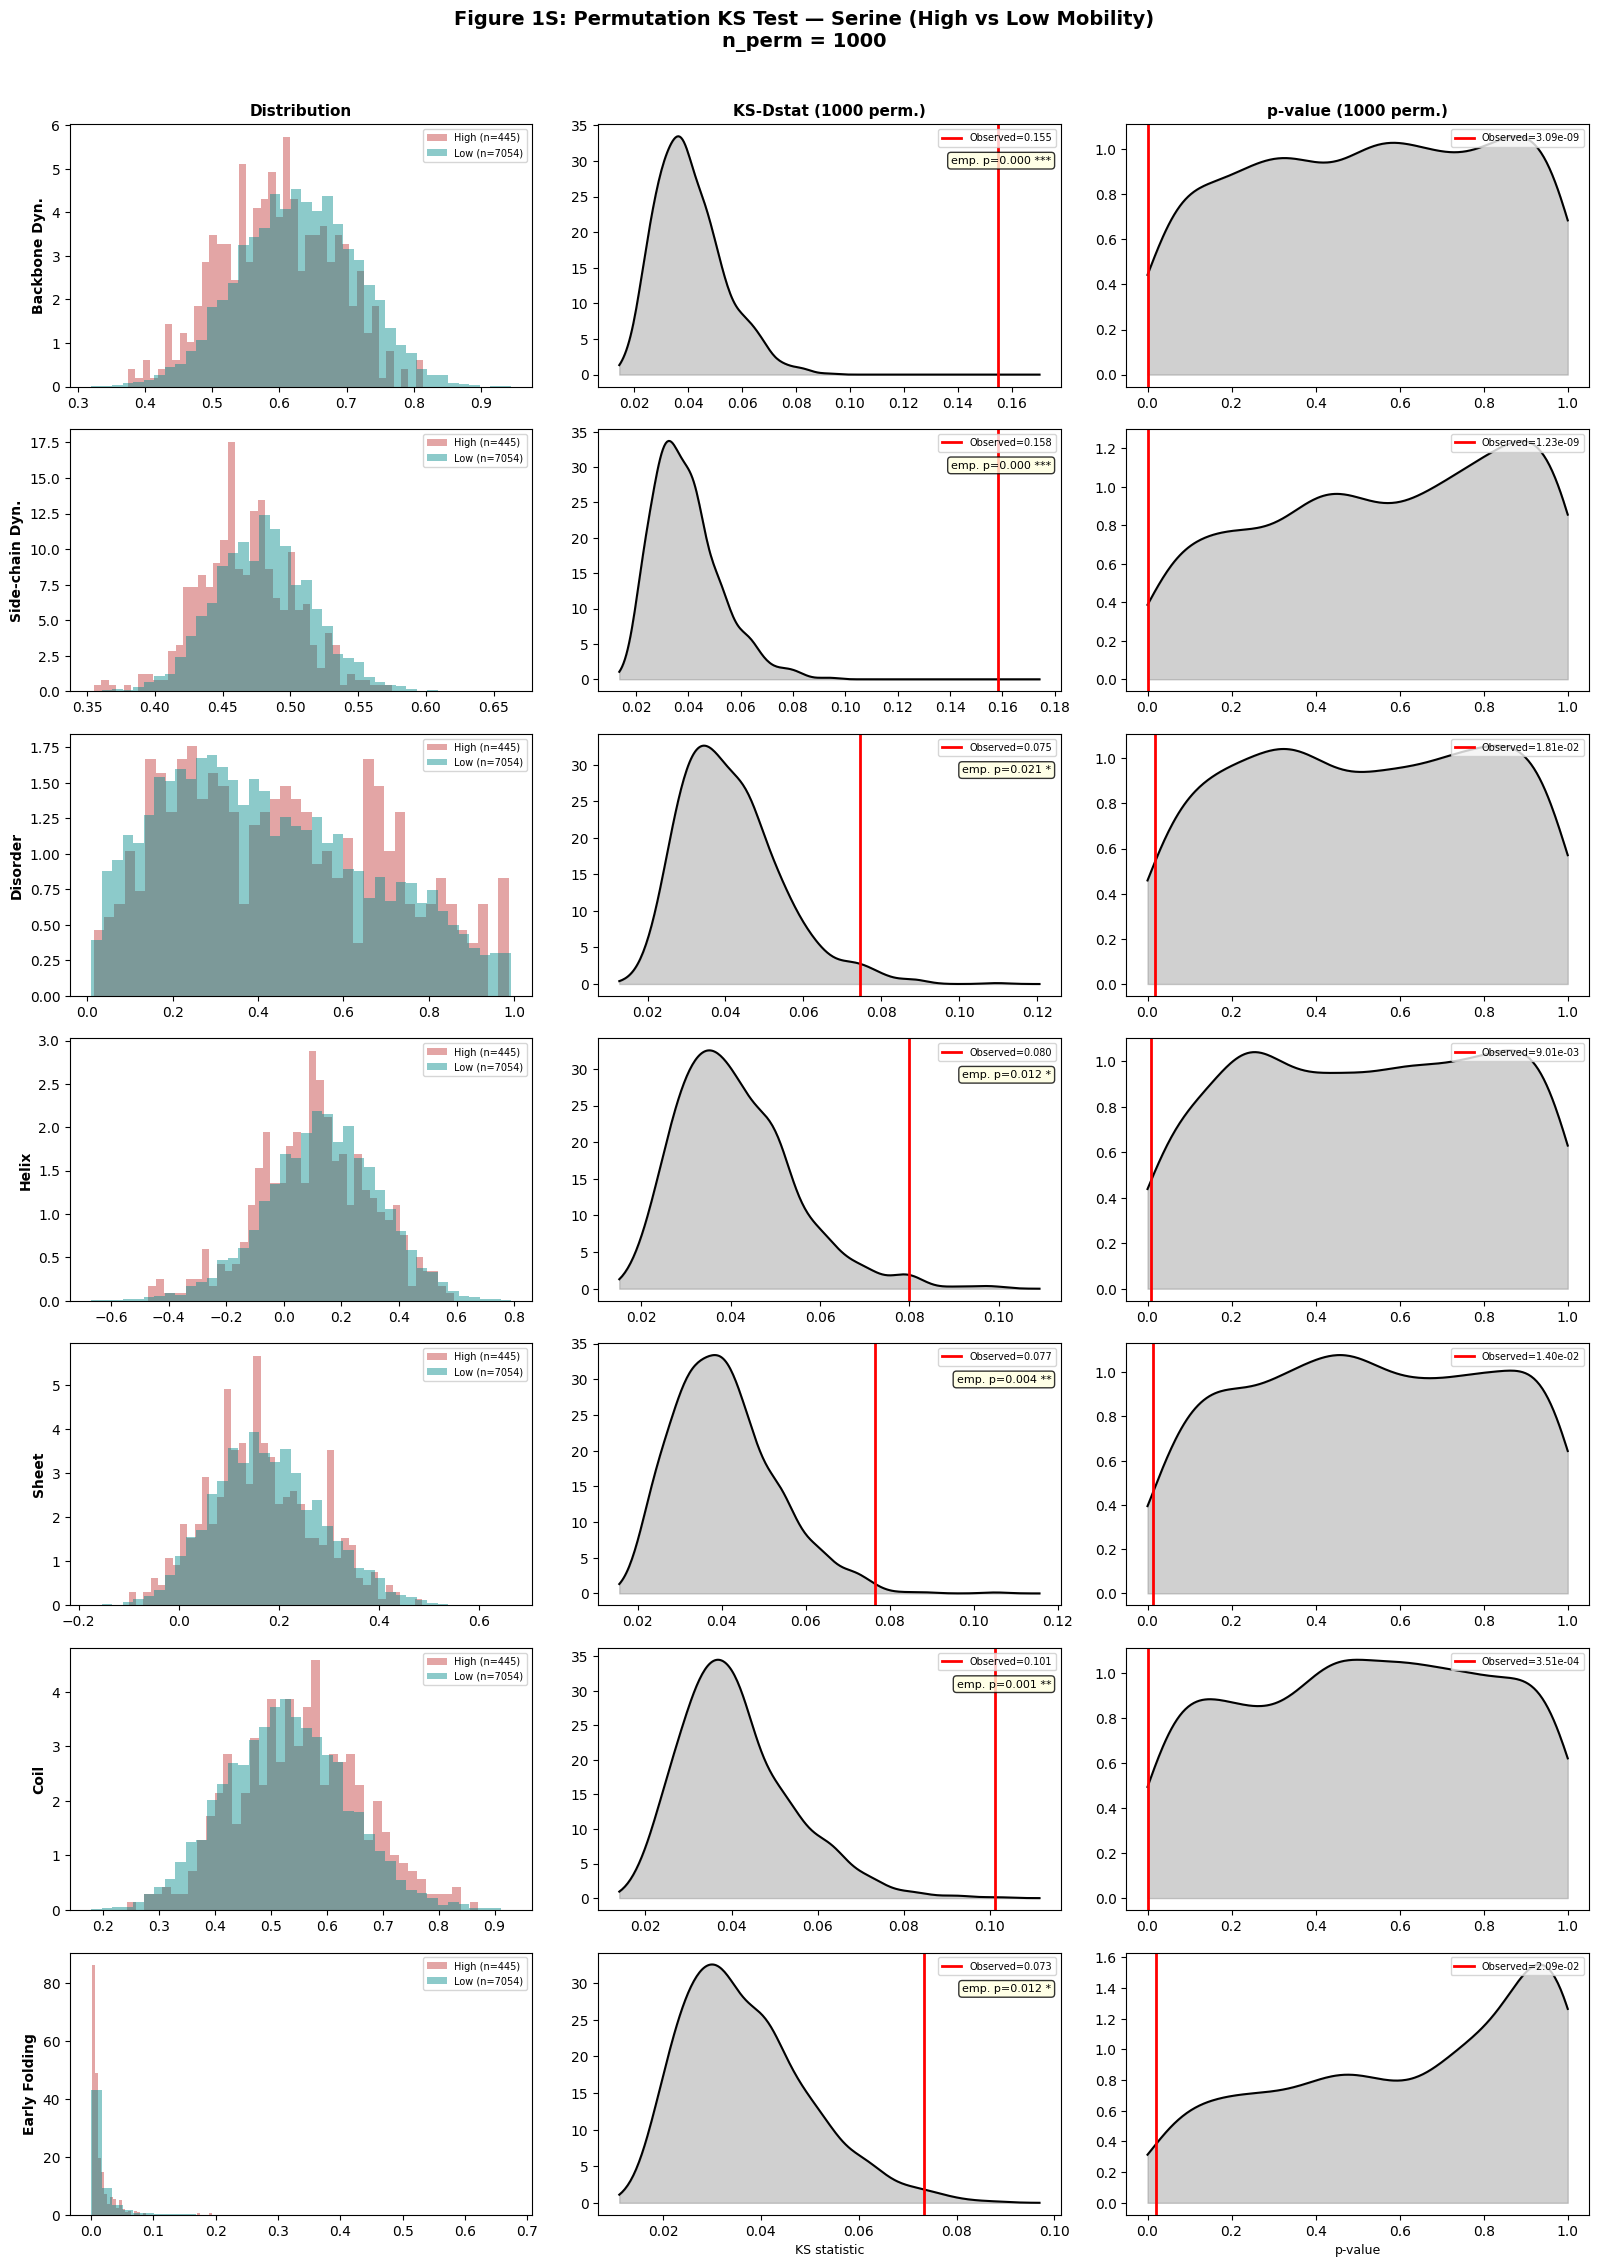

✅ 已保存: Fig1_Permutation_KS_Threonine.png


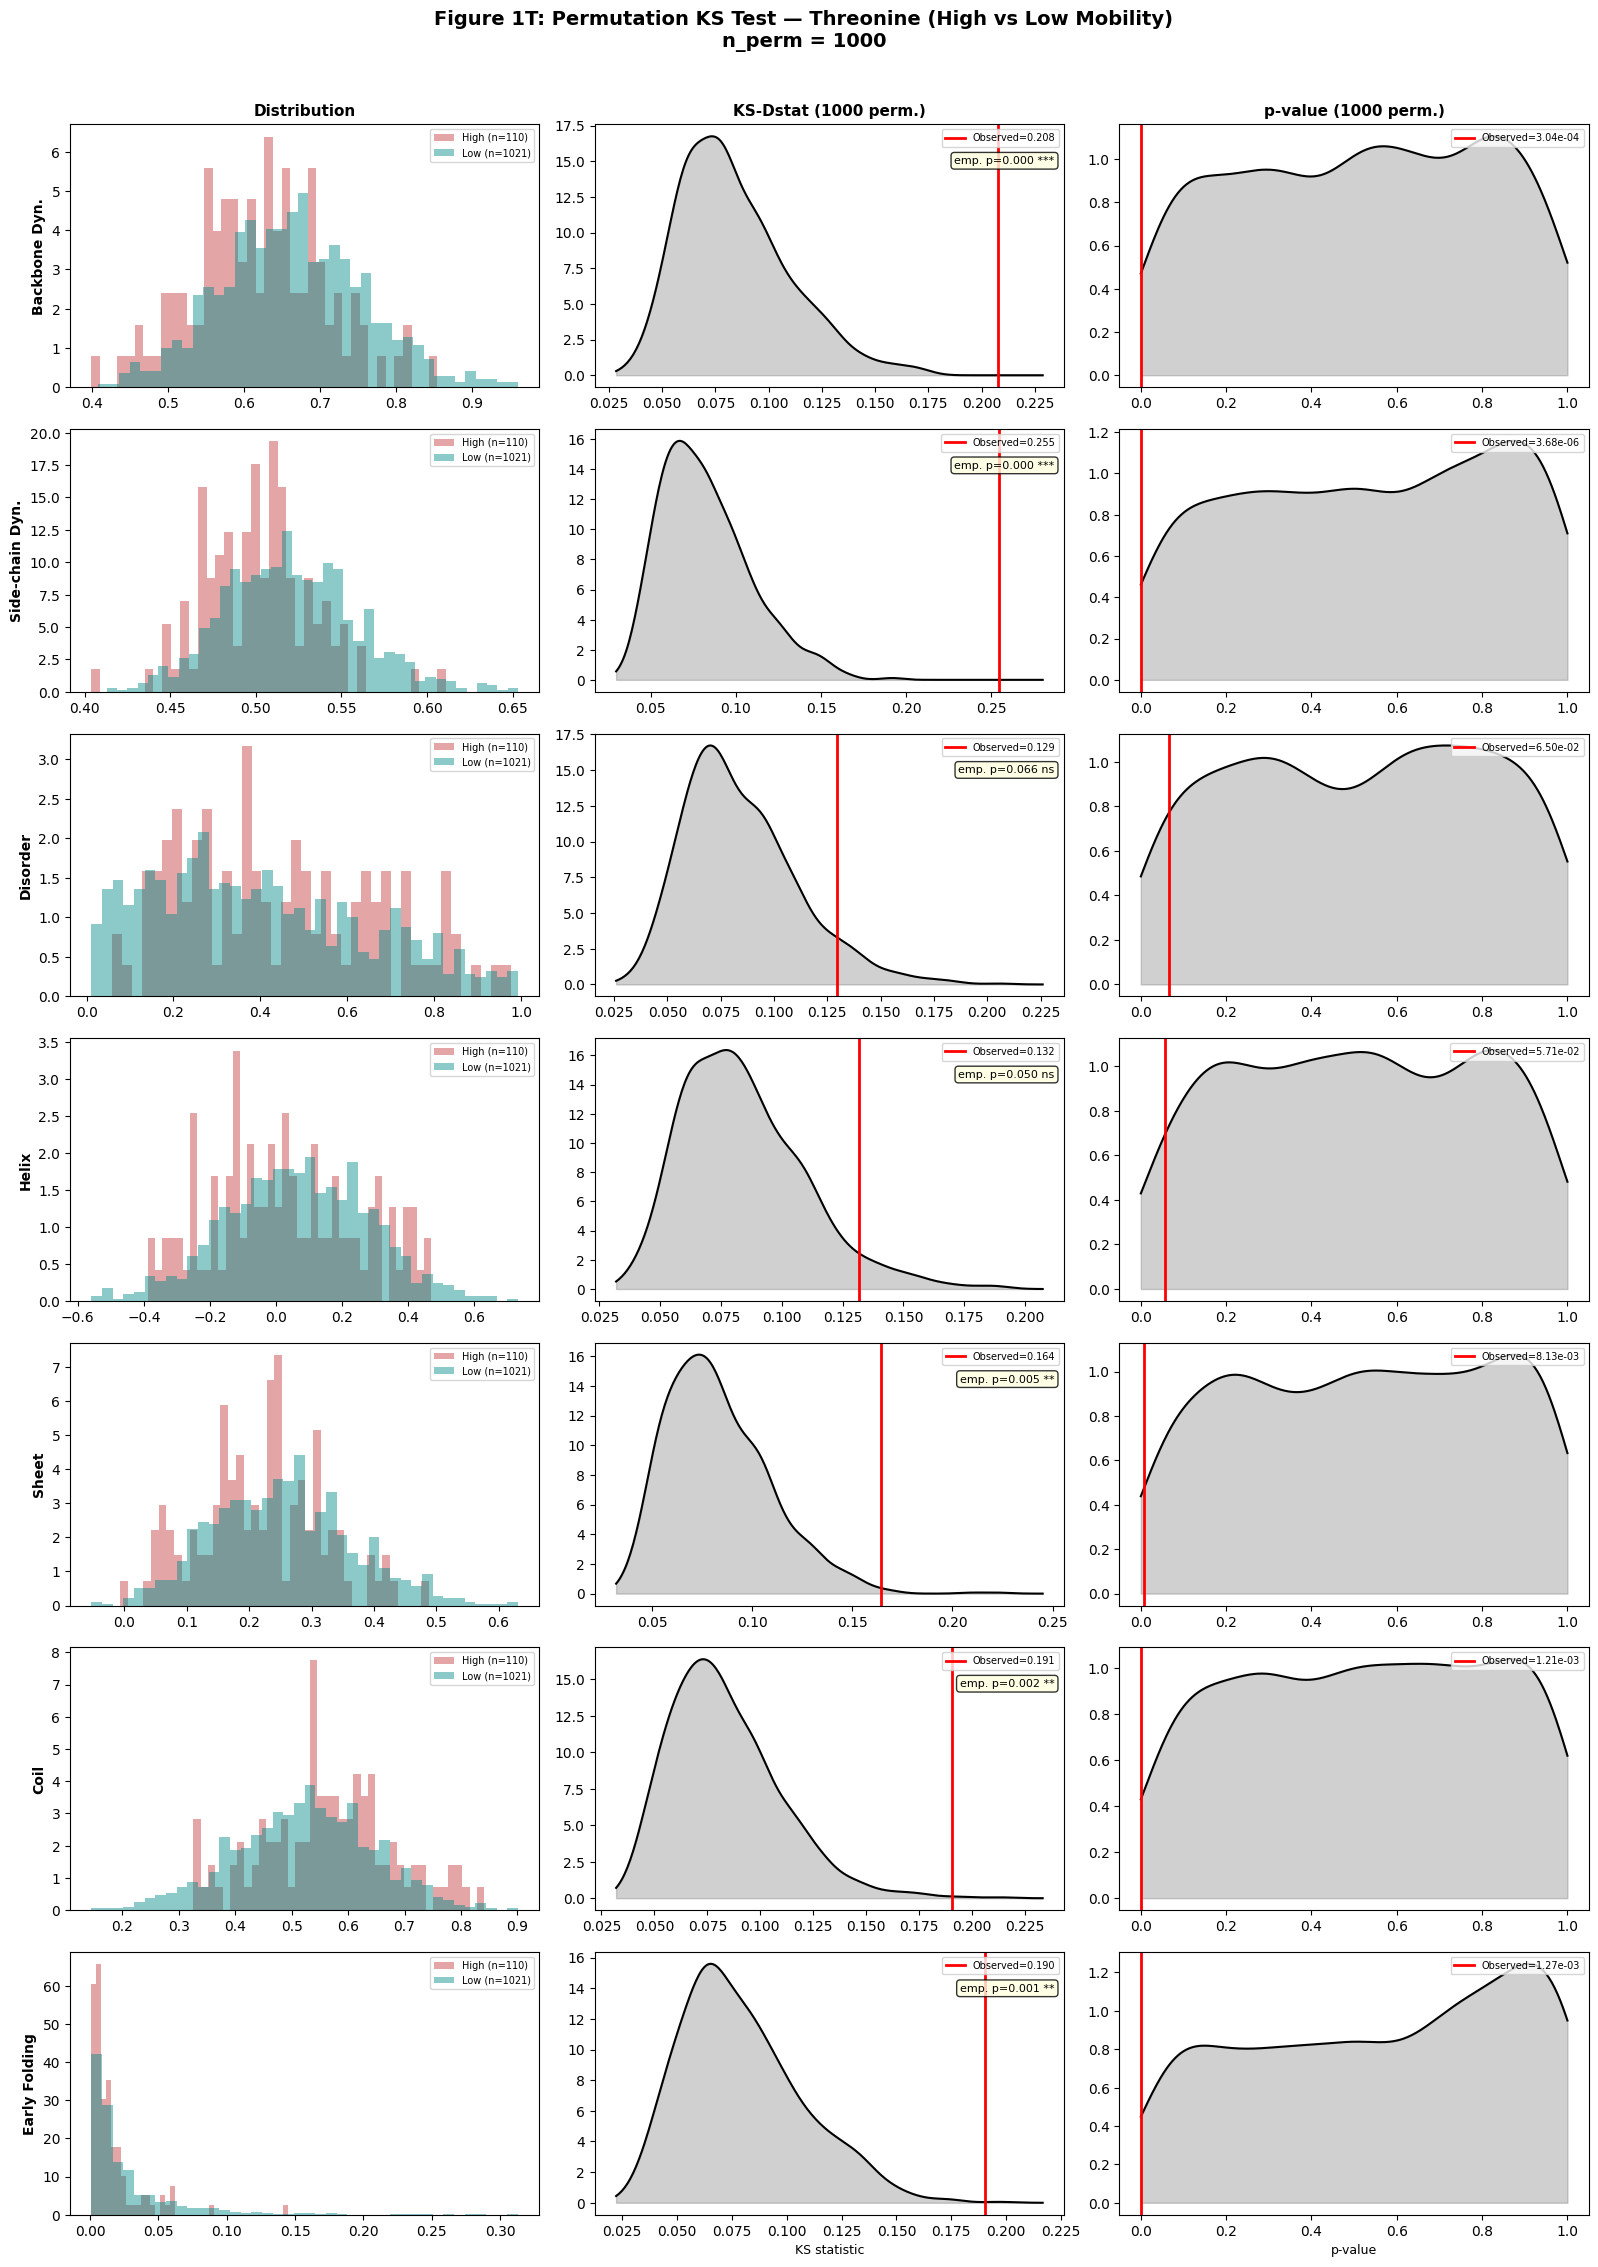

In [ ]:
# Cell PERM-3 (修改版): 图1 绘制 — 去掉灰色柱体，只保留density曲线
# =============================================================================

from scipy.stats import gaussian_kde

def plot_permutation_figure(aa, results_dict, features, groups_dict, 
                            save_path=None, dpi=300):
    """
    仿 Figure 11 格式:
    每行一个 biophysical feature, 三列:
      左: High vs Low density overlay
      中: Permuted KS-Dstat density 曲线 + 真实KS红线
      右: Permuted p-value density 曲线 + 真实p红线
    """
    n_feat = len(features)
    fig, axes = plt.subplots(n_feat, 3, figsize=(16, 3.2 * n_feat))
    
    if n_feat == 1:
        axes = axes.reshape(1, -1)
    
    aa_name = {'S': 'Serine', 'T': 'Threonine', 'Y': 'Tyrosine'}[aa]
    colors_hl = {'High': '#CD5C5C', 'Low': '#008B8B'}
    
    feat_short = {
        'backbone_dynamics':   'Backbone Dyn.',
        'sidechain_dynamics':  'Side-chain Dyn.',
        'disorder_propensity': 'Disorder',
        'helix_propensity':    'Helix',
        'sheet_propensity':    'Sheet',
        'coil_propensity':     'Coil',
        'earlyFolding':        'Early Folding',
    }
    def short_name(f):
        for k, v in feat_short.items():
            if k.lower() == f.lower():
                return v
        return f
    
    for row, feat in enumerate(features):
        r = results_dict[(aa, feat)]
        ax_dist, ax_ks, ax_pv = axes[row]
        
        high_v = groups_dict[f'{aa}_High'][feat].dropna().values
        low_v  = groups_dict[f'{aa}_Low'][feat].dropna().values
        
        label = short_name(feat)
        
        if r['status'] != 'ok':
            for ax in [ax_dist, ax_ks, ax_pv]:
                ax.text(0.5, 0.5, 'N < 5', ha='center', va='center', 
                        transform=ax.transAxes, fontsize=12, color='gray')
                ax.set_yticks([])
            ax_dist.set_ylabel(label, fontsize=10, fontweight='bold')
            continue
        
        # ---- 左列: density overlay ----
        ax_dist.hist(high_v, bins=40, density=True, alpha=0.55, 
                     color=colors_hl['High'], label=f'High (n={len(high_v)})')
        ax_dist.hist(low_v, bins=40, density=True, alpha=0.45, 
                     color=colors_hl['Low'], label=f'Low (n={len(low_v)})')
        ax_dist.legend(fontsize=7, loc='upper right')
        ax_dist.set_ylabel(label, fontsize=10, fontweight='bold')
        if row == 0:
            ax_dist.set_title('Distribution', fontsize=11, fontweight='bold')
        
        # ---- 中列: KS null distribution — 只画 density 曲线 ----
        try:
            kde_ks = gaussian_kde(r['perm_ks_list'])
            x_ks = np.linspace(
                r['perm_ks_list'].min() * 0.9,
                max(r['perm_ks_list'].max(), r['real_ks']) * 1.1,
                300
            )
            ax_ks.fill_between(x_ks, kde_ks(x_ks), alpha=0.3, color='#666666')
            ax_ks.plot(x_ks, kde_ks(x_ks), color='black', lw=1.5)
        except Exception:
            pass
        
        ax_ks.axvline(r['real_ks'], color='red', lw=2, linestyle='-', 
                      label=f"Observed={r['real_ks']:.3f}")
        ax_ks.legend(fontsize=7, loc='upper right')
        ax_ks.set_xlabel('KS statistic' if row == n_feat - 1 else '', fontsize=9)
        if row == 0:
            ax_ks.set_title('KS-Dstat (1000 perm.)', fontsize=11, fontweight='bold')
        
        # empirical p 标注
        emp_p = r['empirical_p']
        sig = '***' if emp_p < 0.001 else '**' if emp_p < 0.01 else '*' if emp_p < 0.05 else 'ns'
        ax_ks.text(0.98, 0.85, f'emp. p={emp_p:.3f} {sig}', 
                   transform=ax_ks.transAxes, fontsize=8, ha='right',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
        
        # ---- 右列: p-value null distribution — 只画 density 曲线 ----
        try:
            kde_pv = gaussian_kde(r['perm_p_list'])
            x_pv = np.linspace(0, 1, 300)
            ax_pv.fill_between(x_pv, kde_pv(x_pv), alpha=0.3, color='#666666')
            ax_pv.plot(x_pv, kde_pv(x_pv), color='black', lw=1.5)
        except Exception:
            pass
        
        ax_pv.axvline(r['real_p'], color='red', lw=2, linestyle='-',
                      label=f"Observed={r['real_p']:.2e}")
        ax_pv.legend(fontsize=7, loc='upper right')
        ax_pv.set_xlabel('p-value' if row == n_feat - 1 else '', fontsize=9)
        if row == 0:
            ax_pv.set_title('p-value (1000 perm.)', fontsize=11, fontweight='bold')
    
    fig.suptitle(f'Figure 1{aa}: Permutation KS Test — {aa_name} (High vs Low Mobility)\n'
                 f'n_perm = {N_PERM}',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"✅ 已保存: {save_path}")
    plt.show()
    return fig

# ---- 重新绘制 S ----
fig1_S = plot_permutation_figure(
    'S', fig1_results, biophysical_features, groups,
    save_path='Fig1_Permutation_KS_Serine.png'
)

# ---- 重新绘制 T ----
fig1_T = plot_permutation_figure(
    'T', fig1_results, biophysical_features, groups,
    save_path='Fig1_Permutation_KS_Threonine.png'
)

✓ 图2计算完成: 28 组
✅ 已保存: Fig2_WithinGroup_S_vs_T.png


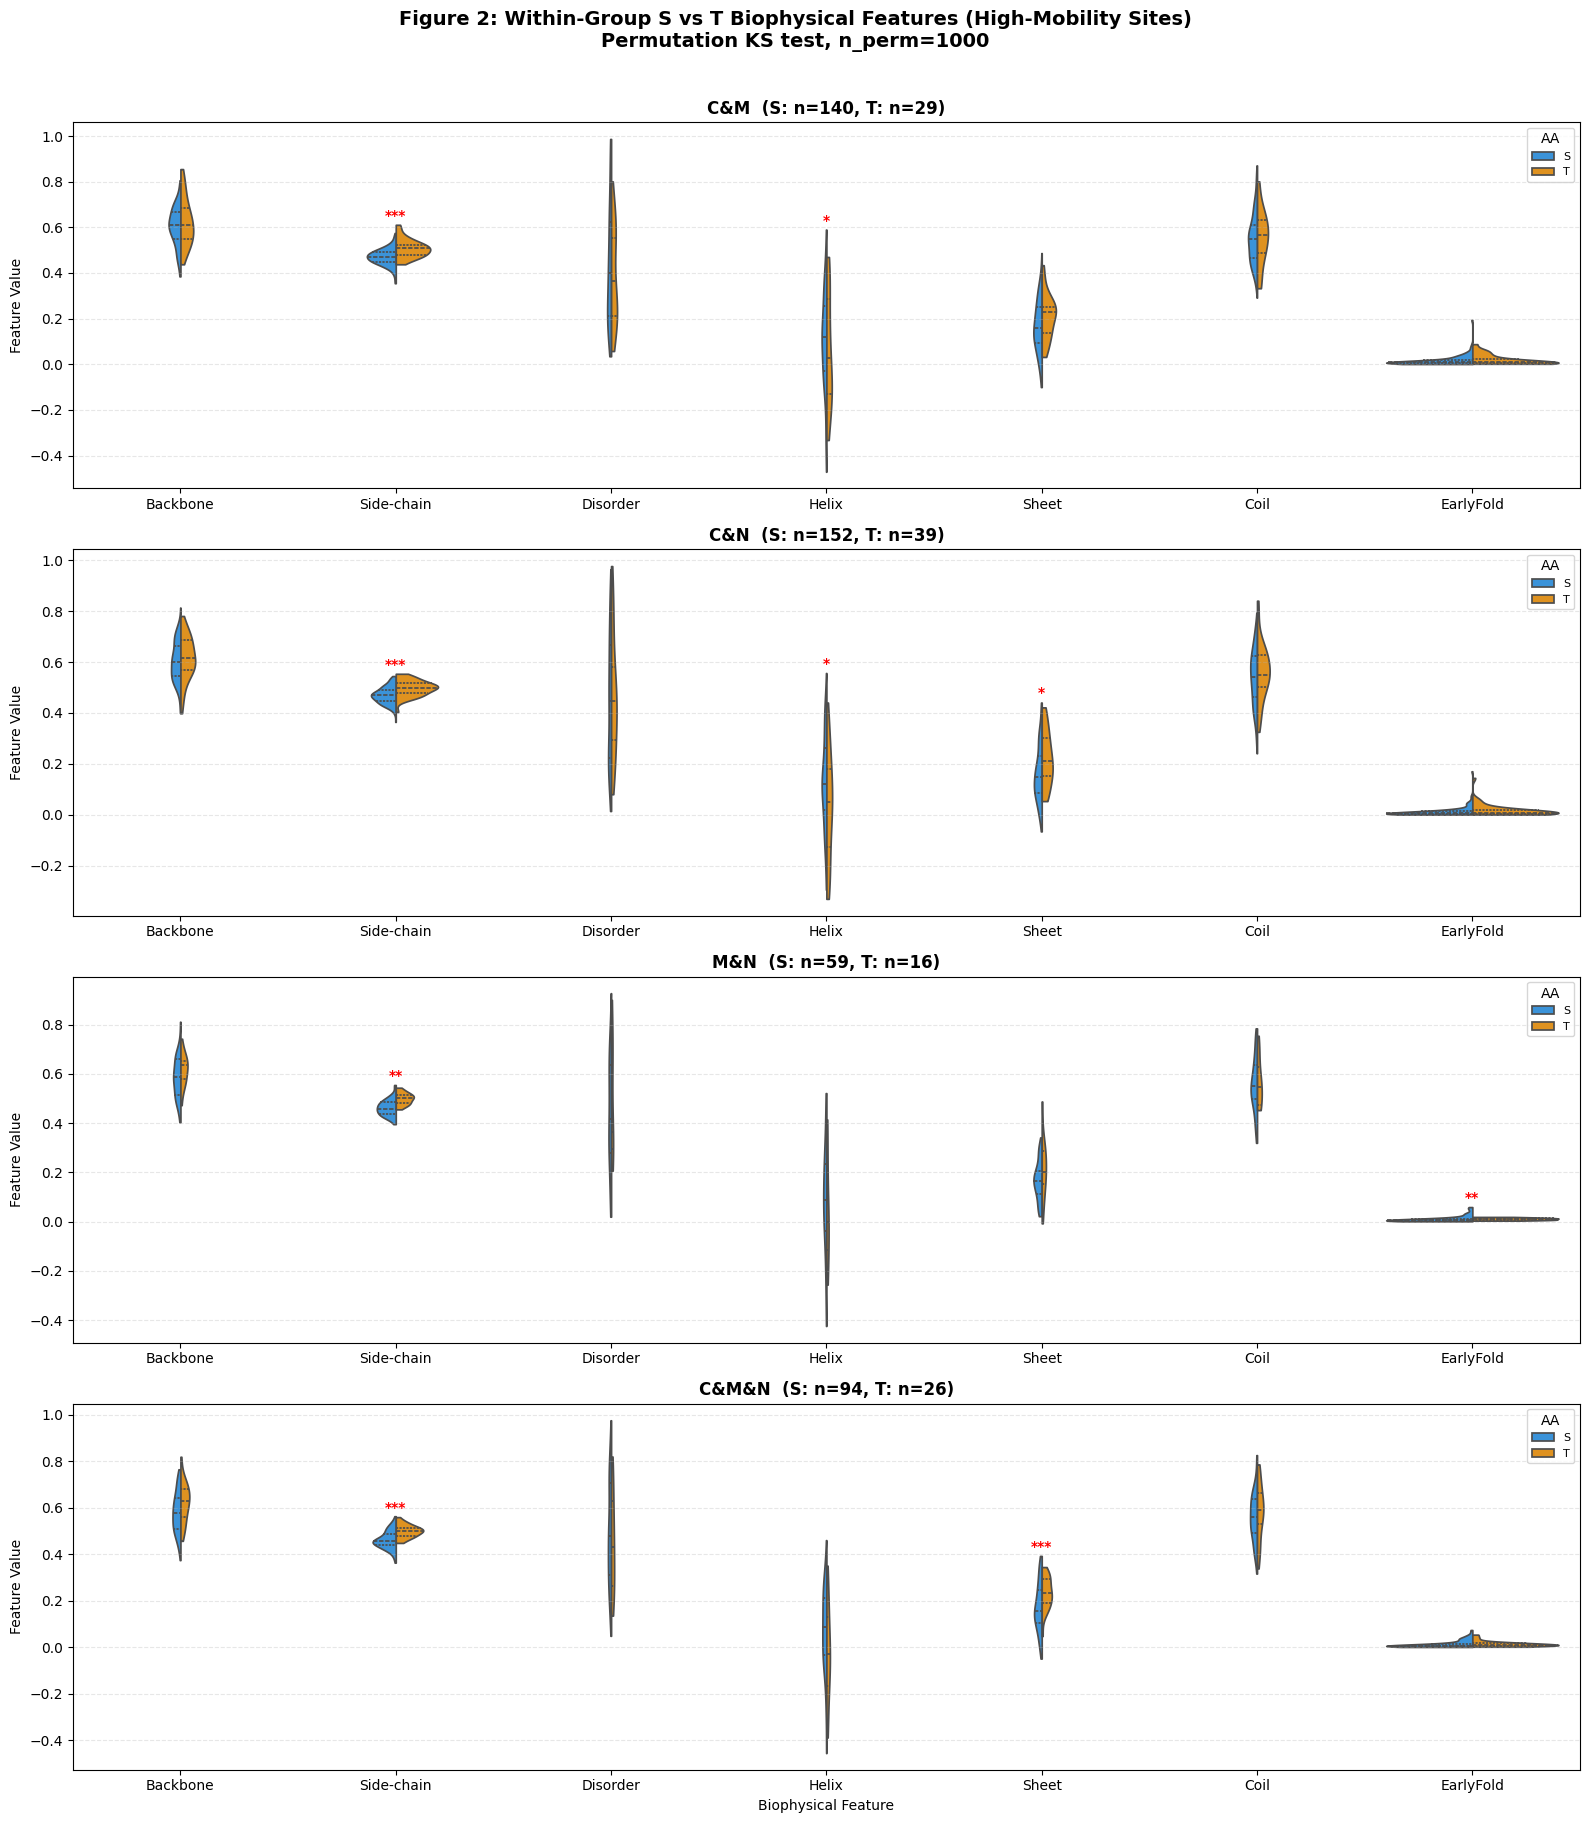

In [ ]:
# Cell PERM-4: 图2 — 组内 S vs T (per spatial group) — 更新统计方法
# =============================================================================
# 在每个 spatial group 内, 比较 S vs T 的 biophysical features
# 统计方法统一为 permutation KS (1000次)

aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'
mob_df = success_df[success_df['movement_score'] >= MOBILITY_THRESHOLD].copy()

fig2_results = {}  # key: (group, feature, comparison) → result

for grp in analysis_groups:
    gdf = mob_df[mob_df['LocalizationGroup'] == grp]
    s_vals_all = gdf[gdf[aa_col] == 'S']
    t_vals_all = gdf[gdf[aa_col] == 'T']
    
    for i, feat in enumerate(biophysical_features):
        s_v = s_vals_all[feat].dropna().values
        t_v = t_vals_all[feat].dropna().values
        
        seed_i = 3000 + analysis_groups.index(grp) * 100 + i
        result = permutation_ks_test(s_v, t_v, n_perm=N_PERM, seed=seed_i)
        fig2_results[(grp, feat, 'S_vs_T')] = result

print(f"✓ 图2计算完成: {len(fig2_results)} 组")

# ---- 绘图: 每个 spatial group 一行, 7 features 为 x 轴, S/T violin ----

fig2, axes2 = plt.subplots(len(analysis_groups), 1, 
                            figsize=(16, 4.5 * len(analysis_groups)))
if len(analysis_groups) == 1:
    axes2 = [axes2]

for row, grp in enumerate(analysis_groups):
    ax = axes2[row]
    gdf = mob_df[mob_df['LocalizationGroup'] == grp]
    
    # 准备长格式数据
    plot_rows = []
    for feat in biophysical_features:
        for aa in ['S', 'T']:
            vals = gdf[gdf[aa_col] == aa][feat].dropna()
            for v in vals:
                plot_rows.append({'Feature': feat, 'AA': aa, 'Value': v})
    
    plot_df = pd.DataFrame(plot_rows)
    
    if len(plot_df) == 0:
        ax.set_title(f'{grp} — no data')
        continue
    
    # 简短 feature 名
    feat_short_map = {
        'backbone_dynamics': 'Backbone', 'sidechain_dynamics': 'Side-chain',
        'disorder_propensity': 'Disorder', 'helix_propensity': 'Helix',
        'sheet_propensity': 'Sheet', 'coil_propensity': 'Coil',
        'earlyFolding': 'EarlyFold'
    }
    plot_df['Feature_short'] = plot_df['Feature'].map(
        lambda x: next((v for k, v in feat_short_map.items() 
                        if k.lower() == x.lower()), x))
    
    sns.violinplot(data=plot_df, x='Feature_short', y='Value', hue='AA',
                   palette={'S': '#2196F3', 'T': '#FF9800'},
                   split=True, inner='quartile', ax=ax, cut=0)
    
    # 添加显著性标注
    for j, feat in enumerate(biophysical_features):
        r = fig2_results.get((grp, feat, 'S_vs_T'))
        if r and r['status'] == 'ok':
            emp_p = r['empirical_p']
            sig = '***' if emp_p < 0.001 else '**' if emp_p < 0.01 else '*' if emp_p < 0.05 else 'ns'
            if sig != 'ns':
                y_top = plot_df[plot_df['Feature'] == feat]['Value'].max()
                ax.text(j, y_top + 0.02, sig, ha='center', fontsize=10, 
                        fontweight='bold', color='red')
    
    n_s = len(gdf[gdf[aa_col] == 'S'])
    n_t = len(gdf[gdf[aa_col] == 'T'])
    ax.set_title(f'{grp}  (S: n={n_s}, T: n={n_t})', fontsize=12, fontweight='bold')
    ax.set_xlabel('' if row < len(analysis_groups) - 1 else 'Biophysical Feature')
    ax.set_ylabel('Feature Value')
    ax.legend(title='AA', fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig2.suptitle('Figure 2: Within-Group S vs T Biophysical Features (High-Mobility Sites)\n'
              f'Permutation KS test, n_perm={N_PERM}',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Fig2_WithinGroup_S_vs_T.png', dpi=300, bbox_inches='tight')
print("✅ 已保存: Fig2_WithinGroup_S_vs_T.png")
plt.show()


✅ 已保存: Fig3_BetweenGroup_Heatmap_v5.png


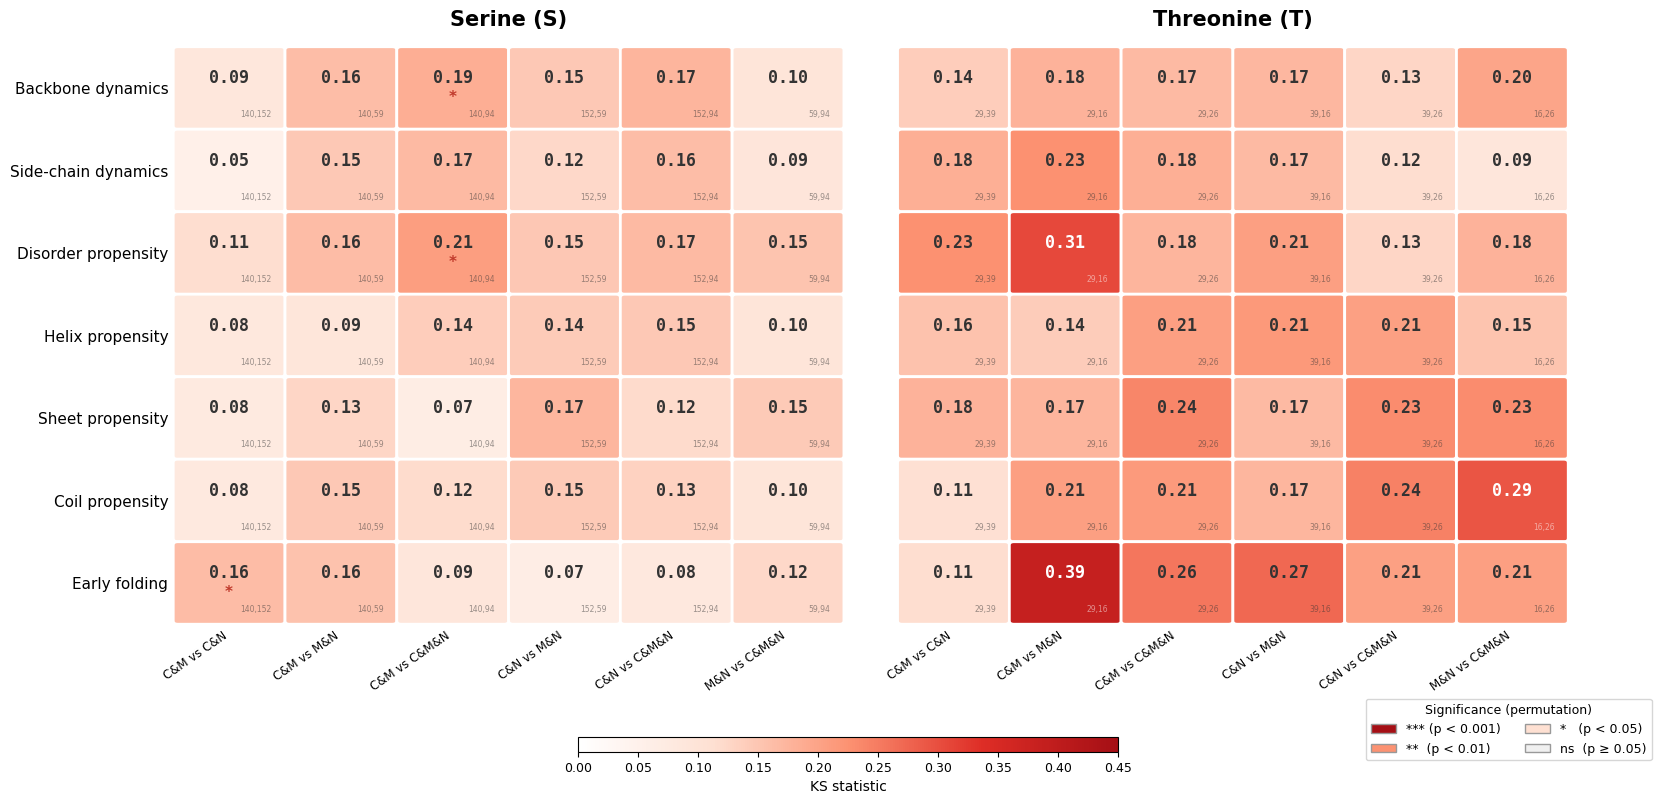

In [ ]:
# Cell PERM-5 (v5): 图3 — 连续色阶 + 圆角 + 星号 + 样本量
# =============================================================================

from itertools import combinations
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

group_pairs = list(combinations(analysis_groups, 2))

feat_short_list = []
for f in biophysical_features:
    for k, v in {'backbone_dynamics': 'Backbone dynamics', 
                 'sidechain_dynamics': 'Side-chain dynamics',
                 'disorder_propensity': 'Disorder propensity', 
                 'helix_propensity': 'Helix propensity',
                 'sheet_propensity': 'Sheet propensity', 
                 'coil_propensity': 'Coil propensity',
                 'earlyFolding': 'Early folding'}.items():
        if k.lower() == f.lower():
            feat_short_list.append(v)
            break
    else:
        feat_short_list.append(f)

pair_labels = [f'{g1} vs {g2}' for g1, g2 in group_pairs]

# ---- 连续色阶: 白→橙→深红，映射 KS 值 (0 ~ 0.45) ----
cmap = mcolors.LinearSegmentedColormap.from_list(
    'ks_red', ['#FFFFFF', '#FEE0D2', '#FC9272', '#DE2D26', '#A50F15'], N=256
)
norm = mcolors.Normalize(vmin=0, vmax=0.45)

fig3, axes3 = plt.subplots(1, 2, figsize=(18, 7.5),
                            gridspec_kw={'wspace': 0.08})
fig3.patch.set_facecolor('white')

for col_idx, aa in enumerate(['S', 'T']):
    ax = axes3[col_idx]
    ax.set_facecolor('white')
    
    n_r = len(biophysical_features)
    n_c = len(group_pairs)
    
    # 收集数据
    ks_vals = np.full((n_r, n_c), np.nan)
    emp_ps = np.full((n_r, n_c), np.nan)
    n_as = np.full((n_r, n_c), 0, dtype=int)
    n_bs = np.full((n_r, n_c), 0, dtype=int)
    
    for i, feat in enumerate(biophysical_features):
        for j, (g1, g2) in enumerate(group_pairs):
            r = fig3_results[(aa, feat, g1, g2)]
            if r['status'] != 'ok':
                continue
            ks_vals[i, j] = r['real_ks']
            emp_ps[i, j] = r['empirical_p']
            n_as[i, j] = r['n_a']
            n_bs[i, j] = r['n_b']
    
    # 画格子
    for i in range(n_r):
        for j in range(n_c):
            ks = ks_vals[i, j]
            ep = emp_ps[i, j]
            
            # 颜色：基于 KS 值的连续色阶
            if np.isnan(ks):
                face_color = '#F5F5F5'
            else:
                face_color = cmap(norm(ks))
            
            # 判断深色背景用白字，浅色用黑字
            rgba = mcolors.to_rgba(face_color)
            brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = '#FFFFFF' if brightness < 0.55 else '#333333'
            star_color = '#FFFFFF' if brightness < 0.55 else '#C0392B'
            
            # 圆角矩形
            rect = matplotlib.patches.FancyBboxPatch(
                (j + 0.04, i + 0.04), 0.92, 0.92,
                boxstyle="round,pad=0.04",
                facecolor=face_color, edgecolor='white', linewidth=2
            )
            ax.add_patch(rect)
            
            if np.isnan(ks):
                ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                       fontsize=9, color='#AAAAAA')
                continue
            
            # 显著性
            sig_mark = ''
            if not np.isnan(ep):
                if ep < 0.001:   sig_mark = '***'
                elif ep < 0.01:  sig_mark = '**'
                elif ep < 0.05:  sig_mark = '*'
            
            # KS 数值 (居中偏上)
            ax.text(j + 0.5, i + 0.38, f'{ks:.2f}',
                   ha='center', va='center',
                   fontsize=12, fontweight='bold', color=text_color,
                   family='monospace')
            
            # 星号 (KS下方)
            if sig_mark:
                ax.text(j + 0.5, i + 0.62, sig_mark,
                       ha='center', va='center',
                       fontsize=11, fontweight='bold', color=star_color)
            
            # 样本量 (右下角小字)
            ax.text(j + 0.88, i + 0.88, f'{n_as[i,j]},{n_bs[i,j]}',
                   ha='right', va='bottom',
                   fontsize=5.5, color=text_color, alpha=0.5)
    
    # 轴
    ax.set_xlim(0, n_c)
    ax.set_ylim(0, n_r)
    ax.invert_yaxis()
    
    ax.set_xticks([j + 0.5 for j in range(n_c)])
    ax.set_xticklabels(pair_labels, fontsize=8.5, rotation=35, ha='right')
    
    if col_idx == 0:
        ax.set_yticks([i + 0.5 for i in range(n_r)])
        ax.set_yticklabels(feat_short_list, fontsize=11)
    else:
        ax.set_yticks([])
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)
    
    aa_name = 'Serine' if aa == 'S' else 'Threonine'
    ax.set_title(f'{aa_name} ({aa})', fontsize=15, fontweight='bold', pad=15)

# ---- Colorbar ----
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig3.add_axes([0.35, -0.06, 0.3, 0.02])   # [left, bottom, width, height]
cbar = fig3.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('KS statistic', fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ---- 显著性图例 ----
legend_handles = [
    mpatches.Patch(facecolor='#A50F15', edgecolor='#999', label='*** (p < 0.001)'),
    mpatches.Patch(facecolor='#FC9272', edgecolor='#999', label='**  (p < 0.01)'),
    mpatches.Patch(facecolor='#FEE0D2', edgecolor='#999', label='*   (p < 0.05)'),
    mpatches.Patch(facecolor='#F0F0F0', edgecolor='#999', label='ns  (p ≥ 0.05)'),
]
fig3.legend(handles=legend_handles, loc='lower right', ncol=2,
            fontsize=9, frameon=True, edgecolor='#CCC',
            bbox_to_anchor=(0.95, -0.08),
            title='Significance (permutation)', title_fontsize=9)

fig3.suptitle(''
              '',
              fontsize=14, fontweight='bold', y=1.01)

plt.savefig('Fig3_BetweenGroup_Heatmap_v5.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("✅ 已保存: Fig3_BetweenGroup_Heatmap_v5.png")
plt.show()

In [ ]:
# Cell A: 通用设置 — permutation 函数 + 全局排版 + TIFF
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from itertools import combinations
import warnings, os, json, re
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────
# 🎨 全局排版：50岁戴眼镜也能看清
# ──────────────────────────────────────────────────────
FONT_CFG = {
    'font.family':      'Arial',       # PPT 常用字体
    'font.size':         14,           # 基础字号 ↑
    'axes.titlesize':    18,           # 子图标题
    'axes.labelsize':    16,           # 轴标签
    'xtick.labelsize':   13,           # x刻度
    'ytick.labelsize':   13,           # y刻度
    'legend.fontsize':   13,           # 图例
    'figure.titlesize':  20,           # 总标题
    'axes.linewidth':    1.5,          # 轴线粗细
    'lines.linewidth':   2.0,
}
matplotlib.rcParams.update(FONT_CFG)

# TIFF 输出函数
def save_tiff(fig, filename, dpi=300):
    """保存为高质量 TIFF（PPT 友好）"""
    path = filename if filename.endswith('.tiff') else filename.rsplit('.', 1)[0] + '.tiff'
    fig.savefig(path, dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none',
                format='tiff', pil_kwargs={'compression': 'tiff_lzw'})
    print(f"  ✅ 已保存: {path}")
    return path

# ──────────────────────────────────────────────────────
# 🔬 Permutation KS Test 函数
# ──────────────────────────────────────────────────────
def permutation_ks_test(data_a, data_b, n_perm=1000, seed=42, min_n=5):
    """
    Permutation-based KS test.
    Returns dict with: status, real_ks, real_p, empirical_p,
                        perm_ks_list, perm_p_list, n_a, n_b,
                        mean_a, mean_b, mean_diff
    """
    a = np.array(data_a, dtype=float)
    b = np.array(data_b, dtype=float)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]

    if len(a) < min_n or len(b) < min_n:
        return {'status': 'insufficient', 'n_a': len(a), 'n_b': len(b)}

    # 真实 KS
    real_ks, real_p = stats.ks_2samp(a, b)
    mean_a = np.mean(a)
    mean_b = np.mean(b)

    # Permutation
    rng = np.random.RandomState(seed)
    combined = np.concatenate([a, b])
    n_a = len(a)
    perm_ks_list = np.empty(n_perm)
    perm_p_list  = np.empty(n_perm)

    for k in range(n_perm):
        rng.shuffle(combined)
        pk, pp = stats.ks_2samp(combined[:n_a], combined[n_a:])
        perm_ks_list[k] = pk
        perm_p_list[k]  = pp

    empirical_p = np.mean(perm_ks_list >= real_ks)

    return {
        'status':       'ok',
        'real_ks':       real_ks,
        'real_p':        real_p,
        'empirical_p':   empirical_p,
        'perm_ks_list':  perm_ks_list,
        'perm_p_list':   perm_p_list,
        'n_a':           len(a),
        'n_b':           len(b),
        'mean_a':        mean_a,
        'mean_b':        mean_b,
        'mean_diff':     mean_a - mean_b,   # ← 导师要求: Δmean
    }

# ──────────────────────────────────────────────────────
# 📐 通用常量
# ──────────────────────────────────────────────────────
N_PERM = 1000
SEED_BASE = 2026
MOBILITY_THRESHOLD = 10
LOW_MOB_THRESHOLD  = 5

analysis_groups = ['C&M', 'C&N', 'M&N', 'C&M&N']

# 颜色方案
COLOR_HIGH = '#CD5C5C'   # 印第安红 — High mobility
COLOR_LOW  = '#4682B4'   # 钢蓝   — Low mobility
COLORS_HL  = {'High': COLOR_HIGH, 'Low': COLOR_LOW}

# Feature 短名（PPT友好）
FEAT_SHORT = {
    'backbone_dynamics':   'Backbone\ndynamics',
    'sidechain_dynamics':  'Side-chain\ndynamics',
    'disorder_propensity': 'Disorder',
    'helix_propensity':    'Helix',
    'sheet_propensity':    'Sheet',
    'coil_propensity':     'Coil',
    'earlyFolding':        'Early\nfolding',
}
def short_feat(f):
    for k, v in FEAT_SHORT.items():
        if k.lower() == f.lower():
            return v
    return f

# 显著性星号
def sig_stars(p):
    if np.isnan(p): return ''
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return 'ns'

print("✅ Cell A 完成: permutation 函数 + 排版 + TIFF 已就绪")


✅ Cell A 完成: permutation 函数 + 排版 + TIFF 已就绪


✓ Fig2 计算完成: 56 组 (4 groups × 2 AA × 7 features)

Group    AA   Feature                 n_high   n_low      KS   emp_p    Δmean
--------------------------------------------------------------------------------
C&M      S    backbone_dynamics          140     419   0.144   0.025  -0.0298
C&M      S    sidechain_dynamics         140     419   0.154   0.009  -0.0116
C&M      S    disorder_propensity        140     419   0.051   0.919  +0.0114
C&M      S    helix_propensity           140     419   0.118   0.085  -0.0351
C&M      S    sheet_propensity           140     419   0.059   0.828  -0.0097
C&M      S    coil_propensity            140     419   0.113   0.138  +0.0253
C&M      S    earlyFolding               140     419   0.068   0.586  -0.0027
C&M      T    backbone_dynamics           29      66   0.268   0.065  -0.0502
C&M      T    sidechain_dynamics          29      66   0.304   0.022  -0.0160
C&M      T    disorder_propensity         29      66   0.169   0.533  +0.0057
C&M      T 

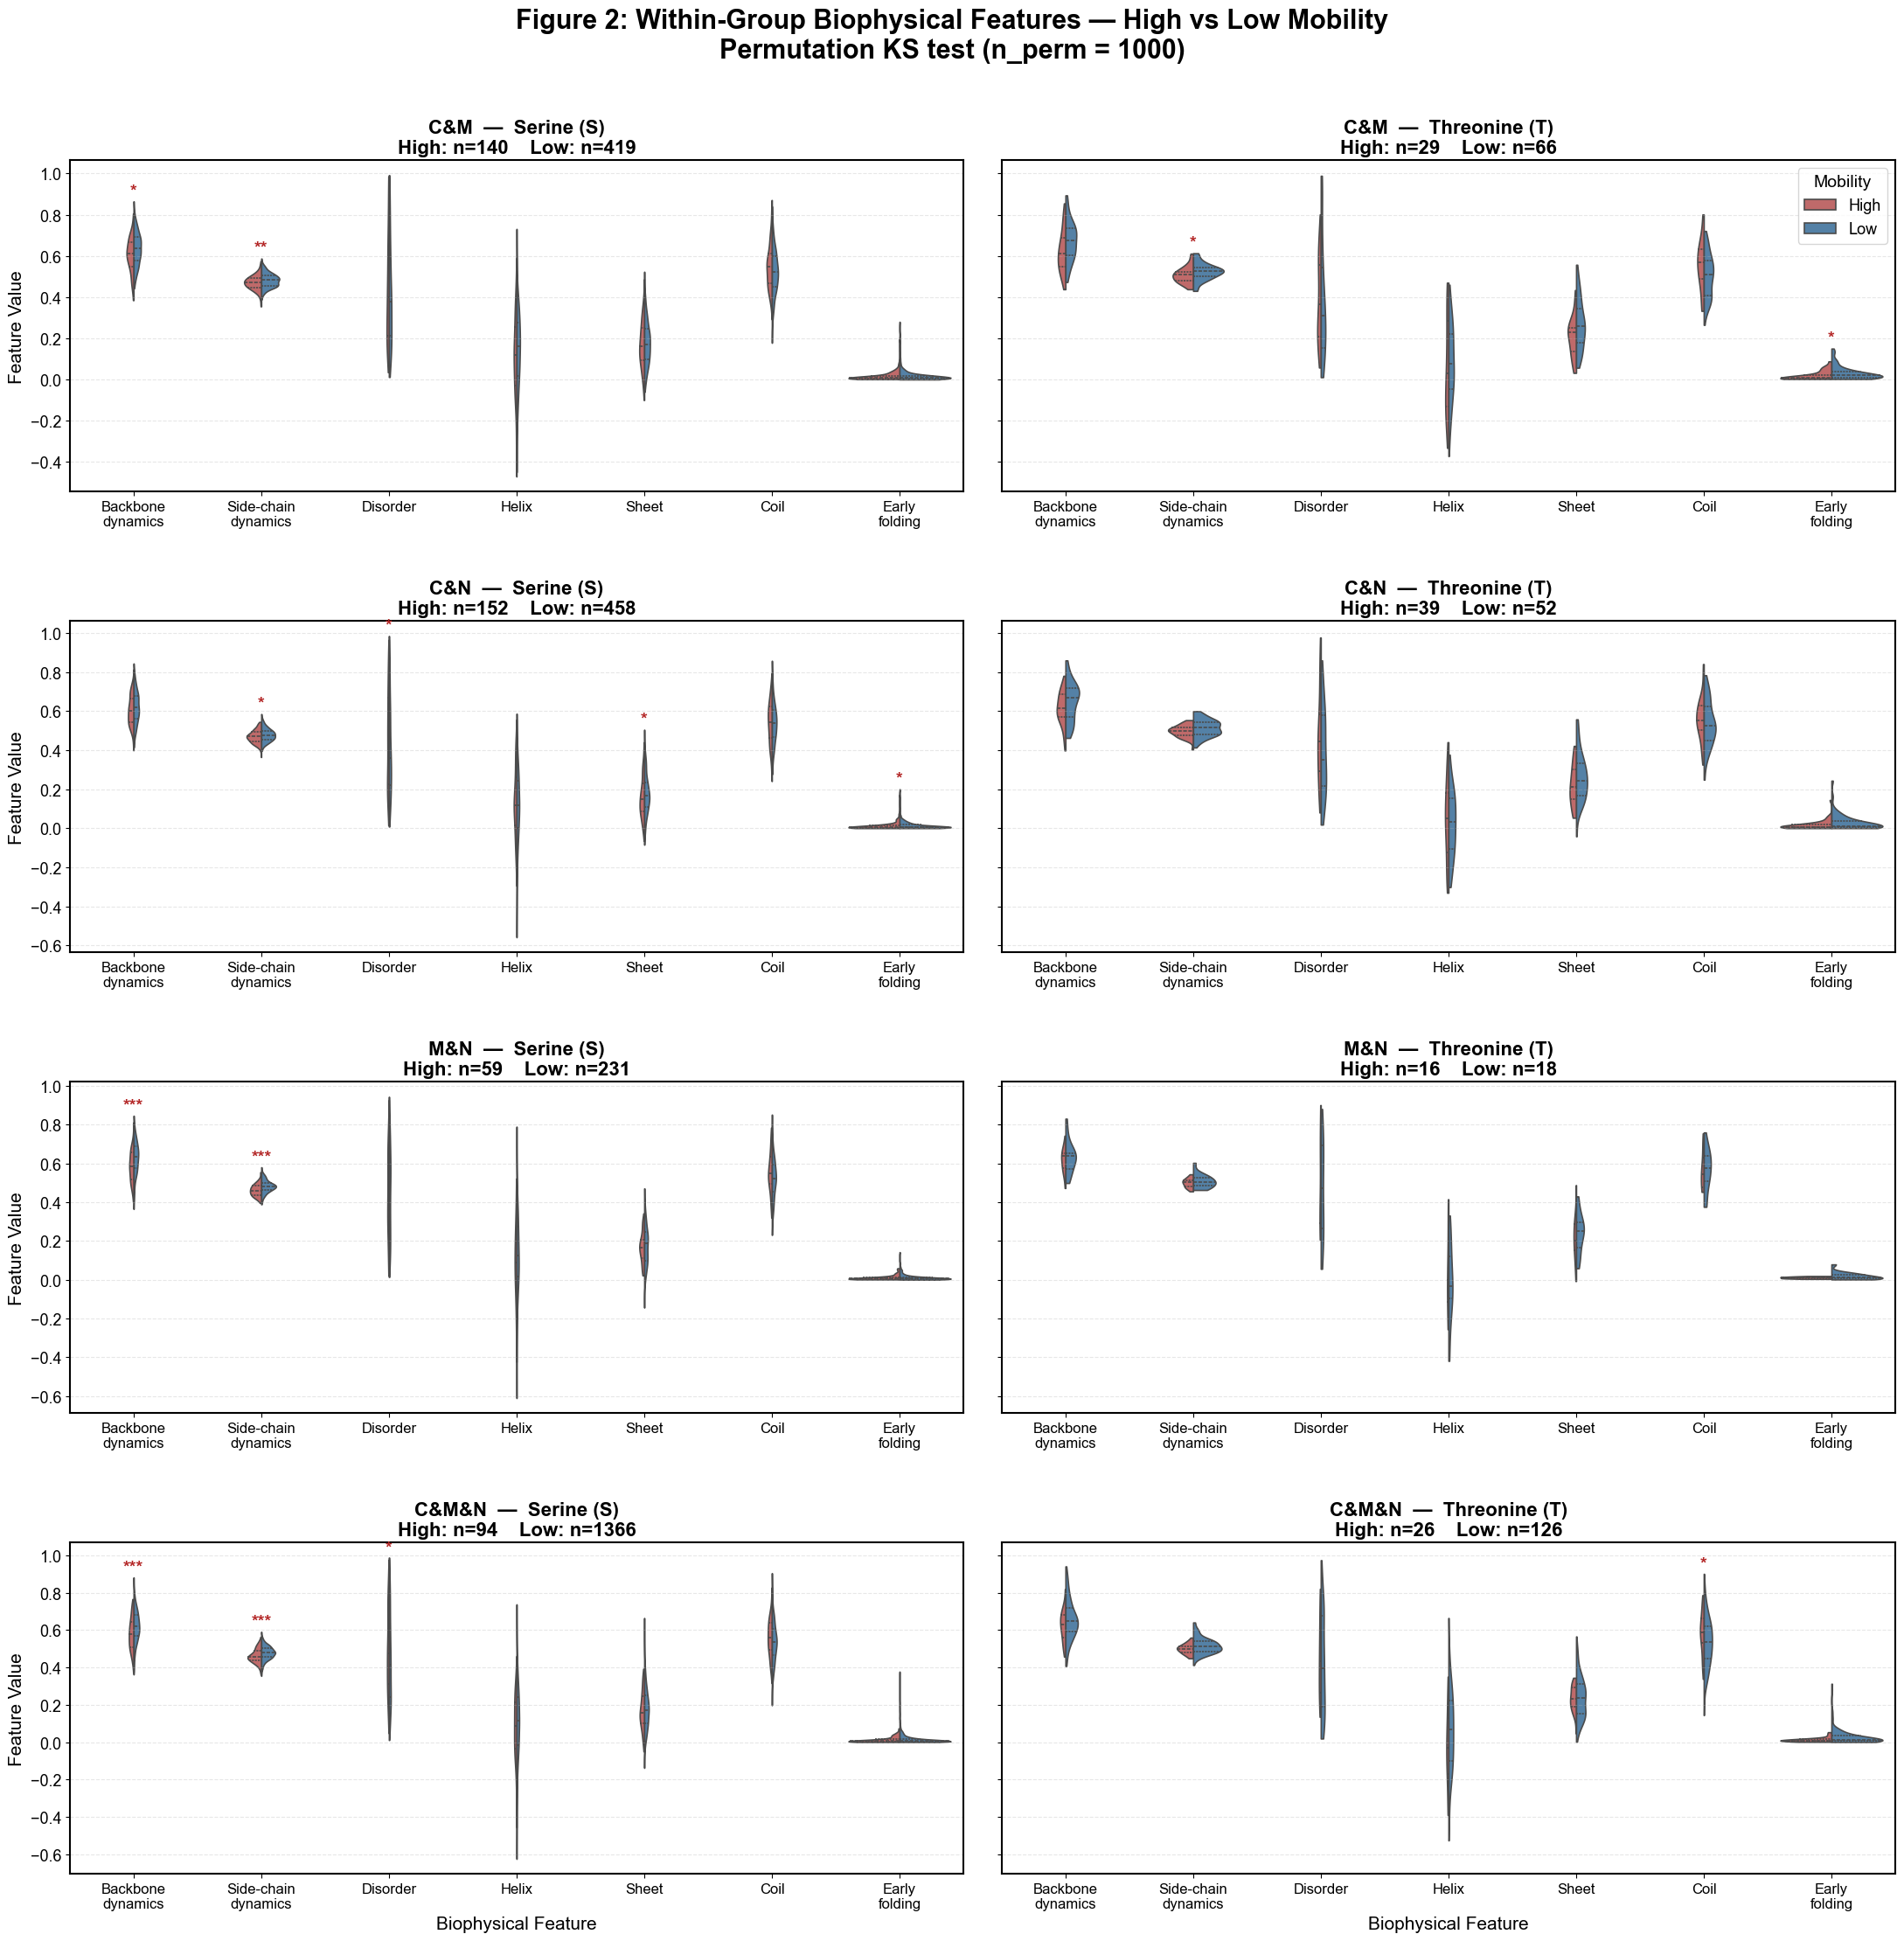

✅ Cell B 完成: 新 Figure 2


In [3]:
# Cell B: 新 Figure 2 — 组内 High vs Low Mobility（S / T 分别做）
# =============================================================================
# 导师要求：不比较 S vs T，而是同一 AA 内比较 High vs Low
# 布局：4行(group) × 2列(S | T)，保留小提琴 split 样式
# =============================================================================

aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'

# 准备 High 和 Low 数据（含 LocalizationGroup）
high_mob_all = success_df[success_df['movement_score'] >= MOBILITY_THRESHOLD].copy()
low_mob_all  = success_df[success_df['movement_score'] <  LOW_MOB_THRESHOLD].copy()

# ── 计算 ──
fig2_results = {}  # key: (group, feature, aa, 'High_vs_Low') → result

for grp in analysis_groups:
    for aa in ['S', 'T']:
        high_vals = high_mob_all[
            (high_mob_all['LocalizationGroup'] == grp) &
            (high_mob_all[aa_col] == aa)
        ]
        low_vals = low_mob_all[
            (low_mob_all['LocalizationGroup'] == grp) &
            (low_mob_all[aa_col] == aa)
        ]
        for i, feat in enumerate(biophysical_features):
            h_v = high_vals[feat].dropna().values
            l_v = low_vals[feat].dropna().values
            seed_i = SEED_BASE + hash((grp, aa, i)) % 10000
            result = permutation_ks_test(h_v, l_v, n_perm=N_PERM, seed=seed_i)
            fig2_results[(grp, feat, aa, 'High_vs_Low')] = result

print(f"✓ Fig2 计算完成: {len(fig2_results)} 组 "
      f"(4 groups × 2 AA × {len(biophysical_features)} features)")

# ── 汇总表 ──
print(f"\n{'Group':<8} {'AA':<4} {'Feature':<22} {'n_high':>7} {'n_low':>7} "
      f"{'KS':>7} {'emp_p':>7} {'Δmean':>8}")
print("-" * 80)
for grp in analysis_groups:
    for aa in ['S', 'T']:
        for feat in biophysical_features:
            r = fig2_results[(grp, feat, aa, 'High_vs_Low')]
            if r['status'] != 'ok':
                print(f"{grp:<8} {aa:<4} {feat:<22}  — insufficient data")
                continue
            print(f"{grp:<8} {aa:<4} {feat:<22} {r['n_a']:>7} {r['n_b']:>7} "
                  f"{r['real_ks']:>7.3f} {r['empirical_p']:>7.3f} {r['mean_diff']:>+8.4f}")

# ── 绘图: 4行 × 2列 小提琴 ──
n_rows = len(analysis_groups)
n_cols = 2  # S, T

fig2, axes2 = plt.subplots(n_rows, n_cols,
                            figsize=(22, 5.5 * n_rows),
                            sharey='row')

for row, grp in enumerate(analysis_groups):
    for col, aa in enumerate(['S', 'T']):
        ax = axes2[row, col]

        # 取数据
        h_df = high_mob_all[
            (high_mob_all['LocalizationGroup'] == grp) &
            (high_mob_all[aa_col] == aa)
        ]
        l_df = low_mob_all[
            (low_mob_all['LocalizationGroup'] == grp) &
            (low_mob_all[aa_col] == aa)
        ]

        # 长格式
        plot_rows = []
        for feat in biophysical_features:
            for v in h_df[feat].dropna():
                plot_rows.append({
                    'Feature': short_feat(feat),
                    'Mobility': 'High', 'Value': v
                })
            for v in l_df[feat].dropna():
                plot_rows.append({
                    'Feature': short_feat(feat),
                    'Mobility': 'Low', 'Value': v
                })
        plot_df = pd.DataFrame(plot_rows)

        if len(plot_df) == 0:
            ax.set_title(f'{grp} — {aa} — no data', fontsize=16)
            continue

        # 保持 feature 顺序
        feat_order = [short_feat(f) for f in biophysical_features]
        plot_df['Feature'] = pd.Categorical(
            plot_df['Feature'], categories=feat_order, ordered=True)

        # 小提琴图 split
        sns.violinplot(
            data=plot_df, x='Feature', y='Value', hue='Mobility',
            palette=COLORS_HL, split=True, inner='quartile',
            ax=ax, cut=0, linewidth=1.2
        )

        # 显著性标注
        for j, feat in enumerate(biophysical_features):
            r = fig2_results.get((grp, feat, aa, 'High_vs_Low'))
            if r and r['status'] == 'ok':
                stars = sig_stars(r['empirical_p'])
                if stars and stars != 'ns':
                    y_top = plot_df[
                        plot_df['Feature'] == short_feat(feat)
                    ]['Value'].max()
                    ax.text(j, y_top + 0.03, stars,
                            ha='center', fontsize=14,
                            fontweight='bold', color='#B22222')

        # 标注
        n_h = len(h_df)
        n_l = len(l_df)
        aa_name = 'Serine' if aa == 'S' else 'Threonine'
        ax.set_title(f'{grp}  —  {aa_name} ({aa})\n'
                     f'High: n={n_h}    Low: n={n_l}',
                     fontsize=16, fontweight='bold')

        # 轴
        if row == n_rows - 1:
            ax.set_xlabel('Biophysical Feature', fontsize=15)
        else:
            ax.set_xlabel('')
        if col == 0:
            ax.set_ylabel('Feature Value', fontsize=15)
        else:
            ax.set_ylabel('')

        # 图例只在第一个panel显示
        if row == 0 and col == 1:
            ax.legend(title='Mobility', fontsize=13,
                      title_fontsize=14, loc='upper right',
                      frameon=True, edgecolor='#CCC')
        else:
            leg = ax.get_legend()
            if leg: leg.remove()

        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.tick_params(axis='x', labelsize=12, rotation=0)
        ax.tick_params(axis='y', labelsize=13)

fig2.suptitle(
    'Figure 2: Within-Group Biophysical Features — High vs Low Mobility\n'
    f'Permutation KS test (n_perm = {N_PERM})',
    fontsize=22, fontweight='bold', y=1.01
)
plt.tight_layout(h_pad=3, w_pad=2)

# 保存 TIFF
save_tiff(fig2, 'Fig2_WithinGroup_HighLow_v2.tiff')
plt.show()

print("✅ Cell B 完成: 新 Figure 2")

✓ Fig3 计算完成: 84 组
  ✅ 已保存: Fig3_BetweenGroup_Heatmap_v6.tiff


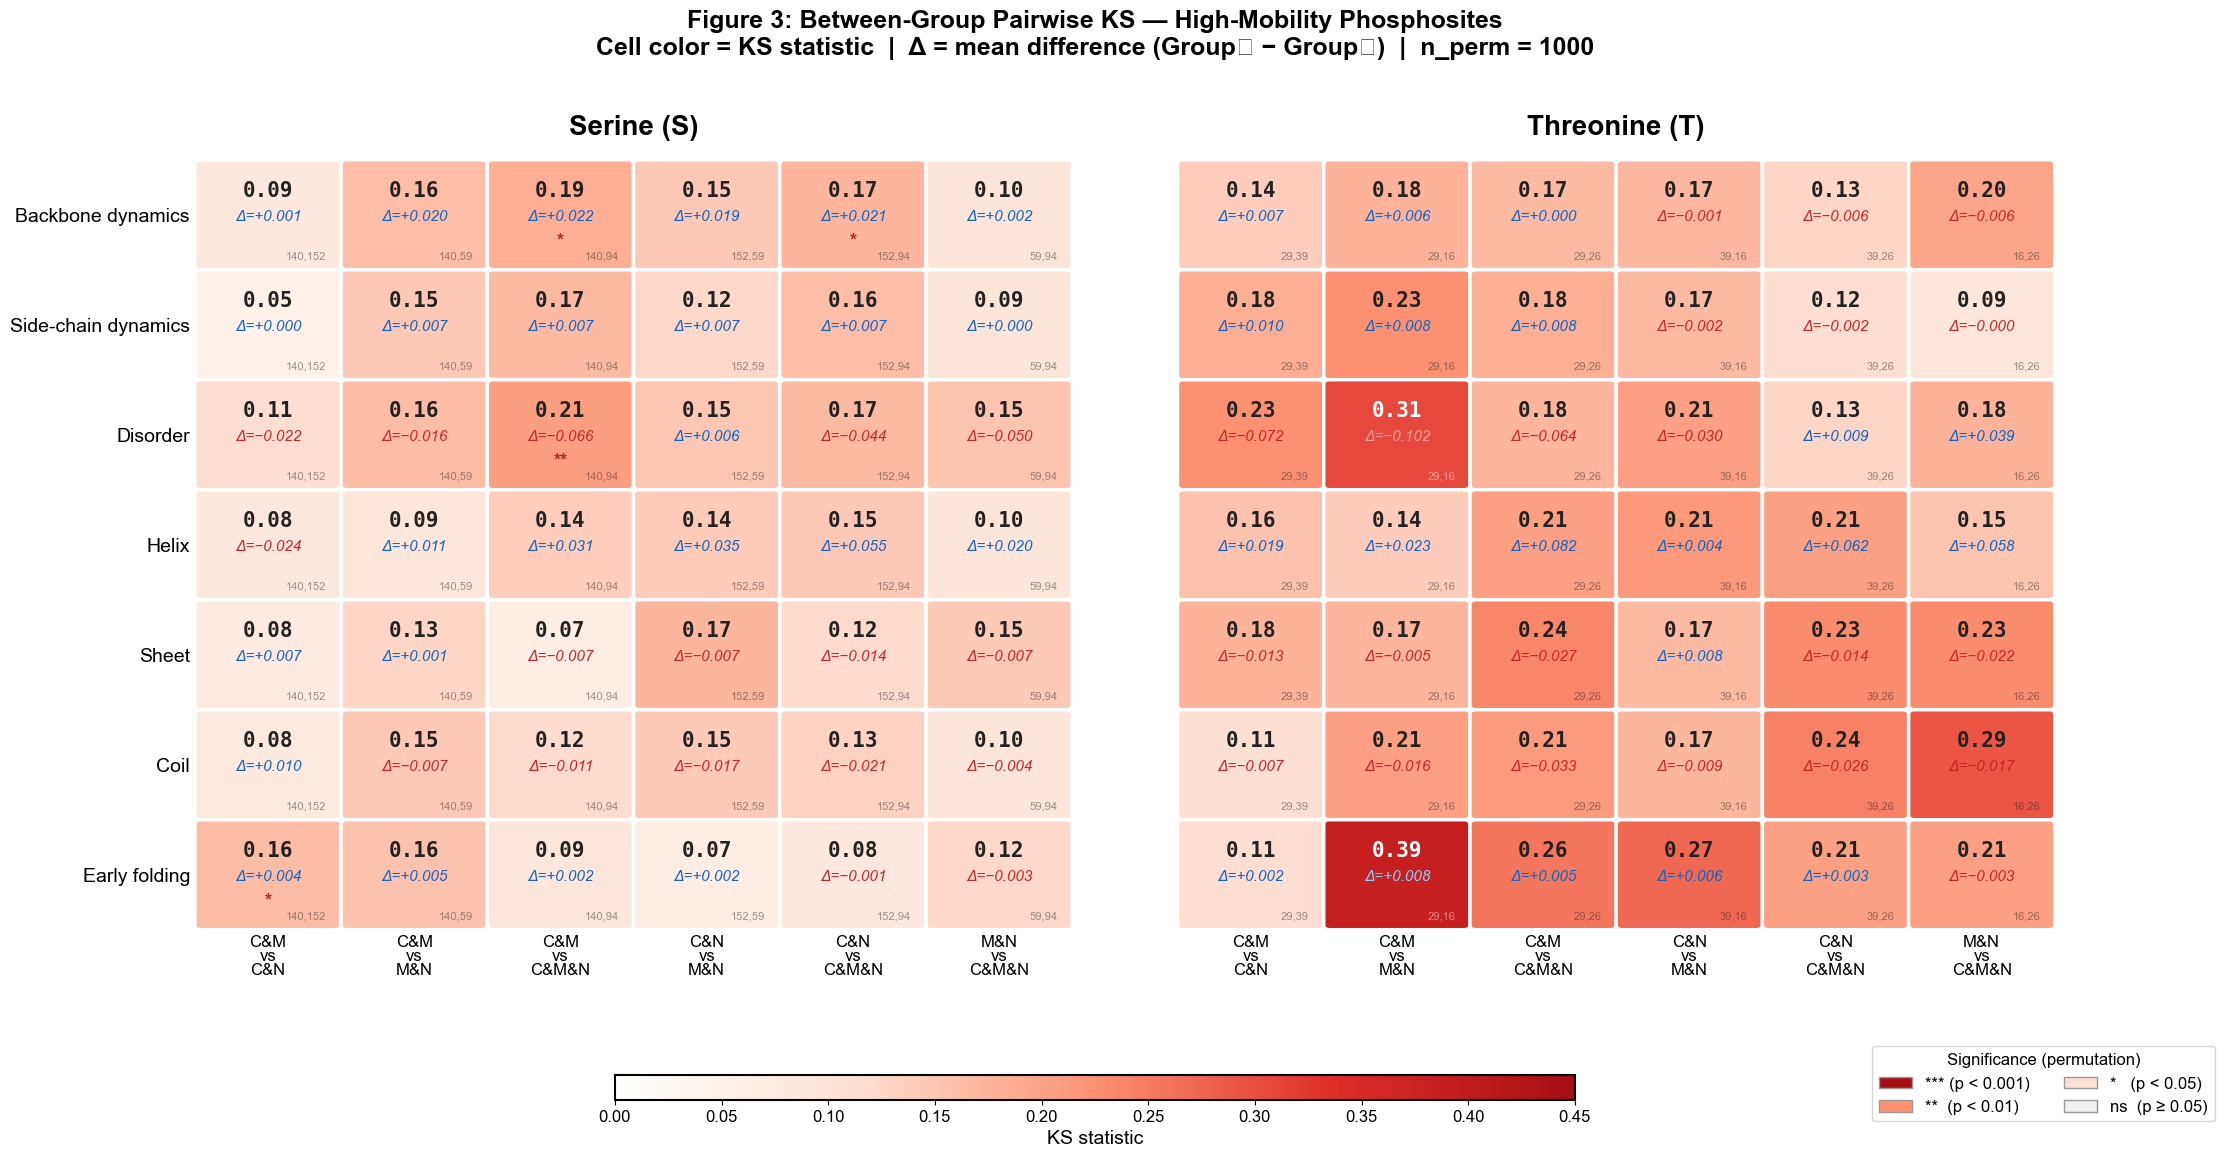

✅ Cell C 完成: 新 Figure 3 (含 Δmean)


In [4]:
# Cell C: 新 Figure 3 — 组间 Heatmap + Δmean 方向/大小
# =============================================================================
# 导师要求：
#   1. 重新计算 fig3_results（之前代码丢失）
#   2. 每格加 Δmean（正/负 + 大小）
#   3. 大字体，TIFF
# =============================================================================

aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'
mob_df_all = success_df[success_df['movement_score'] >= MOBILITY_THRESHOLD].copy()

group_pairs = list(combinations(analysis_groups, 2))

# ── 计算 fig3_results ──
fig3_results = {}

for aa in ['S', 'T']:
    for feat in biophysical_features:
        for g1, g2 in group_pairs:
            vals_a = mob_df_all[
                (mob_df_all['LocalizationGroup'] == g1) &
                (mob_df_all[aa_col] == aa)
            ][feat].dropna().values

            vals_b = mob_df_all[
                (mob_df_all['LocalizationGroup'] == g2) &
                (mob_df_all[aa_col] == aa)
            ][feat].dropna().values

            seed_i = SEED_BASE + hash((aa, feat, g1, g2)) % 10000
            result = permutation_ks_test(vals_a, vals_b,
                                         n_perm=N_PERM, seed=seed_i)
            fig3_results[(aa, feat, g1, g2)] = result

print(f"✓ Fig3 计算完成: {len(fig3_results)} 组")

# ── 绘图 ──
feat_short_list = [short_feat(f).replace('\n', ' ') for f in biophysical_features]
pair_labels = [f'{g1}\nvs\n{g2}' for g1, g2 in group_pairs]

# 色阶：白→橙→深红（KS值）
cmap = mcolors.LinearSegmentedColormap.from_list(
    'ks_red', ['#FFFFFF', '#FEE0D2', '#FC9272', '#DE2D26', '#A50F15'], N=256
)
norm = mcolors.Normalize(vmin=0, vmax=0.45)

fig3, axes3 = plt.subplots(1, 2, figsize=(24, 10),
                             gridspec_kw={'wspace': 0.12})
fig3.patch.set_facecolor('white')

for col_idx, aa in enumerate(['S', 'T']):
    ax = axes3[col_idx]
    ax.set_facecolor('white')

    n_r = len(biophysical_features)
    n_c = len(group_pairs)

    # 收集数据
    ks_vals   = np.full((n_r, n_c), np.nan)
    emp_ps    = np.full((n_r, n_c), np.nan)
    mean_diffs = np.full((n_r, n_c), np.nan)
    n_as      = np.full((n_r, n_c), 0, dtype=int)
    n_bs      = np.full((n_r, n_c), 0, dtype=int)

    for i, feat in enumerate(biophysical_features):
        for j, (g1, g2) in enumerate(group_pairs):
            r = fig3_results[(aa, feat, g1, g2)]
            if r['status'] != 'ok':
                continue
            ks_vals[i, j]    = r['real_ks']
            emp_ps[i, j]     = r['empirical_p']
            mean_diffs[i, j] = r['mean_diff']
            n_as[i, j]       = r['n_a']
            n_bs[i, j]       = r['n_b']

    # 画格子
    cell_h, cell_w = 1.0, 1.0
    for i in range(n_r):
        for j in range(n_c):
            ks = ks_vals[i, j]
            ep = emp_ps[i, j]
            md = mean_diffs[i, j]

            # 颜色
            if np.isnan(ks):
                face_color = '#F5F5F5'
            else:
                face_color = cmap(norm(ks))

            # 文字颜色适配深浅背景
            rgba = mcolors.to_rgba(face_color)
            brightness = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            text_color = '#FFFFFF' if brightness < 0.50 else '#222222'
            star_color = '#FFFFFF' if brightness < 0.50 else '#B22222'

            # 圆角方块
            rect = matplotlib.patches.FancyBboxPatch(
                (j + 0.04, i + 0.04), 0.92, 0.92,
                boxstyle="round,pad=0.04",
                facecolor=face_color, edgecolor='white', linewidth=2.5
            )
            ax.add_patch(rect)

            if np.isnan(ks):
                ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                        fontsize=13, color='#AAAAAA')
                continue

            # === KS 值（上方，大号） ===
            ax.text(j + 0.5, i + 0.28, f'{ks:.2f}',
                    ha='center', va='center',
                    fontsize=15, fontweight='bold', color=text_color,
                    family='monospace')

            # === Δmean（中间，带符号） ===
            if not np.isnan(md):
                sign_char = '+' if md >= 0 else '−'
                # 用颜色区分方向: 正=蓝偏, 负=红偏
                delta_color = '#1565C0' if md >= 0 else '#C62828'
                if brightness < 0.50:
                    delta_color = '#90CAF9' if md >= 0 else '#EF9A9A'
                ax.text(j + 0.5, i + 0.52,
                        f'Δ={sign_char}{abs(md):.3f}',
                        ha='center', va='center',
                        fontsize=11, color=delta_color,
                        fontstyle='italic')

            # === 显著性星号（下方） ===
            stars = sig_stars(ep)
            if stars and stars != 'ns':
                ax.text(j + 0.5, i + 0.74, stars,
                        ha='center', va='center',
                        fontsize=13, fontweight='bold', color=star_color)

            # === 样本量（右下角小字） ===
            ax.text(j + 0.90, i + 0.92,
                    f'{n_as[i,j]},{n_bs[i,j]}',
                    ha='right', va='bottom',
                    fontsize=8, color=text_color, alpha=0.45)

    # 轴设置
    ax.set_xlim(0, n_c)
    ax.set_ylim(0, n_r)
    ax.invert_yaxis()

    ax.set_xticks([j + 0.5 for j in range(n_c)])
    ax.set_xticklabels(pair_labels, fontsize=12, ha='center',
                        linespacing=0.9)

    if col_idx == 0:
        ax.set_yticks([i + 0.5 for i in range(n_r)])
        ax.set_yticklabels(feat_short_list, fontsize=14)
    else:
        ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    aa_name = 'Serine' if aa == 'S' else 'Threonine'
    ax.set_title(f'{aa_name} ({aa})', fontsize=20, fontweight='bold', pad=18)

# ── Colorbar ──
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig3.add_axes([0.30, -0.06, 0.4, 0.025])
cbar = fig3.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('KS statistic', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# ── 图例 ──
legend_handles = [
    mpatches.Patch(facecolor='#A50F15', edgecolor='#999', label='*** (p < 0.001)'),
    mpatches.Patch(facecolor='#FC9272', edgecolor='#999', label='**  (p < 0.01)'),
    mpatches.Patch(facecolor='#FEE0D2', edgecolor='#999', label='*   (p < 0.05)'),
    mpatches.Patch(facecolor='#F0F0F0', edgecolor='#999', label='ns  (p ≥ 0.05)'),
]
fig3.legend(handles=legend_handles, loc='lower right', ncol=2,
            fontsize=12, frameon=True, edgecolor='#CCC',
            bbox_to_anchor=(0.97, -0.09),
            title='Significance (permutation)', title_fontsize=12)

fig3.suptitle(
    'Figure 3: Between-Group Pairwise KS — High-Mobility Phosphosites\n'
    f'Cell color = KS statistic  |  Δ = mean difference (Group₁ − Group₂)  |  n_perm = {N_PERM}',
    fontsize=18, fontweight='bold', y=1.03
)

save_tiff(fig3, 'Fig3_BetweenGroup_Heatmap_v6.tiff')
plt.show()

print("✅ Cell C 完成: 新 Figure 3 (含 Δmean)")

🔬 Cell D: 构建非磷酸化对照组 (修复版)

[1/6] 重建 gene → uniprot 映射...
  ✓ 映射完成: 20,209 个基因

[2/6] 收集 high-mobility 磷酸化 S/T 位点...
  ✓ High-mobility S/T 磷酸化位点: 553
    S: 444
    T: 109
    涉及基因: 389

[3/6] 从 JSON 提取非磷酸化 S/T + biophysical features...

  ✓ 基因加载成功: 389, 跳过: 0
  ✓ 磷酸化位点 (含 features): 553
  ✓ 非磷酸化 S/T 候选:        61,405

[4/6] Context 匹配 (±2 AA window)...
  S: phospho 有 match = 439, 无 match = 5, control matched = 1211 (ratio ~2.8:1)
  T: phospho 有 match = 105, 无 match = 4, control matched = 280 (ratio ~2.7:1)

[5/6] KS 检验: Phospho vs Non-phospho (context-matched)...

  === Serine (S) ===
  Feature                     n_p   n_c      KS          p    Δmean   sig
  ----------------------------------------------------------------------
  backbone_dynamics           439  1211   0.136   1.13e-05  -0.0311   ***
  sidechain_dynamics          439  1211   0.103   2.02e-03  -0.0074    **
  disorder_propensity         439  1211   0.137   1.02e-05  +0.0555   ***
  helix_propensity            439  1211

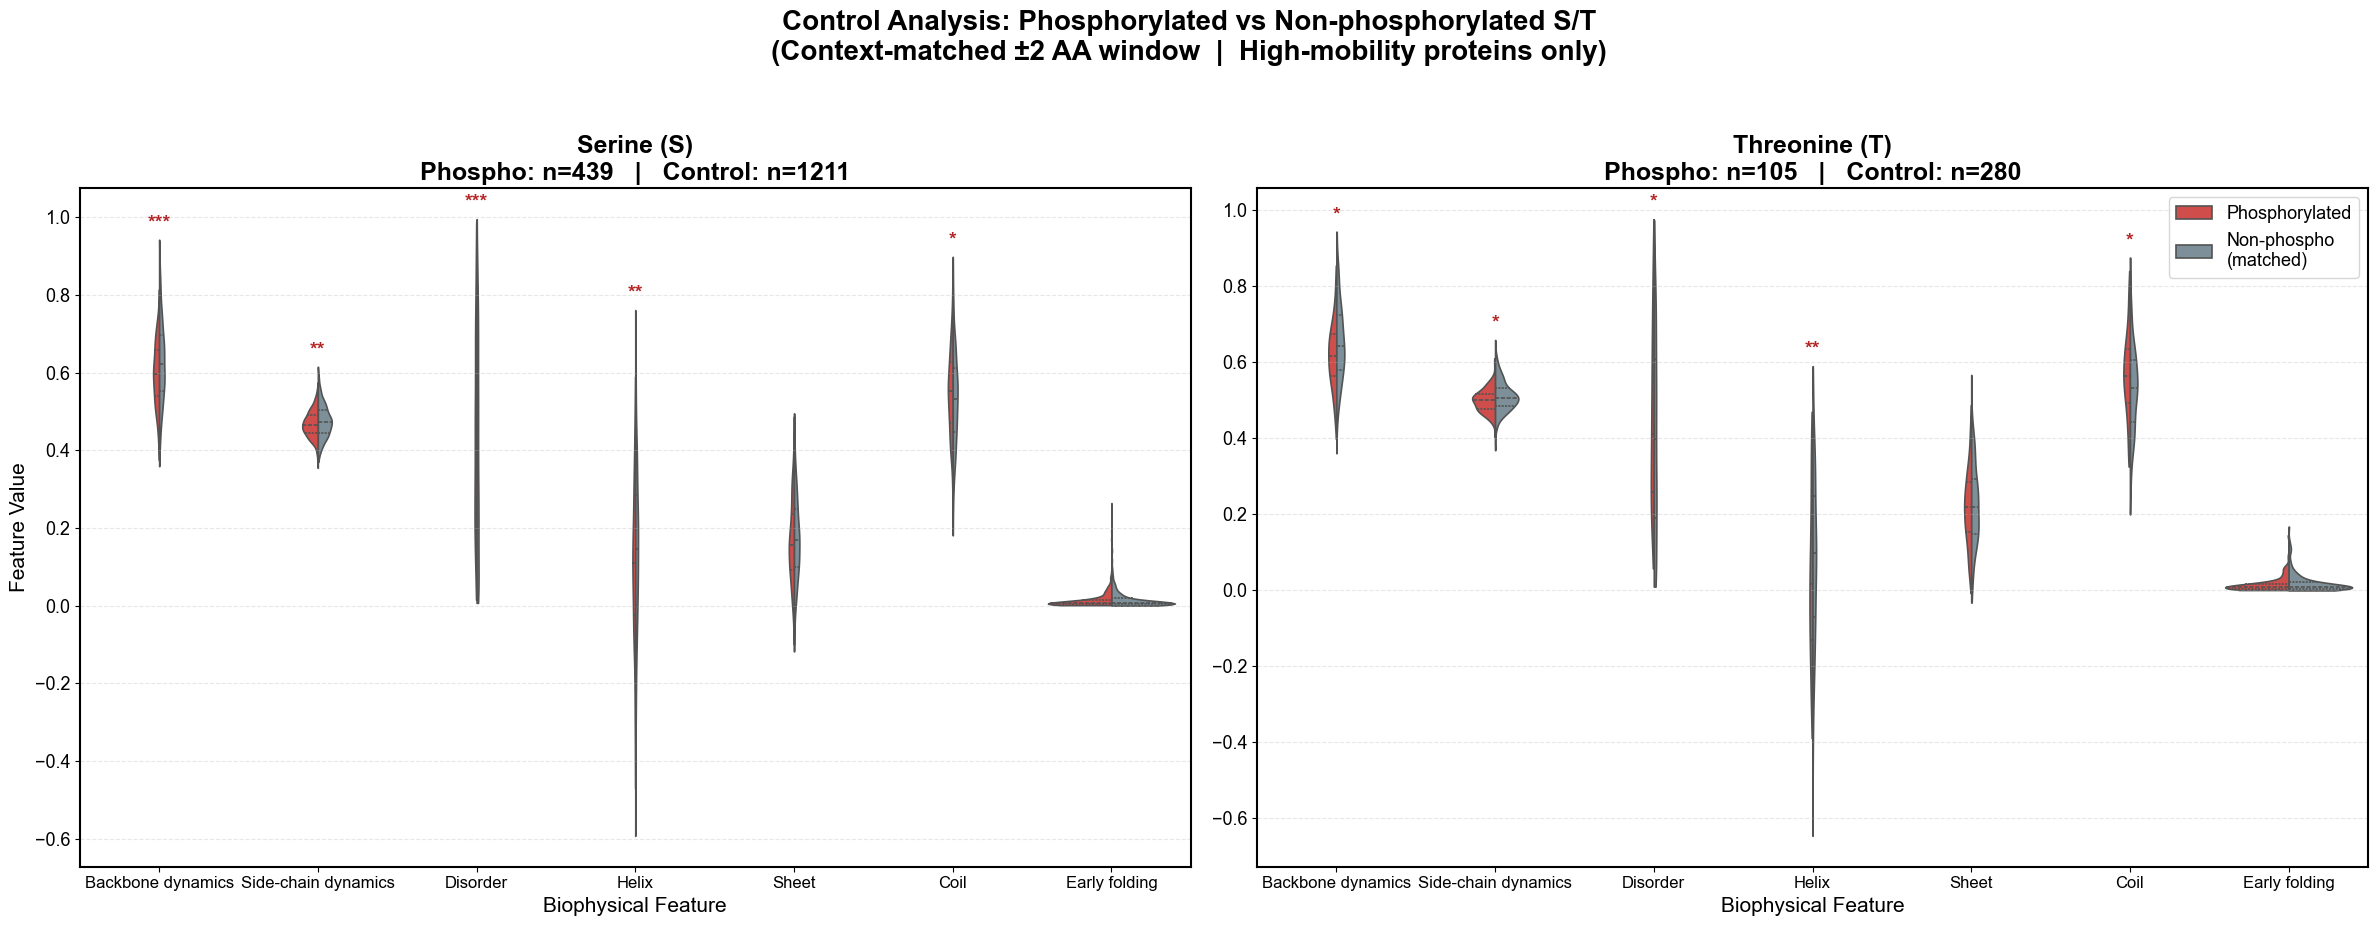


✅ Cell D 完成!
  磷酸化 S matched: 439
  对照 S matched:   1211
  磷酸化 T matched: 105
  对照 T matched:   280


In [5]:
# Cell D (修复版): 非磷酸化对照组 — Control Group Analysis
# =============================================================================
# 前置: 已运行 Cell 0 (success_df 已加载) + Cell A (函数已定义)
#
# 逻辑:
#   1. 重建 gene_to_uniprot 映射
#   2. 收集 high-mobility 磷酸化 S/T 的 Gene+Position
#   3. 从同蛋白中找 不被磷酸化的 S/T 残基
#   4. ±2 AA context 匹配
#   5. 提取 biophysical features 并比较
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, json, re
import warnings
warnings.filterwarnings('ignore')

# ── 路径 ──
JSON_FOLDER = r"D:\博士\Phospho\biophys_json"
aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'

print("=" * 60)
print("🔬 Cell D: 构建非磷酸化对照组 (修复版)")
print("=" * 60)

# ==========================================================
# Step 1: 重建 gene_to_uniprot 映射
# ==========================================================
print("\n[1/6] 重建 gene → uniprot 映射...")

json_files = [f for f in os.listdir(JSON_FOLDER) if f.endswith('.json')]
gene_to_uniprot = {}

for jf in json_files:
    uid = jf.replace('.json', '')
    try:
        with open(os.path.join(JSON_FOLDER, jf), 'r', encoding='utf-8') as f:
            d = json.load(f)
        header = d.get('uniprot_header', '')
        m = re.search(r'GN=([^\s]+)', header)
        if m:
            gene_to_uniprot[m.group(1)] = uid
    except:
        continue

print(f"  ✓ 映射完成: {len(gene_to_uniprot):,} 个基因")

# ==========================================================
# Step 2: 收集 high-mobility 磷酸化位点
# ==========================================================
print("\n[2/6] 收集 high-mobility 磷酸化 S/T 位点...")

high_phospho = success_df[
    (success_df['movement_score'] >= MOBILITY_THRESHOLD) &
    (success_df[aa_col].isin(['S', 'T']))
].copy()

# 去重: 同一 Gene+Position 只保留一条
high_phospho_unique = high_phospho.drop_duplicates(
    subset=['Gene', 'Position']
).copy()

print(f"  ✓ High-mobility S/T 磷酸化位点: {len(high_phospho_unique):,}")
print(f"    S: {(high_phospho_unique[aa_col] == 'S').sum()}")
print(f"    T: {(high_phospho_unique[aa_col] == 'T').sum()}")
print(f"    涉及基因: {high_phospho_unique['Gene'].nunique()}")

# ==========================================================
# Step 3: 加载蛋白质数据，找非磷酸化 S/T
# ==========================================================
print("\n[3/6] 从 JSON 提取非磷酸化 S/T + biophysical features...")

# JSON 内 residue key → 我们的标准列名
JSON_KEY_MAP = {
    'backbone':      'backbone_dynamics',
    'sidechain':     'sidechain_dynamics',
    'disoMine':      'disorder_propensity',
    'helix':         'helix_propensity',
    'sheet':         'sheet_propensity',
    'coil':          'coil_propensity',
    'earlyFolding':  'earlyFolding',
}
FEAT_COLS = list(JSON_KEY_MAP.values())


def load_protein(gene, gene_map, json_folder):
    """加载蛋白 JSON, 返回 (data, uniprot_id) 或 (None, None)"""
    if gene not in gene_map:
        return None, None
    uid = gene_map[gene]
    path = os.path.join(json_folder, f"{uid}.json")
    if not os.path.exists(path):
        return None, None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f), uid


def get_residue_features(data, pos_1indexed):
    """从 JSON data 提取指定位点 (1-indexed) 的 7 个 features"""
    residues = data.get('residues', [])
    idx = int(pos_1indexed) - 1
    if idx < 0 or idx >= len(residues):
        return None
    rd = residues[idx]
    feats = {}
    for json_key, col_name in JSON_KEY_MAP.items():
        feats[col_name] = rd.get(json_key, np.nan)
    feats['aa_check'] = rd.get('aa', '?')
    return feats


def get_context_signature(residues_list, pos_0indexed, window=2):
    """
    获取 ±window 残基的氨基酸组成（sorted）
    用于匹配 sequence context
    """
    start = max(0, pos_0indexed - window)
    end   = min(len(residues_list), pos_0indexed + window + 1)
    context_aas = [residues_list[k].get('aa', '?') for k in range(start, end)]
    return ''.join(sorted(context_aas))


# ── 收集磷酸化位点的 features + context ──
phospho_rows = []
# ── 收集非磷酸化候选 S/T ──
control_candidates = []

# 按基因分组处理（每个蛋白只加载一次 JSON）
genes_in_phospho = high_phospho_unique['Gene'].unique()
n_genes = len(genes_in_phospho)
skip_gene = 0
success_gene = 0

for gi, gene in enumerate(genes_in_phospho):
    if (gi + 1) % 500 == 0:
        print(f"    进度: {gi+1}/{n_genes} ({(gi+1)/n_genes*100:.0f}%)")

    data, uid = load_protein(gene, gene_to_uniprot, JSON_FOLDER)
    if data is None:
        skip_gene += 1
        continue
    success_gene += 1

    residues = data.get('residues', [])
    if len(residues) == 0:
        continue

    # 该基因的磷酸化位点 (1-indexed)
    gene_phospho = high_phospho_unique[
        high_phospho_unique['Gene'] == gene
    ]
    phospho_positions = set(gene_phospho['Position'].values)  # 1-indexed

    # --- 磷酸化位点: 提取 features + context ---
    for _, row in gene_phospho.iterrows():
        pos = row['Position']  # 1-indexed
        feats = get_residue_features(data, pos)
        if feats is None:
            continue
        ctx = get_context_signature(residues, int(pos) - 1, window=2)
        feats['Gene']     = gene
        feats['Position'] = pos
        feats['AA']       = row[aa_col]
        feats['context']  = ctx
        feats['group']    = 'Phospho'
        phospho_rows.append(feats)

    # --- 非磷酸化 S/T: 遍历全蛋白 ---
    for idx_r, rd in enumerate(residues):
        aa_res = rd.get('aa', '?')
        if aa_res not in ('S', 'T'):
            continue
        pos_1 = idx_r + 1  # 转1-indexed
        if pos_1 in phospho_positions:
            continue  # 跳过磷酸化位点

        ctx = get_context_signature(residues, idx_r, window=2)
        feats = {}
        for json_key, col_name in JSON_KEY_MAP.items():
            feats[col_name] = rd.get(json_key, np.nan)
        feats['Gene']     = gene
        feats['Position'] = pos_1
        feats['AA']       = aa_res
        feats['context']  = ctx
        feats['group']    = 'Non-phospho'
        control_candidates.append(feats)

phospho_df  = pd.DataFrame(phospho_rows)
control_df  = pd.DataFrame(control_candidates)

print(f"\n  ✓ 基因加载成功: {success_gene}, 跳过: {skip_gene}")
print(f"  ✓ 磷酸化位点 (含 features): {len(phospho_df):,}")
print(f"  ✓ 非磷酸化 S/T 候选:        {len(control_df):,}")

# ==========================================================
# Step 4: ±2 AA Context 匹配
# ==========================================================
print("\n[4/6] Context 匹配 (±2 AA window)...")

def match_control(phospho_df, control_df, aa, max_ratio=3, seed=2026):
    """
    对每个磷酸化位点，从非磷酸化候选中按 context 匹配
    max_ratio: 每个磷酸化位点最多匹配几个对照
    """
    rng = np.random.RandomState(seed)
    p = phospho_df[phospho_df['AA'] == aa].copy()
    c = control_df[control_df['AA'] == aa].copy()

    # 按 context 分组建索引（加速查找）
    c_grouped = c.groupby('context')
    c_index = {ctx: idxs for ctx, idxs in c_grouped.groups.items()}

    matched_idx = []
    matched_count = 0
    unmatched_count = 0

    for _, prow in p.iterrows():
        ctx = prow['context']
        if ctx not in c_index or len(c_index[ctx]) == 0:
            unmatched_count += 1
            continue
        candidates = c_index[ctx]
        n_pick = min(max_ratio, len(candidates))
        picked = rng.choice(candidates, size=n_pick, replace=False)
        matched_idx.extend(picked.tolist())
        matched_count += 1

    matched_ctrl = c.loc[list(set(matched_idx))].copy()
    p_with_match = p[p['context'].isin(matched_ctrl['context'].unique())].copy()

    print(f"  {aa}: phospho 有 match = {matched_count}, "
          f"无 match = {unmatched_count}, "
          f"control matched = {len(matched_ctrl)} "
          f"(ratio ~{len(matched_ctrl)/max(matched_count,1):.1f}:1)")
    return p_with_match, matched_ctrl


matched = {}
for aa in ['S', 'T']:
    p_m, c_m = match_control(phospho_df, control_df, aa,
                              max_ratio=3, seed=SEED_BASE)
    matched[aa] = (p_m, c_m)

# ==========================================================
# Step 5: 统计检验
# ==========================================================
print("\n[5/6] KS 检验: Phospho vs Non-phospho (context-matched)...")

ctrl_stats = []
for aa in ['S', 'T']:
    p_df, c_df = matched[aa]
    aa_name = 'Serine' if aa == 'S' else 'Threonine'
    print(f"\n  === {aa_name} ({aa}) ===")
    print(f"  {'Feature':<25} {'n_p':>5} {'n_c':>5} "
          f"{'KS':>7} {'p':>10} {'Δmean':>8} {'sig':>5}")
    print(f"  {'-'*70}")

    for fc in FEAT_COLS:
        pv = p_df[fc].dropna().values
        cv = c_df[fc].dropna().values
        if len(pv) < 5 or len(cv) < 5:
            print(f"  {fc:<25}  — insufficient data")
            continue
        ks_stat, p_val = stats.ks_2samp(pv, cv)
        delta = np.mean(pv) - np.mean(cv)
        stars = sig_stars(p_val)
        print(f"  {fc:<25} {len(pv):>5} {len(cv):>5} "
              f"{ks_stat:>7.3f} {p_val:>10.2e} {delta:>+8.4f} {stars:>5}")
        ctrl_stats.append({
            'AA': aa, 'Feature': fc, 'n_phospho': len(pv),
            'n_control': len(cv), 'KS': ks_stat, 'p_value': p_val,
            'mean_diff': delta, 'significance': stars
        })

ctrl_stats_df = pd.DataFrame(ctrl_stats)
ctrl_stats_df.to_csv('Control_KS_results.csv', index=False)
print(f"\n  ✓ 统计结果已保存: Control_KS_results.csv")

# ==========================================================
# Step 6: 绘图 — Phospho vs Non-phospho 小提琴
# ==========================================================
print("\n[6/6] 绘图...")

feat_names = [short_feat(f).replace('\n', ' ') for f in FEAT_COLS]

fig_ctrl, axes_ctrl = plt.subplots(1, 2, figsize=(24, 9))

for col, aa in enumerate(['S', 'T']):
    ax = axes_ctrl[col]
    p_df, c_df = matched[aa]

    # 长格式
    rows = []
    for fk, fn in zip(FEAT_COLS, feat_names):
        for v in p_df[fk].dropna():
            rows.append({'Feature': fn, 'Group': 'Phosphorylated', 'Value': v})
        for v in c_df[fk].dropna():
            rows.append({'Feature': fn, 'Group': 'Non-phospho\n(matched)', 'Value': v})

    plot_df = pd.DataFrame(rows)
    plot_df['Feature'] = pd.Categorical(
        plot_df['Feature'], categories=feat_names, ordered=True)

    sns.violinplot(
        data=plot_df, x='Feature', y='Value', hue='Group',
        palette={'Phosphorylated': '#E53935',
                 'Non-phospho\n(matched)': '#78909C'},
        split=True, inner='quartile', ax=ax, cut=0, linewidth=1.2
    )

    # 显著性标注
    for j, fk in enumerate(FEAT_COLS):
        row_stat = ctrl_stats_df[
            (ctrl_stats_df['AA'] == aa) & (ctrl_stats_df['Feature'] == fk)
        ]
        if len(row_stat) == 0:
            continue
        stars = row_stat.iloc[0]['significance']
        if stars and stars != 'ns':
            y_top = plot_df[plot_df['Feature'] == feat_names[j]]['Value'].max()
            ax.text(j, y_top + 0.03, stars,
                    ha='center', fontsize=14,
                    fontweight='bold', color='#B22222')

    aa_name = 'Serine' if aa == 'S' else 'Threonine'
    ax.set_title(
        f'{aa_name} ({aa})\n'
        f'Phospho: n={len(p_df)}   |   Control: n={len(c_df)}',
        fontsize=18, fontweight='bold'
    )
    ax.set_xlabel('Biophysical Feature', fontsize=15)
    ax.set_ylabel('Feature Value' if col == 0 else '', fontsize=15)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    if col == 1:
        ax.legend(fontsize=13, title_fontsize=14, loc='upper right',
                  frameon=True, edgecolor='#CCC')
    else:
        leg = ax.get_legend()
        if leg: leg.remove()

fig_ctrl.suptitle(
    'Control Analysis: Phosphorylated vs Non-phosphorylated S/T\n'
    '(Context-matched ±2 AA window  |  High-mobility proteins only)',
    fontsize=20, fontweight='bold', y=1.03
)
plt.tight_layout()
save_tiff(fig_ctrl, 'Fig_Control_Phospho_vs_NonPhospho.tiff')
plt.show()

print("\n" + "=" * 60)
print("✅ Cell D 完成!")
print("=" * 60)
print(f"  磷酸化 S matched: {len(matched['S'][0])}")
print(f"  对照 S matched:   {len(matched['S'][1])}")
print(f"  磷酸化 T matched: {len(matched['T'][0])}")
print(f"  对照 T matched:   {len(matched['T'][1])}")


🔬 Cell D-patch: Permutation KS (n=1000) 对照组分析

[5/6] Permutation KS 检验 (n_perm=1000)...

  === Serine (S) ===
  Feature                     n_p   n_c      KS   emp_p    Δmean   sig
  ----------------------------------------------------------------------
  backbone_dynamics           439  1211   0.136   0.000  -0.0311   ***
  sidechain_dynamics          439  1211   0.103   0.001  -0.0074    **
  disorder_propensity         439  1211   0.137   0.000  +0.0555   ***
  helix_propensity            439  1211   0.097   0.004  -0.0318    **
  sheet_propensity            439  1211   0.067   0.103  -0.0098    ns
  coil_propensity             439  1211   0.077   0.035  +0.0197     *
  earlyFolding                439  1211   0.051   0.233  -0.0028    ns

  === Threonine (T) ===
  Feature                     n_p   n_c      KS   emp_p    Δmean   sig
  ----------------------------------------------------------------------
  backbone_dynamics           105   280   0.175   0.011  -0.0351     *
  sidech

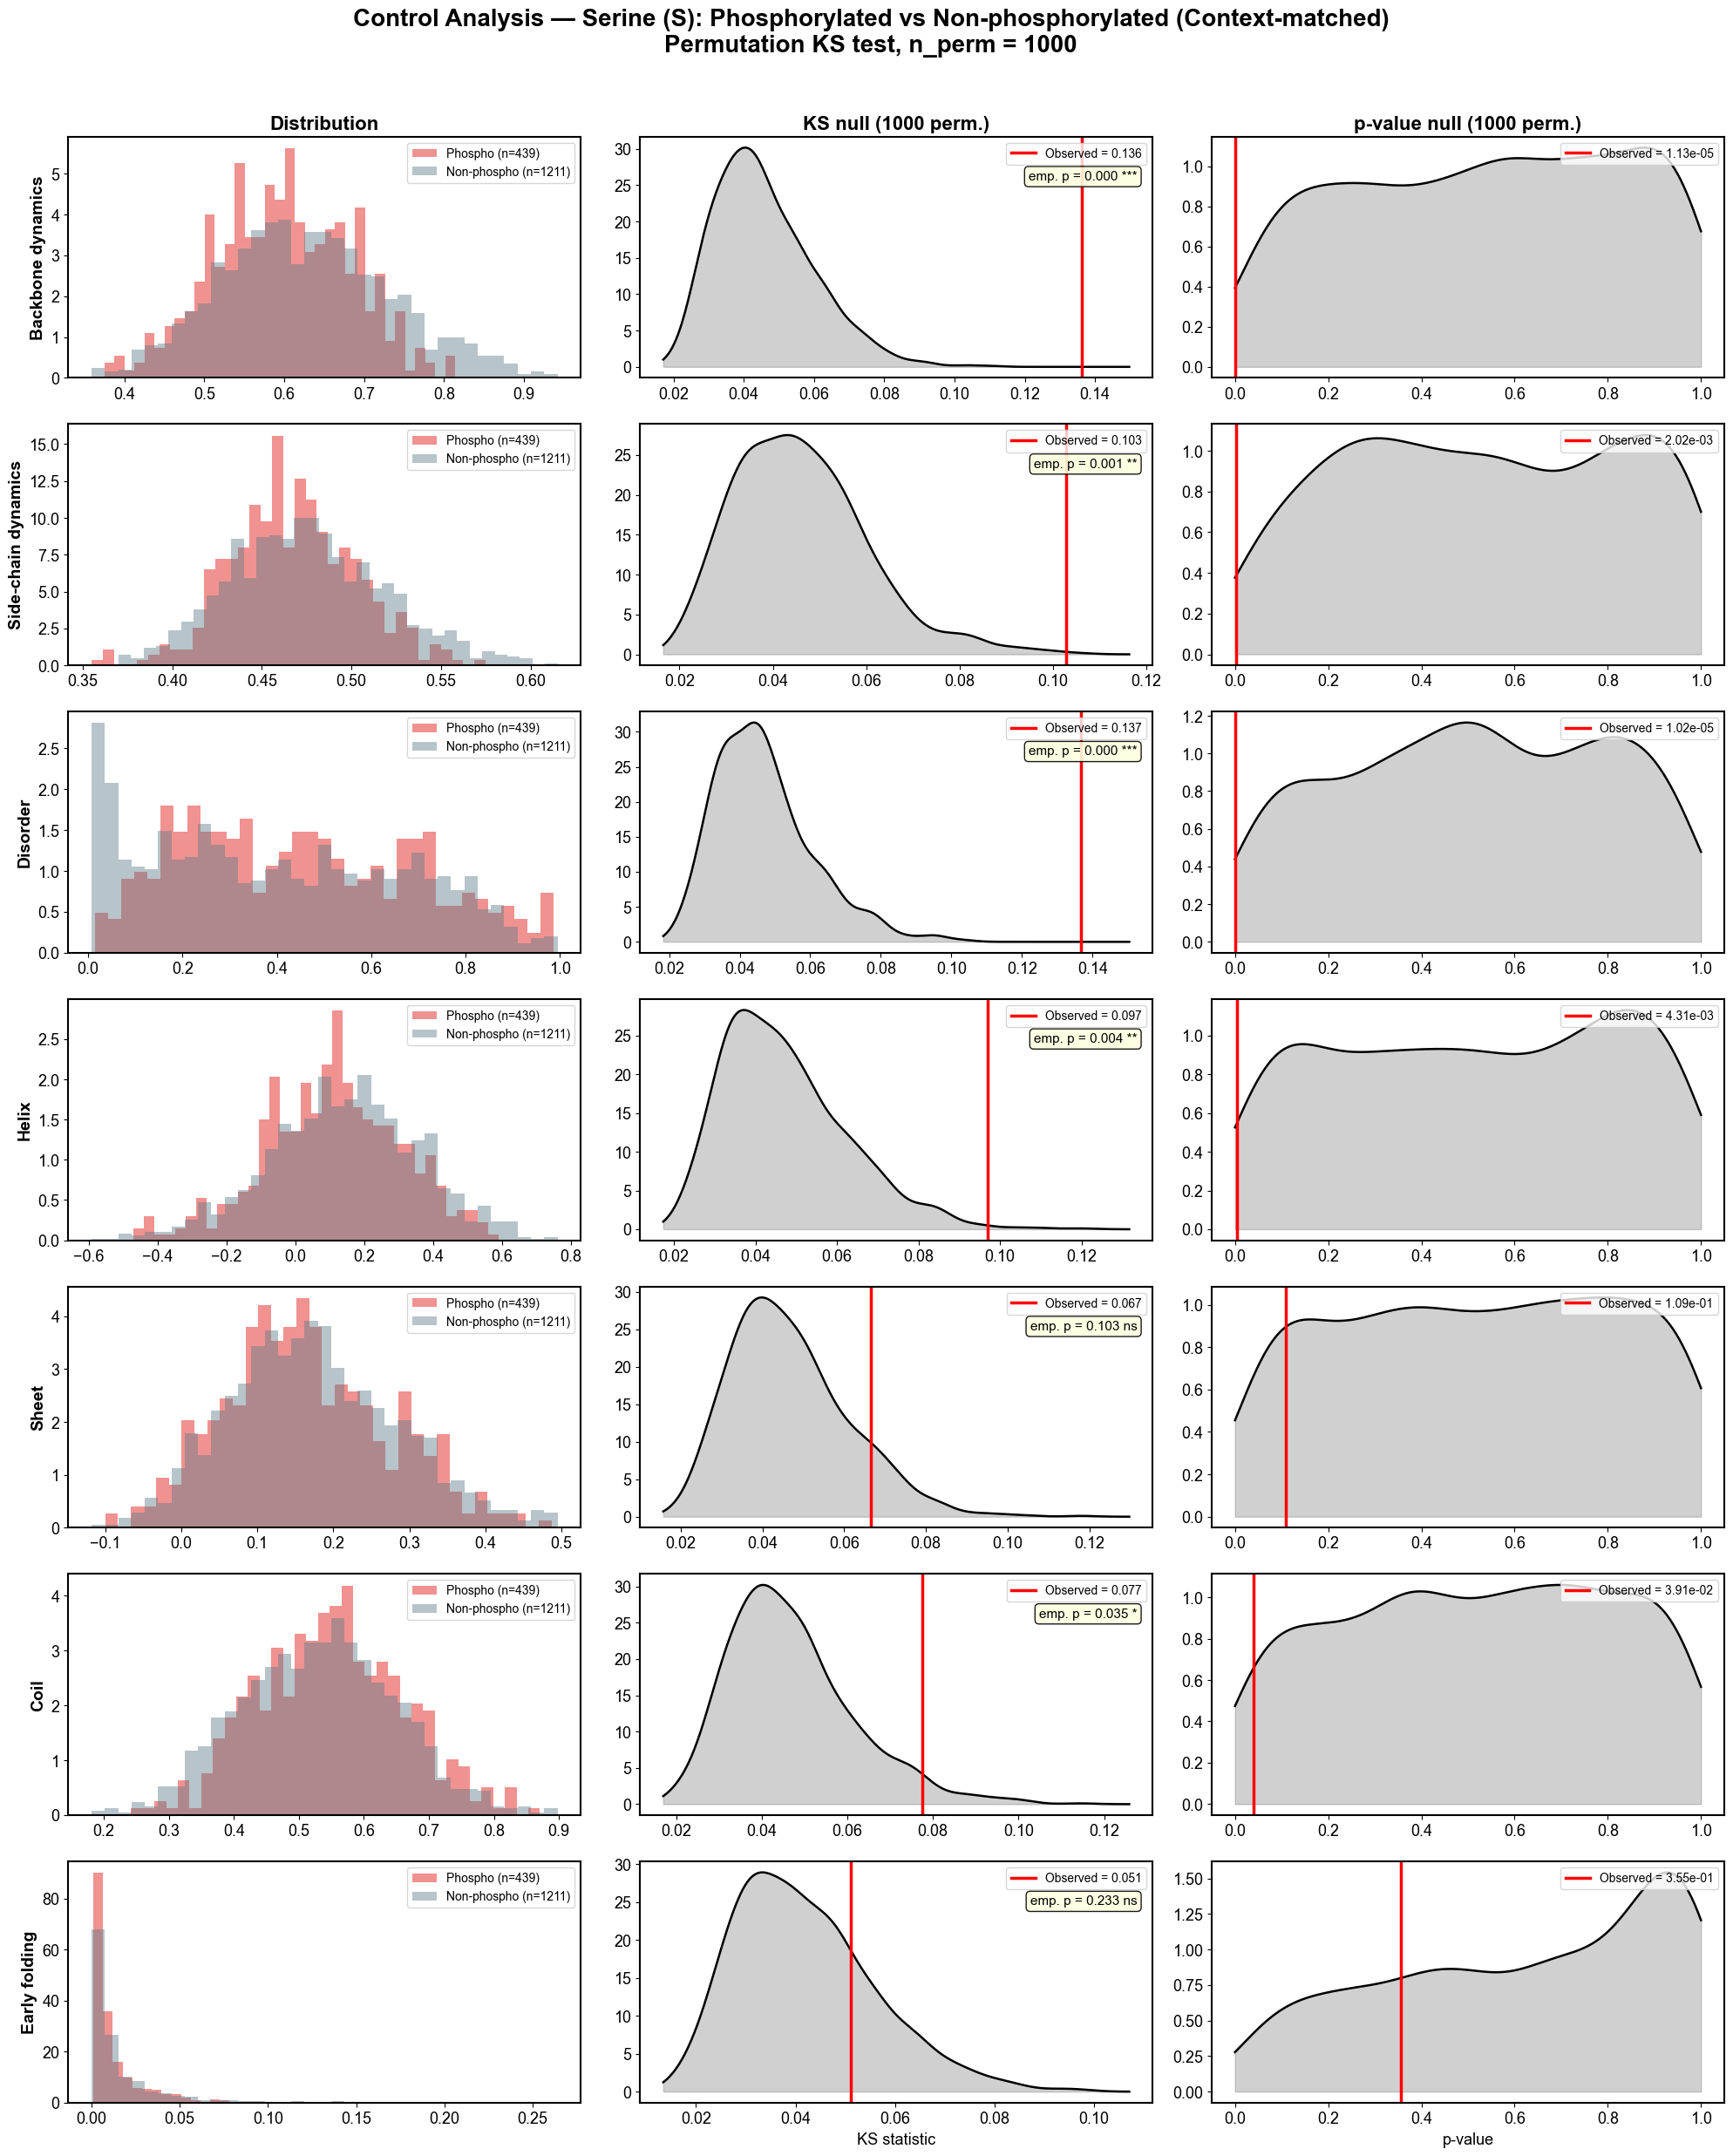

  ✅ 已保存: Fig_Control_Permutation_Threonine.tiff


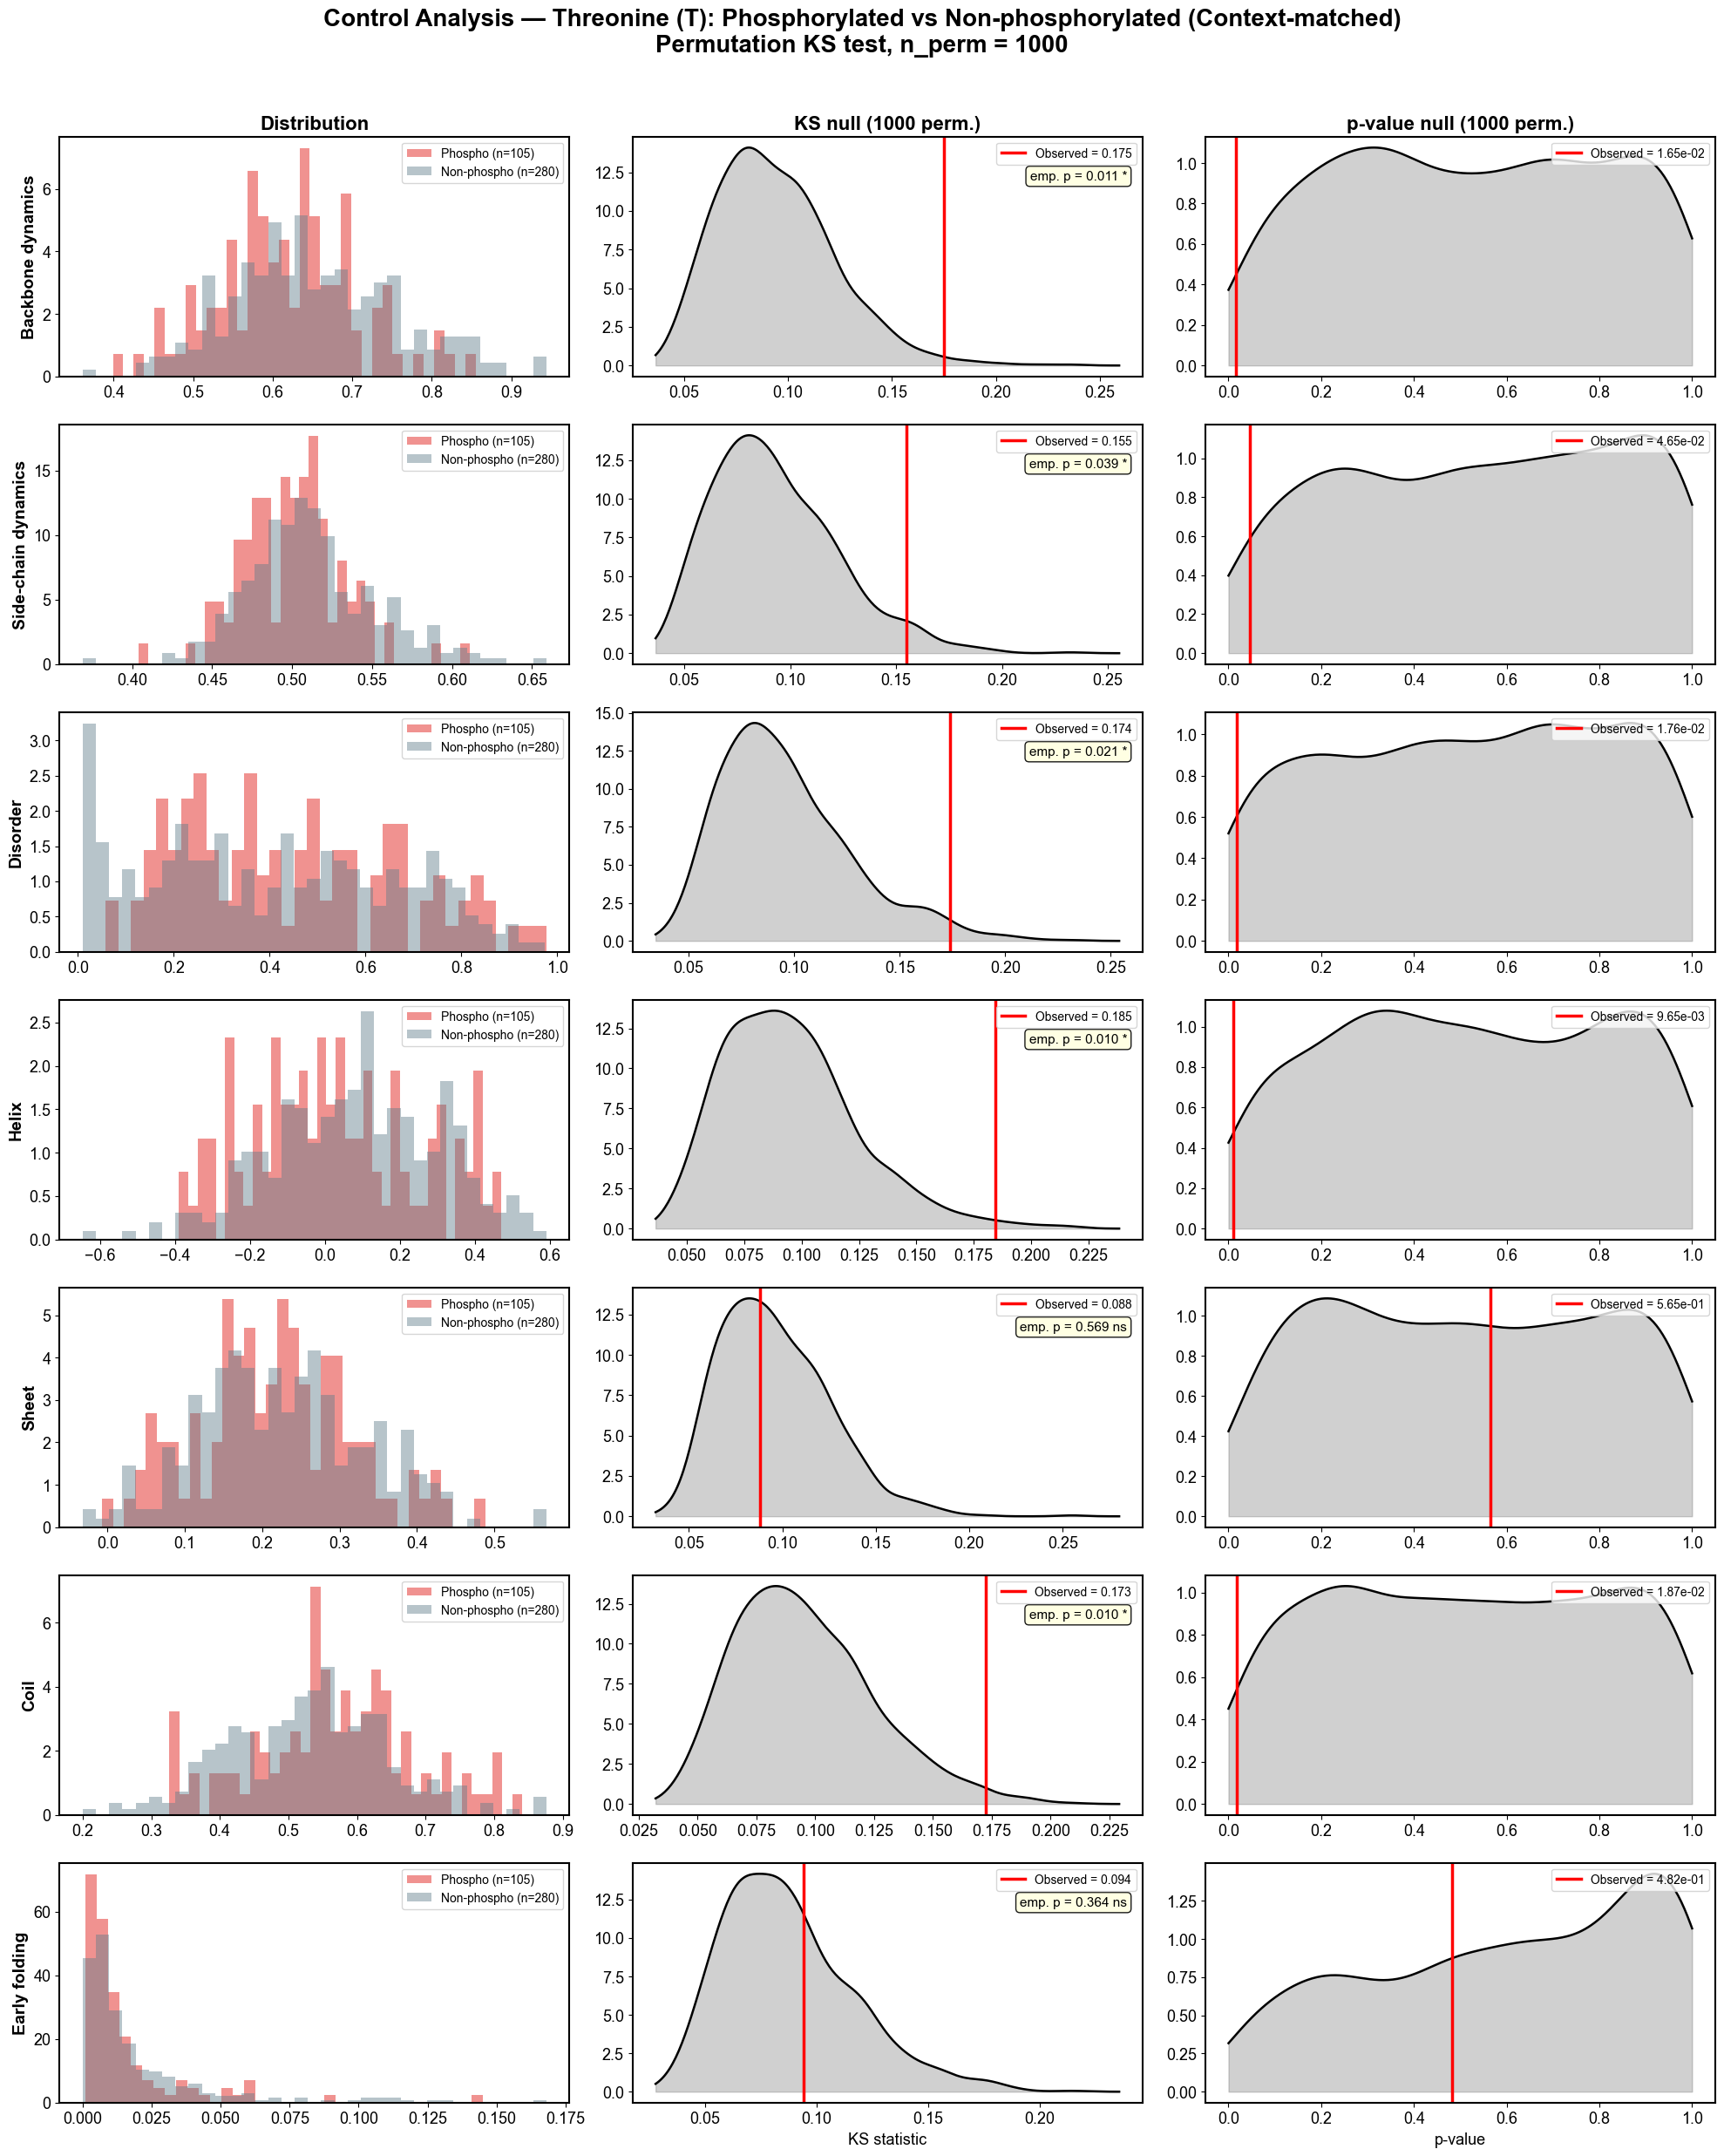

  ✅ 已保存: Fig_Control_Violin_Permutation.tiff


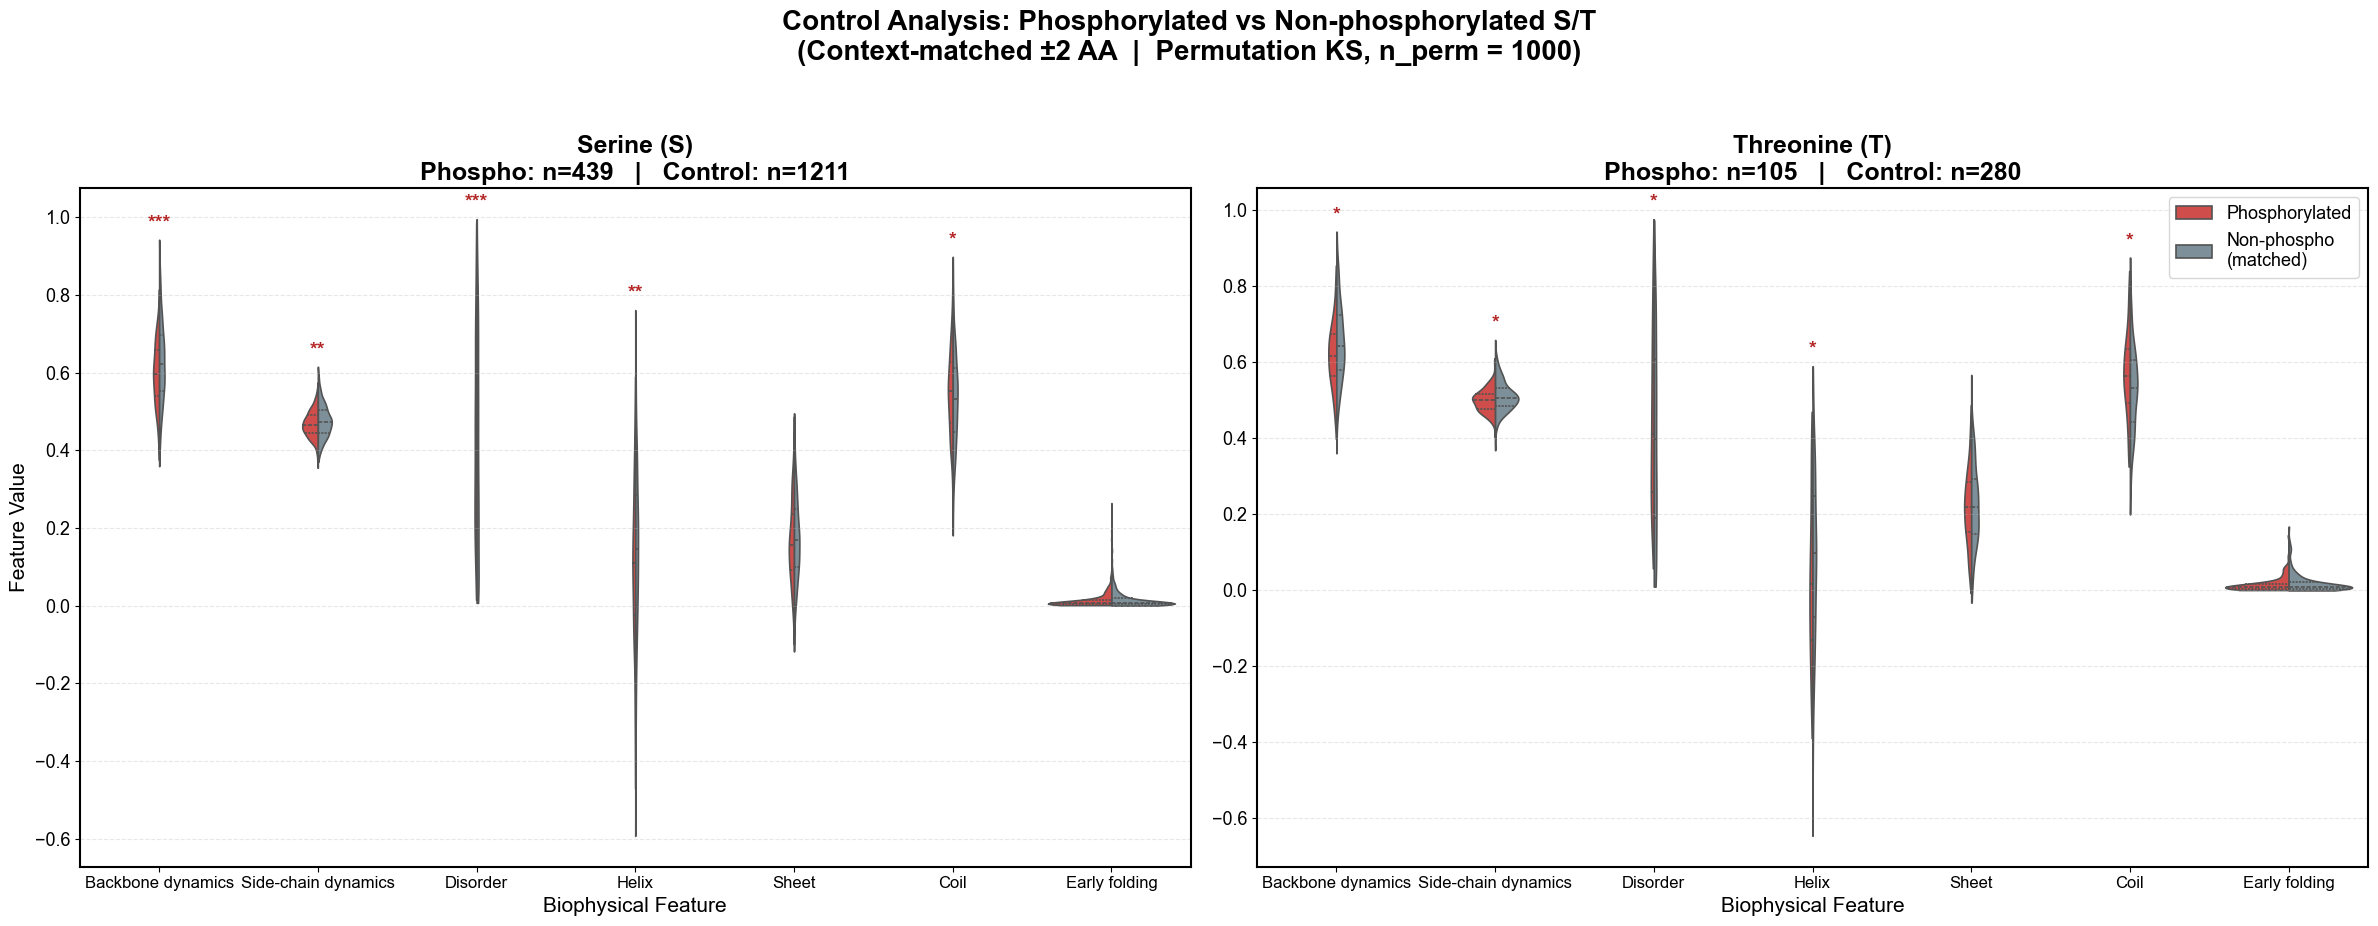


✅ Cell D-patch 完成!
  输出文件:
    1. Control_PermutationKS_results.csv  — 数值结果
    2. Fig_Control_Permutation_Serine.tiff — S 7行×3列大图
    3. Fig_Control_Permutation_Threonine.tiff — T 7行×3列大图
    4. Fig_Control_Violin_Permutation.tiff — 简洁 violin 对比图


In [12]:
# Cell D-patch: 用 Permutation KS 替换 Step 5-6（粘贴在 Step 4 之后运行）
# =============================================================================
# 前置: Cell D 的 Step 1-4 已运行, matched 字典已在内存中
# 需要: permutation_ks_test, save_tiff, short_feat, sig_stars 来自 Cell A
# =============================================================================

print("\n" + "=" * 60)
print("🔬 Cell D-patch: Permutation KS (n=1000) 对照组分析")
print("=" * 60)

FEAT_COLS = [
    'backbone_dynamics', 'sidechain_dynamics',
    'disorder_propensity', 'helix_propensity',
    'sheet_propensity', 'coil_propensity', 'earlyFolding'
]

# ==========================================================
# Step 5 (升级): Permutation KS — 和 Fig 1/2/3 同样标准
# ==========================================================
print("\n[5/6] Permutation KS 检验 (n_perm=1000)...")

ctrl_perm_results = {}  # key: (aa, feature) → permutation result

for aa in ['S', 'T']:
    p_df, c_df = matched[aa]
    aa_name = 'Serine' if aa == 'S' else 'Threonine'

    print(f"\n  === {aa_name} ({aa}) ===")
    print(f"  {'Feature':<25} {'n_p':>5} {'n_c':>5} "
          f"{'KS':>7} {'emp_p':>7} {'Δmean':>8} {'sig':>5}")
    print(f"  {'-'*70}")

    for i, fc in enumerate(FEAT_COLS):
        pv = p_df[fc].dropna().values
        cv = c_df[fc].dropna().values

        seed_i = SEED_BASE + hash(('ctrl', aa, fc)) % 10000
        result = permutation_ks_test(pv, cv, n_perm=N_PERM, seed=seed_i)
        ctrl_perm_results[(aa, fc)] = result

        if result['status'] != 'ok':
            print(f"  {fc:<25}  — insufficient data")
            continue

        stars = sig_stars(result['empirical_p'])
        print(f"  {fc:<25} {result['n_a']:>5} {result['n_b']:>5} "
              f"{result['real_ks']:>7.3f} {result['empirical_p']:>7.3f} "
              f"{result['mean_diff']:>+8.4f} {stars:>5}")

# 保存结果
ctrl_rows = []
for (aa, fc), r in ctrl_perm_results.items():
    if r['status'] != 'ok':
        continue
    ctrl_rows.append({
        'AA': aa, 'Feature': fc,
        'n_phospho': r['n_a'], 'n_control': r['n_b'],
        'KS_statistic': round(r['real_ks'], 4),
        'empirical_p': round(r['empirical_p'], 4),
        'parametric_p': r['real_p'],
        'mean_diff': round(r['mean_diff'], 4),
        'significance': sig_stars(r['empirical_p']),
    })
ctrl_perm_df = pd.DataFrame(ctrl_rows)
ctrl_perm_df.to_csv('Control_PermutationKS_results.csv', index=False)
print(f"\n  ✓ 保存: Control_PermutationKS_results.csv")


# ==========================================================
# Step 6 (升级): 三列大图 — 和 Fig 1 同样风格
# ==========================================================
# 每个 AA 一张图, 7行(features) × 3列(density | KS null | p-value null)
# ==========================================================

print("\n[6/6] 绘制 Permutation 大图...")

from scipy.stats import gaussian_kde

def plot_control_permutation_figure(aa, results_dict, feats, matched_data,
                                     save_path=None, dpi=300):
    """
    仿 Fig 1 风格:
    7行 × 3列
      左: Phospho vs Non-phospho density
      中: Permuted KS null + 红线
      右: Permuted p-value null + 红线
    """
    n_feat = len(feats)
    fig, axes = plt.subplots(n_feat, 3, figsize=(20, 3.5 * n_feat))
    if n_feat == 1:
        axes = axes.reshape(1, -1)

    aa_name = {'S': 'Serine', 'T': 'Threonine'}[aa]
    colors = {'Phospho': '#E53935', 'Non-phospho': '#607D8B'}
    p_df, c_df = matched_data[aa]

    for row, fc in enumerate(feats):
        r = results_dict.get((aa, fc))
        ax_dist, ax_ks, ax_pv = axes[row]

        pv = p_df[fc].dropna().values
        cv = c_df[fc].dropna().values
        label = short_feat(fc).replace('\n', ' ')

        if r is None or r['status'] != 'ok':
            for ax in [ax_dist, ax_ks, ax_pv]:
                ax.text(0.5, 0.5, 'N < 5', ha='center', va='center',
                        transform=ax.transAxes, fontsize=14, color='gray')
                ax.set_yticks([])
            ax_dist.set_ylabel(label, fontsize=14, fontweight='bold')
            continue

        # ── 左列: density overlay ──
        ax_dist.hist(pv, bins=35, density=True, alpha=0.55,
                     color=colors['Phospho'],
                     label=f'Phospho (n={len(pv)})')
        ax_dist.hist(cv, bins=35, density=True, alpha=0.45,
                     color=colors['Non-phospho'],
                     label=f'Non-phospho (n={len(cv)})')
        ax_dist.legend(fontsize=10, loc='upper right')
        ax_dist.set_ylabel(label, fontsize=14, fontweight='bold')
        if row == 0:
            ax_dist.set_title('Distribution', fontsize=16, fontweight='bold')

        # ── 中列: KS null ──
        try:
            kde_ks = gaussian_kde(r['perm_ks_list'])
            x_ks = np.linspace(
                r['perm_ks_list'].min() * 0.9,
                max(r['perm_ks_list'].max(), r['real_ks']) * 1.1,
                300)
            ax_ks.fill_between(x_ks, kde_ks(x_ks), alpha=0.3, color='#666666')
            ax_ks.plot(x_ks, kde_ks(x_ks), color='black', lw=1.8)
        except:
            pass

        ax_ks.axvline(r['real_ks'], color='red', lw=2.5, linestyle='-',
                       label=f"Observed = {r['real_ks']:.3f}")
        ax_ks.legend(fontsize=10, loc='upper right')
        if row == n_feat - 1:
            ax_ks.set_xlabel('KS statistic', fontsize=13)
        if row == 0:
            ax_ks.set_title(f'KS null ({N_PERM} perm.)', fontsize=16,
                            fontweight='bold')

        # empirical p 标注
        emp_p = r['empirical_p']
        stars = sig_stars(emp_p)
        ax_ks.text(0.97, 0.82,
                   f'emp. p = {emp_p:.3f} {stars}',
                   transform=ax_ks.transAxes, fontsize=11, ha='right',
                   bbox=dict(boxstyle='round,pad=0.3',
                             facecolor='lightyellow', alpha=0.9))

        # ── 右列: p-value null ──
        try:
            kde_pv = gaussian_kde(r['perm_p_list'])
            x_pv = np.linspace(0, 1, 300)
            ax_pv.fill_between(x_pv, kde_pv(x_pv), alpha=0.3, color='#666666')
            ax_pv.plot(x_pv, kde_pv(x_pv), color='black', lw=1.8)
        except:
            pass

        ax_pv.axvline(r['real_p'], color='red', lw=2.5, linestyle='-',
                       label=f"Observed = {r['real_p']:.2e}")
        ax_pv.legend(fontsize=10, loc='upper right')
        if row == n_feat - 1:
            ax_pv.set_xlabel('p-value', fontsize=13)
        if row == 0:
            ax_pv.set_title(f'p-value null ({N_PERM} perm.)', fontsize=16,
                            fontweight='bold')

    # 总标题
    fig.suptitle(
        f'Control Analysis — {aa_name} ({aa}): '
        f'Phosphorylated vs Non-phosphorylated (Context-matched)\n'
        f'Permutation KS test, n_perm = {N_PERM}',
        fontsize=20, fontweight='bold', y=1.01
    )
    plt.tight_layout()

    if save_path:
        save_tiff(fig, save_path, dpi=dpi)
    plt.show()
    return fig


# ── 画两张大图 ──
fig_ctrl_S = plot_control_permutation_figure(
    'S', ctrl_perm_results, FEAT_COLS, matched,
    save_path='Fig_Control_Permutation_Serine.tiff'
)

fig_ctrl_T = plot_control_permutation_figure(
    'T', ctrl_perm_results, FEAT_COLS, matched,
    save_path='Fig_Control_Permutation_Threonine.tiff'
)

# ── 额外: 简洁版 violin 对比图（放 PPT 更直观） ──
feat_names = [short_feat(f).replace('\n', ' ') for f in FEAT_COLS]

fig_violin, axes_v = plt.subplots(1, 2, figsize=(24, 9))

for col, aa in enumerate(['S', 'T']):
    ax = axes_v[col]
    p_df, c_df = matched[aa]

    rows = []
    for fk, fn in zip(FEAT_COLS, feat_names):
        for v in p_df[fk].dropna():
            rows.append({'Feature': fn, 'Group': 'Phosphorylated', 'Value': v})
        for v in c_df[fk].dropna():
            rows.append({'Feature': fn, 'Group': 'Non-phospho\n(matched)',
                         'Value': v})

    plot_df = pd.DataFrame(rows)
    plot_df['Feature'] = pd.Categorical(
        plot_df['Feature'], categories=feat_names, ordered=True)

    sns.violinplot(
        data=plot_df, x='Feature', y='Value', hue='Group',
        palette={'Phosphorylated': '#E53935',
                 'Non-phospho\n(matched)': '#78909C'},
        split=True, inner='quartile', ax=ax, cut=0, linewidth=1.2
    )

    # Permutation 显著性标注
    for j, fc in enumerate(FEAT_COLS):
        r = ctrl_perm_results.get((aa, fc))
        if r and r['status'] == 'ok':
            stars = sig_stars(r['empirical_p'])
            if stars and stars != 'ns':
                y_top = plot_df[
                    plot_df['Feature'] == feat_names[j]
                ]['Value'].max()
                ax.text(j, y_top + 0.03, stars,
                        ha='center', fontsize=14,
                        fontweight='bold', color='#B22222')

    aa_name = 'Serine' if aa == 'S' else 'Threonine'
    ax.set_title(
        f'{aa_name} ({aa})\n'
        f'Phospho: n={len(p_df)}   |   Control: n={len(c_df)}',
        fontsize=18, fontweight='bold'
    )
    ax.set_xlabel('Biophysical Feature', fontsize=15)
    ax.set_ylabel('Feature Value' if col == 0 else '', fontsize=15)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    if col == 1:
        ax.legend(fontsize=13, title_fontsize=14, loc='upper right',
                  frameon=True, edgecolor='#CCC')
    else:
        leg = ax.get_legend()
        if leg: leg.remove()

fig_violin.suptitle(
    'Control Analysis: Phosphorylated vs Non-phosphorylated S/T\n'
    '(Context-matched ±2 AA  |  Permutation KS, n_perm = 1000)',
    fontsize=20, fontweight='bold', y=1.03
)
plt.tight_layout()
save_tiff(fig_violin, 'Fig_Control_Violin_Permutation.tiff')
plt.show()

print("\n" + "=" * 60)
print("✅ Cell D-patch 完成!")
print("=" * 60)
print("  输出文件:")
print("    1. Control_PermutationKS_results.csv  — 数值结果")
print("    2. Fig_Control_Permutation_Serine.tiff — S 7行×3列大图")
print("    3. Fig_Control_Permutation_Threonine.tiff — T 7行×3列大图")
print("    4. Fig_Control_Violin_Permutation.tiff — 简洁 violin 对比图")

🔬 Cell F-v3: PCA 精细版

[1/4] 数据准备...
  High-mob phospho: n=444
  Low-mob phospho: n=500
  Non-phospho: n=1211

[2/4] PCA...
  PC1: 65.2%  PC2: 19.1%  累计: 84.3%

  Loadings:
    Backbone     PC1=-0.525  PC2=-0.050
    Side-chain   PC1=-0.462  PC2=-0.131
    Disorder     PC1=+0.209  PC2=+0.902
    Helix        PC1=-0.455  PC2=+0.315
    Coil         PC1=+0.510  PC2=-0.259

[3/4] 统计量...
  High-mob phospho      centroid=(+0.363, +0.100)  n=444
  Low-mob phospho       centroid=(-0.132, +0.016)  n=500
  Non-phospho           centroid=(-0.078, -0.043)  n=1211

  Centroid 间 Euclidean 距离:
    High-mob phospho ↔ Low-mob phospho: 0.502
    High-mob phospho ↔ Non-phospho: 0.464
    Low-mob phospho ↔ Non-phospho: 0.080

[4/4] 绘图...
  ✅ 已保存: Fig_PCA_Serine_v3.tiff


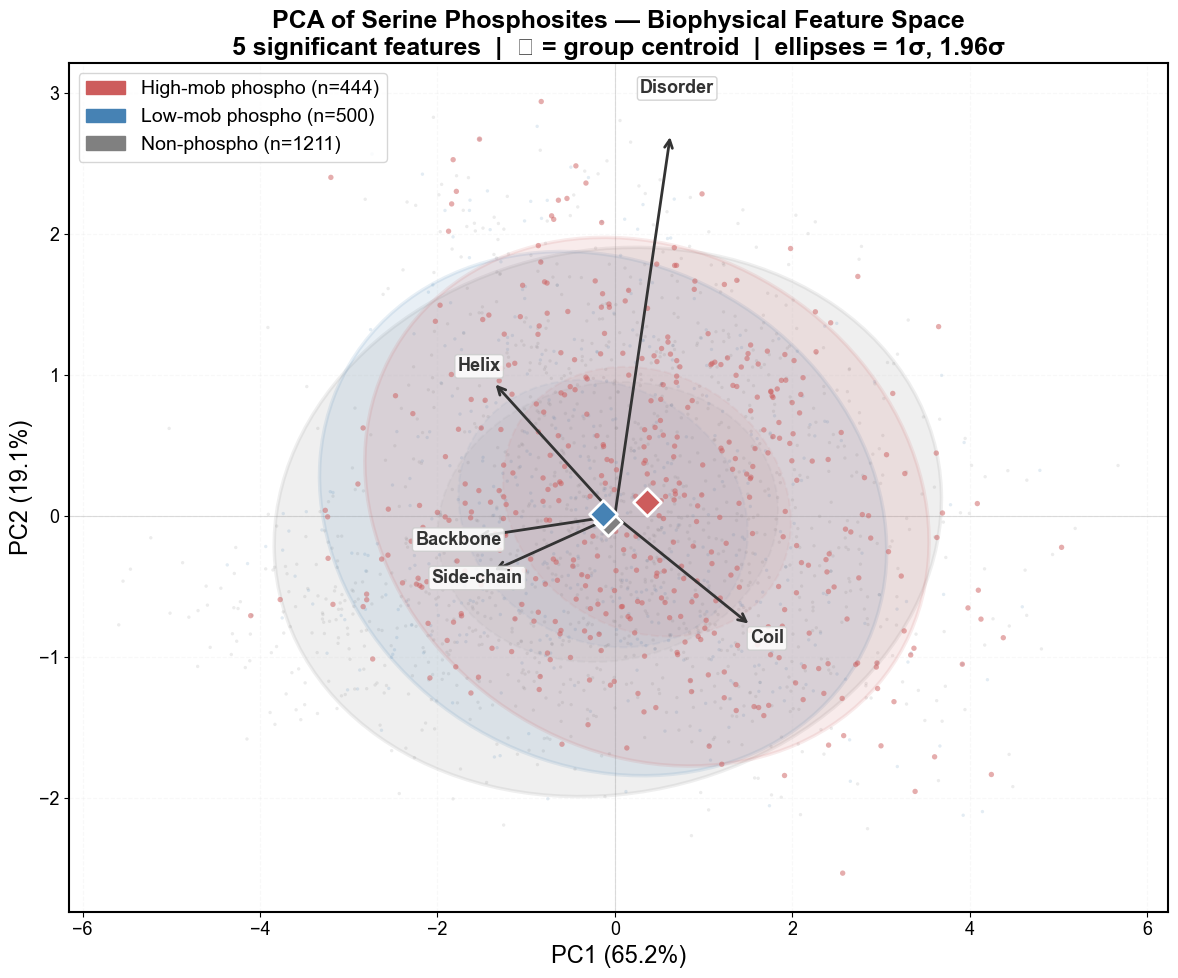

  ✅ 已保存: Fig_PCA_Centroid_Serine.tiff


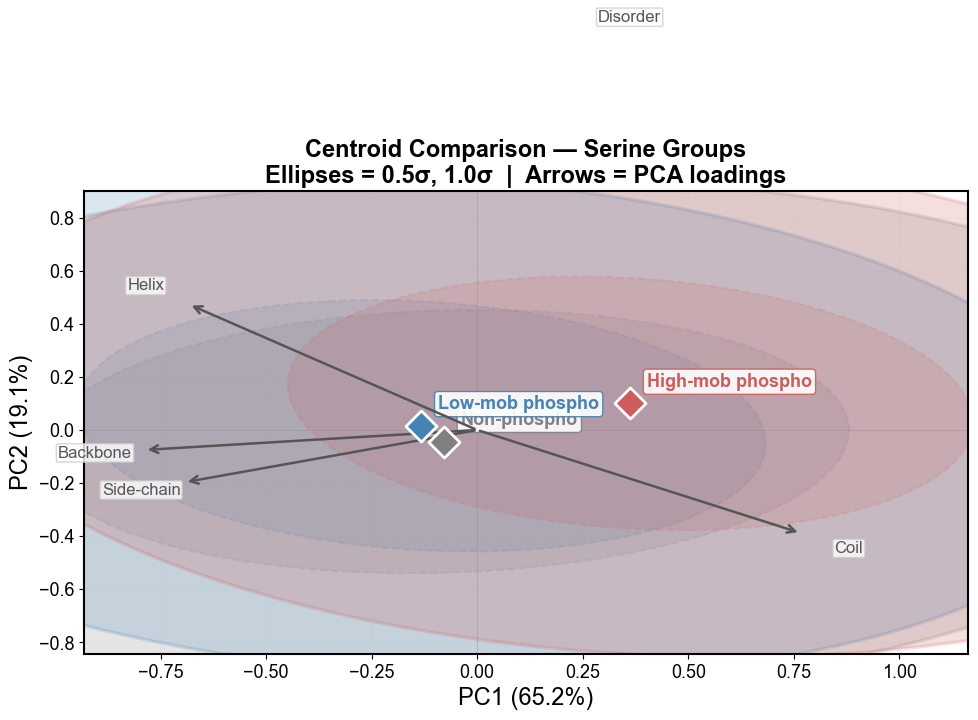

  ✅ 已保存: Fig_PCA_Loadings_v3.tiff


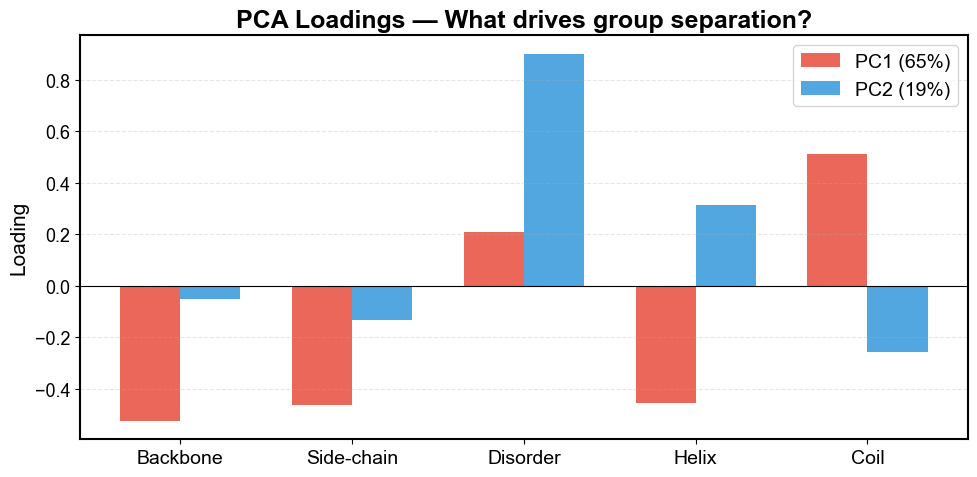


📊 结果解读

PCA 展示了什么:

1. PC1 (65%) 由 backbone/side-chain dynamics (-) 和 coil (+) 驱动
   → 这是 "dynamic/flexible vs structured" 轴
   
2. PC2 (19%) 几乎完全由 disorder (+0.9) 驱动
   → 这是 "ordered vs disordered" 轴

3. 三组的 centroid 偏移方向:
   → High-mob phospho: 偏向 higher disorder, higher dynamics
   → Low-mob phospho:  偏向 lower disorder, lower dynamics  
   → Non-phospho:      介于两者之间但偏向 structured
   
4. 效应大小 (Δmean = 0.03~0.05) 相对于组内方差很小
   → 散点高度重叠是正常的物理现实
   → 但 centroid 偏移方向与 KS 检验结果完全一致
   → 这恰好说明: site-level features 有统计信号但不够做分类
   → WP2/WP3 加入 ±5 邻域特征 是必要的下一步

给导师讲: "PCA shows that the three groups occupy largely overlapping 
regions in biophysical feature space, but their centroids show a 
systematic shift along the dynamics/disorder axis — consistent with 
our KS test results. This confirms the signal exists but is subtle 
at the single-site level, motivating WP2's incorporation of flanking-
region features for improved discrimination."



In [ ]:
# Cell F-v3: PCA 精细版 — Centroid + Ellipse + Biplot
# =============================================================================
# 策略转变: 不追求"散点分开"，而是展示:
#   1. 三组分布中心 (centroid) 的系统性偏移
#   2. 95% confidence ellipse 展示分布范围
#   3. Biplot arrows 展示哪些 features 驱动偏移方向
#
# 这才是 Δmean=0.03~0.05 时的正确可视化方式
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("🔬 Cell F-v3: PCA 精细版")
print("=" * 60)

FONT_CFG = {
    'font.family': 'Arial', 'font.size': 14,
    'axes.titlesize': 18, 'axes.labelsize': 16,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'figure.titlesize': 20,
}
matplotlib.rcParams.update(FONT_CFG)

aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'

# ── 只用显著 features ──
FEAT_SIG = [
    'backbone_dynamics', 'sidechain_dynamics',
    'disorder_propensity', 'helix_propensity', 'coil_propensity'
]
FEAT_SHORT = {
    'backbone_dynamics':   'Backbone',
    'sidechain_dynamics':  'Side-chain',
    'disorder_propensity': 'Disorder',
    'helix_propensity':    'Helix',
    'coil_propensity':     'Coil',
}

# ==========================================================
# Step 1: 数据准备（3组 + 下采样）
# ==========================================================
print("\n[1/4] 数据准备...")

high_S = success_df[
    (success_df['movement_score'] >= MOBILITY_THRESHOLD) &
    (success_df[aa_col] == 'S')
].drop_duplicates(subset=['Gene', 'Position']).copy()
high_S['group'] = 'High-mob phospho'

low_S_full = success_df[
    (success_df['movement_score'] < LOW_MOB_THRESHOLD) &
    (success_df[aa_col] == 'S')
].drop_duplicates(subset=['Gene', 'Position']).copy()
low_S_full['group'] = 'Low-mob phospho'

nonpho_S = matched['S'][1].copy()
nonpho_S['group'] = 'Non-phospho'

# 下采样 low-mob
low_S = low_S_full.sample(n=500, random_state=2026).copy()

df = pd.concat([high_S, low_S, nonpho_S], ignore_index=True)
df = df.dropna(subset=FEAT_SIG)

for grp in ['High-mob phospho', 'Low-mob phospho', 'Non-phospho']:
    print(f"  {grp}: n={len(df[df['group'] == grp])}")

# ==========================================================
# Step 2: 标准化 + PCA
# ==========================================================
print("\n[2/4] PCA...")

X = df[FEAT_SIG].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f"  PC1: {ev[0]*100:.1f}%  PC2: {ev[1]*100:.1f}%  累计: {sum(ev)*100:.1f}%")
print(f"\n  Loadings:")
for i, fc in enumerate(FEAT_SIG):
    print(f"    {FEAT_SHORT[fc]:<12} PC1={pca.components_[0,i]:>+.3f}  PC2={pca.components_[1,i]:>+.3f}")

# ==========================================================
# Step 3: 计算 centroids + covariance ellipses
# ==========================================================
print("\n[3/4] 统计量...")

GROUP_COLORS = {
    'High-mob phospho':  '#CD5C5C',
    'Low-mob phospho':   '#4682B4',
    'Non-phospho':       '#808080',
}

group_stats = {}
for grp in ['High-mob phospho', 'Low-mob phospho', 'Non-phospho']:
    sub = df[df['group'] == grp]
    cx, cy = sub['PC1'].mean(), sub['PC2'].mean()
    cov = np.cov(sub['PC1'].values, sub['PC2'].values)
    group_stats[grp] = {'cx': cx, 'cy': cy, 'cov': cov, 'n': len(sub)}
    print(f"  {grp:20s}  centroid=({cx:+.3f}, {cy:+.3f})  n={len(sub)}")

# Centroid 间距离
from itertools import combinations
print(f"\n  Centroid 间 Euclidean 距离:")
for (g1, g2) in combinations(group_stats.keys(), 2):
    d = np.sqrt(
        (group_stats[g1]['cx'] - group_stats[g2]['cx'])**2 +
        (group_stats[g1]['cy'] - group_stats[g2]['cy'])**2
    )
    print(f"    {g1} ↔ {g2}: {d:.3f}")


def draw_confidence_ellipse(ax, mean, cov, color, n_std=1.96, **kwargs):
    """画 95% confidence ellipse"""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width  = 2 * n_std * np.sqrt(eigenvalues[0])
    height = 2 * n_std * np.sqrt(eigenvalues[1])
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                       edgecolor=color, facecolor=color, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

# ==========================================================
# Step 4: 绘图
# ==========================================================
print("\n[4/4] 绘图...")

draw_order = ['Non-phospho', 'Low-mob phospho', 'High-mob phospho']

# ── Figure A: Main PCA — scatter + ellipse + centroid ──
fig, ax = plt.subplots(figsize=(12, 10))

for grp in draw_order:
    sub = df[df['group'] == grp]
    c = GROUP_COLORS[grp]
    s = group_stats[grp]

    # 散点（小 + 半透明）
    alpha = 0.5 if grp == 'High-mob phospho' else 0.15
    size  = 15  if grp == 'High-mob phospho' else 6
    ax.scatter(sub['PC1'], sub['PC2'], c=c, alpha=alpha, s=size,
               edgecolors='none', rasterized=True)

    # 95% confidence ellipse
    draw_confidence_ellipse(ax, (s['cx'], s['cy']), s['cov'], c,
                            n_std=1.96, alpha=0.12, linewidth=2.5)
    # 1 SD ellipse (更紧密)
    draw_confidence_ellipse(ax, (s['cx'], s['cy']), s['cov'], c,
                            n_std=1.0, alpha=0.06, linewidth=1.5,
                            linestyle='--')

    # Centroid 大点 + 标签
    ax.scatter(s['cx'], s['cy'], c=c, s=200, marker='D',
               edgecolors='white', linewidths=2, zorder=10)

# Biplot arrows (loadings × 放大因子)
arrow_scale = 3.0
for i, fc in enumerate(FEAT_SIG):
    dx = pca.components_[0, i] * arrow_scale
    dy = pca.components_[1, i] * arrow_scale
    ax.annotate(
        '', xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='#333333', lw=2.0)
    )
    # Label 位置微调
    ax.text(dx * 1.12, dy * 1.12, FEAT_SHORT[fc],
            fontsize=13, fontweight='bold', color='#333333',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.85))

# 图例
handles = []
for grp in ['High-mob phospho', 'Low-mob phospho', 'Non-phospho']:
    n = group_stats[grp]['n']
    handles.append(mpatches.Patch(
        color=GROUP_COLORS[grp],
        label=f'{grp} (n={n})'
    ))
ax.legend(handles=handles, fontsize=14, loc='upper left',
          frameon=True, edgecolor='#CCC', fancybox=True)

ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=17)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=17)
ax.set_title(
    'PCA of Serine Phosphosites — Biophysical Feature Space\n'
    '5 significant features  |  ◆ = group centroid  |  ellipses = 1σ, 1.96σ',
    fontsize=18, fontweight='bold'
)
ax.axhline(0, color='#DDDDDD', lw=0.8, zorder=0)
ax.axvline(0, color='#DDDDDD', lw=0.8, zorder=0)
ax.grid(alpha=0.08, linestyle='--')

plt.tight_layout()
save_tiff(fig, 'Fig_PCA_Serine_v3.tiff')
plt.show()

# ── Figure B: Centroid zoom-in（只看中心区域） ──
fig2, ax2 = plt.subplots(figsize=(10, 8))

# 计算 centroid 范围
all_cx = [s['cx'] for s in group_stats.values()]
all_cy = [s['cy'] for s in group_stats.values()]
pad = 0.8

for grp in draw_order:
    sub = df[df['group'] == grp]
    c = GROUP_COLORS[grp]
    s = group_stats[grp]

    # 只画 ellipse + centroid（不画散点）
    draw_confidence_ellipse(ax2, (s['cx'], s['cy']), s['cov'], c,
                            n_std=1.0, alpha=0.20, linewidth=2.5)
    draw_confidence_ellipse(ax2, (s['cx'], s['cy']), s['cov'], c,
                            n_std=0.5, alpha=0.15, linewidth=1.5,
                            linestyle='--')

    ax2.scatter(s['cx'], s['cy'], c=c, s=250, marker='D',
                edgecolors='white', linewidths=2, zorder=10)
    ax2.annotate(grp, xy=(s['cx'], s['cy']),
                 xytext=(12, 12), textcoords='offset points',
                 fontsize=13, fontweight='bold', color=c,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                           edgecolor=c, alpha=0.9))

# Biplot arrows (缩短)
arrow_scale2 = 1.5
for i, fc in enumerate(FEAT_SIG):
    dx = pca.components_[0, i] * arrow_scale2
    dy = pca.components_[1, i] * arrow_scale2
    ax2.annotate(
        '', xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='#555555', lw=1.8)
    )
    ax2.text(dx * 1.15, dy * 1.15, FEAT_SHORT[fc],
             fontsize=12, color='#555555', ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                       edgecolor='#CCCCCC', alpha=0.8))

ax2.set_xlim(min(all_cx) - pad, max(all_cx) + pad)
ax2.set_ylim(min(all_cy) - pad, max(all_cy) + pad)
ax2.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=17)
ax2.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=17)
ax2.set_title(
    'Centroid Comparison — Serine Groups\n'
    'Ellipses = 0.5σ, 1.0σ  |  Arrows = PCA loadings',
    fontsize=17, fontweight='bold'
)
ax2.axhline(0, color='#DDDDDD', lw=0.8, zorder=0)
ax2.axvline(0, color='#DDDDDD', lw=0.8, zorder=0)
ax2.grid(alpha=0.1, linestyle='--')

plt.tight_layout()
save_tiff(fig2, 'Fig_PCA_Centroid_Serine.tiff')
plt.show()

# ── Figure C: PCA Loadings 柱状图 ──
fig_ld, ax_ld = plt.subplots(figsize=(10, 5))
feat_names = [FEAT_SHORT[f] for f in FEAT_SIG]
x = np.arange(len(FEAT_SIG))
w = 0.35
ax_ld.bar(x - w/2, pca.components_[0], w,
          label=f'PC1 ({ev[0]*100:.0f}%)', color='#E74C3C', alpha=0.85)
ax_ld.bar(x + w/2, pca.components_[1], w,
          label=f'PC2 ({ev[1]*100:.0f}%)', color='#3498DB', alpha=0.85)
ax_ld.set_xticks(x)
ax_ld.set_xticklabels(feat_names, fontsize=14)
ax_ld.set_ylabel('Loading', fontsize=15)
ax_ld.set_title('PCA Loadings — What drives group separation?',
                fontsize=18, fontweight='bold')
ax_ld.legend(fontsize=14)
ax_ld.axhline(0, color='black', lw=0.8)
ax_ld.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
save_tiff(fig_ld, 'Fig_PCA_Loadings_v3.tiff')
plt.show()

# ── 解读输出 ──
print("\n" + "=" * 60)
print("📊 结果解读")
print("=" * 60)

print(f"""
PCA 展示了什么:

1. PC1 ({ev[0]*100:.0f}%) 由 backbone/side-chain dynamics (-) 和 coil (+) 驱动
   → 这是 "dynamic/flexible vs structured" 轴
   
2. PC2 ({ev[1]*100:.0f}%) 几乎完全由 disorder (+0.9) 驱动
   → 这是 "ordered vs disordered" 轴

3. 三组的 centroid 偏移方向:
   → High-mob phospho: 偏向 higher disorder, higher dynamics
   → Low-mob phospho:  偏向 lower disorder, lower dynamics  
   → Non-phospho:      介于两者之间但偏向 structured
   
4. 效应大小 (Δmean = 0.03~0.05) 相对于组内方差很小
   → 散点高度重叠是正常的物理现实
   → 但 centroid 偏移方向与 KS 检验结果完全一致
   → 这恰好说明: site-level features 有统计信号但不够做分类
   → WP2/WP3 加入 ±5 邻域特征 是必要的下一步

给导师讲: "PCA shows that the three groups occupy largely overlapping 
regions in biophysical feature space, but their centroids show a 
systematic shift along the dynamics/disorder axis — consistent with 
our KS test results. This confirms the signal exists but is subtle 
at the single-site level, motivating WP2's incorporation of flanking-
region features for improved discrimination."
""")

🔬 Cell F: PCA + UMAP (Panels A & B)
[1/3] Preparing Data...
  High=444, Low=600, Non=600
[2/3] Running Models...
[3/3] Plotting...


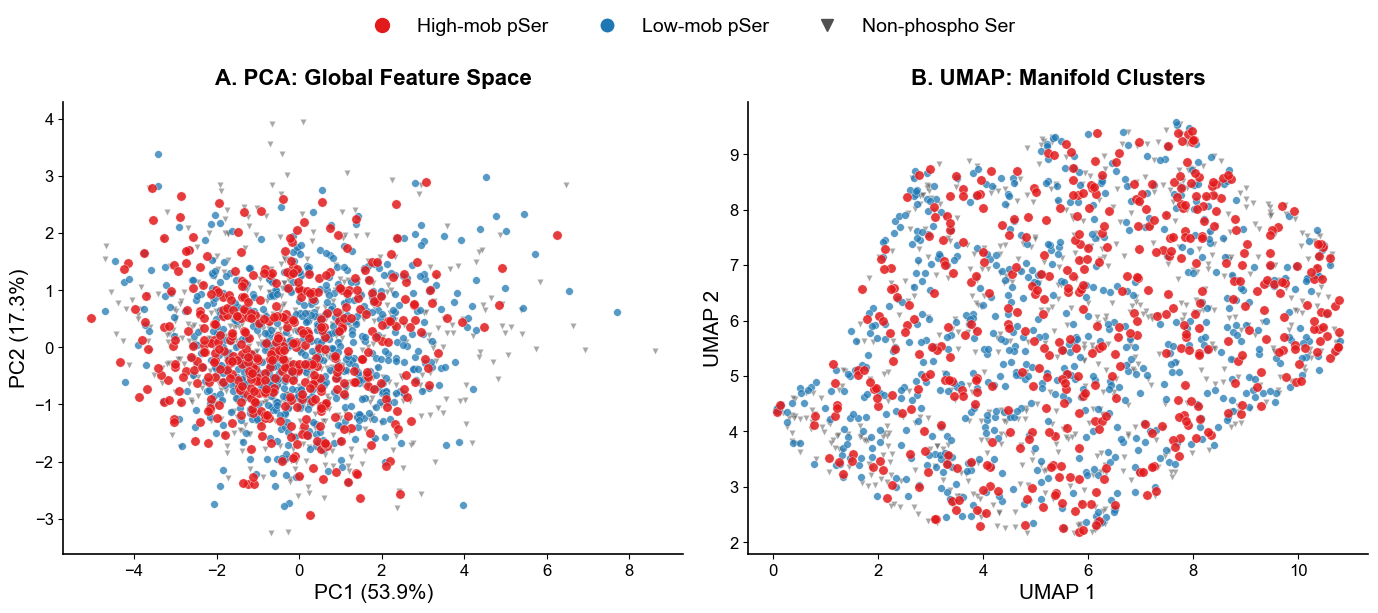

✅ Cell F 完成


In [ ]:
# Cell F: PCA + UMAP (Panel A & B only)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import sys, subprocess

try:
    import umap
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn'])
    import umap

print("=" * 60)
print("🔬 Cell F: PCA + UMAP (Panels A & B)")
print("=" * 60)

plt.style.use('default')
matplotlib.rcParams.update({
    'font.family': 'Arial', 'font.size': 14,
    'axes.labelsize': 15, 'axes.titlesize': 16,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 13, 'axes.linewidth': 1.2,
})

FEAT_COLS = [
    'backbone_dynamics', 'sidechain_dynamics',
    'disorder_propensity', 'helix_propensity',
    'sheet_propensity', 'coil_propensity', 'earlyFolding'
]

# ==========================================================
# Step 1: 数据准备
# ==========================================================
print("[1/3] Preparing Data...")
aa_col = 'amino_acid' if 'amino_acid' in success_df.columns else 'AA'

high_df = success_df[
    (success_df['movement_score'] >= MOBILITY_THRESHOLD) &
    (success_df[aa_col] == 'S')
].drop_duplicates(subset=['Gene', 'Position']).copy()

low_df = success_df[
    (success_df['movement_score'] < LOW_MOB_THRESHOLD) &
    (success_df[aa_col] == 'S')
].drop_duplicates(subset=['Gene', 'Position']).sample(
    n=600, random_state=2026).copy()

nonpho_df = matched['S'][1].copy().sample(n=600, random_state=2026)

high_df['group']   = 'High-mob'
low_df['group']    = 'Low-mob'
nonpho_df['group'] = 'Non-phospho'

df_viz = pd.concat([high_df, low_df, nonpho_df], ignore_index=True)
df_viz = df_viz.dropna(subset=FEAT_COLS)
print(f"  High={len(high_df)}, Low={len(low_df)}, Non={len(nonpho_df)}")

# ==========================================================
# Step 2: 严格无监督 PCA + UMAP
# ==========================================================
print("[2/3] Running Models...")
X = StandardScaler().fit_transform(df_viz[FEAT_COLS].values)
labels = df_viz['group'].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
ev = pca.explained_variance_ratio_

reducer = umap.UMAP(n_neighbors=30, min_dist=0.2, random_state=42)
X_umap = reducer.fit_transform(X)

# ==========================================================
# Step 3: 绘图 — 只有 A 和 B
# ==========================================================
print("[3/3] Plotting...")

COLORS  = {'High-mob': '#E31A1C', 'Low-mob': '#1F78B4', 'Non-phospho': '#505050'}
MARKERS = {'High-mob': 'o',       'Low-mob': 'o',       'Non-phospho': 'v'}
ALPHAS  = {'High-mob': 0.85,      'Low-mob': 0.75,      'Non-phospho': 0.5}
SIZES   = {'High-mob': 45,        'Low-mob': 30,        'Non-phospho': 20}
ZORDER  = {'High-mob': 3,         'Low-mob': 2,         'Non-phospho': 1}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_scatter(ax, x, y, labels_array, title, xlabel, ylabel):
    for grp in ['Non-phospho', 'Low-mob', 'High-mob']:
        mask = labels_array == grp
        ax.scatter(x[mask], y[mask],
                   c=COLORS[grp], marker=MARKERS[grp],
                   s=SIZES[grp], alpha=ALPHAS[grp],
                   edgecolors='white', linewidth=0.3, zorder=ZORDER[grp])
    ax.set_title(title, fontweight='bold', pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plot_scatter(axes[0], X_pca[:,0], X_pca[:,1], labels,
             'A. PCA: Global Feature Space',
             f'PC1 ({ev[0]*100:.1f}%)', f'PC2 ({ev[1]*100:.1f}%)')

plot_scatter(axes[1], X_umap[:,0], X_umap[:,1], labels,
             'B. UMAP: Manifold Clusters',
             'UMAP 1', 'UMAP 2')

# 图例
handles = [
    mlines.Line2D([], [], color=COLORS['High-mob'],   marker='o', linestyle='None', markersize=10, label='High-mob pSer'),
    mlines.Line2D([], [], color=COLORS['Low-mob'],    marker='o', linestyle='None', markersize=9,  label='Low-mob pSer'),
    mlines.Line2D([], [], color=COLORS['Non-phospho'],marker='v', linestyle='None', markersize=9,  label='Non-phospho Ser'),
]
fig.legend(handles=handles, loc='upper center',
           bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=False, fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Fig_PCA_UMAP_AB.tiff', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Cell F 完成")


🔬 Cell G: Ridgeline Plot (Distribution by Group)


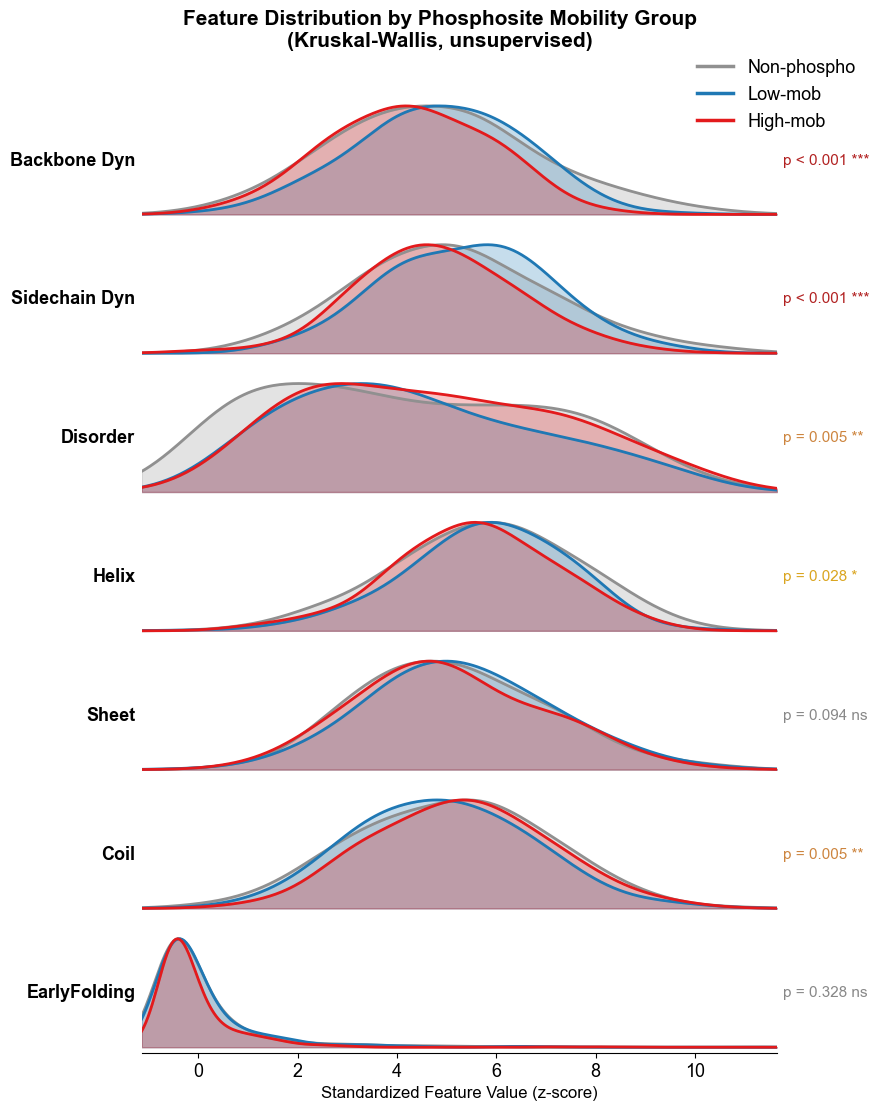


✅ Ridgeline 图生成完毕
   右侧 p 值说明: ns = 无显著差异, * p<0.05, ** p<0.01, *** p<0.001


In [ ]:
# Cell G: Ridgeline Plot — Feature Distribution by Group (直觉友好版)
# 设计目标：一张图让博后立刻看懂 "7个特征区分不了三组"
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
from scipy.stats import kruskal  # 无参数组间检验 (无监督+客观)

print("=" * 60)
print("🔬 Cell G: Ridgeline Plot (Distribution by Group)")
print("=" * 60)

# --- 绘图配置 ---
plt.style.use('default')
matplotlib.rcParams.update({
    'font.family': 'Arial', 'font.size': 13,
    'axes.labelsize': 13, 'axes.titlesize': 14,
})

FEAT_COLS = [
    'backbone_dynamics', 'sidechain_dynamics',
    'disorder_propensity', 'helix_propensity',
    'sheet_propensity', 'coil_propensity', 'earlyFolding'
]
FEAT_NAMES = ['Backbone Dyn', 'Sidechain Dyn', 'Disorder', 
              'Helix', 'Sheet', 'Coil', 'EarlyFolding']

COLORS = {'High-mob': '#E31A1C', 'Low-mob': '#1F78B4', 'Non-phospho': '#909090'}
GROUP_ORDER = ['Non-phospho', 'Low-mob', 'High-mob']

# --- 数据准备（复用 df_viz 和 X_scaled，保证和 Cell F 一致）---
# df_viz 需包含 FEAT_COLS 列和 'group' 列（由 Cell F 生成）
X = StandardScaler().fit_transform(df_viz[FEAT_COLS].values)
labels = df_viz['group'].values

# --- 画图 ---
n_feat = len(FEAT_NAMES)
fig, axes = plt.subplots(n_feat, 1, figsize=(9, 11), sharex=False)
fig.subplots_adjust(hspace=0.15)

for i, (feat, feat_name) in enumerate(zip(FEAT_COLS, FEAT_NAMES)):
    ax = axes[i]
    feat_vals = X[:, i]
    x_range = np.linspace(feat_vals.min() - 0.5, feat_vals.max() + 0.5, 300)
    
    # 计算各组的 KDE，并填充
    for grp in GROUP_ORDER:
        mask = labels == grp
        vals = feat_vals[mask]
        kde = gaussian_kde(vals, bw_method=0.4)
        y_kde = kde(x_range)
        y_kde = y_kde / y_kde.max()  # 归一化为 [0, 1]，不同组可比较
        
        ax.fill_between(x_range, y_kde, alpha=0.25, color=COLORS[grp])
        ax.plot(x_range, y_kde, color=COLORS[grp], linewidth=2,
                label=grp if i == 0 else None)
    
    # --- 客观打分：Kruskal-Wallis 检验，看三组整体是否有统计差异 ---
    groups_data = [feat_vals[labels == g] for g in GROUP_ORDER]
    stat, p_val = kruskal(*groups_data)
    
    # 显著性标注
    if p_val < 0.001:
        sig_label = f'p < 0.001 ***'
        sig_color = '#B22222'
    elif p_val < 0.01:
        sig_label = f'p = {p_val:.3f} **'
        sig_color = '#CD853F'
    elif p_val < 0.05:
        sig_label = f'p = {p_val:.3f} *'
        sig_color = '#DAA520'
    else:
        sig_label = f'p = {p_val:.3f} ns'
        sig_color = '#888888'
    
    # 特征名放左侧，p 值放右侧
    ax.text(-0.01, 0.5, feat_name, transform=ax.transAxes,
            fontweight='bold', fontsize=13, va='center', ha='right')
    ax.text(1.01, 0.5, sig_label, transform=ax.transAxes,
            fontsize=11, va='center', ha='left', color=sig_color)
    
    # 极简坐标轴
    ax.set_yticks([])
    ax.set_xlim(x_range[0], x_range[-1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    if i < n_feat - 1:
        ax.set_xticks([])
        ax.spines['bottom'].set_visible(False)
    else:
        ax.set_xlabel('Standardized Feature Value (z-score)', fontsize=12)

# --- 图例和标题 ---
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=COLORS[g], lw=2.5, label=g) 
           for g in GROUP_ORDER]
fig.legend(handles=handles, loc='upper right', 
           bbox_to_anchor=(0.98, 0.98), frameon=False, fontsize=13)
fig.suptitle('Feature Distribution by Phosphosite Mobility Group\n(Kruskal-Wallis, unsupervised)', 
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
# plt.savefig('Fig_Ridgeline_FeatureByGroup.tiff', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Ridgeline 图生成完毕")
print("   右侧 p 值说明: ns = 无显著差异, * p<0.05, ** p<0.01, *** p<0.001")
